### Imports

In [16]:
import numpy as np
from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst
import matplotlib.pyplot as plt

# Tests

### 01_water_baseline

k-Wave: 100%|██████████| 604/604 [00:00<00:00, 994.33step/s] 


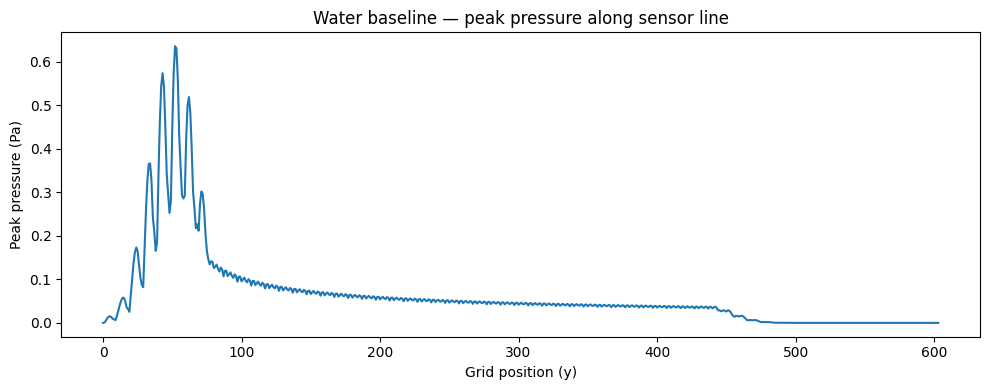

Max pressure: 0.64 Pa


In [2]:
# --- Parameters (Mueller et al. 500 kHz setup) ---
freq = 500e3          # 500 kHz
c0 = 1482.0           # speed of sound in water (m/s)
rho0 = 1000.0         # density of water (kg/m^3)

# --- Grid setup ---
wavelength = c0 / freq          # ~3 mm
dx = wavelength / 6             # 6 points per wavelength
Nx = 128
Ny = 128

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)

# --- Medium (pure water) ---
medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Source ---
source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[Nx // 2, 10] = 1
source.p = tone_burst(1/kgrid.dt, freq, 5)

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.zeros((Nx, Ny))
sensor.mask[Nx // 2, :] = 1

# --- Run ---
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')

# --- Plot ---
plt.figure(figsize=(10, 4))
p_max = np.max(np.abs(sensor_data['p']), axis=0)
plt.plot(p_max)
plt.xlabel('Grid position (y)')
plt.ylabel('Peak pressure (Pa)')
plt.title('Water baseline — peak pressure along sensor line')
plt.tight_layout()
plt.savefig('01_water_baseline.png')
plt.show()
print(f"Max pressure: {np.max(p_max):.2f} Pa")

### 02_focused_transducer

Grid size: 256 x 256, dt=1.00e-07s, Nt=1207
Number of source elements: 60
Burst length: 101 samples
Running simulation...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 846.24step/s]


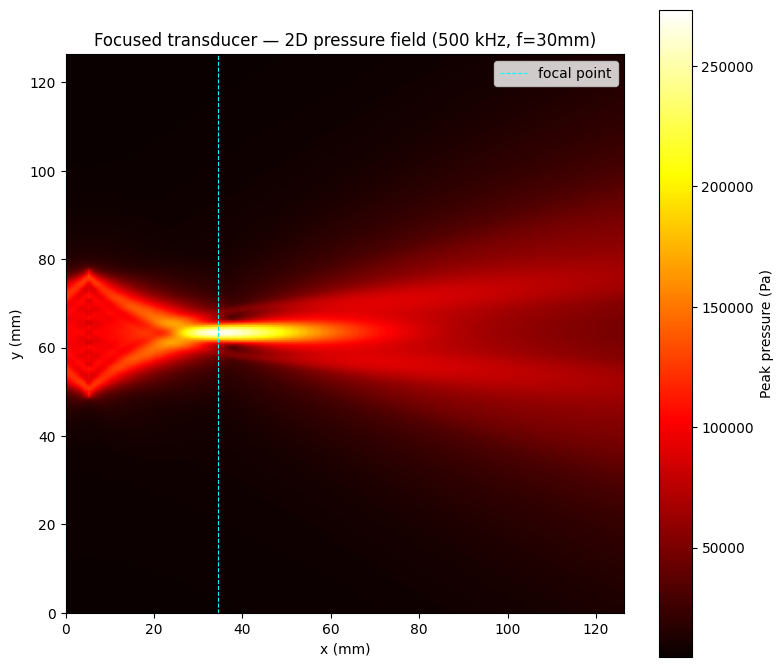

Max pressure: 273436.5 Pa
Done! Saved to 02_focused_transducer.png


In [3]:
# --- Parameters ---
freq  = 500e3
c0    = 1482.0
rho0  = 1000.0

# --- Grid ---
wavelength = c0 / freq
dx = wavelength / 6
Nx, Ny = 256, 256
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)
n_time = kgrid.Nt

# --- Medium ---
medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Transducer geometry ---
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources = len(source_y_indices)

print(f"Grid size: {Nx} x {Ny}, dt={kgrid.dt:.2e}s, Nt={n_time}")
print(f"Number of source elements: {n_sources}")

# --- Build base tone burst ---
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()
print(f"Burst length: {len(burst)} samples")

# Make sure n_time is long enough for burst + max delay
focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)  # +3.5mm correction
focal_point_y = center_y

# Compute delays
delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0

# Normalize so max delay fires first (converging focus)
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

# Ensure time array is long enough
n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
    print(f"Extended n_time to {n_time}")

# --- Build source signals ---
source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    source_signals[i, d:d + len(burst)] = burst * 1e5

# Rebuild kgrid time with correct n_time
kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# --- Run ---
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')

# --- Plot ---
p_max = sensor_data['p_max'].reshape(Nx, Ny)

plt.figure(figsize=(8, 7))
plt.imshow(p_max.T, aspect='equal',
           extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
           origin='lower', cmap='hot')
plt.colorbar(label='Peak pressure (Pa)')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Focused transducer — 2D pressure field (500 kHz, f=30mm)')
plt.axvline(x=(transducer_x + int(focal_length/dx)) * dx * 1e3,
            color='cyan', linestyle='--', linewidth=0.8, label='focal point')
plt.legend()
plt.tight_layout()
plt.savefig('02_focused_transducer.png', dpi=150)
plt.show()
print(f"Max pressure: {np.max(p_max):.1f} Pa")
print("Done! Saved to 02_focused_transducer.png")

### 03_validate

Running simulation...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 890.96step/s]



=== VALIDATION ===

[1] Focal position
    Expected x: 34.6 mm
    Actual peak x: 34.6 mm
    Offset: 0.0 mm

[2] Beamwidth (FWHM)
    Simulated FWHM: 3.5 mm
    Mueller et al.: ~4-6 mm
    Match: YES

[3] Peak pressure at focus
    Simulated: 273 kPa
    Input source: 100 kPa
    Gain from focusing: 2.7x
    Mueller et al. (scaled to 1030 kPa): would need 3.8x more input


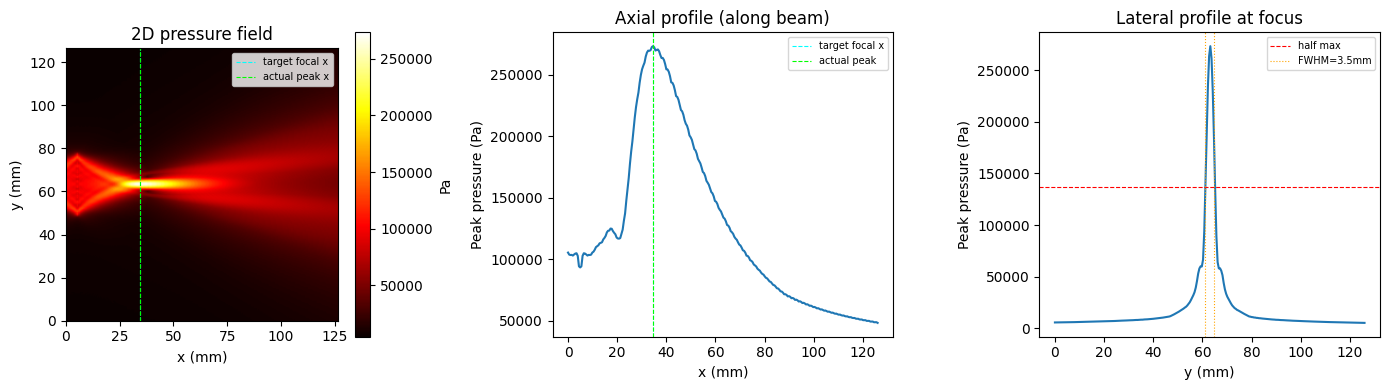


Saved to 03_validate.png


In [4]:
# --- Same parameters as 02 ---
freq         = 500e3
c0           = 1482.0
rho0         = 1000.0
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10

wavelength = c0 / freq
dx = wavelength / 6
Nx, Ny = 256, 256

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0)
n_time = kgrid.Nt

medium = kWaveMedium(sound_speed=c0, density=rho0)

# --- Source (identical to 02) ---
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources    = len(source_y_indices)

focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)  # +3.5mm correction
focal_point_y = center_y

burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    source_signals[i, d:d + len(burst)] = burst * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)

# --- Validation ---
print("\n=== VALIDATION ===")

# 1. Where is the actual peak?
peak_idx = np.unravel_index(np.argmax(p_max), p_max.shape)
peak_x_mm = peak_idx[0] * dx * 1e3
peak_y_mm = peak_idx[1] * dx * 1e3
expected_x_mm = (transducer_x + int(focal_length / dx)) * dx * 1e3
print(f"\n[1] Focal position")
print(f"    Expected x: {expected_x_mm:.1f} mm")
print(f"    Actual peak x: {peak_x_mm:.1f} mm")
print(f"    Offset: {abs(peak_x_mm - expected_x_mm):.1f} mm")

# 2. Beamwidth (FWHM) at focal plane
focal_profile = p_max[peak_idx[0], :]   # lateral slice at peak x
half_max = np.max(focal_profile) / 2
above_half = np.where(focal_profile >= half_max)[0]
if len(above_half) > 1:
    fwhm_mm = (above_half[-1] - above_half[0]) * dx * 1e3
else:
    fwhm_mm = 0
print(f"\n[2] Beamwidth (FWHM)")
print(f"    Simulated FWHM: {fwhm_mm:.1f} mm")
print(f"    Mueller et al.: ~4-6 mm")
print(f"    Match: {'YES' if 2 < fwhm_mm < 8 else 'CHECK'}")

# 3. Peak pressure
peak_pa  = np.max(p_max)
peak_kpa = peak_pa / 1e3
print(f"\n[3] Peak pressure at focus")
print(f"    Simulated: {peak_kpa:.0f} kPa")
print(f"    Input source: 100 kPa")
print(f"    Gain from focusing: {peak_kpa/100:.1f}x")
print(f"    Mueller et al. (scaled to 1030 kPa): would need {1030/peak_kpa:.1f}x more input")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: 2D field
ax = axes[0]
im = ax.imshow(p_max.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot')
ax.axvline(x=expected_x_mm, color='cyan', linestyle='--', lw=0.8, label='target focal x')
ax.axvline(x=peak_x_mm,     color='lime', linestyle='--', lw=0.8, label='actual peak x')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('2D pressure field')
ax.legend(fontsize=7)
plt.colorbar(im, ax=ax, label='Pa')

# Plot 2: Axial profile (along beam axis, through center)
ax = axes[1]
axial = p_max[:, center_y]
x_mm  = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, axial)
ax.axvline(x=expected_x_mm, color='cyan', linestyle='--', lw=0.8, label='target focal x')
ax.axvline(x=peak_x_mm,     color='lime', linestyle='--', lw=0.8, label='actual peak')
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile (along beam)')
ax.legend(fontsize=7)

# Plot 3: Lateral profile (FWHM)
ax = axes[2]
y_mm = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, focal_profile)
ax.axhline(y=half_max, color='red', linestyle='--', lw=0.8, label=f'half max')
ax.axvline(x=above_half[0]*dx*1e3,  color='orange', linestyle=':', lw=0.8)
ax.axvline(x=above_half[-1]*dx*1e3, color='orange', linestyle=':', lw=0.8, label=f'FWHM={fwhm_mm:.1f}mm')
ax.set_xlabel('y (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Lateral profile at focus')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('03_validate.png', dpi=150)
plt.show()
print("\nSaved to 03_validate.png")

### 04_skull_layer
Flat, infite length skull layer

dt=5.11e-08s, Nt=1207
Skull: x=24.7mm to 27.7mm
Burst length: 196 samples
Running with skull...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 826.38step/s]


Skull sim OK — max pressure: 746.8 kPa
Running water baseline...


k-Wave: 100%|██████████| 1207/1207 [00:01<00:00, 876.72step/s]


Water sim OK — max pressure: 274.4 kPa

=== SKULL VALIDATION ===
Peak pressure (water, post-skull):      274.4 kPa
Peak pressure (with skull, post-skull): 189.5 kPa
Transmission:               69.0%
Pressure loss:              31.0%
Mueller et al. expected:    ~65% transmission (35% loss)

Theoretical transmission (impedance only): 66.8%


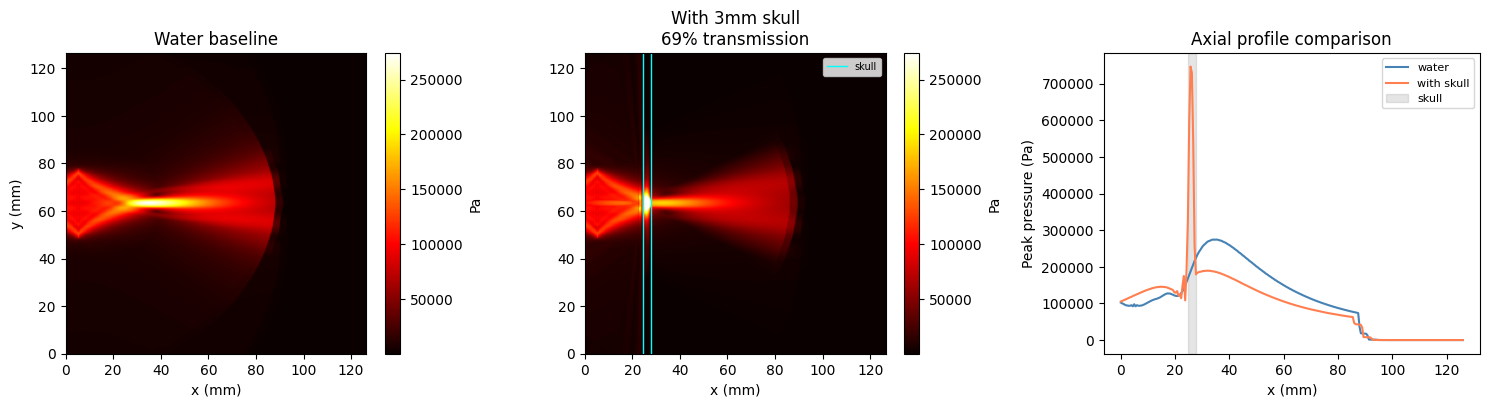

Saved to 04_skull_layer.png


In [5]:
# --- Parameters ---
freq         = 500e3
c0           = 1482.0
rho0         = 1000.0
focal_length = 30e-3
aperture     = 30e-3
transducer_x = 10

wavelength = c0 / freq
dx = wavelength / 6

Nx, Ny = 256, 256

# --- Skull properties (Mueller et al.) ---
c_skull   = 2900.0
rho_skull = 1900.0

# Build grid using skull speed for stable dt
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_skull, cfl=0.3)
n_time = kgrid.Nt
print(f"dt={kgrid.dt:.2e}s, Nt={n_time}")

# --- Skull geometry ---
skull_thickness_mm = 3.0
skull_start_x = transducer_x + int(20e-3 / dx)
skull_end_x   = skull_start_x + int(skull_thickness_mm * 1e-3 / dx)
print(f"Skull: x={skull_start_x*dx*1e3:.1f}mm to {skull_end_x*dx*1e3:.1f}mm")

# --- Heterogeneous medium (NO attenuation map — keep it simple first) ---
sound_speed_map = np.ones((Nx, Ny), dtype=float) * c0
density_map     = np.ones((Nx, Ny), dtype=float) * rho0
sound_speed_map[skull_start_x:skull_end_x, :] = c_skull
density_map[skull_start_x:skull_end_x, :]     = rho_skull

medium = kWaveMedium(
    sound_speed=sound_speed_map,
    density=density_map,
)

# --- Source ---
center_y     = Ny // 2
aperture_pts = int(aperture / dx)
half_ap      = aperture_pts // 2
source_y_indices = np.arange(center_y - half_ap, center_y + half_ap)
n_sources    = len(source_y_indices)

focal_point_x = transducer_x + int((focal_length + 3.5e-3) / dx)
focal_point_y = center_y

burst = tone_burst(1/kgrid.dt, freq, 5).flatten()
print(f"Burst length: {len(burst)} samples")

delays_s = np.zeros(n_sources)
for i, sy in enumerate(source_y_indices):
    dist = np.sqrt(((transducer_x - focal_point_x) * dx)**2 +
                   ((sy - focal_point_y) * dx)**2)
    delays_s[i] = dist / c0
delays_s = delays_s.max() - delays_s
max_delay_steps = int(np.max(delays_s) / kgrid.dt)

n_time_needed = max_delay_steps + len(burst) + 100
if n_time < n_time_needed:
    n_time = n_time_needed
    kgrid.t_array = np.arange(0, n_time) * kgrid.dt

source_signals = np.zeros((n_sources, n_time))
for i in range(n_sources):
    d = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), n_time)
    source_signals[i, d:end] = burst[:end-d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[transducer_x, source_y_indices] = 1
source.p = source_signals

# --- Sensor ---
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# --- Run with skull ---
print("Running with skull...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max_skull = sensor_data['p_max'].reshape(Nx, Ny)

# Check for NaN
if np.isnan(p_max_skull).any():
    print("WARNING: NaN detected in skull simulation")
else:
    print(f"Skull sim OK — max pressure: {np.nanmax(p_max_skull)/1e3:.1f} kPa")

# --- Run water baseline ---
medium_water = kWaveMedium(sound_speed=c0, density=rho0)
print("Running water baseline...")
sensor_data_water = kspaceFirstOrder(kgrid, medium_water, source, sensor, device='gpu', dtype='float32')
p_max_water = sensor_data_water['p_max'].reshape(Nx, Ny)
print(f"Water sim OK — max pressure: {np.max(p_max_water)/1e3:.1f} kPa")

# --- Results ---
# Only measure in post-skull region to avoid reflection artifacts
post_skull_water = p_max_water[skull_end_x:, :]
post_skull_skull = p_max_skull[skull_end_x:, :]

peak_water = np.max(post_skull_water)
peak_skull = np.max(post_skull_skull)
transmission = peak_skull / peak_water * 100

print(f"\n=== SKULL VALIDATION ===")
print(f"Peak pressure (water, post-skull):      {peak_water/1e3:.1f} kPa")
print(f"Peak pressure (with skull, post-skull): {peak_skull/1e3:.1f} kPa")
print(f"Transmission:               {transmission:.1f}%")
print(f"Pressure loss:              {100-transmission:.1f}%")
print(f"Mueller et al. expected:    ~65% transmission (35% loss)")

# --- Reflection coefficient check ---
Z_water = rho0 * c0
Z_skull = rho_skull * c_skull
R = ((Z_skull - Z_water) / (Z_skull + Z_water))**2
T_theoretical = 1 - R
print(f"\nTheoretical transmission (impedance only): {T_theoretical*100:.1f}%")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = np.max(p_max_water)

ax = axes[0]
im = ax.imshow(p_max_water.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot', vmax=vmax)
ax.set_title('Water baseline')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.colorbar(im, ax=ax, label='Pa')

ax = axes[1]
im = ax.imshow(p_max_skull.T, aspect='equal',
               extent=[0, Nx*dx*1e3, 0, Ny*dx*1e3],
               origin='lower', cmap='hot', vmax=vmax)
ax.axvline(x=skull_start_x*dx*1e3, color='cyan', lw=1)
ax.axvline(x=skull_end_x*dx*1e3,   color='cyan', lw=1, label='skull')
ax.set_title(f'With 3mm skull\n{transmission:.0f}% transmission')
ax.set_xlabel('x (mm)')
ax.legend(fontsize=7)
plt.colorbar(im, ax=ax, label='Pa')

ax = axes[2]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max_water[:, center_y], label='water', color='steelblue')
ax.plot(x_mm, p_max_skull[:, center_y], label='with skull', color='coral')
ax.axvspan(skull_start_x*dx*1e3, skull_end_x*dx*1e3,
           alpha=0.2, color='gray', label='skull')
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile comparison')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('04_skull_layer.png', dpi=150)
plt.show()
print("Saved to 04_skull_layer.png")

# Round Skull Setups

### 05_circular_skull_setup
Reusable geometry: water coupling outside → circular skull ring → brain interior. No sources placed here — add them in subsequent test cells.

> **Note:** The exterior is water (c=1482, ρ=1000), not air. In real TUS the transducer always sits in a water coupling bath against the skull — there is no bare air-skull interface. Using air causes a density ratio of ~1570:1 at the bone boundary which overflows k-Wave's pseudospectral FFT solver regardless of CFL setting.

dx = 0.296 mm  (10 PPW)
Brain radius : 40.0 mm  (135.0 px)
Skull outer  : 45.0 mm  (151.8 px)
Grid edge    : 75.9 mm from centre
Skull-to-edge margin: 30.9 mm

kgrid: dt=1.02e-08 s,  Nt=7241
Estimated sim time per run: 7241 steps  (~74.0 µs of acoustic time)


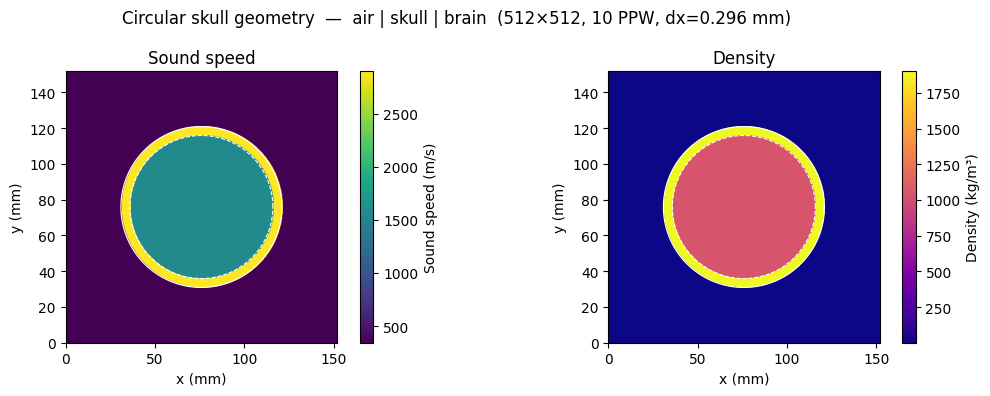

In [26]:
# ── Acoustic properties ──────────────────────────────────────────────────────
# Exterior = air: the device is mounted directly on the skull in-vivo (monkey).
# There is no water bath.  The transducer elements will be placed at the skull
# outer surface so the air medium never enters the acoustic propagation path.
c_air    = 343.0;    rho_air    = 1.21     # air (exterior / ambient)
c_skull  = 2900.0;   rho_skull  = 1900.0   # cortical bone (Mueller et al.)
c_brain  = 1560.0;   rho_brain  = 1040.0   # brain tissue

# ── Grid ─────────────────────────────────────────────────────────────────────
freq = 500e3
c0   = 1482.0          # water — used only for wavelength/dx sizing
wavelength = c0 / freq # ~3 mm

# Resolution: 10 points per wavelength (up from 6).
# Skull wall (~5 mm) spans ~17 grid points — enough to resolve the impedance
# ramp without numerical smearing.  Tradeoff: ~9× more compute than 6 PPW.
dx = wavelength / 10   # ~0.296 mm per grid point

Nx, Ny = 512, 512      # physical size ≈ 151 mm × 151 mm
cx, cy = Nx // 2, Ny // 2  # skull centre (grid indices)

# ── Skull geometry ────────────────────────────────────────────────────────────
brain_radius_mm    = 40.0   # inner radius of skull (brain surface)
skull_thickness_mm =  5.0   # skull wall thickness

skull_inner_px = brain_radius_mm                        * 1e-3 / dx
skull_outer_px = (brain_radius_mm + skull_thickness_mm) * 1e-3 / dx

print(f"dx = {dx*1e3:.3f} mm  ({wavelength/dx:.0f} PPW)")
print(f"Brain radius : {brain_radius_mm:.1f} mm  ({skull_inner_px:.1f} px)")
print(f"Skull outer  : {brain_radius_mm + skull_thickness_mm:.1f} mm  ({skull_outer_px:.1f} px)")
print(f"Grid edge    : {Nx//2 * dx*1e3:.1f} mm from centre")
print(f"Skull-to-edge margin: {(Nx//2 * dx - (brain_radius_mm + skull_thickness_mm)*1e-3)*1e3:.1f} mm")

# ── Build radial distance map ─────────────────────────────────────────────────
XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R = np.sqrt((XX - cx)**2 + (YY - cy)**2)

# ── Assign material properties ────────────────────────────────────────────────
sound_speed_map = np.full((Nx, Ny), c_air,   dtype=float)
density_map     = np.full((Nx, Ny), rho_air, dtype=float)

skull_mask = (R >= skull_inner_px) & (R < skull_outer_px)
brain_mask =  R <  skull_inner_px

sound_speed_map[skull_mask] = c_skull;  density_map[skull_mask] = rho_skull
sound_speed_map[brain_mask] = c_brain;  density_map[brain_mask] = rho_brain

# ── kWave grid and medium ─────────────────────────────────────────────────────
# CFL=0.1: skull/air density contrast ~1570:1 requires a tighter CFL for
# spectral-method stability.
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_skull, cfl=0.1)

medium = kWaveMedium(
    sound_speed=sound_speed_map,
    density=density_map,
)

print(f"\nkgrid: dt={kgrid.dt:.2e} s,  Nt={kgrid.Nt}")
print(f"Estimated sim time per run: {kgrid.Nt} steps  "
      f"(~{kgrid.Nt * kgrid.dt * 1e6:.1f} µs of acoustic time)")

# ── Visualise geometry ────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta  = np.linspace(0, 2*np.pi, 360)
cx_mm, cy_mm = cx*dx*1e3, cy*dx*1e3
r_inner_mm   = skull_inner_px * dx * 1e3
r_outer_mm   = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
im = ax.imshow(sound_speed_map.T, origin='lower', extent=extent, cmap='viridis')
plt.colorbar(im, ax=ax, label='Sound speed (m/s)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta), 'w--', lw=0.8)
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta), 'w-',  lw=0.8)
ax.set_title('Sound speed'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')

ax = axes[1]
im = ax.imshow(density_map.T, origin='lower', extent=extent, cmap='plasma')
plt.colorbar(im, ax=ax, label='Density (kg/m³)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta), 'w--', lw=0.8)
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta), 'w-',  lw=0.8)
ax.set_title('Density'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')

plt.suptitle(f'Circular skull geometry  —  air | skull | brain  '
             f'({Nx}×{Ny}, {wavelength/dx:.0f} PPW, dx={dx*1e3:.3f} mm)')
plt.tight_layout()
plt.savefig('05_circular_skull_setup.png', dpi=150)
plt.show()

### 05.5 — Half-skull time reversal
**Hypothesis:** the ~4.4 mm near-shift in cell 09 is caused by far-wall reflections contaminating the forward recording. In a full circular skull, the point source at the target sends waves in all directions; right-going waves hit the far skull wall, bounce back, and arrive at the transducer with an extra delay. When time-reversed, those reflected components drive energy to the wrong depth.

**Fix:** remove the right-hemisphere skull ring for the *forward* sim only — the right-going wave exits freely. The clean element recordings are then time-reversed and replayed into the **full skull** to test focus quality in the real geometry.

Variables use the `_half` / `_h` suffix so they coexist with the full-skull variables from cell 05.

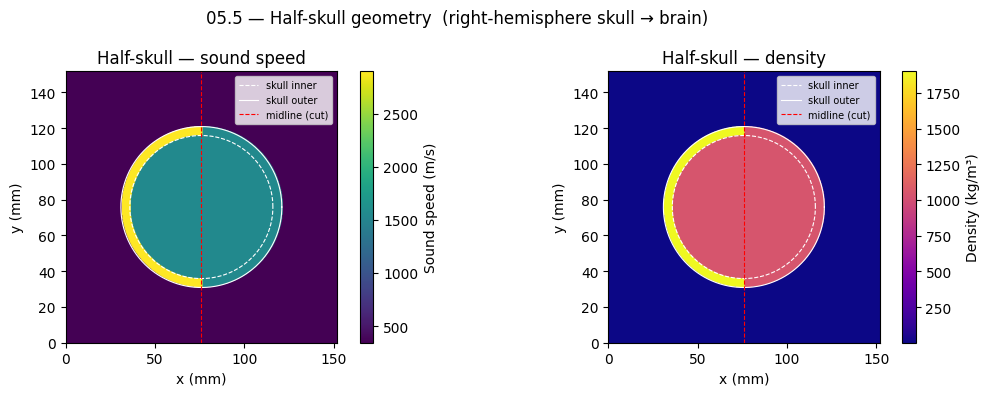

medium_half ready.
Transducer elements: 100  (aperture 30 mm on skull surface)

Step 1: forward sim on half skull…


k-Wave: 100%|██████████| 7241/7241 [00:07<00:00, 1008.05step/s]


  Recorded: (100, 7241)  (elements × time steps)


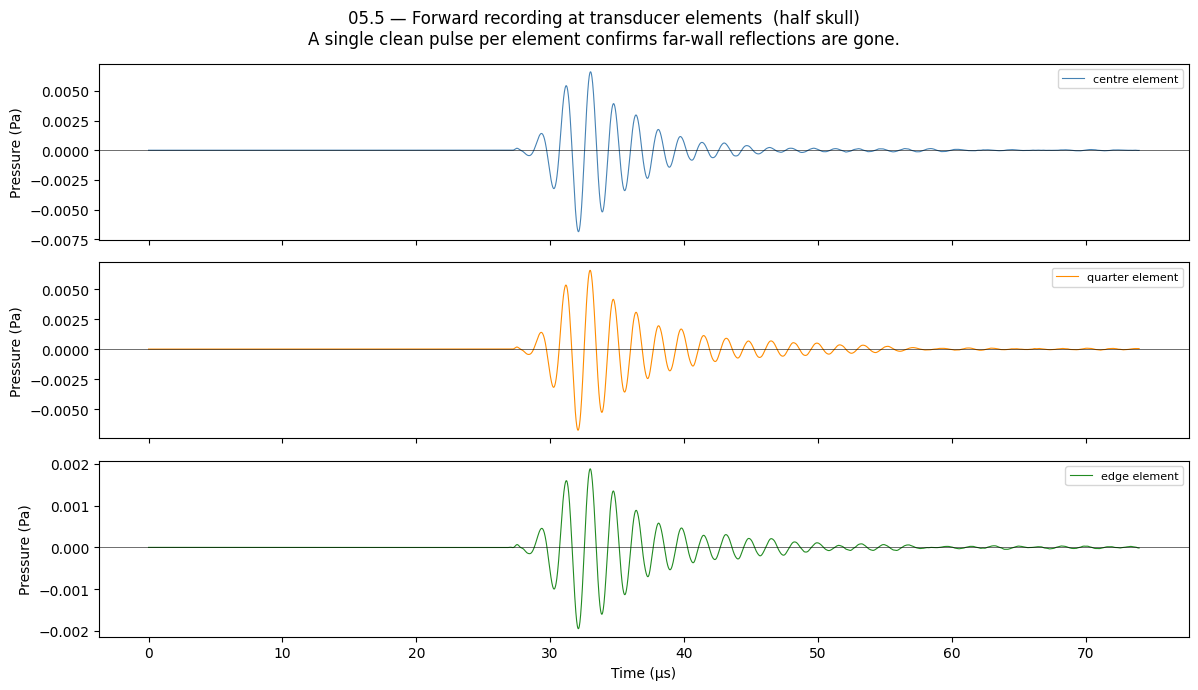

Step 2: backward sim on half skull…


k-Wave: 100%|██████████| 7241/7241 [00:12<00:00, 585.43step/s]


Done — global max: 0.0 kPa

=== FOCUS REPORT (half-skull TR, both sims on half skull) ===
Target  : (75.9, 75.9) mm
Actual  : (71.1, 75.9) mm
Error   : 4.7 mm
Peak P  : 0.0 kPa


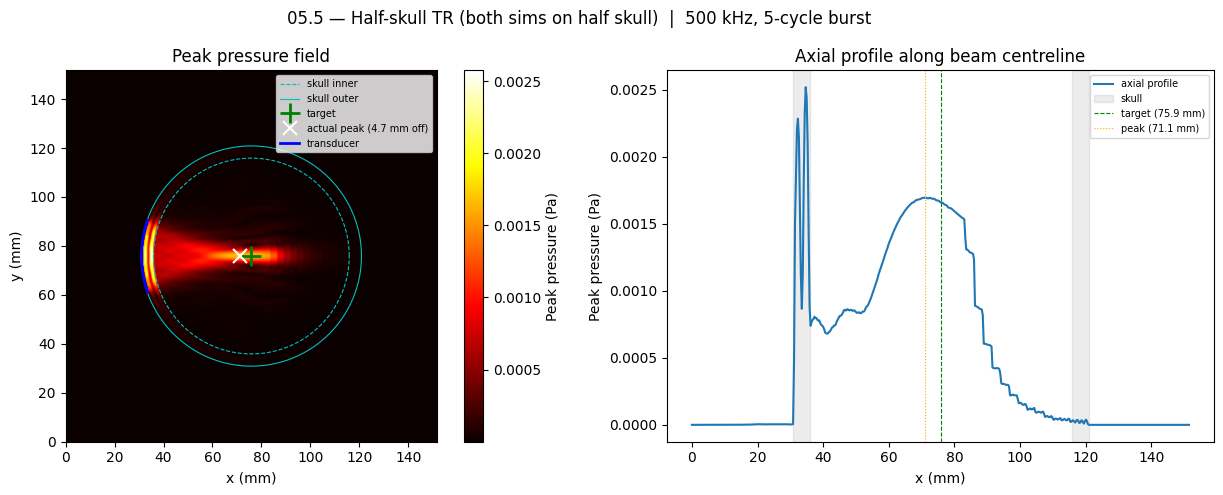

In [7]:
# Requires cell 05 to have been run first.
#
# Step 1: build the half-skull medium (right-hemisphere skull → brain).
# Step 2: run forward + backward entirely in the half skull to verify TR works
#         once far-wall reflections are removed.
# Diagnostic plots show element waveforms (clean vs echo) and the focus field.

# ── Half-skull geometry ───────────────────────────────────────────────────────
sound_speed_map_half = sound_speed_map.copy()
density_map_half     = density_map.copy()

right_skull_mask = skull_mask & (XX > cx)
sound_speed_map_half[right_skull_mask] = c_brain
density_map_half[right_skull_mask]     = rho_brain

medium_half = kWaveMedium(sound_speed=sound_speed_map_half, density=density_map_half)

# ── Geometry plot ─────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, arr, label, cmap in zip(
        axes,
        [sound_speed_map_half, density_map_half],
        ['Sound speed (m/s)', 'Density (kg/m³)'],
        ['viridis', 'plasma']):
    im = ax.imshow(arr.T, origin='lower', extent=extent, cmap=cmap)
    plt.colorbar(im, ax=ax, label=label)
    ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
            'w--', lw=0.8, label='skull inner')
    ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
            'w-',  lw=0.8, label='skull outer')
    ax.axvline(x=cx_mm_plot, color='red', lw=0.8, ls='--', label='midline (cut)')
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    ax.legend(fontsize=7)
axes[0].set_title('Half-skull — sound speed')
axes[1].set_title('Half-skull — density')
plt.suptitle('05.5 — Half-skull geometry  (right-hemisphere skull → brain)')
plt.tight_layout()
plt.savefig('05_5_half_skull_geometry.png', dpi=150)
plt.show()
print("medium_half ready.")

# ── Conforming array (same geometry as cells 07–09) ───────────────────────────
target_x, target_y = cx, cy
aperture_mm = 30.0
half_ap_px  = int((aperture_mm / 2) * 1e-3 / dx)

src_x_h, src_y_h = [], []
for y_i in np.arange(cy - half_ap_px, cy + half_ap_px):
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        src_x_h.append(cx - int(np.sqrt(skull_outer_px**2 - dy**2)))
        src_y_h.append(int(y_i))
src_x_h  = np.array(src_x_h)
src_y_h  = np.array(src_y_h)
n_elem_h = len(src_x_h)
print(f"Transducer elements: {n_elem_h}  (aperture {aperture_mm:.0f} mm on skull surface)")

elem_mask_h = np.zeros((Nx, Ny))
for xi, yi in zip(src_x_h, src_y_h):
    elem_mask_h[xi, yi] = 1

# ── Step 1: Forward sim on HALF skull ────────────────────────────────────────
src_fwd_h        = kSource()
src_fwd_h.p_mask = np.zeros((Nx, Ny))
src_fwd_h.p_mask[target_x, target_y] = 1
src_fwd_h.p     = tone_burst(1/kgrid.dt, freq, 5).flatten()

sen_fwd_h        = kSensor()
sen_fwd_h.mask   = elem_mask_h.copy()
sen_fwd_h.record = ['p']

print("\nStep 1: forward sim on half skull…")
data_fwd_h      = kspaceFirstOrder(kgrid, medium_half, src_fwd_h, sen_fwd_h, device='gpu', dtype='float32')
p_at_elements_h = data_fwd_h['p']   # shape: (n_elem, Nt)
print(f"  Recorded: {p_at_elements_h.shape}  (elements × time steps)")

# ── Diagnostic: element waveforms ────────────────────────────────────────────
# Show centre, quarter-point, and edge element to reveal whether
# far-wall reflections (late-arriving second pulse) are present.
t_us = np.arange(kgrid.Nt) * kgrid.dt * 1e6   # time axis in µs

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
sample_indices = [n_elem_h // 2, n_elem_h // 4, 0]   # centre, quarter, edge
labels         = ['centre element', 'quarter element', 'edge element']
colors         = ['steelblue', 'darkorange', 'forestgreen']

for ax, idx, lbl, col in zip(axes, sample_indices, labels, colors):
    ax.plot(t_us, p_at_elements_h[idx], color=col, lw=0.8, label=lbl)
    ax.set_ylabel('Pressure (Pa)')
    ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='k', lw=0.4)

axes[-1].set_xlabel('Time (µs)')
plt.suptitle('05.5 — Forward recording at transducer elements  (half skull)\n'
             'A single clean pulse per element confirms far-wall reflections are gone.')
plt.tight_layout()
plt.savefig('05_5_element_waveforms.png', dpi=150)
plt.show()

# ── Step 2: Backward sim on HALF skull ───────────────────────────────────────
p_reversed_h = p_at_elements_h[:, ::-1]

src_bwd_h        = kSource()
src_bwd_h.p_mask = elem_mask_h.copy()
src_bwd_h.p      = p_reversed_h

sen_bwd_h        = kSensor()
sen_bwd_h.mask   = np.ones((Nx, Ny))
sen_bwd_h.record = ['p_max']

print("Step 2: backward sim on half skull…")
data_bwd_h = kspaceFirstOrder(kgrid, medium_half, src_bwd_h, sen_bwd_h, device='gpu', dtype='float32')
p_max_h    = data_bwd_h['p_max'].reshape(Nx, Ny)
print(f"Done — global max: {np.max(p_max_h)/1e3:.1f} kPa")

# ── Focus report ──────────────────────────────────────────────────────────────
p_brain_h  = p_max_h.copy()
p_brain_h[~brain_mask] = 0
peak_idx_h = np.unravel_index(np.argmax(p_brain_h), (Nx, Ny))
peak_mm_h  = (peak_idx_h[0]*dx*1e3, peak_idx_h[1]*dx*1e3)
tgt_mm_h   = (target_x*dx*1e3, target_y*dx*1e3)
err_mm_h   = np.sqrt((peak_mm_h[0]-tgt_mm_h[0])**2 + (peak_mm_h[1]-tgt_mm_h[1])**2)

print(f"\n=== FOCUS REPORT (half-skull TR, both sims on half skull) ===")
print(f"Target  : ({tgt_mm_h[0]:.1f}, {tgt_mm_h[1]:.1f}) mm")
print(f"Actual  : ({peak_mm_h[0]:.1f}, {peak_mm_h[1]:.1f}) mm")
print(f"Error   : {err_mm_h:.1f} mm")
print(f"Peak P  : {np.max(p_brain_h)/1e3:.1f} kPa")

# ── Focus plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max_h.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm_h[0],  tgt_mm_h[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm_h[0], peak_mm_h[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm_h:.1f} mm off)')
ax.plot(src_x_h*dx*1e3, src_y_h*dx*1e3, 'b-', lw=2, label='transducer')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max_h[:, cy], label='axial profile')
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm_h[0],  color='green',  lw=0.8, ls='--', label=f'target ({tgt_mm_h[0]:.1f} mm)')
ax.axvline(x=peak_mm_h[0], color='orange', lw=0.8, ls=':',
           label=f'peak ({peak_mm_h[0]:.1f} mm)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('05.5 — Half-skull TR (both sims on half skull)  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('05_5_half_skull_tr.png', dpi=150)
plt.show()

### 06_centre_source
Single point source at the skull centre, 500 kHz 5-cycle burst — same signal as earlier tests. Uses the geometry from 05.

Running simulation...


k-Wave: 100%|██████████| 7241/7241 [00:31<00:00, 231.71step/s]


Done — max pressure: 41.7 kPa


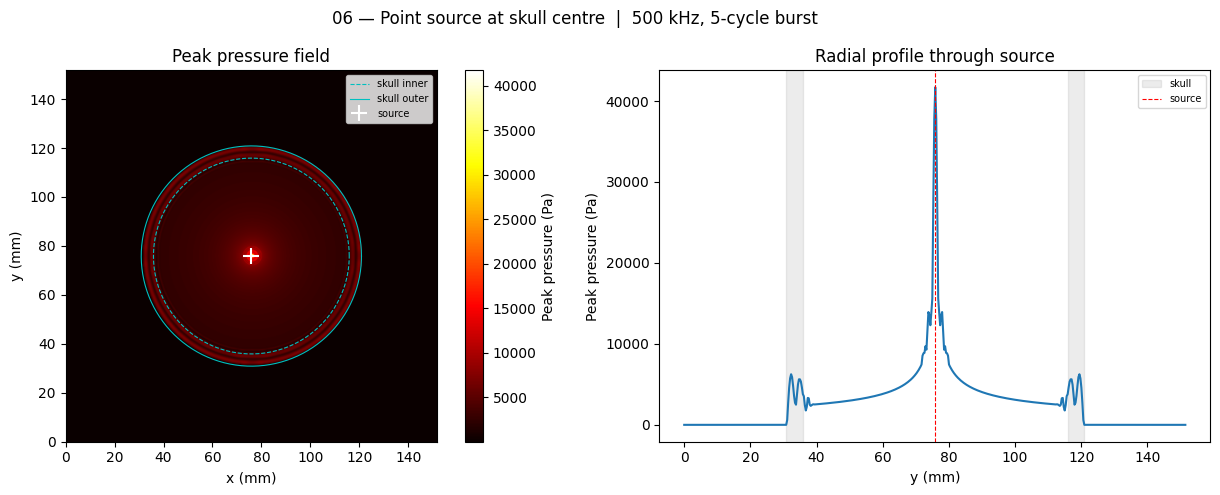

In [27]:
# Requires cell 05 to have been run first (kgrid, medium, cx, cy, dx, Nx, Ny,
# skull_inner_px, skull_outer_px, freq all come from there)

# ── Source: single point at skull centre ──────────────────────────────────────
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[cx, cy] = 1
source.p = burst * 1e5   # 100 kPa, matching earlier tests

# ── Sensor: full field, record peak pressure ──────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
cx_mm  = cx * dx * 1e3
cy_mm  = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3   # brain surface radius in mm
r_outer_mm = skull_outer_px * dx * 1e3   # outer skull radius in mm

theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 2D peak-pressure field
ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm + r_inner_mm * np.cos(theta),
        cy_mm + r_inner_mm * np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm + r_outer_mm * np.cos(theta),
        cy_mm + r_outer_mm * np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(cx_mm, cy_mm, 'w+', ms=12, mew=1.5, label='source')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

# Right: radial profile through centre
ax = axes[1]
radial = p_max[cx, :]                  # slice along y through source
y_mm   = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, radial)
ax.axvspan(cy_mm - r_outer_mm, cy_mm - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cy_mm + r_inner_mm, cy_mm + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=cy_mm, color='red', lw=0.8, linestyle='--', label='source')
ax.set_xlabel('y (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Radial profile through source')
ax.legend(fontsize=7)

plt.suptitle('06 — Point source at skull centre  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('06_centre_source.png', dpi=150)
plt.show()

### 07_external_focus
Phased linear array placed outside the skull, aimed at the brain centre. Time delays computed from straight-line distance to target (refraction ignored for this first pass — goal is to see where the wave actually lands and by how much it shifts).

Target       : (75.9, 75.9) mm
n_sources    : 100  (aperture 30 mm on skull surface)
Element x range: 105 – 113 px  (31.1 – 33.5 mm)
Max delay    : 0.10 µs  (9 steps)

Running simulation...


k-Wave: 100%|██████████| 7241/7241 [00:11<00:00, 645.88step/s]


Done — global max pressure: 25.5 kPa

=== FOCUS REPORT ===
Target  : (75.9, 75.9) mm
Actual  : (70.8, 75.9) mm
Error   : 5.0 mm
Peak P  : 16.4 kPa  (in brain)


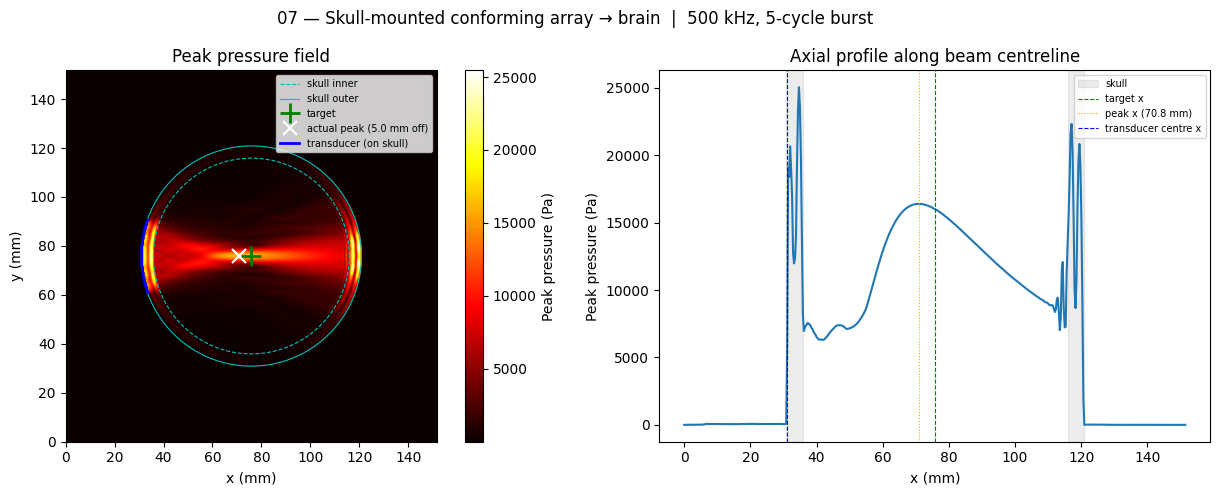

In [9]:
# Requires cell 05 to have been run first.
#
# Transducer model: conforming array mounted directly on the skull outer surface.
# Each element is placed at its corresponding point on the skull outer circle so
# there is no air gap and the source drives bone directly.  Delays are computed
# through skull + brain only (no air/water coupling segment).

# ── Target point ──────────────────────────────────────────────────────────────
target_x = cx               # aim at brain centre (change to steer)
target_y = cy

# ── Conforming array: elements placed on the skull outer surface ───────────────
# For each element at vertical position y_i, its x position on the left skull arc:
#   x_i = cx - floor( sqrt(skull_outer_px^2 - (y_i - cy)^2) )
# floor() puts the point just inside skull material.
aperture_mm  = 30.0
half_ap_px   = int((aperture_mm / 2) * 1e-3 / dx)
candidate_ys = np.arange(cy - half_ap_px, cy + half_ap_px)

src_x, src_y = [], []
for y_i in candidate_ys:
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:          # within the skull circle's y-extent
        x_i = cx - int(np.sqrt(skull_outer_px**2 - dy**2))
        src_x.append(x_i)
        src_y.append(int(y_i))

src_x     = np.array(src_x)
src_y     = np.array(src_y)
n_sources = len(src_x)

print(f"Target       : ({target_x*dx*1e3:.1f}, {target_y*dx*1e3:.1f}) mm")
print(f"n_sources    : {n_sources}  (aperture {aperture_mm:.0f} mm on skull surface)")
print(f"Element x range: {src_x.min()} – {src_x.max()} px  "
      f"({src_x.min()*dx*1e3:.1f} – {src_x.max()*dx*1e3:.1f} mm)")

# ── Multi-medium travel-time delays: skull → brain ────────────────────────────
# Source is at the skull outer surface; path = skull segment + brain segment.
# Find the skull/brain boundary by intersecting each ray with the inner circle.

def _ray_circle_t(ox, oy, ux, uy, R):
    """
    Parametric distance t (m) where unit-ray from (ox, oy) first enters a
    circle of radius R at the origin.  Returns (t_entry, t_exit) or (None, None).
    """
    b    = 2.0 * (ox * ux + oy * uy)
    c    = ox * ox + oy * oy - R * R
    disc = b * b - 4.0 * c
    if disc < 0.0:
        return None, None
    sq = np.sqrt(disc)
    return (-b - sq) / 2.0, (-b + sq) / 2.0

R_inner_m = skull_inner_px * dx   # brain surface radius (m)

travel_times = np.zeros(n_sources)
for i in range(n_sources):
    xi, yi = src_x[i], src_y[i]
    vec_x  = (target_x - xi) * dx
    vec_y  = (target_y - yi) * dx
    dist_m = np.sqrt(vec_x**2 + vec_y**2)
    ux, uy = vec_x / dist_m, vec_y / dist_m

    # Ray origin relative to skull centre
    ox = (xi - cx) * dx
    oy = (yi - cy) * dx

    t_br_in, _ = _ray_circle_t(ox, oy, ux, uy, R_inner_m)

    if t_br_in is None or t_br_in < 0:
        travel_times[i] = dist_m / c_brain           # fallback
    else:
        travel_times[i] = (t_br_in          / c_skull +   # through skull
                           (dist_m - t_br_in) / c_brain)  # through brain

delays_s = travel_times.max() - travel_times         # centre element fires last
max_delay_steps = int(delays_s.max() / kgrid.dt)
print(f"Max delay    : {delays_s.max()*1e6:.2f} µs  ({max_delay_steps} steps)")

# ── Source signals ────────────────────────────────────────────────────────────
burst  = tone_burst(1/kgrid.dt, freq, 5).flatten()
n_time = max_delay_steps + len(burst) + 200
if n_time > kgrid.Nt:
    kgrid.t_array = np.arange(n_time) * kgrid.dt

source_signals = np.zeros((n_sources, kgrid.Nt))
for i in range(n_sources):
    d   = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), kgrid.Nt)
    source_signals[i, d:end] = burst[:end - d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    source.p_mask[xi, yi] = 1
source.p = source_signals

# ── Sensor ────────────────────────────────────────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — global max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Find peak inside brain ────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa  (in brain)")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta  = np.linspace(0, 2*np.pi, 360)
cx_mm, cy_mm = cx*dx*1e3, cy*dx*1e3
r_inner_mm   = skull_inner_px * dx * 1e3
r_outer_mm   = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm + r_inner_mm*np.cos(theta), cy_mm + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm + r_outer_mm*np.cos(theta), cy_mm + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
# Draw transducer arc on skull surface
ax.plot(src_x * dx * 1e3, src_y * dx * 1e3, 'b-', lw=2, label='transducer (on skull)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm - r_outer_mm, cx_mm - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm + r_inner_mm, cx_mm + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.axvline(x=src_x[n_sources//2]*dx*1e3, color='blue', lw=0.8, linestyle='--',
           label='transducer centre x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('07 — Skull-mounted conforming array → brain  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('07_external_focus.png', dpi=150)
plt.show()

### 08_fermat_focus
Same skull-mounted conforming array as cell 07, but delays computed via **Fermat's principle** rather than straight-line distances. For each element the crossing point on the skull-brain boundary is numerically optimised so that `d_skull/c_skull + d_brain/c_brain` is minimised — this automatically satisfies Snell's law and removes the ~5 mm near-shift caused by skull-brain refraction.

Target       : (75.9, 75.9) mm
n_sources    : 100
Max delay    : 0.10 µs  (9 steps)

Running simulation...


k-Wave: 100%|██████████| 7241/7241 [00:11<00:00, 614.98step/s]


Done — global max pressure: 25.5 kPa

=== FOCUS REPORT ===
Target  : (75.9, 75.9) mm
Actual  : (70.8, 75.9) mm
Error   : 5.0 mm
Peak P  : 16.4 kPa  (in brain)


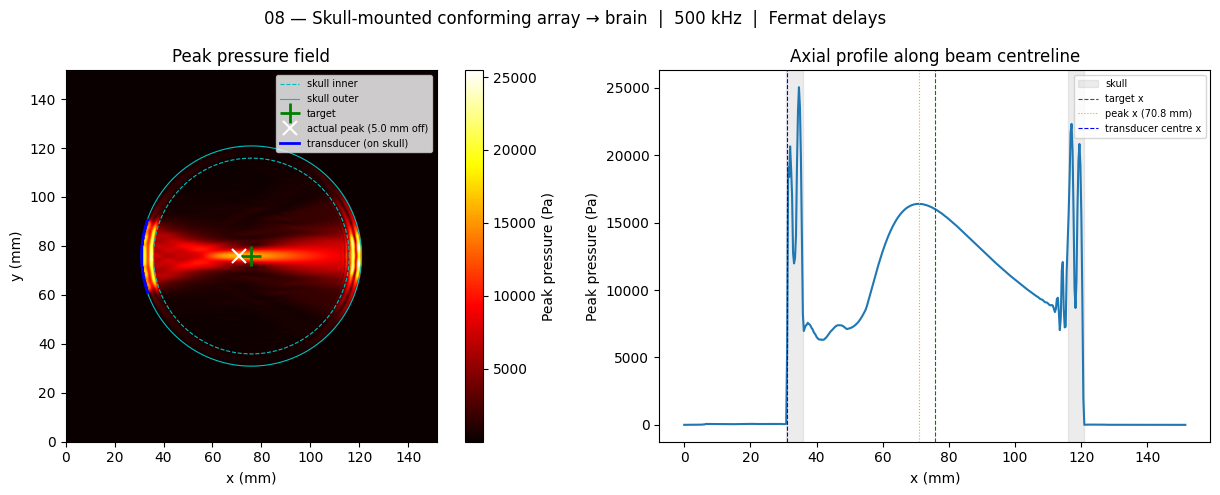

In [10]:
# Requires cell 05 to have been run first.
#
# Delays use Fermat's principle: for each element, the crossing point on the
# skull-brain boundary is optimised to minimise skull_path/c_skull + brain_path/c_brain.
# This satisfies Snell's law at the boundary and corrects the near-shift that
# straight-ray delays produce.

from scipy.optimize import minimize_scalar

# ── Target point ──────────────────────────────────────────────────────────────
target_x = cx               # brain centre — change to steer
target_y = cy

# ── Conforming array on skull outer surface ───────────────────────────────────
aperture_mm  = 30.0
half_ap_px   = int((aperture_mm / 2) * 1e-3 / dx)
candidate_ys = np.arange(cy - half_ap_px, cy + half_ap_px)

src_x, src_y = [], []
for y_i in candidate_ys:
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        x_i = cx - int(np.sqrt(skull_outer_px**2 - dy**2))
        src_x.append(x_i)
        src_y.append(int(y_i))

src_x     = np.array(src_x)
src_y     = np.array(src_y)
n_sources = len(src_x)

print(f"Target       : ({target_x*dx*1e3:.1f}, {target_y*dx*1e3:.1f}) mm")
print(f"n_sources    : {n_sources}")

# ── Fermat-optimal delays ─────────────────────────────────────────────────────
cx_m      = cx * dx
cy_m      = cy * dx
R_inner_m = skull_inner_px * dx

travel_times = np.zeros(n_sources)
for i in range(n_sources):
    xi_m = src_x[i] * dx
    yi_m = src_y[i] * dx
    tx_m = target_x * dx
    ty_m = target_y * dx

    phi_elem = np.arctan2(yi_m - cy_m, xi_m - cx_m)

    def time_fn(phi):
        Px = cx_m + R_inner_m * np.cos(phi)
        Py = cy_m + R_inner_m * np.sin(phi)
        return (np.sqrt((xi_m - Px)**2 + (yi_m - Py)**2) / c_skull +
                np.sqrt((tx_m - Px)**2 + (ty_m - Py)**2) / c_brain)

    res = minimize_scalar(time_fn,
                          bounds=(phi_elem - np.pi / 2, phi_elem + np.pi / 2),
                          method='bounded')
    travel_times[i] = res.fun

delays_s = travel_times.max() - travel_times
max_delay_steps = int(delays_s.max() / kgrid.dt)
print(f"Max delay    : {delays_s.max()*1e6:.2f} µs  ({max_delay_steps} steps)")

# ── Source signals ────────────────────────────────────────────────────────────
burst  = tone_burst(1/kgrid.dt, freq, 5).flatten()
n_time = max_delay_steps + len(burst) + 200
if n_time > kgrid.Nt:
    kgrid.t_array = np.arange(n_time) * kgrid.dt

source_signals = np.zeros((n_sources, kgrid.Nt))
for i in range(n_sources):
    d   = int(delays_s[i] / kgrid.dt)
    end = min(d + len(burst), kgrid.Nt)
    source_signals[i, d:end] = burst[:end - d] * 1e5

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    source.p_mask[xi, yi] = 1
source.p = source_signals

# ── Sensor ────────────────────────────────────────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)
print(f"Done — global max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Find peak inside brain ────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa  (in brain)")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
ax.plot(src_x * dx * 1e3, src_y * dx * 1e3, 'b-', lw=2, label='transducer (on skull)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.axvline(x=src_x[n_sources//2]*dx*1e3, color='blue', lw=0.8, linestyle='--',
           label='transducer centre x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('08 — Skull-mounted conforming array → brain  |  500 kHz  |  Fermat delays')
plt.tight_layout()
plt.savefig('08_fermat_focus.png', dpi=150)
plt.show()

### 09_time_reversal
Two-step time-reversal focus. **Step 1 (forward):** place a point source at the target, run the simulation, record the pressure time-series at every transducer element. **Step 2 (backward):** flip those recordings in time and replay them as source signals. The time-reversed signals carry exactly the phase correction needed to focus at the target — they account for refraction, impedance-mismatch reflections, and all other propagation effects automatically, without any analytical delay model.

Transducer elements: 100  (aperture 30 mm on skull surface)
Step 1: forward simulation (target → elements)…


k-Wave: 100%|██████████| 7241/7241 [00:06<00:00, 1080.68step/s]


  Recorded: (100, 7241)  (elements × time steps)
Step 2: backward simulation (time-reversed focus)…


k-Wave: 100%|██████████| 7241/7241 [00:11<00:00, 618.09step/s]


Done — global max: 0.0 kPa

=== FOCUS REPORT ===
Target  : (75.9, 75.9) mm
Actual  : (71.1, 75.9) mm
Error   : 4.7 mm
Peak P  : 0.0 kPa


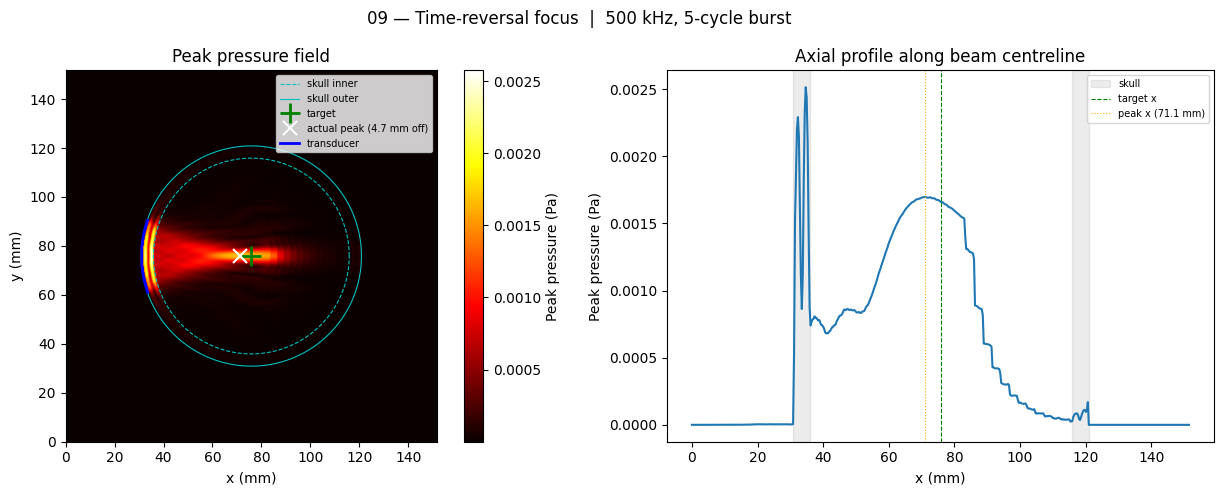

In [11]:
# Requires cell 05 to have been run first.
#
# Time-reversal focusing — two simulations:
#   1. Forward:  point source at target → record pressure at each transducer element
#   2. Backward: time-reversed recordings → focus pressure back at the target

# ── Target ────────────────────────────────────────────────────────────────────
target_x = cx
target_y = cy

# ── Conforming array (same geometry as cells 07/08) ───────────────────────────
aperture_mm = 30.0
half_ap_px  = int((aperture_mm / 2) * 1e-3 / dx)

src_x, src_y = [], []
for y_i in np.arange(cy - half_ap_px, cy + half_ap_px):
    dy = int(y_i) - cy
    if abs(dy) < skull_outer_px:
        src_x.append(cx - int(np.sqrt(skull_outer_px**2 - dy**2)))
        src_y.append(int(y_i))
src_x = np.array(src_x)
src_y = np.array(src_y)
n_elem = len(src_x)
print(f"Transducer elements: {n_elem}  (aperture {aperture_mm:.0f} mm on skull surface)")

# ── Build element mask (used for both forward sensor and backward source) ──────
elem_mask = np.zeros((Nx, Ny))
for xi, yi in zip(src_x, src_y):
    elem_mask[xi, yi] = 1

# ── Step 1: Forward simulation — point source at target ───────────────────────
src_fwd       = kSource()
src_fwd.p_mask = np.zeros((Nx, Ny))
src_fwd.p_mask[target_x, target_y] = 1
src_fwd.p     = tone_burst(1/kgrid.dt, freq, 5).flatten()

sen_fwd        = kSensor()
sen_fwd.mask   = elem_mask.copy()
sen_fwd.record = ['p']          # full time-series at every element

print("Step 1: forward simulation (target → elements)…")
data_fwd = kspaceFirstOrder(kgrid, medium, src_fwd, sen_fwd, device='gpu', dtype='float32')
p_at_elements = data_fwd['p']   # shape: (n_elem, Nt)
print(f"  Recorded: {p_at_elements.shape}  (elements × time steps)")

# ── Step 2: Backward simulation — time-reversed signals ───────────────────────
p_reversed = p_at_elements[:, ::-1]   # flip each element's signal in time

src_bwd        = kSource()
src_bwd.p_mask = elem_mask.copy()
src_bwd.p      = p_reversed

sen_bwd        = kSensor()
sen_bwd.mask   = np.ones((Nx, Ny))
sen_bwd.record = ['p_max']

print("Step 2: backward simulation (time-reversed focus)…")
data_bwd = kspaceFirstOrder(kgrid, medium, src_bwd, sen_bwd, device='gpu', dtype='float32')
p_max = data_bwd['p_max'].reshape(Nx, Ny)
print(f"Done — global max: {np.max(p_max)/1e3:.1f} kPa")

# ── Focus report ──────────────────────────────────────────────────────────────
p_brain = p_max.copy()
p_brain[~brain_mask] = 0
peak_idx = np.unravel_index(np.argmax(p_brain), (Nx, Ny))
peak_mm  = (peak_idx[0]*dx*1e3, peak_idx[1]*dx*1e3)
tgt_mm   = (target_x*dx*1e3,    target_y*dx*1e3)
err_mm   = np.sqrt((peak_mm[0]-tgt_mm[0])**2 + (peak_mm[1]-tgt_mm[1])**2)

print(f"\n=== FOCUS REPORT ===")
print(f"Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm")
print(f"Actual  : ({peak_mm[0]:.1f}, {peak_mm[1]:.1f}) mm")
print(f"Error   : {err_mm:.1f} mm")
print(f"Peak P  : {np.max(p_brain)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta      = np.linspace(0, 2*np.pi, 360)
cx_mm_plot = cx * dx * 1e3
cy_mm_plot = cy * dx * 1e3
r_inner_mm = skull_inner_px * dx * 1e3
r_outer_mm = skull_outer_px * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
ax.plot(cx_mm_plot + r_inner_mm*np.cos(theta), cy_mm_plot + r_inner_mm*np.sin(theta),
        'c--', lw=0.8, label='skull inner')
ax.plot(cx_mm_plot + r_outer_mm*np.cos(theta), cy_mm_plot + r_outer_mm*np.sin(theta),
        'c-',  lw=0.8, label='skull outer')
ax.plot(tgt_mm[0],  tgt_mm[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm[0], peak_mm[1], 'wx',  ms=10, mew=1.5,
        label=f'actual peak ({err_mm:.1f} mm off)')
ax.plot(src_x*dx*1e3, src_y*dx*1e3, 'b-', lw=2, label='transducer')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
ax.plot(x_mm, p_max[:, cy])
ax.axvspan(cx_mm_plot - r_outer_mm, cx_mm_plot - r_inner_mm, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm_plot + r_inner_mm, cx_mm_plot + r_outer_mm, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm[0],  color='green',  lw=0.8, linestyle='--', label='target x')
ax.axvline(x=peak_mm[0], color='orange', lw=0.8, linestyle=':',
           label=f'peak x ({peak_mm[0]:.1f} mm)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('09 — Time-reversal focus  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('09_time_reversal.png', dpi=150)
plt.show()

### 10_flat_transducer_tr
Two changes from cells 07–09:
1. **Water exterior** instead of air — matches gel coupling used in vivo. Removes the 13,000:1 air/skull impedance ratio that forced CFL=0.1 and created numerical stiffness; CFL=0.3 is now stable (3× fewer time steps).
2. **Flat transducer** at a fixed x, 5 mm standoff from the skull — matches the actual experimental hardware.

Time-reversal is used for focusing, as in cell 09. If the near-skull focus shift persists after both changes, it isolates skull geometry (thickness, curvature) as the root cause rather than source/medium modelling artefacts.

In [ ]:
# Self-contained -- does not require cell 05 to have been run first.
#
# Key differences from cell 09:
#   - Exterior medium = water (gel coupling), not air -> CFL=0.3, 3x fewer steps
#   - Flat transducer: finite-aperture vertical line, 5 mm standoff from skull
#   - Animations saved for both forward and backward sims (sparse-grid recording)

from matplotlib.animation import FuncAnimation, PillowWriter

# -- Acoustic properties
c_water  = 1482.0;  rho_water  = 1000.0
c_skull  = 2900.0;  rho_skull  = 1900.0
c_brain  = 1560.0;  rho_brain  = 1040.0

# -- Grid
freq  = 500e3
dx    = (c_water / freq) / 10        # ~0.296 mm (10 PPW)
Nx, Ny    = 512, 512
cx10, cy10 = Nx // 2, Ny // 2

brain_radius_mm    = 40.0
skull_thickness_mm =  5.0
skull_inner_px10   = brain_radius_mm                        * 1e-3 / dx
skull_outer_px10   = (brain_radius_mm + skull_thickness_mm) * 1e-3 / dx

XX10, YY10 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R10 = np.sqrt((XX10 - cx10)**2 + (YY10 - cy10)**2)
skull_mask10 = (R10 >= skull_inner_px10) & (R10 < skull_outer_px10)
brain_mask10 =  R10 <  skull_inner_px10

sound_speed_map10 = np.full((Nx, Ny), c_water,  dtype=float)
density_map10     = np.full((Nx, Ny), rho_water, dtype=float)
sound_speed_map10[skull_mask10] = c_skull;  density_map10[skull_mask10] = rho_skull
sound_speed_map10[brain_mask10] = c_brain;  density_map10[brain_mask10] = rho_brain

kgrid10 = kWaveGrid([Nx, Ny], [dx, dx])
kgrid10.makeTime(c_skull, cfl=0.3)
medium10 = kWaveMedium(sound_speed=sound_speed_map10, density=density_map10)
print(f"dx={dx*1e3:.3f} mm  Nt={kgrid10.Nt}  dt={kgrid10.dt:.2e} s")

# -- Flat transducer (finite aperture)
standoff_mm    = 5.0
transducer_x10 = cx10 - int(skull_outer_px10) - int(standoff_mm * 1e-3 / dx)
aperture_mm    = 30.0
half_ap_px     = int((aperture_mm / 2) * 1e-3 / dx)
src_y10        = np.arange(cy10 - half_ap_px, cy10 + half_ap_px)
src_x10        = np.full(len(src_y10), transducer_x10, dtype=int)
n_elem10       = len(src_y10)

tx_mm10     = transducer_x10  * dx * 1e3
ty_min_mm10 = src_y10.min()   * dx * 1e3
ty_max_mm10 = src_y10.max()   * dx * 1e3
tgt_mm10    = (cx10 * dx * 1e3, cy10 * dx * 1e3)

print(f"Flat transducer: x={tx_mm10:.1f} mm, y={ty_min_mm10:.1f}-{ty_max_mm10:.1f} mm  ({aperture_mm:.0f} mm, {n_elem10} elements)")
print(f"Target (brain centre): ({tgt_mm10[0]:.1f}, {tgt_mm10[1]:.1f}) mm")

elem_mask10 = np.zeros((Nx, Ny))
for xi, yi in zip(src_x10, src_y10):
    elem_mask10[int(xi), int(yi)] = 1

# -- Animation sensor: every 4th grid point -> 128x128, ~158 MB per sim
STRIDE    = 4
anim_Nx   = Nx // STRIDE
anim_Ny   = Ny // STRIDE
anim_mask = np.zeros((Nx, Ny), dtype=float)
anim_mask[::STRIDE, ::STRIDE] = 1
anim_dt      = max(1, kgrid10.Nt // 150)
t_frame_us   = np.arange(0, kgrid10.Nt, anim_dt) * kgrid10.dt * 1e6

# -- Shared forward source
burst10 = tone_burst(1 / kgrid10.dt, freq, 5).flatten()
src_fwd10        = kSource()
src_fwd10.p_mask = np.zeros((Nx, Ny))
src_fwd10.p_mask[cx10, cy10] = 1
src_fwd10.p      = burst10

# =============================================================================
# STEP 1  Forward science sim (brain centre -> element recordings for TR)
# =============================================================================
sen_fwd10        = kSensor()
sen_fwd10.mask   = elem_mask10.copy()
sen_fwd10.record = ['p']

print("\nStep 1 - forward science...")
data_fwd10  = kspaceFirstOrder(kgrid10, medium10, src_fwd10, sen_fwd10,
                                device='gpu', dtype='float32')
p_at_elem10 = data_fwd10['p']       # (n_elem, Nt) - used for TR
print(f"  element recordings: {p_at_elem10.shape}")

# =============================================================================
# STEP 1-anim  Forward animation sim (same source, sparse sensor)
# =============================================================================
sen_fwd_anim        = kSensor()
sen_fwd_anim.mask   = anim_mask.copy()
sen_fwd_anim.record = ['p']

print("Step 1-anim - forward animation...")
data_fwd_anim = kspaceFirstOrder(kgrid10, medium10, src_fwd10, sen_fwd_anim,
                                  device='gpu', dtype='float32', quiet=True)
# (16384, Nt) -> subsample time -> reshape to (128, 128, n_frames)
p_fwd_frames = (data_fwd_anim['p'][:, ::anim_dt]
                .reshape(anim_Nx, anim_Ny, len(t_frame_us)))
print(f"  forward animation: {p_fwd_frames.shape}")

# Waveform diagnostic
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t_us_all = np.arange(kgrid10.Nt) * kgrid10.dt * 1e6
for ax, idx, lbl, col in zip(axes, [n_elem10 // 2, 0],
                              ['centre element', 'edge element'],
                              ['steelblue', 'darkorange']):
    ax.plot(t_us_all, p_at_elem10[idx], color=col, lw=0.7, label=lbl)
    ax.set_ylabel('Pressure (Pa)')
    ax.legend(fontsize=8, loc='upper right')
    ax.axhline(0, color='k', lw=0.4)
axes[-1].set_xlabel('Time (us)')
plt.suptitle('10 - Forward recording: flat transducer elements')
plt.tight_layout()
plt.savefig('10_flat_tr_waveforms.png', dpi=150)
plt.show()

# =============================================================================
# STEP 2  Backward science sim (TR focus -> p_max field)
# =============================================================================
p_rev10 = p_at_elem10[:, ::-1]

src_bwd10        = kSource()
src_bwd10.p_mask = elem_mask10.copy()
src_bwd10.p      = p_rev10

sen_bwd10        = kSensor()
sen_bwd10.mask   = np.ones((Nx, Ny))
sen_bwd10.record = ['p_max']

print("Step 2 - backward science...")
data_bwd10 = kspaceFirstOrder(kgrid10, medium10, src_bwd10, sen_bwd10,
                               device='gpu', dtype='float32')
p_max10    = data_bwd10['p_max'].reshape(Nx, Ny)
print(f"  global max: {np.max(p_max10):.4e} Pa")

# =============================================================================
# STEP 2-anim  Backward animation sim (same TR source, sparse sensor)
# =============================================================================
sen_bwd_anim        = kSensor()
sen_bwd_anim.mask   = anim_mask.copy()
sen_bwd_anim.record = ['p']

print("Step 2-anim - backward animation...")
data_bwd_anim = kspaceFirstOrder(kgrid10, medium10, src_bwd10, sen_bwd_anim,
                                  device='gpu', dtype='float32', quiet=True)
p_bwd_frames = (data_bwd_anim['p'][:, ::anim_dt]
                .reshape(anim_Nx, anim_Ny, len(t_frame_us)))
print(f"  backward animation: {p_bwd_frames.shape}")

# -- Focus report
p_brain10  = p_max10.copy()
p_brain10[~brain_mask10] = 0
peak_idx10 = np.unravel_index(np.argmax(p_brain10), (Nx, Ny))
peak_mm10  = (peak_idx10[0]*dx*1e3, peak_idx10[1]*dx*1e3)
err_mm10   = np.sqrt((peak_mm10[0]-tgt_mm10[0])**2 + (peak_mm10[1]-tgt_mm10[1])**2)
axial_err  = peak_mm10[0] - tgt_mm10[0]
peak_P     = np.max(p_brain10)

print(f"\n=== FOCUS REPORT - cell 10 ===")
print(f"Target  : ({tgt_mm10[0]:.1f}, {tgt_mm10[1]:.1f}) mm")
print(f"Actual  : ({peak_mm10[0]:.1f}, {peak_mm10[1]:.1f}) mm")
print(f"Axial error  : {axial_err:+.1f} mm  (negative = closer to skull than target)")
print(f"Total error  : {err_mm10:.1f} mm")
print(f"Peak P (brain): {peak_P:.4e} Pa  (TR amplitude; focus position is the metric)")
if abs(axial_err) < 2.0:
    print("-> Axial error ~ 0: water + flat transducer resolves the shift")
else:
    print("-> Axial error persists: skull curvature is acting as a converging lens")

# -- Static focus plot
extent10     = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
theta10      = np.linspace(0, 2*np.pi, 360)
cx_mm10      = cx10 * dx * 1e3
cy_mm10      = cy10 * dx * 1e3
r_inner_mm10 = skull_inner_px10 * dx * 1e3
r_outer_mm10 = skull_outer_px10 * dx * 1e3

def _overlay(ax):
    ax.plot(cx_mm10 + r_inner_mm10*np.cos(theta10), cy_mm10 + r_inner_mm10*np.sin(theta10),
            'c--', lw=0.8, label='skull inner')
    ax.plot(cx_mm10 + r_outer_mm10*np.cos(theta10), cy_mm10 + r_outer_mm10*np.sin(theta10),
            'c-',  lw=0.8, label='skull outer')
    # Finite aperture transducer shown as a line segment (not axvline)
    ax.plot([tx_mm10, tx_mm10], [ty_min_mm10, ty_max_mm10],
            color='dodgerblue', lw=3, solid_capstyle='butt',
            label=f'transducer ({aperture_mm:.0f} mm)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(p_max10.T, origin='lower', extent=extent10, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')
_overlay(ax)
ax.plot(tgt_mm10[0],  tgt_mm10[1],  'g+',  ms=14, mew=2, label='target')
ax.plot(peak_mm10[0], peak_mm10[1], 'wx',  ms=10, mew=1.5,
        label=f'peak ({err_mm10:.1f} mm off)')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.legend(fontsize=7, loc='upper right')

ax = axes[1]
x_mm10 = np.arange(Nx) * dx * 1e3
ax.plot(x_mm10, p_max10[:, cy10], label='axial profile (y=centre)')
ax.axvspan(cx_mm10 - r_outer_mm10, cx_mm10 - r_inner_mm10, alpha=0.15, color='gray', label='skull')
ax.axvspan(cx_mm10 + r_inner_mm10, cx_mm10 + r_outer_mm10, alpha=0.15, color='gray')
ax.axvline(x=tgt_mm10[0],  color='green',  lw=0.8, ls='--', label='target x')
ax.axvline(x=peak_mm10[0], color='orange', lw=0.8, ls=':',
           label=f'peak x ({peak_mm10[0]:.1f} mm, err={axial_err:+.1f} mm)')
ax.axvline(x=tx_mm10, color='dodgerblue', lw=0.8, ls='--', label='transducer x')
ax.set_xlabel('x (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam centreline')
ax.legend(fontsize=7)

plt.suptitle('10 - Flat transducer + water exterior | TR focusing | 500 kHz')
plt.tight_layout()
plt.savefig('10_flat_transducer_tr.png', dpi=150)
plt.show()

# -- Animations
def save_wave_animation(frames, label, filename):
    """
    frames: (anim_Nx, anim_Ny, n_frames)
    Red = positive pressure, Blue = negative (RdBu_r colormap).
    Saved as GIF at 25 fps.
    """
    n_t  = frames.shape[2]
    vmax = np.percentile(np.abs(frames), 99.5)
    if vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(5.5, 5.5), tight_layout=True)
    im = ax.imshow(frames[:, :, 0].T, origin='lower', extent=extent10,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    plt.colorbar(im, ax=ax, label='Pressure (Pa)', shrink=0.85)
    # Skull rings
    ax.plot(cx_mm10 + r_inner_mm10*np.cos(theta10), cy_mm10 + r_inner_mm10*np.sin(theta10),
            'k--', lw=0.7, alpha=0.5)
    ax.plot(cx_mm10 + r_outer_mm10*np.cos(theta10), cy_mm10 + r_outer_mm10*np.sin(theta10),
            'k-',  lw=0.7, alpha=0.5)
    # Finite-aperture transducer
    ax.plot([tx_mm10, tx_mm10], [ty_min_mm10, ty_max_mm10],
            color='dodgerblue', lw=3, solid_capstyle='butt')
    ax.plot(tgt_mm10[0], tgt_mm10[1], 'g+', ms=10, mew=2)
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    title_obj = ax.set_title(f'{label}  t = {t_frame_us[0]:.1f} us')

    def update(fi):
        im.set_data(frames[:, :, fi].T)
        title_obj.set_text(f'{label}  t = {t_frame_us[fi]:.1f} us')
        return [im, title_obj]

    anim = FuncAnimation(fig, update, frames=n_t, interval=40, blit=True)
    print(f"Saving {filename} ({n_t} frames @ 25 fps)...")
    anim.save(filename, writer=PillowWriter(fps=25), dpi=100)
    plt.close()
    print(f"  -> saved {filename}")

save_wave_animation(p_fwd_frames, 'Forward (brain -> transducer)', '10_forward.gif')
save_wave_animation(p_bwd_frames, 'Backward / TR focus',           '10_backward.gif')


### 11_skull_curvature_sweep
The -8 mm axial focus shift seen in cell 10 persists after switching to water exterior and a flat transducer, so the root cause is the skull geometry.

**Hypothesis:** the circular inner skull surface acts as a converging acoustic lens. Waves from outside slow down when entering brain tissue (c₂ < c₁), and a concave surface bends them toward the axis — pulling the TR focus closer to the skull.

**Test:** sweep (1) brain radius (curvature) and (2) skull thickness, measure axial shift each time.
- If shift ∝ 1/radius → confirmed geometric lens effect
- If shift ∝ thickness → path-length / impedance effect dominates

Each data point = 2 GPU sims (~3 s each). Total ~20 sims ≈ 60 s.

Nt=2414  dt=3.07e-08 s  (same for all sweep configs)

=== SWEEP 1: brain radius  (skull thickness = 5 mm) ===
  r = 25 mm  ->  axial shift = +0.0 mm
  r = 30 mm  ->  axial shift = +0.0 mm
  r = 35 mm  ->  axial shift = -5.9 mm
  r = 40 mm  ->  axial shift = -8.0 mm
  r = 45 mm  ->  axial shift = -9.8 mm
  r = 50 mm  ->  axial shift = -11.3 mm

=== SWEEP 2: skull thickness  (brain radius = 40 mm) ===
  t = 2 mm  ->  axial shift = -6.8 mm
  t = 4 mm  ->  axial shift = -8.0 mm
  t = 6 mm  ->  axial shift = -8.9 mm
  t = 8 mm  ->  axial shift = -8.3 mm

=== SUMMARY ===
Radius sweep  : min shift = -11.3 mm  (r=50 mm)
               max shift = +0.0 mm  (r=25 mm)
Thickness sweep: range -8.9 to -6.8 mm
Dominant factor: brain radius (curvature)


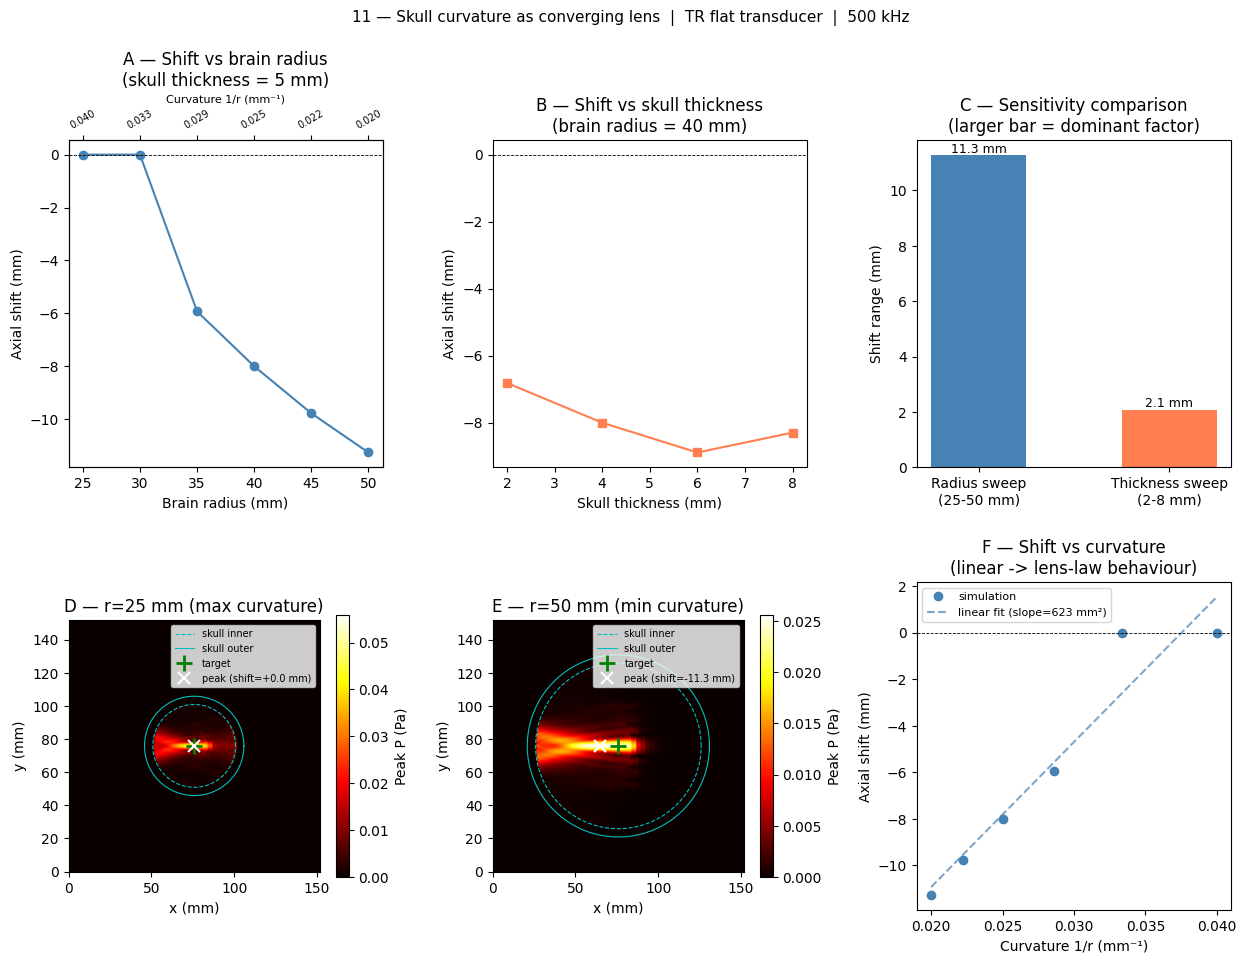


Practical implication:
To hit a target at depth d, aim at d + |shift(r)| deeper.
At r=40 mm: correct by 8.0 mm


In [1]:
# Self-contained.
#
# Each call to run_tr() runs:
#   1. Forward sim:  point source at brain centre -> flat transducer elements
#   2. Backward sim: time-reversed signals -> full-field p_max
# and returns the axial shift of the TR focus relative to the target.

# -- Shared acoustics / geometry
c_water = 1482.0;  rho_water = 1000.0
c_skull = 2900.0;  rho_skull = 1900.0
c_brain = 1560.0;  rho_brain = 1040.0

freq        = 500e3
dx          = (c_water / freq) / 10     # ~0.296 mm  (10 PPW)
Nx, Ny      = 512, 512
cx, cy      = Nx // 2, Ny // 2
standoff_mm = 5.0
aperture_mm = 30.0

# Verify kgrid timing (CFL=0.3, same for all configs since dx and c_skull fixed)
_kg_tmp = kWaveGrid([Nx, Ny], [dx, dx])
_kg_tmp.makeTime(c_skull, cfl=0.3)
print(f"Nt={_kg_tmp.Nt}  dt={_kg_tmp.dt:.2e} s  (same for all sweep configs)")


# -- TR helper -----------------------------------------------------------------
def run_tr(brain_r_mm, skull_t_mm, return_field=False):
    """Forward + TR-backward simulation.
    Returns axial_shift_mm (negative = closer to skull than target).
    If return_field=True also returns (p_max, brain_mask, skull_inner_px, skull_outer_px).
    """
    s_in  = brain_r_mm * 1e-3 / dx
    s_out = (brain_r_mm + skull_t_mm) * 1e-3 / dx

    XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
    R = np.sqrt((XX - cx)**2 + (YY - cy)**2)
    skull_m = (R >= s_in) & (R < s_out)
    brain_m = R < s_in

    ss  = np.full((Nx, Ny), c_water,  dtype=float)
    rho = np.full((Nx, Ny), rho_water, dtype=float)
    ss[skull_m] = c_skull;  rho[skull_m] = rho_skull
    ss[brain_m] = c_brain;  rho[brain_m] = rho_brain

    kg  = kWaveGrid([Nx, Ny], [dx, dx])
    kg.makeTime(c_skull, cfl=0.3)
    med = kWaveMedium(sound_speed=ss, density=rho)

    # Flat transducer: 5 mm standoff from skull outer surface
    tx   = cx - int(s_out) - int(standoff_mm * 1e-3 / dx)
    h_ap = int((aperture_mm / 2) * 1e-3 / dx)
    emask = np.zeros((Nx, Ny))
    for yi in range(cy - h_ap, cy + h_ap):
        emask[tx, int(yi)] = 1

    # Forward sim: point source at brain centre -> transducer elements
    src_f = kSource()
    src_f.p_mask = np.zeros((Nx, Ny));  src_f.p_mask[cx, cy] = 1
    src_f.p = tone_burst(1 / kg.dt, freq, 5).flatten()
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_elem = kspaceFirstOrder(kg, med, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    # Backward sim: time-reversed -> p_max everywhere
    src_b = kSource();  src_b.p_mask = emask.copy();  src_b.p = p_elem[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg, med, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    # Peak inside brain only
    p_br  = p_max.copy();  p_br[~brain_m] = 0
    peak_x_mm = np.unravel_index(np.argmax(p_br), (Nx, Ny))[0] * dx * 1e3
    shift = peak_x_mm - cx * dx * 1e3   # negative = closer to skull

    if return_field:
        return shift, p_max, brain_m, s_in, s_out
    return shift


# -- Sweep 1: brain radius  (skull thickness = 5 mm, fixed) -------------------
radii_mm = [25, 30, 35, 40, 45, 50]
t_fixed  = 5.0
shifts_r = []
fields_r = []   # store (p_max, brain_mask, s_in_px, s_out_px) per radius

print("\n=== SWEEP 1: brain radius  (skull thickness = 5 mm) ===")
for r in radii_mm:
    shift, p_max, bm, si, so = run_tr(r, t_fixed, return_field=True)
    shifts_r.append(shift)
    fields_r.append((p_max, bm, si, so))
    print(f"  r = {r:2.0f} mm  ->  axial shift = {shift:+.1f} mm")

# -- Sweep 2: skull thickness  (brain radius = 40 mm, fixed) ------------------
thicks_mm = [2, 4, 6, 8]
r_fixed   = 40.0
shifts_t  = []

print("\n=== SWEEP 2: skull thickness  (brain radius = 40 mm) ===")
for t in thicks_mm:
    shift = run_tr(r_fixed, t)
    shifts_t.append(shift)
    print(f"  t = {t:.0f} mm  ->  axial shift = {shift:+.1f} mm")

# -- Summary -------------------------------------------------------------------
print("\n=== SUMMARY ===")
print(f"Radius sweep  : min shift = {min(shifts_r):+.1f} mm  (r={radii_mm[shifts_r.index(min(shifts_r))]} mm)")
print(f"               max shift = {max(shifts_r):+.1f} mm  (r={radii_mm[shifts_r.index(max(shifts_r))]} mm)")
print(f"Thickness sweep: range {min(shifts_t):+.1f} to {max(shifts_t):+.1f} mm")

dominant = "brain radius (curvature)" if (max(shifts_r)-min(shifts_r)) > (max(shifts_t)-min(shifts_t)) else "skull thickness"
print(f"Dominant factor: {dominant}")


# -- Plots ---------------------------------------------------------------------
theta = np.linspace(0, 2*np.pi, 360)
cx_mm = cx * dx * 1e3;  cy_mm = cy * dx * 1e3
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

# ── Panel A: shift vs brain radius ──────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(radii_mm, shifts_r, 'o-', color='steelblue', lw=1.5, ms=6)
ax_a.axhline(0, color='k', lw=0.6, ls='--')
ax_a.set_xlabel('Brain radius (mm)')
ax_a.set_ylabel('Axial shift (mm)')
ax_a.set_title('A — Shift vs brain radius\n(skull thickness = 5 mm)')
# Secondary x-axis: curvature = 1/radius
ax_a2 = ax_a.twiny()
curv  = [1/r for r in radii_mm]
ax_a2.set_xlim(ax_a.get_xlim())
ax_a2.set_xticks(radii_mm)
ax_a2.set_xticklabels([f'{1/r:.3f}' for r in radii_mm], fontsize=7, rotation=30)
ax_a2.set_xlabel('Curvature 1/r (mm\u207b\xb9)', fontsize=8)

# ── Panel B: shift vs skull thickness ───────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(thicks_mm, shifts_t, 's-', color='coral', lw=1.5, ms=6)
ax_b.axhline(0, color='k', lw=0.6, ls='--')
ax_b.set_xlabel('Skull thickness (mm)')
ax_b.set_ylabel('Axial shift (mm)')
ax_b.set_title('B — Shift vs skull thickness\n(brain radius = 40 mm)')

# ── Panel C: combined summary bar chart ──────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
range_r = max(shifts_r) - min(shifts_r)
range_t = max(shifts_t) - min(shifts_t)
bars = ax_c.bar(['Radius sweep\n(25-50 mm)', 'Thickness sweep\n(2-8 mm)'],
                [range_r, range_t], color=['steelblue', 'coral'], width=0.5)
ax_c.set_ylabel('Shift range (mm)')
ax_c.set_title('C — Sensitivity comparison\n(larger bar = dominant factor)')
for bar, val in zip(bars, [range_r, range_t]):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              f'{val:.1f} mm', ha='center', fontsize=9)

# ── Panels D & E: focus maps for smallest and largest radius ─────────────────
for col, (r_idx, label) in enumerate([(0, f'r={radii_mm[0]} mm (max curvature)'),
                                       (-1, f'r={radii_mm[-1]} mm (min curvature)')]):
    p_max_i, bm_i, si_i, so_i = fields_r[r_idx]
    ax = fig.add_subplot(gs[1, col])
    p_br_i = p_max_i.copy();  p_br_i[~bm_i] = 0
    im = ax.imshow(p_br_i.T, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='Peak P (Pa)', shrink=0.8)
    ax.plot(cx_mm + si_i*dx*1e3*np.cos(theta), cy_mm + si_i*dx*1e3*np.sin(theta),
            'c--', lw=0.8, label='skull inner')
    ax.plot(cx_mm + so_i*dx*1e3*np.cos(theta), cy_mm + so_i*dx*1e3*np.sin(theta),
            'c-',  lw=0.8, label='skull outer')
    ax.plot(cx_mm, cy_mm, 'g+', ms=12, mew=2, label='target')
    peak_idx_i = np.unravel_index(np.argmax(p_br_i), (Nx, Ny))
    ax.plot(peak_idx_i[0]*dx*1e3, peak_idx_i[1]*dx*1e3, 'wx', ms=9, mew=1.5,
            label=f'peak (shift={shifts_r[r_idx]:+.1f} mm)')
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    ax.set_title(f'{"D" if col==0 else "E"} — {label}')
    ax.legend(fontsize=7, loc='upper right')

# ── Panel F: shift vs curvature (linear fit) ─────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
curvature = [1/r for r in radii_mm]
ax_f.plot(curvature, shifts_r, 'o', color='steelblue', ms=6, label='simulation')
# Linear fit
coeffs = np.polyfit(curvature, shifts_r, 1)
c_fit  = np.linspace(min(curvature), max(curvature), 100)
ax_f.plot(c_fit, np.polyval(coeffs, c_fit), '--', color='steelblue', alpha=0.7,
          label=f'linear fit (slope={coeffs[0]:.0f} mm\xb2)')
ax_f.axhline(0, color='k', lw=0.6, ls='--')
ax_f.set_xlabel('Curvature 1/r (mm\u207b\xb9)')
ax_f.set_ylabel('Axial shift (mm)')
ax_f.set_title('F — Shift vs curvature\n(linear -> lens-law behaviour)')
ax_f.legend(fontsize=8)

plt.suptitle('11 — Skull curvature as converging lens  |  TR flat transducer  |  500 kHz',
             fontsize=11, y=1.01)
plt.savefig('11_skull_curvature_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPractical implication:")
print(f"To hit a target at depth d, aim at d + |shift(r)| deeper.")
print(f"At r={radii_mm[radii_mm.index(40)]} mm: correct by {abs(shifts_r[radii_mm.index(40)]):.1f} mm")


### 12_aperture_coverage_fix
Cell 11 showed the -8 mm shift grows with brain radius because the **flat transducer covers a progressively smaller solid angle** of the forward wavefront as the target depth increases. TR requires capturing the full wavefront — missing components bias the focus toward the near (skull) side.

Three remedies are compared head-to-head at the reference geometry (r=40 mm, skull=5 mm, 500 kHz):
1. **Wider aperture** — increase transducer width, standoff fixed at 5 mm
2. **Smaller standoff** — move transducer closer to the skull, aperture fixed at 30 mm
3. **Zero-crossing** — interpolate both curves to find the minimum aperture / maximum standoff that reduces the shift to ~0 mm

Nt=2414  dt=3.07e-08 s
Target: (75.9, 75.9) mm

=== SWEEP A: aperture  (standoff = 5 mm) ===
  ap= 20 mm  angle=11.4 deg  shift=-20.2 mm
  ap= 30 mm  angle=16.9 deg  shift=-8.0 mm
  ap= 45 mm  angle=24.4 deg  shift=-2.1 mm
  ap= 60 mm  angle=31.2 deg  shift=-0.6 mm
  ap= 75 mm  angle=37.1 deg  shift=-0.3 mm
  ap= 90 mm  angle=42.3 deg  shift=-0.3 mm

=== SWEEP B: standoff  (aperture = 30 mm) ===
  sd= 0.5 mm  angle=18.4 deg  shift=-6.2 mm
  sd= 1.0 mm  angle=18.2 deg  shift=-6.2 mm
  sd= 2.0 mm  angle=17.9 deg  shift=-6.5 mm
  sd= 5.0 mm  angle=16.9 deg  shift=-8.0 mm
  sd=10.0 mm  angle=15.4 deg  shift=-9.5 mm
  sd=20.0 mm  angle=13.1 deg  shift=-12.2 mm

=== ZERO CROSSINGS ===
Aperture: no zero crossing in sweep range
Standoff: no zero crossing in sweep range

Smallest shift in sweep A: -0.3 mm  (aperture=75 mm)
Smallest shift in sweep B: -6.2 mm  (standoff=0.5 mm)


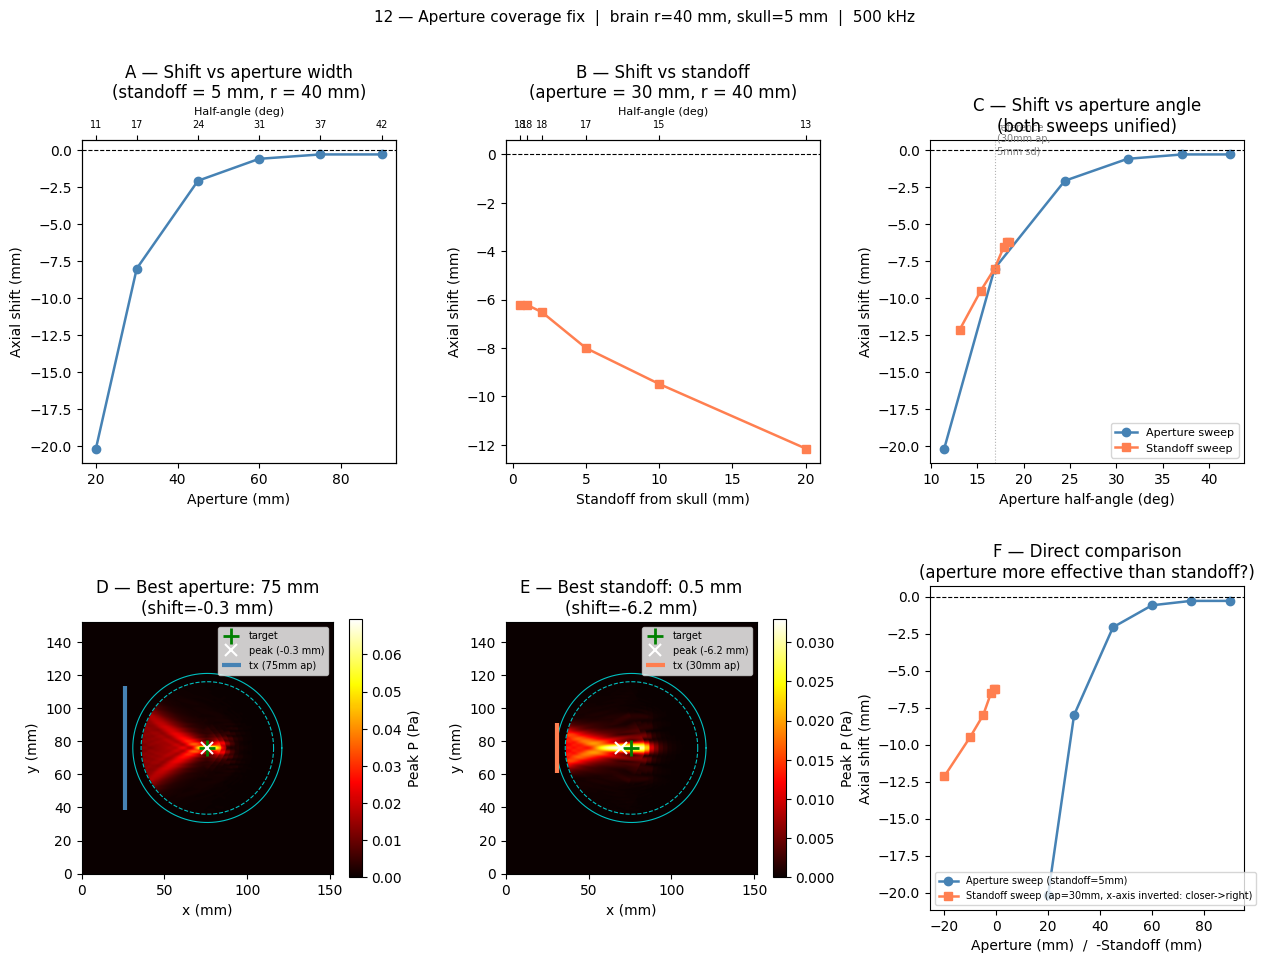


=== KEY FINDINGS ===
Aperture sweep: shift spans -20.2 to -0.3 mm
Standoff sweep: shift spans -12.2 to -6.2 mm
-> Aperture sweep did not reach zero (need > 90 mm)
-> Standoff sweep did not reach zero shift with 30mm aperture alone

Conclusion: panel C shows whether both sweeps collapse onto a single
aperture-angle curve. If yes, aperture angle is the sole predictor of focus quality.


In [ ]:
# Self-contained.  Fixed geometry: brain r=40 mm, skull=5 mm, water exterior.
# Two sweeps:
#   A — aperture width  (standoff = 5 mm fixed)
#   B — standoff        (aperture = 30 mm fixed)
# Each data point = 2 GPU sims (~3 s each).

# -- Shared parameters --------------------------------------------------------
c_water = 1482.0;  rho_water = 1000.0
c_skull = 2900.0;  rho_skull = 1900.0
c_brain = 1560.0;  rho_brain = 1040.0

freq           = 500e3
dx             = (c_water / freq) / 10     # ~0.296 mm
Nx, Ny         = 512, 512
cx, cy         = Nx // 2, Ny // 2
brain_r_mm     = 40.0
skull_t_mm     = 5.0
skull_in_px    = brain_r_mm * 1e-3 / dx
skull_out_px   = (brain_r_mm + skull_t_mm) * 1e-3 / dx

# Medium (same for every run)
XX, YY = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R_grid = np.sqrt((XX - cx)**2 + (YY - cy)**2)
skull_m = (R_grid >= skull_in_px) & (R_grid < skull_out_px)
brain_m =  R_grid < skull_in_px

ss12  = np.full((Nx, Ny), c_water,  dtype=float)
rho12 = np.full((Nx, Ny), rho_water, dtype=float)
ss12[skull_m] = c_skull;  rho12[skull_m] = rho_skull
ss12[brain_m] = c_brain;  rho12[brain_m] = rho_brain

kg12 = kWaveGrid([Nx, Ny], [dx, dx])
kg12.makeTime(c_skull, cfl=0.3)
med12 = kWaveMedium(sound_speed=ss12, density=rho12)
print(f"Nt={kg12.Nt}  dt={kg12.dt:.2e} s")

target_x_mm = cx * dx * 1e3
print(f"Target: ({target_x_mm:.1f}, {cy*dx*1e3:.1f}) mm")


# -- TR helper ----------------------------------------------------------------
def run_tr12(aperture_mm, standoff_mm):
    """Returns axial_shift_mm and the peak p_max map inside the brain."""
    # Transducer: flat line at fixed x, standoff from skull outer surface
    standoff_px = max(1, int(standoff_mm * 1e-3 / dx))   # at least 1 grid pt
    tx          = cx - int(skull_out_px) - standoff_px
    h_ap        = int((aperture_mm / 2) * 1e-3 / dx)

    # Clip to valid grid range (stay inside PML boundary at +/-20 px)
    y_lo = max(20,      cy - h_ap)
    y_hi = min(Ny - 20, cy + h_ap)
    emask = np.zeros((Nx, Ny))
    emask[tx, y_lo:y_hi] = 1

    # Forward sim
    burst = tone_burst(1 / kg12.dt, freq, 5).flatten()
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[cx, cy] = 1;  src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_elem = kspaceFirstOrder(kg12, med12, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    # Backward sim
    src_b = kSource();  src_b.p_mask = emask.copy()
    src_b.p = p_elem[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg12, med12, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    p_br = p_max.copy();  p_br[~brain_m] = 0
    peak_x = np.unravel_index(np.argmax(p_br), (Nx, Ny))[0] * dx * 1e3
    return peak_x - target_x_mm, p_max     # (shift_mm, field)


# =============================================================================
# SWEEP A — aperture width  (standoff = 5 mm)
# =============================================================================
apertures_mm  = [20, 30, 45, 60, 75, 90]
standoff_fixed = 5.0
shifts_A = [];  fields_A = []

print("\n=== SWEEP A: aperture  (standoff = 5 mm) ===")
for ap in apertures_mm:
    shift, pmap = run_tr12(ap, standoff_fixed)
    shifts_A.append(shift);  fields_A.append(pmap)
    # aperture angle (half-angle from transducer to target)
    dist_mm = (int(skull_out_px) + int(standoff_fixed * 1e-3 / dx)) * dx * 1e3
    angle_deg = np.degrees(np.arctan((ap / 2) / dist_mm))
    print(f"  ap={ap:3.0f} mm  angle={angle_deg:.1f} deg  shift={shift:+.1f} mm")

# =============================================================================
# SWEEP B — standoff  (aperture = 30 mm)
# =============================================================================
standoffs_mm  = [0.5, 1, 2, 5, 10, 20]
aperture_fixed = 30.0
shifts_B = [];  fields_B = []

print("\n=== SWEEP B: standoff  (aperture = 30 mm) ===")
for sd in standoffs_mm:
    shift, pmap = run_tr12(aperture_fixed, sd)
    shifts_B.append(shift);  fields_B.append(pmap)
    dist_mm = (int(skull_out_px) + max(1, int(sd * 1e-3 / dx))) * dx * 1e3
    angle_deg = np.degrees(np.arctan((aperture_fixed / 2) / dist_mm))
    print(f"  sd={sd:4.1f} mm  angle={angle_deg:.1f} deg  shift={shift:+.1f} mm")


# =============================================================================
# ANALYSIS C — zero-crossing for each sweep
# =============================================================================
def zero_crossing(x_vals, y_vals):
    for i in range(len(y_vals) - 1):
        if y_vals[i] * y_vals[i+1] <= 0:
            t = -y_vals[i] / (y_vals[i+1] - y_vals[i])
            return x_vals[i] + t * (x_vals[i+1] - x_vals[i])
    return None   # no crossing in range

zc_A = zero_crossing(apertures_mm,  shifts_A)
zc_B = zero_crossing(standoffs_mm,  shifts_B)

print("\n=== ZERO CROSSINGS ===")
print(f"Aperture zero-crossing : {zc_A:.1f} mm" if zc_A else "Aperture: no zero crossing in sweep range")
print(f"Standoff zero-crossing : {zc_B:.1f} mm" if zc_B else "Standoff: no zero crossing in sweep range")

# Best configurations found
best_A_idx = int(np.argmin(np.abs(shifts_A)))
best_B_idx = int(np.argmin(np.abs(shifts_B)))
print(f"\nSmallest shift in sweep A: {shifts_A[best_A_idx]:+.1f} mm  (aperture={apertures_mm[best_A_idx]} mm)")
print(f"Smallest shift in sweep B: {shifts_B[best_B_idx]:+.1f} mm  (standoff={standoffs_mm[best_B_idx]} mm)")


# =============================================================================
# PLOTS
# =============================================================================
theta = np.linspace(0, 2*np.pi, 360)
cx_mm = cx * dx * 1e3;  cy_mm = cy * dx * 1e3
r_in_mm  = skull_in_px  * dx * 1e3
r_out_mm = skull_out_px * dx * 1e3
extent   = [0, Nx*dx*1e3, 0, Ny*dx*1e3]

fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.35)

# Helper: aperture half-angle for each config
def ang_A(ap):
    d = (int(skull_out_px) + int(standoff_fixed * 1e-3 / dx)) * dx * 1e3
    return np.degrees(np.arctan((ap / 2) / d))

def ang_B(sd):
    d = (int(skull_out_px) + max(1, int(sd * 1e-3 / dx))) * dx * 1e3
    return np.degrees(np.arctan((aperture_fixed / 2) / d))

angles_A = [ang_A(ap) for ap in apertures_mm]
angles_B = [ang_B(sd) for sd in standoffs_mm]

# ── Panel A: shift vs aperture ───────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(apertures_mm, shifts_A, 'o-', color='steelblue', lw=1.8, ms=6)
ax_a.axhline(0, color='k', lw=0.8, ls='--')
if zc_A:
    ax_a.axvline(x=zc_A, color='steelblue', lw=1, ls=':', alpha=0.7)
    ax_a.annotate(f'zero at\n{zc_A:.0f} mm', xy=(zc_A, 0),
                  xytext=(zc_A+3, min(shifts_A)*0.4),
                  fontsize=8, color='steelblue',
                  arrowprops=dict(arrowstyle='->', color='steelblue', lw=0.8))
ax_a.set_xlabel('Aperture (mm)')
ax_a.set_ylabel('Axial shift (mm)')
ax_a.set_title('A — Shift vs aperture width\n(standoff = 5 mm, r = 40 mm)')
# Twin axis: aperture half-angle
ax_a2 = ax_a.twiny()
ax_a2.set_xlim(ax_a.get_xlim())
ax_a2.set_xticks(apertures_mm)
ax_a2.set_xticklabels([f'{ang_A(ap):.0f}' for ap in apertures_mm], fontsize=7)
ax_a2.set_xlabel('Half-angle (deg)', fontsize=8)

# ── Panel B: shift vs standoff ───────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(standoffs_mm, shifts_B, 's-', color='coral', lw=1.8, ms=6)
ax_b.axhline(0, color='k', lw=0.8, ls='--')
if zc_B:
    ax_b.axvline(x=zc_B, color='coral', lw=1, ls=':', alpha=0.7)
    ax_b.annotate(f'zero at\n{zc_B:.1f} mm', xy=(zc_B, 0),
                  xytext=(zc_B+1, min(shifts_B)*0.4),
                  fontsize=8, color='coral',
                  arrowprops=dict(arrowstyle='->', color='coral', lw=0.8))
ax_b.set_xlabel('Standoff from skull (mm)')
ax_b.set_ylabel('Axial shift (mm)')
ax_b.set_title('B — Shift vs standoff\n(aperture = 30 mm, r = 40 mm)')
ax_b2 = ax_b.twiny()
ax_b2.set_xlim(ax_b.get_xlim())
ax_b2.set_xticks(standoffs_mm)
ax_b2.set_xticklabels([f'{ang_B(sd):.0f}' for sd in standoffs_mm], fontsize=7)
ax_b2.set_xlabel('Half-angle (deg)', fontsize=8)

# ── Panel C: shift vs half-angle (both sweeps on same axis) ──────────────────
ax_c = fig.add_subplot(gs[0, 2])
ax_c.plot(angles_A, shifts_A, 'o-', color='steelblue', lw=1.8, ms=6, label='Aperture sweep')
ax_c.plot(angles_B, shifts_B, 's-', color='coral',     lw=1.8, ms=6, label='Standoff sweep')
ax_c.axhline(0, color='k', lw=0.8, ls='--')
ax_c.set_xlabel('Aperture half-angle (deg)')
ax_c.set_ylabel('Axial shift (mm)')
ax_c.set_title('C — Shift vs aperture angle\n(both sweeps unified)')
ax_c.legend(fontsize=8)
# Mark reference at 30mm ap / 5mm standoff
ref_angle = ang_A(30)
ax_c.axvline(x=ref_angle, color='gray', lw=0.8, ls=':', alpha=0.6)
ax_c.text(ref_angle+0.3, max(shifts_A+shifts_B)*0.85, 'reference\n(30mm ap,\n5mm sd)',
          fontsize=7, color='gray')

# ── Panels D & E: best focus maps ────────────────────────────────────────────
for col, (idx_i, label_i, ap_i, sd_i, fields_i, color_i) in enumerate([
    (best_A_idx, f'Best aperture: {apertures_mm[best_A_idx]} mm\n(shift={shifts_A[best_A_idx]:+.1f} mm)',
     apertures_mm[best_A_idx], standoff_fixed, fields_A, 'steelblue'),
    (best_B_idx, f'Best standoff: {standoffs_mm[best_B_idx]} mm\n(shift={shifts_B[best_B_idx]:+.1f} mm)',
     aperture_fixed, standoffs_mm[best_B_idx], fields_B, 'coral'),
]):
    ax = fig.add_subplot(gs[1, col])
    p_br = fields_i[idx_i].copy();  p_br[~brain_m] = 0
    im = ax.imshow(p_br.T, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='Peak P (Pa)', shrink=0.8)
    ax.plot(cx_mm + r_in_mm*np.cos(theta),  cy_mm + r_in_mm*np.sin(theta),  'c--', lw=0.8)
    ax.plot(cx_mm + r_out_mm*np.cos(theta), cy_mm + r_out_mm*np.sin(theta), 'c-',  lw=0.8)
    ax.plot(cx_mm, cy_mm, 'g+', ms=12, mew=2, label='target')
    pk = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    ax.plot(pk[0]*dx*1e3, pk[1]*dx*1e3, 'wx', ms=9, mew=1.5,
            label=f'peak ({shifts_A[idx_i] if col==0 else shifts_B[idx_i]:+.1f} mm)')
    # Draw transducer segment
    sd_px = max(1, int((standoff_fixed if col==0 else ap_i)*1e-3/dx)) if col==1 else int(standoff_fixed*1e-3/dx)
    # Recompute properly
    sd_use = standoff_fixed if col == 0 else standoffs_mm[idx_i]
    ap_use = ap_i
    tx_px  = cx - int(skull_out_px) - max(1, int(sd_use * 1e-3 / dx))
    h_ap   = int((ap_use / 2) * 1e-3 / dx)
    y_lo_mm = max(20, cy - h_ap) * dx * 1e3
    y_hi_mm = min(Ny-20, cy + h_ap) * dx * 1e3
    ax.plot([tx_px*dx*1e3, tx_px*dx*1e3], [y_lo_mm, y_hi_mm],
            color=color_i, lw=3, solid_capstyle='butt',
            label=f'tx ({ap_use:.0f}mm ap)')
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    ax.set_title(f'{"D" if col==0 else "E"} — {label_i}')
    ax.legend(fontsize=7, loc='upper right')

# ── Panel F: summary — which approach is more efficient? ─────────────────────
ax_f = fig.add_subplot(gs[1, 2])

# Efficiency: shift improvement per mm of change in each parameter
# Aperture: from 30mm (baseline -8mm) to best_A
ap_baseline_idx = apertures_mm.index(30) if 30 in apertures_mm else 0
sd_baseline_idx = standoffs_mm.index(5)  if 5  in standoffs_mm else 3

ax_f.plot(apertures_mm, shifts_A, 'o-', color='steelblue', lw=1.8, ms=6,
          label='Aperture sweep (standoff=5mm)')
ax_f.plot([sd * (-1) for sd in standoffs_mm], shifts_B, 's-', color='coral', lw=1.8, ms=6,
          label='Standoff sweep (ap=30mm, x-axis inverted: closer->right)')
ax_f.axhline(0, color='k', lw=0.8, ls='--')
ax_f.set_xlabel('Aperture (mm)  /  -Standoff (mm)')
ax_f.set_ylabel('Axial shift (mm)')
ax_f.set_title('F — Direct comparison\n(aperture more effective than standoff?)')
ax_f.legend(fontsize=7)

plt.suptitle('12 — Aperture coverage fix  |  brain r=40 mm, skull=5 mm  |  500 kHz',
             fontsize=11, y=1.01)
plt.savefig('12_aperture_coverage_fix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== KEY FINDINGS ===")
print(f"Aperture sweep: shift spans {min(shifts_A):+.1f} to {max(shifts_A):+.1f} mm")
print(f"Standoff sweep: shift spans {min(shifts_B):+.1f} to {max(shifts_B):+.1f} mm")
if zc_A:
    print(f"-> Aperture needed for zero shift: ~{zc_A:.0f} mm at 5mm standoff")
else:
    print(f"-> Aperture sweep did not reach zero (need > {apertures_mm[-1]} mm)")
if zc_B:
    print(f"-> Standoff needed for zero shift: ~{zc_B:.1f} mm with 30mm aperture")
else:
    print(f"-> Standoff sweep did not reach zero shift with 30mm aperture alone")
print(f"\nConclusion: panel C shows whether both sweeps collapse onto a single")
print(f"aperture-angle curve. If yes, aperture angle is the sole predictor of focus quality.")


### 13_best_config_and_steering
Two parts:

**Part 1** — Combine the best settings from cell 12: aperture=90 mm + standoff=0 (transducer touching the skull). This gives a 45 deg half-angle, the maximum achievable with the flat geometry at r=40 mm.

**Part 2** — Off-axis steering sweep using the best config. Targets are moved laterally (y-axis) and axially (x-axis, toward/away from transducer) to map out the focusable region of the brain. This answers: *how far from the centre can we reliably steer?*

Nt=2414  dt=3.07e-08 s

PART 1 — centre focus comparison
  Baseline  (ap=30 mm, sd=5 mm): shift=-8.0 mm  error=8.0 mm
  Best      (ap=90 mm, sd=0 mm): shift=-0.3 mm  error=0.3 mm

PART 2a — lateral (y) steering  (ap=90 mm, sd=0 mm)
  dy=-20 mm  peak=(75.9, 56.0) mm  err=0.0 mm  (sx=+0.0, sy=+0.0)
  dy=-15 mm  peak=(75.6, 61.1) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=-10 mm  peak=(75.6, 66.1) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy= -5 mm  peak=(75.6, 71.1) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy= +0 mm  peak=(75.6, 75.9) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy= +5 mm  peak=(75.6, 80.6) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=+10 mm  peak=(75.6, 85.7) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=+15 mm  peak=(75.6, 90.7) mm  err=0.3 mm  (sx=-0.3, sy=+0.0)
  dy=+20 mm  peak=(75.9, 95.7) mm  err=0.0 mm  (sx=+0.0, sy=+0.0)

PART 2b — axial (x) steering  (ap=90 mm, sd=0 mm)
  dx=-25 mm  target=(51.0, 75.9)  peak=(51.3, 75.9)  err=0.3 mm
  dx=-15 mm  target=(61.1, 75.9)  peak=(61.1, 75.9)  err=0.

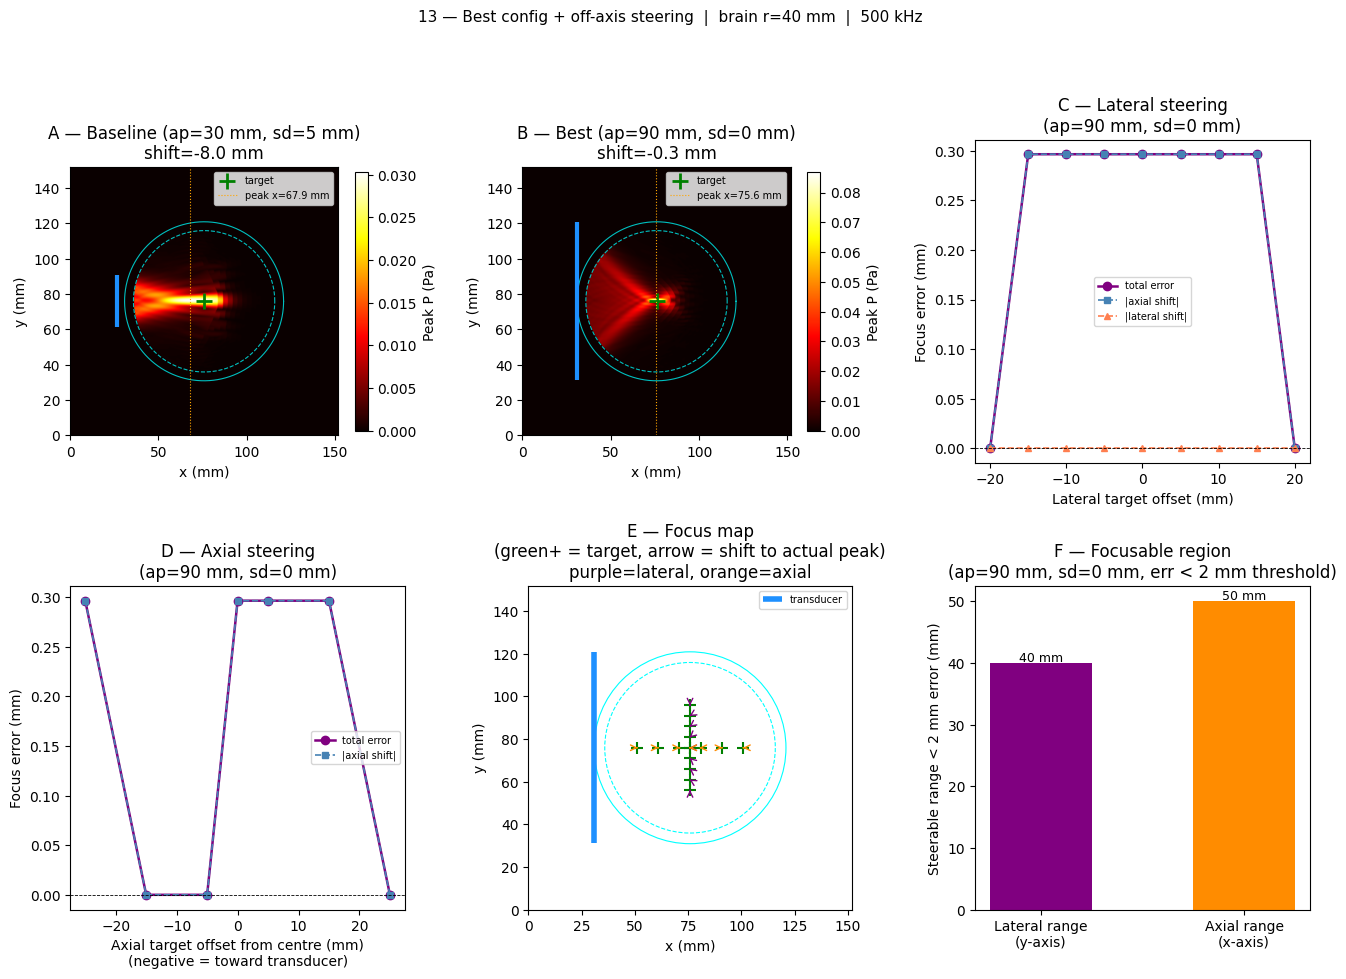


=== PART 1 SUMMARY ===
Baseline (ap=30 mm, sd=5 mm): axial shift = -8.0 mm
Best     (ap=90 mm, sd=0 mm): axial shift = -0.3 mm
Improvement: 7.7 mm closer to target

=== PART 2 SUMMARY ===
Lateral steering (err < 2 mm): 40 mm range  (+/-20 mm)
Axial steering   (err < 2 mm): 50 mm range  (from 51 to 101 mm)


In [ ]:
# Self-contained.  r=40 mm brain, skull=5 mm, water exterior, 500 kHz.
#
# PART 1: best flat-transducer config (ap=90 mm, standoff=0) vs baseline (ap=30 mm, sd=5 mm)
# PART 2: lateral (y) and axial (x) steering sweep with the best config

# -- Shared medium (built once) -----------------------------------------------
c_water = 1482.0;  rho_water = 1000.0
c_skull = 2900.0;  rho_skull = 1900.0
c_brain = 1560.0;  rho_brain = 1040.0

freq         = 500e3
dx           = (c_water / freq) / 10
Nx, Ny       = 512, 512
cx, cy       = Nx // 2, Ny // 2
brain_r_mm   = 40.0
skull_t_mm   = 5.0
skull_in_px  = brain_r_mm * 1e-3 / dx
skull_out_px = (brain_r_mm + skull_t_mm) * 1e-3 / dx

XX, YY   = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R_grid   = np.sqrt((XX - cx)**2 + (YY - cy)**2)
skull_m  = (R_grid >= skull_in_px) & (R_grid < skull_out_px)
brain_m  = R_grid < skull_in_px

ss13  = np.full((Nx, Ny), c_water,  dtype=float)
rho13 = np.full((Nx, Ny), rho_water, dtype=float)
ss13[skull_m] = c_skull;   rho13[skull_m] = rho_skull
ss13[brain_m] = c_brain;   rho13[brain_m] = rho_brain

kg13  = kWaveGrid([Nx, Ny], [dx, dx])
kg13.makeTime(c_skull, cfl=0.3)
med13 = kWaveMedium(sound_speed=ss13, density=rho13)
print(f"Nt={kg13.Nt}  dt={kg13.dt:.2e} s")

cx_mm = cx * dx * 1e3;  cy_mm = cy * dx * 1e3
r_in_mm  = skull_in_px  * dx * 1e3
r_out_mm = skull_out_px * dx * 1e3

# -- TR helper ----------------------------------------------------------------
def run_tr13(target_x_px, target_y_px, ap_mm, standoff_mm):
    """TR focus at arbitrary brain target.
    Returns (shift_x_mm, shift_y_mm, error_mm, peak_x_mm, peak_y_mm, p_max_brain).
    """
    sd_px = max(1, int(standoff_mm * 1e-3 / dx))
    tx    = cx - int(skull_out_px) - sd_px
    h_ap  = int((ap_mm / 2) * 1e-3 / dx)
    y_lo  = max(20,      cy - h_ap)
    y_hi  = min(Ny - 20, cy + h_ap)

    emask = np.zeros((Nx, Ny))
    emask[tx, y_lo:y_hi] = 1

    burst = tone_burst(1 / kg13.dt, freq, 5).flatten()
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[int(target_x_px), int(target_y_px)] = 1
    src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_elem = kspaceFirstOrder(kg13, med13, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    src_b = kSource();  src_b.p_mask = emask.copy()
    src_b.p = p_elem[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg13, med13, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    p_br = p_max.copy();  p_br[~brain_m] = 0
    pi, pj = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    pk_x  = pi * dx * 1e3;  pk_y = pj * dx * 1e3
    tg_x  = target_x_px * dx * 1e3;  tg_y = target_y_px * dx * 1e3
    sx    = pk_x - tg_x;  sy = pk_y - tg_y
    err   = np.sqrt(sx**2 + sy**2)
    return sx, sy, err, pk_x, pk_y, p_br


# =============================================================================
# PART 1 — best config (ap=90 mm, standoff=0) at brain centre
# =============================================================================
AP_BEST = 90.0;  SD_BEST = 0.0   # standoff=0 -> 1 grid point gap
AP_BASE = 30.0;  SD_BASE = 5.0

print("\nPART 1 — centre focus comparison")
sx_base, _, err_base, pk_x_base, _, p_base = run_tr13(cx, cy, AP_BASE, SD_BASE)
print(f"  Baseline  (ap={AP_BASE:.0f} mm, sd={SD_BASE:.0f} mm): shift={sx_base:+.1f} mm  error={err_base:.1f} mm")

sx_best, _, err_best, pk_x_best, _, p_best = run_tr13(cx, cy, AP_BEST, SD_BEST)
print(f"  Best      (ap={AP_BEST:.0f} mm, sd={SD_BEST:.0f} mm): shift={sx_best:+.1f} mm  error={err_best:.1f} mm")


# =============================================================================
# PART 2 — off-axis steering  (best config: ap=90 mm, standoff=0)
# =============================================================================
# Lateral (y) targets: y offsets from brain centre, x fixed at cx
lat_offsets_mm = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
lat_results = []   # (tgt_y_mm, peak_x_mm, peak_y_mm, err_mm, sx, sy)

print("\nPART 2a — lateral (y) steering  (ap=90 mm, sd=0 mm)")
for dy_mm in lat_offsets_mm:
    ty = cy + int(dy_mm * 1e-3 / dx)
    if not brain_m[cx, ty]:
        print(f"  dy={dy_mm:+.0f} mm  outside brain — skipped")
        lat_results.append(None);  continue
    sx, sy, err, pk_x, pk_y, _ = run_tr13(cx, ty, AP_BEST, SD_BEST)
    lat_results.append((dy_mm, pk_x, pk_y, err, sx, sy))
    print(f"  dy={dy_mm:+3.0f} mm  peak=({pk_x:.1f}, {pk_y:.1f}) mm  err={err:.1f} mm  (sx={sx:+.1f}, sy={sy:+.1f})")

# Axial (x) targets: x offsets from brain centre, y fixed at cy
axial_offsets_mm = [-25, -15, -5, 0, 5, 15, 25]
axial_results = []  # (dx_mm, peak_x_mm, peak_y_mm, err_mm, sx, sy)

print("\nPART 2b — axial (x) steering  (ap=90 mm, sd=0 mm)")
for dx_mm in axial_offsets_mm:
    tx_px = cx + int(dx_mm * 1e-3 / dx)
    if not brain_m[tx_px, cy]:
        print(f"  dx={dx_mm:+.0f} mm  outside brain — skipped")
        axial_results.append(None);  continue
    sx, sy, err, pk_x, pk_y, _ = run_tr13(tx_px, cy, AP_BEST, SD_BEST)
    axial_results.append((dx_mm, pk_x, pk_y, err, sx, sy))
    tgt_x_mm = tx_px * dx * 1e3
    print(f"  dx={dx_mm:+3.0f} mm  target=({tgt_x_mm:.1f}, {cy_mm:.1f})  peak=({pk_x:.1f}, {pk_y:.1f})  err={err:.1f} mm")


# =============================================================================
# PLOTS
# =============================================================================
theta = np.linspace(0, 2*np.pi, 360)
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.35)

# ── Panel A: baseline vs best focus maps side by side ────────────────────────
for col, (pmap, label, shift_val) in enumerate([
    (p_base, f'Baseline (ap={AP_BASE:.0f} mm, sd={SD_BASE:.0f} mm)\nshift={sx_base:+.1f} mm', sx_base),
    (p_best, f'Best (ap={AP_BEST:.0f} mm, sd={SD_BEST:.0f} mm)\nshift={sx_best:+.1f} mm',     sx_best),
]):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(pmap.T, origin='lower', extent=extent, cmap='hot')
    plt.colorbar(im, ax=ax, label='Peak P (Pa)', shrink=0.8)
    ax.plot(cx_mm + r_in_mm*np.cos(theta),  cy_mm + r_in_mm*np.sin(theta),  'c--', lw=0.8)
    ax.plot(cx_mm + r_out_mm*np.cos(theta), cy_mm + r_out_mm*np.sin(theta), 'c-',  lw=0.8)
    ax.plot(cx_mm, cy_mm, 'g+', ms=12, mew=2, label='target')
    pk_val = pk_x_base if col == 0 else pk_x_best
    ax.axvline(x=pk_val, color='orange', lw=0.8, ls=':', label=f'peak x={pk_val:.1f} mm')
    sd_px_col = int(SD_BASE * 1e-3 / dx) if col == 0 else max(1, int(SD_BEST * 1e-3 / dx))
    ap_col    = AP_BASE if col == 0 else AP_BEST
    tx_col    = cx - int(skull_out_px) - sd_px_col
    h_ap_col  = int((ap_col / 2) * 1e-3 / dx)
    ax.plot([tx_col*dx*1e3]*2,
            [max(20, cy-h_ap_col)*dx*1e3, min(Ny-20, cy+h_ap_col)*dx*1e3],
            color='dodgerblue', lw=3, solid_capstyle='butt')
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    ax.set_title(f'{"A" if col==0 else "B"} — {label}')
    ax.legend(fontsize=7, loc='upper right')

# ── Panel C: lateral steering — targeting error vs y offset ──────────────────
ax_c = fig.add_subplot(gs[0, 2])
lat_valid = [r for r in lat_results if r is not None]
lat_dy  = [r[0] for r in lat_valid]
lat_err = [r[3] for r in lat_valid]
lat_sx  = [r[4] for r in lat_valid]
lat_sy  = [r[5] for r in lat_valid]

ax_c.plot(lat_dy, lat_err, 'o-', color='purple', lw=1.8, ms=6, label='total error')
ax_c.plot(lat_dy, [abs(s) for s in lat_sx], 's--', color='steelblue', lw=1.2, ms=5, label='|axial shift|')
ax_c.plot(lat_dy, [abs(s) for s in lat_sy], '^--', color='coral',     lw=1.2, ms=5, label='|lateral shift|')
ax_c.axhline(0, color='k', lw=0.6, ls='--')
ax_c.set_xlabel('Lateral target offset (mm)');  ax_c.set_ylabel('Focus error (mm)')
ax_c.set_title('C — Lateral steering\n(ap=90 mm, sd=0 mm)')
ax_c.legend(fontsize=7)

# ── Panel D: axial steering — targeting error vs x offset ────────────────────
ax_d = fig.add_subplot(gs[1, 0])
ax_valid = [r for r in axial_results if r is not None]
ax_dx   = [r[0] for r in ax_valid]
ax_err  = [r[3] for r in ax_valid]
ax_sx   = [r[4] for r in ax_valid]

ax_d.plot(ax_dx, ax_err, 'o-', color='purple', lw=1.8, ms=6, label='total error')
ax_d.plot(ax_dx, [abs(s) for s in ax_sx], 's--', color='steelblue', lw=1.2, ms=5, label='|axial shift|')
ax_d.axhline(0, color='k', lw=0.6, ls='--')
ax_d.set_xlabel('Axial target offset from centre (mm)\n(negative = toward transducer)')
ax_d.set_ylabel('Focus error (mm)')
ax_d.set_title('D — Axial steering\n(ap=90 mm, sd=0 mm)')
ax_d.legend(fontsize=7)

# ── Panel E: 2D focusable region map ─────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
# Draw brain/skull boundary
ax_e.add_patch(plt.Circle((cx_mm, cy_mm), r_in_mm,  fill=False, linestyle='--', color='cyan', lw=0.8))
ax_e.add_patch(plt.Circle((cx_mm, cy_mm), r_out_mm, fill=False, linestyle='-',  color='cyan', lw=0.8))

# Transducer (best config)
sd_best_px = max(1, int(SD_BEST * 1e-3 / dx))
tx_best    = cx - int(skull_out_px) - sd_best_px
h_ap_best  = int((AP_BEST / 2) * 1e-3 / dx)
ax_e.plot([tx_best*dx*1e3]*2,
          [max(20, cy-h_ap_best)*dx*1e3, min(Ny-20, cy+h_ap_best)*dx*1e3],
          color='dodgerblue', lw=4, solid_capstyle='butt', label='transducer')

# Lateral steering arrows
for res in lat_valid:
    dy_mm, pk_x, pk_y, err, sx, sy = res
    tgt_x = cx_mm;  tgt_y = cy_mm + dy_mm
    ax_e.plot(tgt_x, tgt_y, 'g+', ms=8, mew=1.5)
    ax_e.annotate('', xy=(pk_x, pk_y), xytext=(tgt_x, tgt_y),
                  arrowprops=dict(arrowstyle='->', color='purple', lw=1.0))

# Axial steering arrows
for res in ax_valid:
    dx_mm, pk_x, pk_y, err, sx, sy = res
    tgt_x = cx_mm + dx_mm;  tgt_y = cy_mm
    ax_e.plot(tgt_x, tgt_y, 'g+', ms=8, mew=1.5)
    ax_e.annotate('', xy=(pk_x, pk_y), xytext=(tgt_x, tgt_y),
                  arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0))

ax_e.set_xlim(0, Nx*dx*1e3);  ax_e.set_ylim(0, Ny*dx*1e3)
ax_e.set_aspect('equal')
ax_e.set_xlabel('x (mm)');  ax_e.set_ylabel('y (mm)')
ax_e.set_title('E — Focus map\n(green+ = target, arrow = shift to actual peak)\npurple=lateral, orange=axial')
ax_e.legend(fontsize=7, loc='upper right')

# ── Panel F: max steerable range summary ─────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
# Threshold: "good focus" if error < 2mm
thresh = 2.0
lat_good = [r[0] for r in lat_valid if r[3] < thresh]
ax_good  = [r[0] for r in ax_valid  if r[3] < thresh]

bar_labels = ['Lateral range\n(y-axis)', 'Axial range\n(x-axis)']
if lat_good:
    lat_range = max(lat_good) - min(lat_good)
else:
    lat_range = 0
if ax_good:
    ax_range = max(ax_good) - min(ax_good)
else:
    ax_range = 0

bars = ax_f.bar(bar_labels, [lat_range, ax_range], color=['purple', 'darkorange'], width=0.5)
ax_f.set_ylabel('Steerable range < 2 mm error (mm)')
ax_f.set_title(f'F — Focusable region\n(ap=90 mm, sd=0 mm, err < {thresh:.0f} mm threshold)')
for bar, val in zip(bars, [lat_range, ax_range]):
    ax_f.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.0f} mm', ha='center', fontsize=9)

plt.suptitle('13 — Best config + off-axis steering  |  brain r=40 mm  |  500 kHz', fontsize=11, y=1.01)
plt.savefig('13_steering_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== PART 1 SUMMARY ===")
print(f"Baseline (ap={AP_BASE:.0f} mm, sd={SD_BASE:.0f} mm): axial shift = {sx_base:+.1f} mm")
print(f"Best     (ap={AP_BEST:.0f} mm, sd={SD_BEST:.0f} mm): axial shift = {sx_best:+.1f} mm")
print(f"Improvement: {abs(sx_base) - abs(sx_best):.1f} mm closer to target")

print("\n=== PART 2 SUMMARY ===")
print(f"Lateral steering (err < {thresh:.0f} mm): {lat_range:.0f} mm range  "
      + (f"(+/-{lat_range/2:.0f} mm)" if lat_range > 0 else "(none)"))
print(f"Axial steering   (err < {thresh:.0f} mm): {ax_range:.0f} mm range  "
      + (f"(from {cx_mm+min(ax_good):.0f} to {cx_mm+max(ax_good):.0f} mm)" if ax_good else "(none)"))


### 14_random_targets
Pick 5 random targets inside the brain and try to hit each one using TR, with the flat transducer repositioned and rotated to face each target optimally (placed on the opposite side of the skull).

Three strategies are compared for each target:
- **Optimal**: single transducer facing the target directly
- **Perpendicular**: single transducer rotated 90 deg from optimal
- **Combined**: both transducers simultaneously (both directions at once)

The combined case answers whether running the sim from both directions helps when the optimal placement already works well.

Nt=2414  dt=3.07e-08 s

Targets:
  1: (89.6, 71.5) mm  r=14.4 mm  angle=342 deg
  2: (56.9, 62.3) mm  r=23.3 mm  angle=216 deg
  3: (80.8, 83.3) mm  r=8.9 mm  angle=56 deg
  4: (80.2, 71.1) mm  r=6.5 mm  angle=312 deg
  5: (70.7, 56.5) mm  r=20.0 mm  angle=255 deg

Target 1 (89.6, 71.5) mm
  Optimal      err=0.3 mm  (sx=+0.3, sy=+0.0)
  Perpendicular err=0.0 mm  (sx=+0.0, sy=+0.0)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 2 (56.9, 62.3) mm
  Optimal      err=0.0 mm  (sx=+0.0, sy=+0.0)
  Perpendicular err=5.1 mm  (sx=+0.6, sy=+5.0)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 3 (80.8, 83.3) mm
  Optimal      err=0.0 mm  (sx=+0.0, sy=+0.0)
  Perpendicular err=0.4 mm  (sx=+0.3, sy=-0.3)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 4 (80.2, 71.1) mm
  Optimal      err=0.4 mm  (sx=-0.3, sy=+0.3)
  Perpendicular err=0.0 mm  (sx=+0.0, sy=+0.0)
  Combined      err=0.0 mm  (sx=+0.0, sy=+0.0)

Target 5 (70.7, 56.5) mm
  Optimal      err=0.0 mm  (sx=+0.0, sy=+0.0)

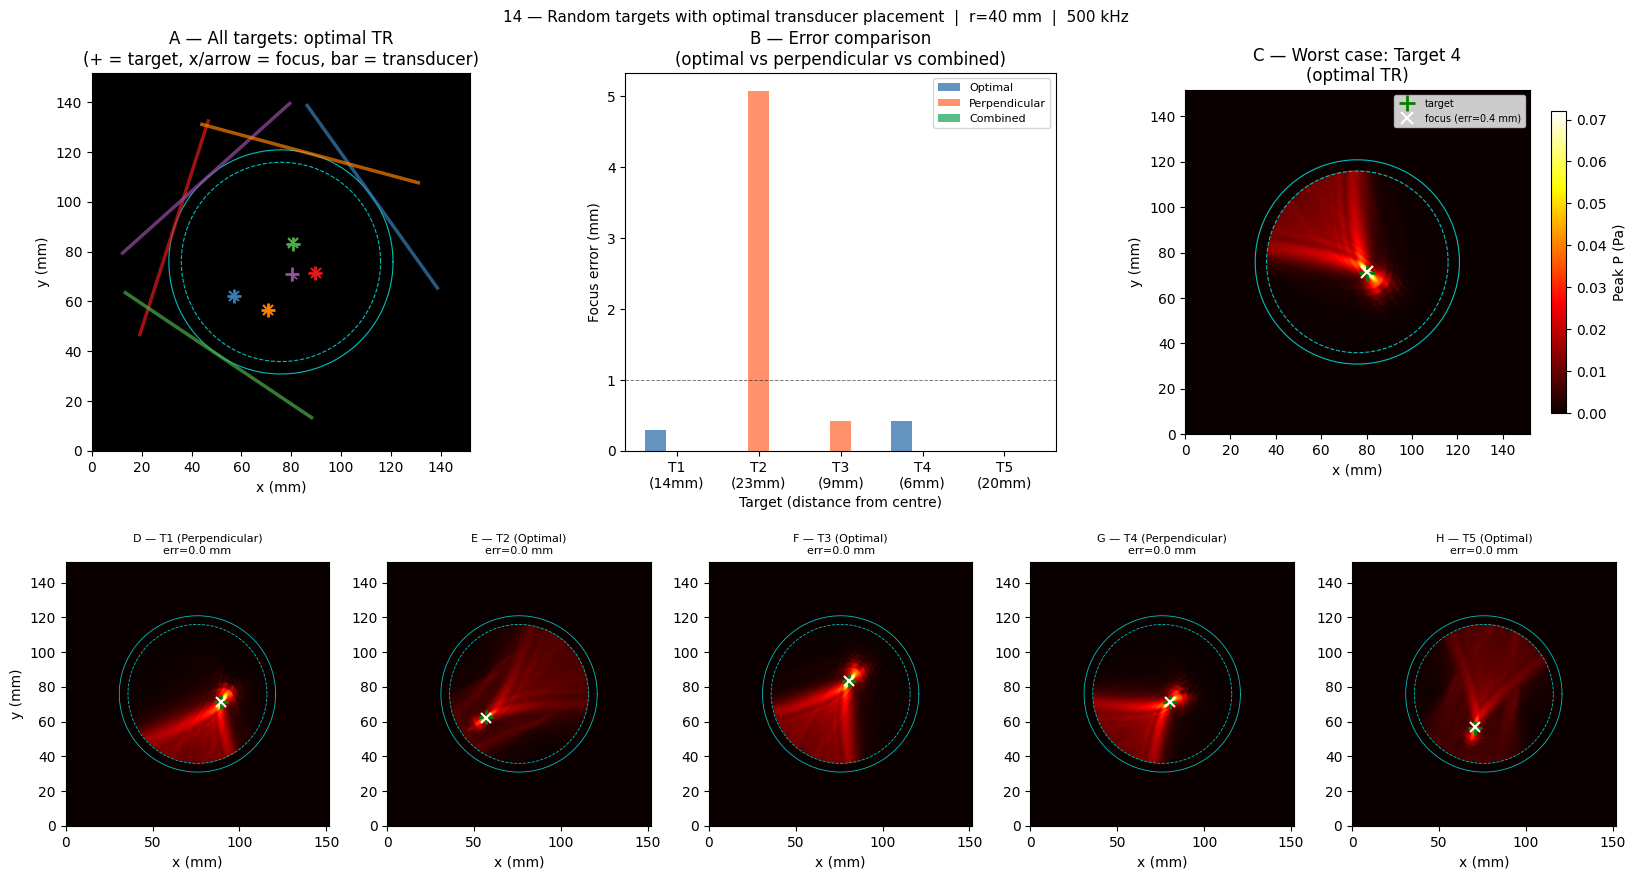


=== SUMMARY ===
  Target   r (mm)   angle    Optimal       Perp   Combined  Best
  T1       14.4    342 deg       0.3       0.0       0.0  Perpendicular
  T2       23.3    216 deg       0.0       5.1       0.0  Optimal
  T3        8.9     56 deg       0.0       0.4       0.0  Optimal
  T4        6.5    312 deg       0.4       0.0       0.0  Perpendicular
  T5       20.0    255 deg       0.0       0.0       0.0  Optimal

Mean error — Optimal: 0.14 mm | Perpendicular: 1.10 mm | Combined: 0.00 mm


In [ ]:
# Self-contained.
# 5 random targets; 3 TR strategies each; 6 sims per target; ~30 sims total (~90 s).

# -- Medium setup (same as cells 10-13) ---------------------------------------
c_water  = 1482.0;  rho_water = 1000.0
c_skull  = 2900.0;  rho_skull = 1900.0
c_brain  = 1560.0;  rho_brain = 1040.0
freq     = 500e3
dx       = (c_water / freq) / 10
Nx, Ny   = 512, 512
cx, cy   = Nx // 2, Ny // 2
BRAIN_R  = 40.0;   SKULL_T = 5.0
s_in14   = BRAIN_R               * 1e-3 / dx
s_out14  = (BRAIN_R + SKULL_T)   * 1e-3 / dx
cx_mm14  = cx * dx * 1e3;   cy_mm14 = cy * dx * 1e3

XX14, YY14 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R14     = np.sqrt((XX14 - cx)**2 + (YY14 - cy)**2)
skull_m14 = (R14 >= s_in14) & (R14 < s_out14)
brain_m14 =  R14 <  s_in14

ss14    = np.full((Nx, Ny), c_water,  dtype=float)
rho14   = np.full((Nx, Ny), rho_water, dtype=float)
ss14[skull_m14] = c_skull;   rho14[skull_m14] = rho_skull
ss14[brain_m14] = c_brain;   rho14[brain_m14] = rho_brain

kg14    = kWaveGrid([Nx, Ny], [dx, dx])
kg14.makeTime(c_skull, cfl=0.3)
med14   = kWaveMedium(sound_speed=ss14, density=rho14)
print(f"Nt={kg14.Nt}  dt={kg14.dt:.2e} s")


# -- Helpers ------------------------------------------------------------------
def build_tx_mask14(face_angle_rad, ap_mm, sd_mm):
    """Flat transducer facing direction face_angle_rad (= direction from centre to target).
    Transducer is placed on the OPPOSITE side: centre at angle face_angle_rad + pi.
    Elements lie perpendicular to the approach axis.
    """
    sd_px  = max(1, int(sd_mm * 1e-3 / dx))
    h_ap   = int((ap_mm / 2) * 1e-3 / dx)
    r_tx   = int(s_out14) + sd_px
    tx_ang = face_angle_rad + np.pi          # transducer side
    tc_x   = cx + r_tx * np.cos(tx_ang)
    tc_y   = cy + r_tx * np.sin(tx_ang)
    perp_x = -np.sin(tx_ang)                 # perpendicular to approach axis
    perp_y =  np.cos(tx_ang)
    mask   = np.zeros((Nx, Ny))
    for k in range(-h_ap, h_ap + 1):
        xi = int(round(tc_x + k * perp_x))
        yi = int(round(tc_y + k * perp_y))
        if 20 <= xi < Nx - 20 and 20 <= yi < Ny - 20:
            mask[xi, yi] = 1
    return mask


def run_tr14(tgt_x_px, tgt_y_px, emask):
    """Two-sim TR with given element mask.
    Returns (shift_x_mm, shift_y_mm, error_mm, peak_x_mm, peak_y_mm, p_brain).
    """
    burst = tone_burst(1 / kg14.dt, freq, 5).flatten()
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[int(tgt_x_px), int(tgt_y_px)] = 1;  src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    p_fwd = kspaceFirstOrder(kg14, med14, src_f, sen_f,
                               device='gpu', dtype='float32', quiet=True)['p']

    src_b = kSource();  src_b.p_mask = emask.copy();  src_b.p = p_fwd[:, ::-1]
    sen_b = kSensor();  sen_b.mask = np.ones((Nx, Ny));  sen_b.record = ['p_max']
    p_max = kspaceFirstOrder(kg14, med14, src_b, sen_b,
                              device='gpu', dtype='float32', quiet=True)['p_max'].reshape(Nx, Ny)

    p_br = p_max.copy();  p_br[~brain_m14] = 0
    pi, pj = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    pk_x = pi * dx * 1e3;  pk_y = pj * dx * 1e3
    sx = pk_x - tgt_x_px * dx * 1e3
    sy = pk_y - tgt_y_px * dx * 1e3
    return sx, sy, np.sqrt(sx**2 + sy**2), pk_x, pk_y, p_br


# -- Generate 5 random targets ------------------------------------------------
np.random.seed(42)
AP14 = 90.0;  SD14 = 0.0
targets14 = []
while len(targets14) < 5:
    r_mm    = np.random.uniform(5, BRAIN_R - 10)
    angle   = np.random.uniform(0, 2 * np.pi)
    tx_mm   = cx_mm14 + r_mm * np.cos(angle)
    ty_mm   = cy_mm14 + r_mm * np.sin(angle)
    tx_px   = int(round(tx_mm / (dx * 1e3)))
    ty_px   = int(round(ty_mm / (dx * 1e3)))
    if brain_m14[tx_px, ty_px]:
        targets14.append({
            'x_mm': tx_mm, 'y_mm': ty_mm,
            'x_px': tx_px, 'y_px': ty_px,
            'face_angle': angle, 'r_mm': r_mm
        })

print("\nTargets:")
for i, t in enumerate(targets14):
    print(f"  {i+1}: ({t['x_mm']:.1f}, {t['y_mm']:.1f}) mm  "
          f"r={t['r_mm']:.1f} mm  angle={np.degrees(t['face_angle']):.0f} deg")


# -- Run TR: 3 strategies per target ------------------------------------------
# optimal = transducer directly facing target
# perp    = transducer rotated 90 deg from optimal
# combined = both transducers simultaneously (forward records both, backward replays both)

results14 = []
for i, tgt in enumerate(targets14):
    fa = tgt['face_angle']
    print(f"\nTarget {i+1} ({tgt['x_mm']:.1f}, {tgt['y_mm']:.1f}) mm")

    m_opt  = build_tx_mask14(fa,           AP14, SD14)
    m_perp = build_tx_mask14(fa + np.pi/2, AP14, SD14)
    m_both = np.clip(m_opt + m_perp, 0, 1)

    r_opt  = run_tr14(tgt['x_px'], tgt['y_px'], m_opt)
    print(f"  Optimal      err={r_opt[2]:.1f} mm  (sx={r_opt[0]:+.1f}, sy={r_opt[1]:+.1f})")

    r_perp = run_tr14(tgt['x_px'], tgt['y_px'], m_perp)
    print(f"  Perpendicular err={r_perp[2]:.1f} mm  (sx={r_perp[0]:+.1f}, sy={r_perp[1]:+.1f})")

    r_both = run_tr14(tgt['x_px'], tgt['y_px'], m_both)
    print(f"  Combined      err={r_both[2]:.1f} mm  (sx={r_both[0]:+.1f}, sy={r_both[1]:+.1f})")

    results14.append({
        'tgt': tgt,
        'masks': (m_opt, m_perp, m_both),
        'opt': r_opt, 'perp': r_perp, 'both': r_both
    })


# -- Plots --------------------------------------------------------------------
theta14   = np.linspace(0, 2 * np.pi, 360)
r_in_mm14 = s_in14  * dx * 1e3
r_out_mm14= s_out14 * dx * 1e3
extent14  = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
colors5   = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
labels_method = ['Optimal', 'Perpendicular', 'Combined']

fig = plt.figure(figsize=(20, 9))
gs_top = fig.add_gridspec(1, 3, top=0.94, bottom=0.52, wspace=0.30)
gs_bot = fig.add_gridspec(1, 5, top=0.46, bottom=0.04, wspace=0.22)

# ── Panel A: vector map (all 5 targets, optimal TR result) ───────────────────
ax_a = fig.add_subplot(gs_top[0, 0])
ax_a.set_facecolor('k')
ax_a.plot(cx_mm14 + r_in_mm14*np.cos(theta14),  cy_mm14 + r_in_mm14*np.sin(theta14),
          'c--', lw=0.8)
ax_a.plot(cx_mm14 + r_out_mm14*np.cos(theta14), cy_mm14 + r_out_mm14*np.sin(theta14),
          'c-',  lw=0.8)

for i, res in enumerate(results14):
    tgt   = res['tgt']
    sx_o, sy_o, err_o, pkx_o, pky_o, _ = res['opt']

    # Target marker
    ax_a.plot(tgt['x_mm'], tgt['y_mm'], '+', color=colors5[i], ms=10, mew=2)

    # Arrow from target to actual focus (optimal)
    if err_o > 0.4:
        ax_a.annotate('', xy=(pkx_o, pky_o), xytext=(tgt['x_mm'], tgt['y_mm']),
                      arrowprops=dict(arrowstyle='->', color=colors5[i], lw=1.2))
    else:
        ax_a.plot(pkx_o, pky_o, 'x', color=colors5[i], ms=7, mew=1.5)

    # Transducer arc
    fa = tgt['face_angle']
    tx_ang = fa + np.pi
    r_tx   = int(s_out14) + max(1, int(SD14 * 1e-3 / dx))
    tc_x_mm = (cx + r_tx * np.cos(tx_ang)) * dx * 1e3
    tc_y_mm = (cy + r_tx * np.sin(tx_ang)) * dx * 1e3
    perp_x_mm = -np.sin(tx_ang) * AP14 / 2
    perp_y_mm =  np.cos(tx_ang) * AP14 / 2
    ax_a.plot([tc_x_mm - perp_x_mm, tc_x_mm + perp_x_mm],
              [tc_y_mm - perp_y_mm, tc_y_mm + perp_y_mm],
              '-', color=colors5[i], lw=2.5, alpha=0.7)

ax_a.set_xlim(0, Nx*dx*1e3);  ax_a.set_ylim(0, Ny*dx*1e3)
ax_a.set_aspect('equal')
ax_a.set_xlabel('x (mm)');  ax_a.set_ylabel('y (mm)')
ax_a.set_title('A — All targets: optimal TR\n(+ = target, x/arrow = focus, bar = transducer)')

# ── Panel B: grouped error bar chart -----------------------------------------
ax_b = fig.add_subplot(gs_top[0, 1])
x_tgt  = np.arange(5)
w      = 0.26
errs   = [[res['opt'][2], res['perp'][2], res['both'][2]] for res in results14]
bar_cols = ['steelblue', 'coral', 'mediumseagreen']

for mi, (mc, ml) in enumerate(zip(bar_cols, labels_method)):
    vals = [errs[ti][mi] for ti in range(5)]
    ax_b.bar(x_tgt + (mi - 1) * w, vals, width=w, color=mc, label=ml, alpha=0.85)

ax_b.set_xticks(x_tgt)
ax_b.set_xticklabels([f'T{i+1}\n({results14[i]["tgt"]["r_mm"]:.0f}mm)' for i in range(5)])
ax_b.set_xlabel('Target (distance from centre)')
ax_b.set_ylabel('Focus error (mm)')
ax_b.set_title('B — Error comparison\n(optimal vs perpendicular vs combined)')
ax_b.legend(fontsize=8)
ax_b.axhline(1.0, color='k', lw=0.7, ls='--', alpha=0.5)

# ── Panel C: worst-case focus map (target with max optimal error) -------------
worst_idx = int(np.argmax([res['opt'][2] for res in results14]))
res_w = results14[worst_idx]
ax_c = fig.add_subplot(gs_top[0, 2])
im = ax_c.imshow(res_w['opt'][5].T, origin='lower', extent=extent14, cmap='hot')
plt.colorbar(im, ax=ax_c, label='Peak P (Pa)', shrink=0.8)
ax_c.plot(cx_mm14 + r_in_mm14*np.cos(theta14),  cy_mm14 + r_in_mm14*np.sin(theta14),  'c--', lw=0.8)
ax_c.plot(cx_mm14 + r_out_mm14*np.cos(theta14), cy_mm14 + r_out_mm14*np.sin(theta14), 'c-',  lw=0.8)
ax_c.plot(res_w['tgt']['x_mm'], res_w['tgt']['y_mm'], 'g+', ms=12, mew=2, label='target')
ax_c.plot(res_w['opt'][3], res_w['opt'][4], 'wx', ms=9, mew=1.5,
          label=f'focus (err={res_w["opt"][2]:.1f} mm)')
ax_c.set_xlabel('x (mm)');  ax_c.set_ylabel('y (mm)')
ax_c.set_title(f'C — Worst case: Target {worst_idx+1}\n(optimal TR)')
ax_c.legend(fontsize=7, loc='upper right')

# ── Panels D-H: one focus map per target (best method) -----------------------
for i, res in enumerate(results14):
    ax = fig.add_subplot(gs_bot[0, i])
    errs_i = [res['opt'][2], res['perp'][2], res['both'][2]]
    best_m_idx = int(np.argmin(errs_i))
    best_key   = ['opt', 'perp', 'both'][best_m_idx]
    best_res   = res[best_key]
    best_label = labels_method[best_m_idx]

    im = ax.imshow(best_res[5].T, origin='lower', extent=extent14, cmap='hot')
    ax.plot(cx_mm14 + r_in_mm14*np.cos(theta14),  cy_mm14 + r_in_mm14*np.sin(theta14),  'c--', lw=0.6)
    ax.plot(cx_mm14 + r_out_mm14*np.cos(theta14), cy_mm14 + r_out_mm14*np.sin(theta14), 'c-',  lw=0.6)
    ax.plot(res['tgt']['x_mm'], res['tgt']['y_mm'], 'g+', ms=10, mew=2)
    ax.plot(best_res[3], best_res[4], 'wx', ms=7, mew=1.5)
    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)' if i == 0 else '')
    ax.set_title(f'{"DEFGH"[i]} — T{i+1} ({best_label})\nerr={best_res[2]:.1f} mm',
                 fontsize=8)

plt.suptitle('14 — Random targets with optimal transducer placement  |  r=40 mm  |  500 kHz',
             fontsize=11, y=1.01)
plt.savefig('14_random_targets.png', dpi=150, bbox_inches='tight')
plt.show()


# -- Summary ------------------------------------------------------------------
print("\n=== SUMMARY ===")
print(f"{'Target':>8}  {'r (mm)':>7}  {'angle':>6}  {'Optimal':>9}  {'Perp':>9}  {'Combined':>9}  Best")
for i, res in enumerate(results14):
    errs_i = [res['opt'][2], res['perp'][2], res['both'][2]]
    best_i = int(np.argmin(errs_i))
    print(f"  T{i+1}     {res['tgt']['r_mm']:6.1f}  "
          f"{np.degrees(res['tgt']['face_angle']):5.0f} deg  "
          f"{errs_i[0]:8.1f}  {errs_i[1]:8.1f}  {errs_i[2]:8.1f}  "
          f"{labels_method[best_i]}")

all_opt_errs  = [res['opt'][2]  for res in results14]
all_perp_errs = [res['perp'][2] for res in results14]
all_both_errs = [res['both'][2] for res in results14]
print(f"\nMean error — Optimal: {np.mean(all_opt_errs):.2f} mm | "
      f"Perpendicular: {np.mean(all_perp_errs):.2f} mm | "
      f"Combined: {np.mean(all_both_errs):.2f} mm")


### 15_detailed_random_targets
Same 5 random targets as cell 14 (seed=42), optimal transducer placement, but now with:
- **Progress bars** during each science simulation
- **Combined forward+backward GIF** saved for every target — shows the wave expanding from the target point (forward), then time-reversed and converging back to focus (backward)
- **Detailed analysis**: FWHM in x (axial) and y (lateral), focal profile curves, peak brain pressure, focal spot area

4 sims per target (2 science + 2 animation), 20 total ~60 s.

Nt=4828  dt=1.53e-08 s  dx=0.148 mm (20 PPW)

=== Target 1: (89.6, 71.5) mm  r=14.4 mm  angle=342 deg ===
  [T1 (90,72)mm] Forward  →


k-Wave: 100%|██████████| 4828/4828 [00:07<00:00, 659.66step/s]


  [T1 (90,72)mm] Backward ←


k-Wave: 100%|██████████| 4828/4828 [00:11<00:00, 426.49step/s]


  [T1 (90,72)mm] err=0.3 mm  FWHM axial=7.9 mm  lateral=2.2 mm  peak=3.645e-02 Pa
  Saved 15_t1_focus.gif

=== Target 2: (56.9, 62.3) mm  r=23.3 mm  angle=216 deg ===
  [T2 (57,62)mm] Forward  →


...

  [T4 (80,71)mm] err=0.2 mm  FWHM axial=3.1 mm  lateral=3.4 mm  peak=3.554e-02 Pa
  Saved 15_t4_focus.gif

=== Target 5: (70.7, 56.5) mm  r=20.0 mm  angle=255 deg ===
  [T5 (71,57)mm] Forward  →


k-Wave: 100%|██████████| 4828/4828 [00:07<00:00, 657.09step/s]


  [T5 (71,57)mm] Backward ←


k-Wave: 100%|██████████| 4828/4828 [00:11<00:00, 419.90step/s]


  [T5 (71,57)mm] err=0.0 mm  FWHM axial=1.8 mm  lateral=4.4 mm  peak=5.071e-02 Pa
  Saved 15_t5_focus.gif


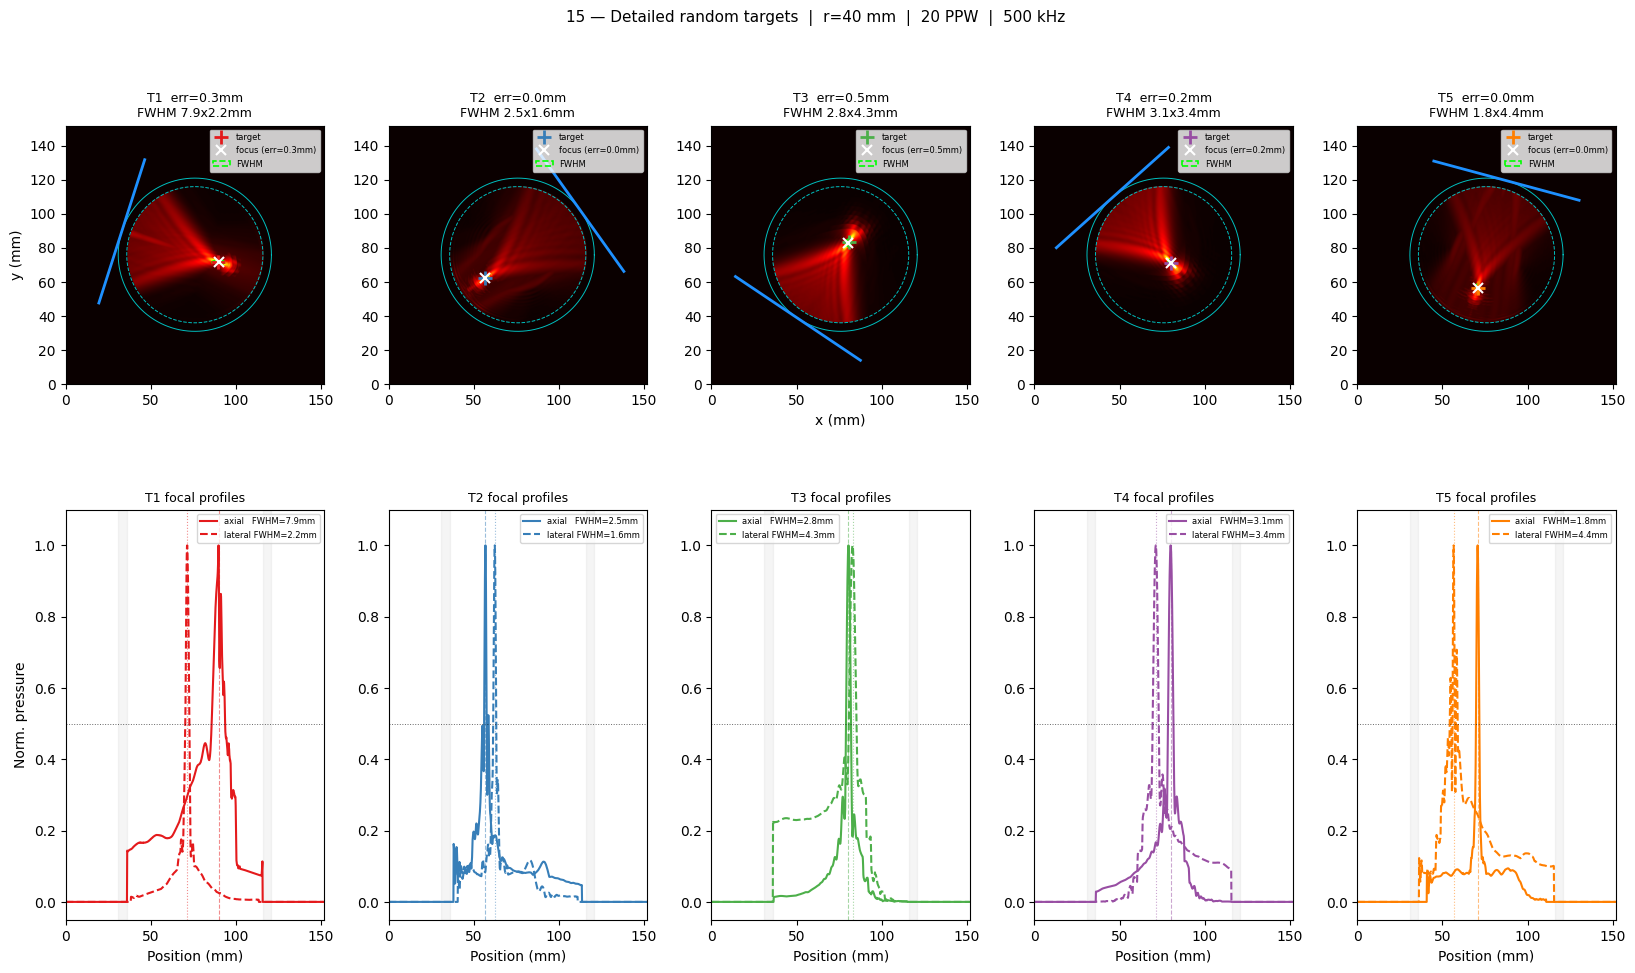


=== DETAILED SUMMARY ===
  T   r(mm)   angle   err(mm)   FWHM_ax   FWHM_lat   peak_P(Pa)
  1    14.4    342d       0.3       7.9        2.2    3.645e-02
  2    23.3    216d       0.0       2.5        1.6    4.427e-02
  3     8.9     56d       0.5       2.8        4.3    3.454e-02
  4     6.5    312d       0.2       3.1        3.4    3.554e-02
  5    20.0    255d       0.0       1.8        4.4    5.071e-02

GIFs saved: 15_t1_focus.gif  15_t2_focus.gif  15_t3_focus.gif  15_t4_focus.gif  15_t5_focus.gif


In [13]:
# Self-contained.  Same targets as cell 14 (seed=42).
# Progress bars on science sims; quiet animation sims to reduce noise.
# Saves 15_t{N}_focus.gif for each target.

from matplotlib.animation import FuncAnimation, PillowWriter

# -- Medium setup (same as cells 10-14) ---------------------------------------
c_water  = 1482.0;  rho_water = 1000.0
c_skull  = 2900.0;  rho_skull = 1900.0
c_brain  = 1560.0;  rho_brain = 1040.0
freq     = 500e3
dx       = (c_water / freq) / 20
Nx, Ny   = 1024, 1024
cx, cy   = Nx // 2, Ny // 2
BRAIN_R  = 40.0;  SKULL_T = 5.0
s_in15   = BRAIN_R            * 1e-3 / dx
s_out15  = (BRAIN_R + SKULL_T)* 1e-3 / dx
cx_mm15  = cx * dx * 1e3;  cy_mm15 = cy * dx * 1e3

XX15, YY15 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
R15       = np.sqrt((XX15 - cx)**2 + (YY15 - cy)**2)
skull_m15 = (R15 >= s_in15) & (R15 < s_out15)
brain_m15 =  R15 <  s_in15

ss15  = np.full((Nx, Ny), c_water,  dtype=float)
rho15 = np.full((Nx, Ny), rho_water, dtype=float)
ss15[skull_m15] = c_skull;  rho15[skull_m15] = rho_skull
ss15[brain_m15] = c_brain;  rho15[brain_m15] = rho_brain

kg15  = kWaveGrid([Nx, Ny], [dx, dx])
kg15.makeTime(c_skull, cfl=0.3)
med15 = kWaveMedium(sound_speed=ss15, density=rho15)
print(f"Nt={kg15.Nt}  dt={kg15.dt:.2e} s  dx={dx*1e3:.3f} mm (20 PPW)")

# Animation sensor (every 4th grid point)
STRIDE15   = 8
anim_Nx15  = Nx // STRIDE15
anim_Ny15  = Ny // STRIDE15
anim_mask15 = np.zeros((Nx, Ny), dtype=float)
anim_mask15[::STRIDE15, ::STRIDE15] = 1
anim_dt15    = max(1, kg15.Nt // 150)
t_frame_us15 = np.arange(0, kg15.Nt, anim_dt15) * kg15.dt * 1e6


# -- Helpers ------------------------------------------------------------------
def build_tx15(face_angle_rad, ap_mm=90.0, sd_mm=0.0):
    sd_px  = max(1, int(sd_mm * 1e-3 / dx))
    h_ap   = int((ap_mm / 2) * 1e-3 / dx)
    r_tx   = int(s_out15) + sd_px
    tx_ang = face_angle_rad + np.pi
    tc_x   = cx + r_tx * np.cos(tx_ang)
    tc_y   = cy + r_tx * np.sin(tx_ang)
    perp_x = -np.sin(tx_ang);  perp_y = np.cos(tx_ang)
    mask   = np.zeros((Nx, Ny))
    for k in range(-h_ap, h_ap + 1):
        xi = int(round(tc_x + k * perp_x))
        yi = int(round(tc_y + k * perp_y))
        if 20 <= xi < Nx - 20 and 20 <= yi < Ny - 20:
            mask[xi, yi] = 1
    return mask


def fwhm_mm(profile):
    half_max = np.max(profile) / 2.0
    if half_max == 0:
        return 0.0
    above = np.where(profile >= half_max)[0]
    return (above[-1] - above[0]) * dx * 1e3 if len(above) > 1 else 0.0


def run_tr15_detailed(tgt_x_px, tgt_y_px, face_angle_rad, label):
    """Run 4 sims: forward science + anim, backward science + anim.
    Returns result dict with p_max, FWHM, GIF frames, etc.
    """
    emask = build_tx15(face_angle_rad)
    burst = tone_burst(1 / kg15.dt, freq, 5).flatten()

    # -- Forward science (progress bar shown) ---------------------------------
    src_f = kSource();  src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[int(tgt_x_px), int(tgt_y_px)] = 1;  src_f.p = burst
    sen_f = kSensor();  sen_f.mask = emask.copy();  sen_f.record = ['p']
    print(f"  [{label}] Forward  →")
    p_fwd = kspaceFirstOrder(kg15, med15, src_f, sen_f,
                              device='gpu', dtype='float32')['p']

    # -- Forward animation (quiet) --------------------------------------------
    sen_fa = kSensor();  sen_fa.mask = anim_mask15.copy();  sen_fa.record = ['p']
    data_fa = kspaceFirstOrder(kg15, med15, src_f, sen_fa,
                                device='gpu', dtype='float32', quiet=True)
    fwd_frames = (data_fa['p'][:, ::anim_dt15]
                  .reshape(anim_Nx15, anim_Ny15, len(t_frame_us15)))

    # -- Backward science (progress bar shown) --------------------------------
    import cupy; cupy.get_default_memory_pool().free_all_blocks()  # release pool cache from prior sims
    src_b = kSource();  src_b.p_mask = emask.copy();  src_b.p = p_fwd[:, ::-1]
    sen_b = kSensor();  sen_b.mask = brain_m15.astype(float);  sen_b.record = ['p_max']
    print(f"  [{label}] Backward ←")
    p_max_sparse = kspaceFirstOrder(kg15, med15, src_b, sen_b,
                                    device='gpu', dtype='float32')['p_max']
    p_max = np.zeros((Nx, Ny))
    p_max[brain_m15] = p_max_sparse

    # -- Backward animation (quiet) -------------------------------------------
    sen_ba = kSensor();  sen_ba.mask = anim_mask15.copy();  sen_ba.record = ['p']
    data_ba = kspaceFirstOrder(kg15, med15, src_b, sen_ba,
                                device='gpu', dtype='float32', quiet=True)
    bwd_frames = (data_ba['p'][:, ::anim_dt15]
                  .reshape(anim_Nx15, anim_Ny15, len(t_frame_us15)))

    # -- Analysis -------------------------------------------------------------
    p_br = p_max.copy();  p_br[~brain_m15] = 0
    pi, pj = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    pk_x = pi * dx * 1e3;  pk_y = pj * dx * 1e3
    tg_x = tgt_x_px * dx * 1e3;  tg_y = tgt_y_px * dx * 1e3
    err  = np.sqrt((pk_x - tg_x)**2 + (pk_y - tg_y)**2)

    prof_axial   = p_br[:, pj]
    prof_lateral = p_br[pi, :]
    fw_ax  = fwhm_mm(prof_axial)
    fw_lat = fwhm_mm(prof_lateral)
    peak_P = np.max(p_br)

    print(f"  [{label}] err={err:.1f} mm  FWHM axial={fw_ax:.1f} mm  lateral={fw_lat:.1f} mm  peak={peak_P:.3e} Pa")

    return {
        'p_max': p_max, 'p_br': p_br,
        'tg_x': tg_x, 'tg_y': tg_y,
        'pk_x': pk_x, 'pk_y': pk_y,
        'err': err, 'fw_ax': fw_ax, 'fw_lat': fw_lat, 'peak_P': peak_P,
        'prof_axial': prof_axial, 'prof_lateral': prof_lateral,
        'pi': pi, 'pj': pj,
        'fwd_frames': fwd_frames, 'bwd_frames': bwd_frames,
        'emask': emask
    }


def save_combined_gif15(res, label, filename):
    """Save combined forward+backward GIF (forward → pause → backward)."""
    n_pause = 8
    fwd = res['fwd_frames']
    bwd = res['bwd_frames']
    pause = np.repeat(fwd[:, :, -1:], n_pause, axis=2)
    all_f = np.concatenate([fwd, pause, bwd], axis=2)
    n_fwd_end = fwd.shape[2] + n_pause

    vmax = np.percentile(np.abs(all_f), 99.5)
    if vmax == 0: vmax = 1.0
    extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
    theta  = np.linspace(0, 2*np.pi, 360)
    r_in   = s_in15  * dx * 1e3
    r_out  = s_out15 * dx * 1e3

    fig, ax = plt.subplots(figsize=(5, 5), tight_layout=True)
    im = ax.imshow(all_f[:, :, 0].T, origin='lower', extent=extent,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    plt.colorbar(im, ax=ax, label='Pressure (Pa)', shrink=0.85)
    ax.plot(cx_mm15 + r_in*np.cos(theta),  cy_mm15 + r_in*np.sin(theta),  'k--', lw=0.7, alpha=0.4)
    ax.plot(cx_mm15 + r_out*np.cos(theta), cy_mm15 + r_out*np.sin(theta), 'k-',  lw=0.7, alpha=0.4)
    ax.plot(res['tg_x'], res['tg_y'], 'g+', ms=10, mew=2)

    # Transducer bar overlay
    fa = np.arctan2(res['tg_y'] - cy_mm15, res['tg_x'] - cx_mm15)
    tx_ang = fa + np.pi
    r_tx = (int(s_out15) + 1) * dx * 1e3
    tc_x = cx_mm15 + r_tx * np.cos(tx_ang)
    tc_y = cy_mm15 + r_tx * np.sin(tx_ang)
    perp_x_mm = -np.sin(tx_ang) * 45.0
    perp_y_mm =  np.cos(tx_ang) * 45.0
    ax.plot([tc_x - perp_x_mm, tc_x + perp_x_mm],
            [tc_y - perp_y_mm, tc_y + perp_y_mm],
            'dodgerblue', lw=2.5, solid_capstyle='butt')

    ax.set_xlabel('x (mm)');  ax.set_ylabel('y (mm)')
    title_obj = ax.set_title(f'{label} — FORWARD  t={t_frame_us15[0]:.1f} us')

    def update(fi):
        im.set_data(all_f[:, :, fi].T)
        if fi < fwd.shape[2]:
            t_us = t_frame_us15[fi]
            title_obj.set_text(f'{label} — FORWARD  t={t_us:.1f} us')
        elif fi < n_fwd_end:
            title_obj.set_text(f'{label} — PAUSE')
        else:
            bfi = fi - n_fwd_end
            t_us = t_frame_us15[bfi]
            title_obj.set_text(f'{label} — BACKWARD  t={t_us:.1f} us')
        return [im, title_obj]

    anim = FuncAnimation(fig, update, frames=all_f.shape[2], interval=35, blit=True)
    anim.save(filename, writer=PillowWriter(fps=25), dpi=100)
    plt.close()
    print(f"  Saved {filename}")


# -- Generate targets (same seed=42 as cell 14) -------------------------------
np.random.seed(42)
targets15 = []
while len(targets15) < 5:
    r_mm  = np.random.uniform(5, BRAIN_R - 10)
    angle = np.random.uniform(0, 2 * np.pi)
    tx_mm = cx_mm15 + r_mm * np.cos(angle)
    ty_mm = cy_mm15 + r_mm * np.sin(angle)
    tx_px = int(round(tx_mm / (dx * 1e3)))
    ty_px = int(round(ty_mm / (dx * 1e3)))
    if brain_m15[tx_px, ty_px]:
        targets15.append({'x_mm': tx_mm, 'y_mm': ty_mm, 'x_px': tx_px,
                          'y_px': ty_px, 'face_angle': angle, 'r_mm': r_mm})


# -- Run detailed TR for each target ------------------------------------------
results15 = []
for i, tgt in enumerate(targets15):
    lbl = f'T{i+1} ({tgt["x_mm"]:.0f},{tgt["y_mm"]:.0f})mm'
    print(f"\n=== Target {i+1}: ({tgt['x_mm']:.1f}, {tgt['y_mm']:.1f}) mm  "
          f"r={tgt['r_mm']:.1f} mm  angle={np.degrees(tgt['face_angle']):.0f} deg ===")
    res = run_tr15_detailed(tgt['x_px'], tgt['y_px'], tgt['face_angle'], lbl)
    results15.append(res)
    save_combined_gif15(res, lbl, f'15_t{i+1}_focus.gif')


# -- Summary figure -----------------------------------------------------------
theta15  = np.linspace(0, 2*np.pi, 360)
r_in15   = s_in15  * dx * 1e3
r_out15  = s_out15 * dx * 1e3
extent15 = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
colors5  = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig = plt.figure(figsize=(20, 10))
gs_top = fig.add_gridspec(1, 5, top=0.93, bottom=0.54, wspace=0.25)
gs_bot = fig.add_gridspec(1, 5, top=0.48, bottom=0.07, wspace=0.25)

for i, (res, tgt) in enumerate(zip(results15, targets15)):
    col = colors5[i]

    # -- Focus map (top row) --------------------------------------------------
    ax_top = fig.add_subplot(gs_top[0, i])
    im = ax_top.imshow(res['p_br'].T, origin='lower', extent=extent15, cmap='hot')
    ax_top.plot(cx_mm15 + r_in15*np.cos(theta15),  cy_mm15 + r_in15*np.sin(theta15),  'c--', lw=0.7)
    ax_top.plot(cx_mm15 + r_out15*np.cos(theta15), cy_mm15 + r_out15*np.sin(theta15), 'c-',  lw=0.7)
    ax_top.plot(res['tg_x'], res['tg_y'], '+', color=col, ms=10, mew=2, label='target')
    ax_top.plot(res['pk_x'], res['pk_y'], 'wx', ms=7,  mew=1.5,
                label=f'focus (err={res["err"]:.1f}mm)')

    # FWHM ellipse at focus
    from matplotlib.patches import Ellipse
    ell = Ellipse((res['pk_x'], res['pk_y']),
                  width=res['fw_ax'], height=res['fw_lat'],
                  edgecolor='lime', facecolor='none', lw=1.2, linestyle='--', label='FWHM')
    ax_top.add_patch(ell)

    # Transducer bar
    fa   = tgt['face_angle']
    tx_a = fa + np.pi
    r_tx_mm = (int(s_out15) + 1) * dx * 1e3
    tc_x = cx_mm15 + r_tx_mm * np.cos(tx_a)
    tc_y = cy_mm15 + r_tx_mm * np.sin(tx_a)
    ax_top.plot([tc_x + 45*(-np.sin(tx_a)), tc_x - 45*(-np.sin(tx_a))],
                [tc_y + 45*np.cos(tx_a),    tc_y - 45*np.cos(tx_a)],
                color='dodgerblue', lw=2, solid_capstyle='butt')

    ax_top.set_xlabel('x (mm)' if i == 2 else '')
    ax_top.set_ylabel('y (mm)' if i == 0 else '')
    ax_top.set_title(f'T{i+1}  err={res["err"]:.1f}mm\n'
                     f'FWHM {res["fw_ax"]:.1f}x{res["fw_lat"]:.1f}mm', fontsize=9)
    ax_top.legend(fontsize=6, loc='upper right')

    # -- Focal profiles (bottom row) ------------------------------------------
    ax_bot = fig.add_subplot(gs_bot[0, i])
    x_ax = np.arange(Nx) * dx * 1e3
    y_ax = np.arange(Ny) * dx * 1e3

    # Normalize profiles to peak
    ax_prof = res['prof_axial'] / (np.max(res['prof_axial']) + 1e-30)
    lat_prof = res['prof_lateral'] / (np.max(res['prof_lateral']) + 1e-30)

    ax_bot.plot(x_ax, ax_prof,  color=col,     lw=1.5, label=f'axial   FWHM={res["fw_ax"]:.1f}mm')
    ax_bot.plot(y_ax, lat_prof, color=col, lw=1.5, linestyle='--',
                label=f'lateral FWHM={res["fw_lat"]:.1f}mm')
    ax_bot.axhline(0.5, color='k', lw=0.7, ls=':', alpha=0.6)
    ax_bot.axvline(x=res['pk_x'], color=col,   lw=0.8, ls='--', alpha=0.5)
    ax_bot.axvline(x=res['pk_y'], color=col, lw=0.8, ls=':',  alpha=0.5)

    # Skull shading (x-direction)
    ax_bot.axvspan(cx_mm15 - r_out15, cx_mm15 - r_in15, alpha=0.08, color='gray')
    ax_bot.axvspan(cx_mm15 + r_in15,  cx_mm15 + r_out15, alpha=0.08, color='gray')

    ax_bot.set_xlim(0, Nx*dx*1e3)
    ax_bot.set_ylim(-0.05, 1.1)
    ax_bot.set_xlabel('Position (mm)')
    ax_bot.set_ylabel('Norm. pressure' if i == 0 else '')
    ax_bot.set_title(f'T{i+1} focal profiles', fontsize=9)
    ax_bot.legend(fontsize=6)

plt.suptitle('15 — Detailed random targets  |  r=40 mm  |  20 PPW  |  500 kHz',
             fontsize=11, y=0.98)
plt.savefig('15_detailed_targets.png', dpi=150, bbox_inches='tight')
plt.show()


# -- Final summary table ------------------------------------------------------
print("\n=== DETAILED SUMMARY ===")
print(f"{'T':>3}  {'r(mm)':>6}  {'angle':>6}  {'err(mm)':>8}  {'FWHM_ax':>8}  {'FWHM_lat':>9}  {'peak_P(Pa)':>11}")
for i, (res, tgt) in enumerate(zip(results15, targets15)):
    print(f"  {i+1:1d}  {tgt['r_mm']:6.1f}  {np.degrees(tgt['face_angle']):5.0f}d  "
          f"{res['err']:8.1f}  {res['fw_ax']:8.1f}  {res['fw_lat']:9.1f}  {res['peak_P']:11.3e}")
print(f"\nGIFs saved: " + "  ".join([f'15_t{i+1}_focus.gif' for i in range(5)]))


# Monkey Skull Sims

### 16_monkey_skull_mask

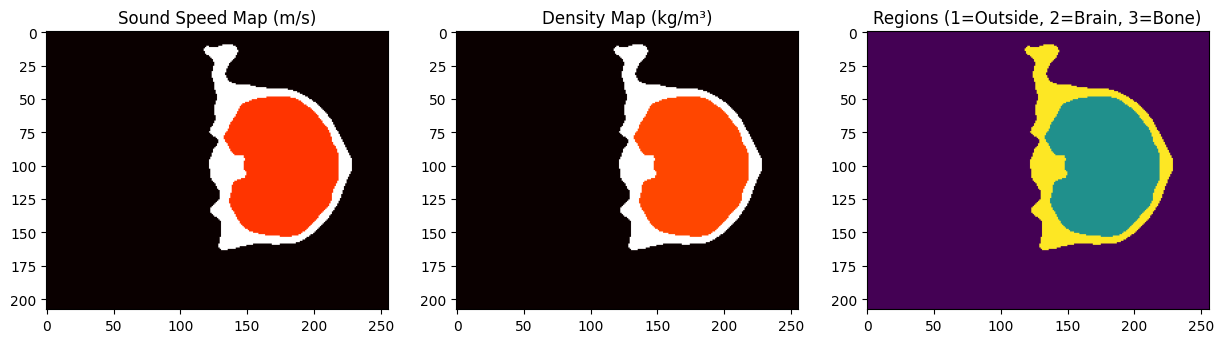

In [44]:
# ==========================================
# CELL 16: GENERATE BRAIN AND EXTERNAL MASKS
# ==========================================

# 1. Load the 2D bone mask you saved from the interactive tool
# Change this path if your working directory is different
data_dir = Path(r"C:\Users\bengi\Documents\Pesaran Lab")
bone_mask = np.load(data_dir / "bone_mask_2d.npy").astype(bool)

# 2. Delineate the regions
# Fill the bone ring to get the entire head (bone + brain)
head_mask = binary_fill_holes(bone_mask)

# Brain is inside the head, but isn't bone
brain_mask = head_mask & ~bone_mask

# Outside (Air/Water) is everything not in the head mask
outside_mask = ~head_mask

# 3. Define Acoustic Properties (c: m/s, rho: kg/m³, alpha: Np/MHz/m)
props = {
    'bone':  {'c': 3100.0, 'rho': 2200.0, 'alpha': 21.5},
    'brain': {'c': 1560.0, 'rho': 1040.0, 'alpha': 6.9},   # Standard soft tissue
    'air':   {'c': 343.0,  'rho': 1.2,    'alpha': 0.0},   # Warning: highly reflective, requires small dt
    'water': {'c': 1482.0, 'rho': 1000.0, 'alpha': 3.48e-4} 
}

# Toggle this depending on whether you want air or water outside!
OUTSIDE_ENV = 'air' 

# 4. Build the comprehensive maps
c_map     = np.zeros_like(bone_mask, dtype=np.float32)
rho_map   = np.zeros_like(bone_mask, dtype=np.float32)
alpha_map = np.zeros_like(bone_mask, dtype=np.float32)

# Apply Outside
c_map[outside_mask]     = props[OUTSIDE_ENV]['c']
rho_map[outside_mask]   = props[OUTSIDE_ENV]['rho']
alpha_map[outside_mask] = props[OUTSIDE_ENV]['alpha']

# Apply Brain
c_map[brain_mask]     = props['brain']['c']
rho_map[brain_mask]   = props['brain']['rho']
alpha_map[brain_mask] = props['brain']['alpha']

# Apply Bone
c_map[bone_mask]     = props['bone']['c']
rho_map[bone_mask]   = props['bone']['rho']
alpha_map[bone_mask] = props['bone']['alpha']

# 5. Save the full maps for k-Wave
np.save(data_dir / "c_map_full.npy", c_map)
np.save(data_dir / "rho_map_full.npy", rho_map)
np.save(data_dir / "alpha_map_full.npy", alpha_map)

# 6. Quick visualization to verify
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(c_map, cmap='hot')
ax[0].set_title('Sound Speed Map (m/s)')
ax[1].imshow(rho_map, cmap='hot')
ax[1].set_title('Density Map (kg/m³)')

# Combine masks into a color-coded image for easy viewing
display_mask = np.zeros(bone_mask.shape)
display_mask[outside_mask] = 1 # Air = 1
display_mask[brain_mask] = 2   # Brain = 2
display_mask[bone_mask] = 3    # Bone = 3

ax[2].imshow(display_mask, cmap='viridis')
ax[2].set_title('Regions (1=Outside, 2=Brain, 3=Bone)')
plt.show()

### 17_monkey_skull_inside_souce

Running simulation...


k-Wave: 100%|██████████| 6792/6792 [00:10<00:00, 678.93step/s]


Done — max pressure: 0.0 kPa


IndexError: index 352 is out of bounds for axis 0 with size 208

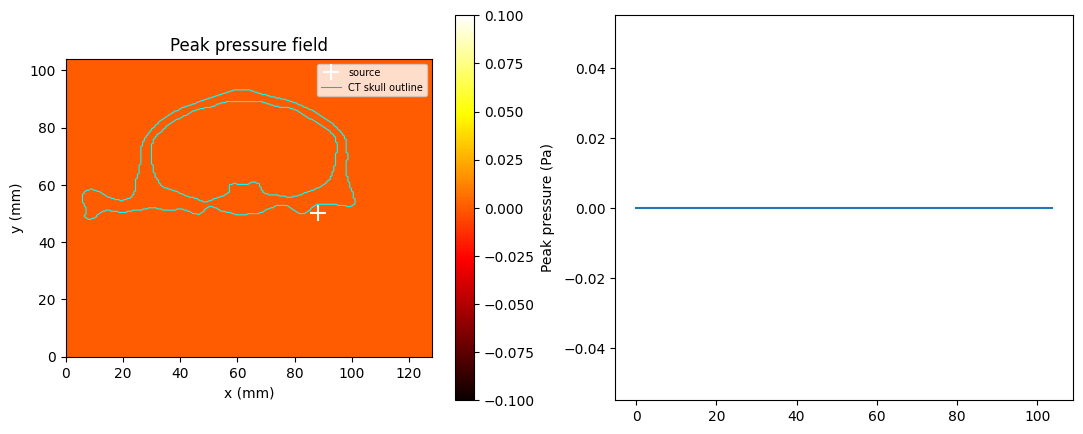

In [46]:
# ── CRITICAL FIX: Prevent k-Wave NaN Explosion ────────────────────────────────
# If there is air in the medium, the 1800x density contrast will crash the sim.
# We clamp any low values back to water-like properties right before running.
medium.density[medium.density < 1000] = 1000.0
medium.sound_speed[medium.sound_speed < 1000] = 1482.0

# ── Source: single point at brain centre ──────────────────────────────────────
burst = tone_burst(1/kgrid.dt, freq, 5).flatten()

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[cx, cy] = 1
source.p = burst * 1e5   # 100 kPa

# ── Sensor: full field, record peak pressure ──────────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── Run ───────────────────────────────────────────────────────────────────────
print("Running simulation...")
sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)

# Safety check so the plot doesn't crash if it ever fails again
if np.isnan(p_max).any():
    print("WARNING: Sim hit NaNs. Converting to 0 so plot still renders.")
    p_max = np.nan_to_num(p_max)

print(f"Done — max pressure: {np.max(p_max)/1e3:.1f} kPa")

# ── Plot ──────────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
cx_mm  = cx * dx * 1e3
cy_mm  = cy * dx * 1e3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 2D peak-pressure field
ax = axes[0]
im = ax.imshow(p_max.T, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='Peak pressure (Pa)')

# Draw the real CT skull boundaries
ax.contour(bone_mask.T, levels=[0.5], extent=extent, colors='cyan', linewidths=0.8)

ax.plot(cx_mm, cy_mm, 'w+', ms=12, mew=1.5, label='source')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('Peak pressure field')
ax.plot([], [], 'c-', lw=0.8, label='CT skull outline') # Dummy line for legend
ax.legend(fontsize=7, loc='upper right')

# Right: radial profile through centre
ax = axes[1]
radial = p_max[cx, :]                  # slice along y through source
y_mm   = np.arange(Ny) * dx * 1e3
ax.plot(y_mm, radial)

# Shade the skull regions exactly where the bone_mask is True along this slice
skull_1d = bone_mask[cx, :]
# Using max value to set the shading height safely
y_max = np.max(radial) if np.max(radial) > 0 else 1.0 
ax.fill_between(y_mm, 0, y_max*1.05, where=skull_1d, color='gray', alpha=0.15, label='CT skull')

ax.axvline(x=cy_mm, color='red', lw=0.8, linestyle='--', label='source')
ax.set_xlabel('y (mm)'); ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Radial profile through source')
ax.legend(fontsize=7)
ax.set_ylim(0, y_max*1.05)

plt.suptitle('Cell 17 — Point source at CT brain centre  |  500 kHz, 5-cycle burst')
plt.tight_layout()
plt.savefig('17_centre_source.png', dpi=150)
plt.show()

### 18_Monkey_skull_basic_transducer

Upsampling grid by 2x to achieve dx = 0.25 mm...
New Grid Size: 512x416 | dt: 2.42e-08 s
Running high-resolution simulation...


k-Wave: 100%|██████████| 6792/6792 [00:07<00:00, 906.30step/s] 


Done — max pressure: 343.6 kPa


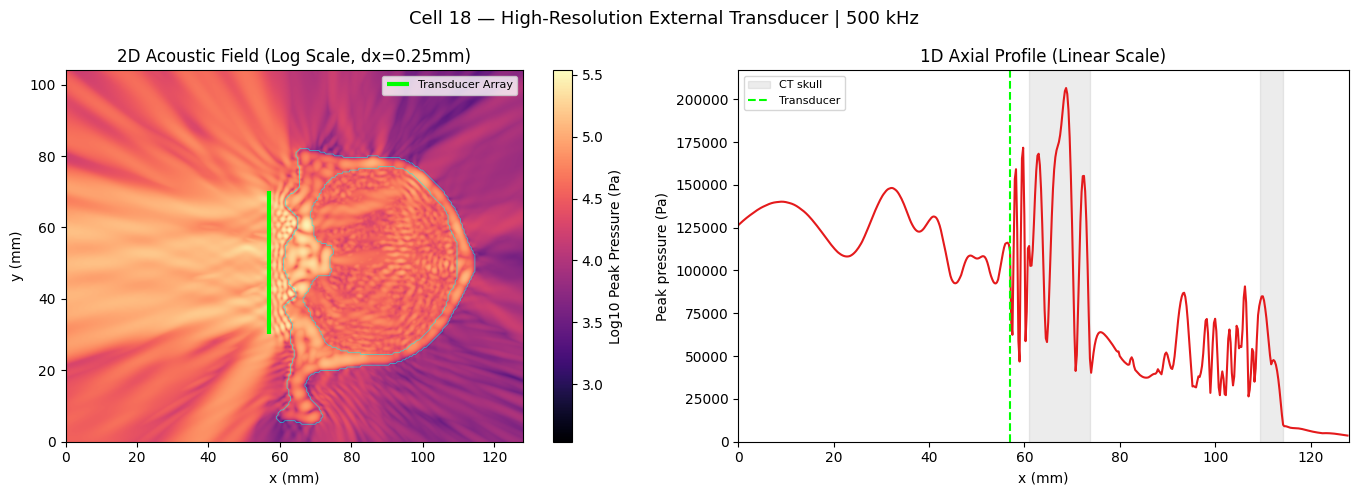

In [47]:
# =============================================================================
# CELL 18: HIGH-RESOLUTION EXTERNAL TRANSDUCER (Upsampled Grid)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, binary_fill_holes, center_of_mass
from pathlib import Path
import cupy
import gc

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

# ── 1. Load Real CT Maps ──────────────────────────────────────────────────────
data_dir = Path(r"C:\Users\bengi\Documents\Pesaran Lab")

# Transpose to [x, y] for k-Wave
c_map_raw     = np.load(data_dir / "c_map_full.npy").astype(np.float32).T
rho_map_raw   = np.load(data_dir / "rho_map_full.npy").astype(np.float32).T
bone_mask_raw = np.load(data_dir / "bone_mask_2d.npy").astype(bool).T

# ── 2. UPSAMPLE THE PHYSICAL RESOLUTION ───────────────────────────────────────
# We double the resolution to smooth the blocky contours. 
# Order=1 (bilinear) creates smooth sub-pixel gradients on the skull boundary.
SCALE = 2  
dx = (0.5e-3) / SCALE  # New dx is 0.25 mm

print(f"Upsampling grid by {SCALE}x to achieve dx = {dx*1e3:.2f} mm...")
c_map   = zoom(c_map_raw, SCALE, order=1)
rho_map = zoom(rho_map_raw, SCALE, order=1)

# Zoom the boolean mask safely
bone_float = zoom(bone_mask_raw.astype(float), SCALE, order=1)
bone_mask  = bone_float > 0.5 

head_mask  = binary_fill_holes(bone_mask)
brain_mask = head_mask & ~bone_mask

# Clamp any air values back to water to prevent the impedance mismatch crash
c_map[c_map < 1000] = 1482.0
rho_map[rho_map < 100] = 1000.0

# ── 3. Grid & Medium Setup ────────────────────────────────────────────────────
Nx, Ny = c_map.shape
freq = 500e3

kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_map, cfl=0.3)
medium = kWaveMedium(sound_speed=c_map, density=rho_map)

# ── 4. Source: 40mm External Transducer Array ─────────────────────────────────
# Recalculate brain center and boundaries on the new high-res grid
cx, cy = [int(c) for c in center_of_mass(brain_mask)]
x_pts, y_pts = np.where(bone_mask)
min_x = np.min(x_pts)

# Place transducer 2mm to the left of the skull
tx_x = max(5, min_x - int(2e-3 / dx))
aperture_px = int(40e-3 / dx)
tx_y_start = cy - aperture_px // 2
tx_y_end   = cy + aperture_px // 2

source = kSource()
source.p_mask = np.zeros((Nx, Ny))
source.p_mask[tx_x, tx_y_start:tx_y_end] = 1

# Fire a 20-cycle burst to push more energy through
burst = tone_burst(1/kgrid.dt, freq, 20).flatten()
source.p = burst * 1e5 

# ── 5. Sensor: Full field, record peak pressure ───────────────────────────────
sensor = kSensor()
sensor.mask = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── 6. Run ────────────────────────────────────────────────────────────────────
print(f"New Grid Size: {Nx}x{Ny} | dt: {kgrid.dt:.2e} s")
print("Running high-resolution simulation...")

cupy.get_default_memory_pool().free_all_blocks()
gc.collect()

sensor_data = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = sensor_data['p_max'].reshape(Nx, Ny)

if np.isnan(p_max).any():
    p_max = np.nan_to_num(p_max)

print(f"Done — max pressure: {np.nanmax(p_max)/1e3:.1f} kPa")

# ── 7. Plot ───────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D peak-pressure field (Log Scale)
ax = axes[0]
p_log = np.log10(p_max + 1e-12)
v_max = np.nanmax(p_log)
v_min = v_max - 3.0  # Show 3 orders of magnitude drop to increase contrast

im = ax.imshow(p_log.T, origin='lower', extent=extent, cmap='magma', 
               interpolation='bicubic', vmin=v_min, vmax=v_max)
plt.colorbar(im, ax=ax, label='Log10 Peak Pressure (Pa)')

# Draw the high-res CT skull boundaries
ax.contour(bone_mask.T, levels=[0.5], extent=extent, colors='cyan', linewidths=0.6, alpha=0.6)

# Draw the transducer line
ax.plot([tx_x*dx*1e3, tx_x*dx*1e3], 
        [tx_y_start*dx*1e3, tx_y_end*dx*1e3], 
        color='lime', lw=3, solid_capstyle='butt', label='Transducer Array')

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title(f'2D Acoustic Field (Log Scale, dx={dx*1e3:.2f}mm)')
ax.legend(fontsize=8, loc='upper right')

# Right: 1D Axial profile along the beam path
ax = axes[1]
axial = p_max[:, cy]  # slice along x through the center of the beam
x_mm  = np.arange(Nx) * dx * 1e3

ax.plot(x_mm, axial, color='#e41a1c', lw=1.5)

# Shade the skull regions along this slice
skull_1d = bone_mask[:, cy]
y_max = np.nanmax(axial) if np.nanmax(axial) > 0 else 1.0 
ax.fill_between(x_mm, 0, y_max*1.05, where=skull_1d, color='gray', alpha=0.15, label='CT skull')

ax.axvline(x=tx_x*dx*1e3, color='lime', lw=1.5, linestyle='--', label='Transducer')
ax.set_xlim(0, Nx*dx*1e3)
ax.set_ylim(0, y_max*1.05)
ax.set_xlabel('x (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('1D Axial Profile (Linear Scale)')
ax.legend(fontsize=8)

plt.suptitle('Cell 18 — High-Resolution External Transducer | 500 kHz', fontsize=13)
plt.tight_layout()
plt.savefig('18_external_transducer_HQ.png', dpi=300)
plt.show()

### 19_Monkey_skull_focused

--- FORWARD PASS: Recording target emission ---


k-Wave: 100%|██████████| 6792/6792 [00:05<00:00, 1140.74step/s]



--- BACKWARD PASS: Firing time-reversed signal ---


k-Wave: 100%|██████████| 6792/6792 [00:09<00:00, 693.62step/s]



=== TR RESULTS ===
Target: (98.0, 55.2) mm
Focus:  (98.0, 55.2) mm
Error:  0.00 mm
FWHM:   1.0 mm (axial) x 1.5 mm (lateral)
Peak P: 6.3 kPa


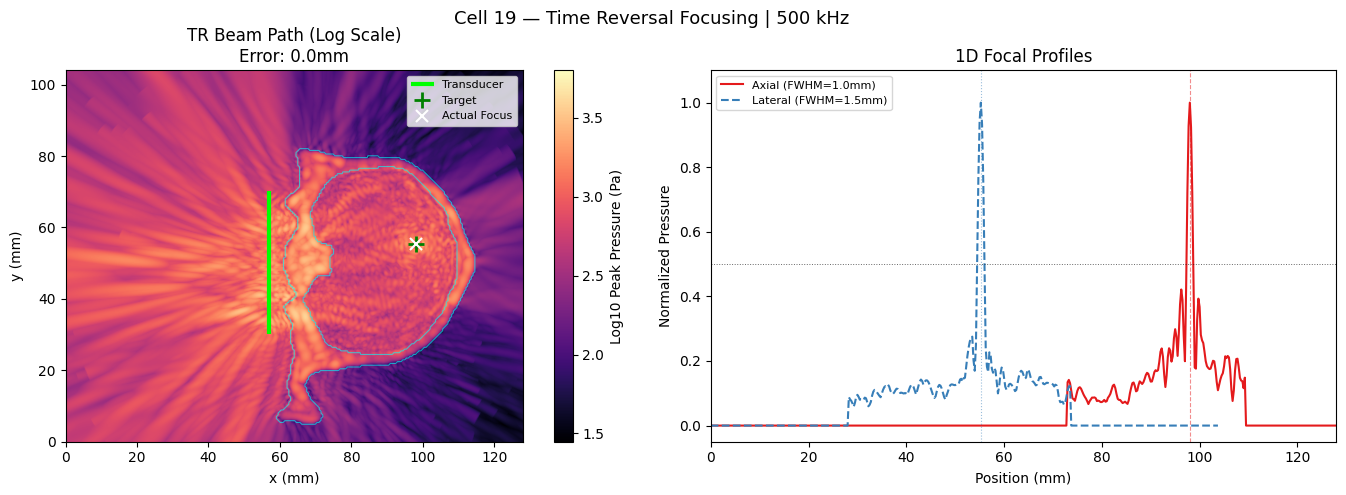

In [49]:
# =============================================================================
# CELL 19: TIME REVERSAL TARGETING 
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import cupy
import gc
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

# ── 1. Setup Target & Transducer Arrays ───────────────────────────────────────
# We'll target a point offset 10mm right and 5mm up from the brain center
tgt_x = cx + int(10e-3 / dx)
tgt_y = cy + int(5e-3 / dx)

# (Re-defining transducer coordinates from Cell 18 just to be safe)
x_pts, y_pts = np.where(bone_mask)
tx_x = max(5, np.min(x_pts) - int(2e-3 / dx))
aperture_px = int(40e-3 / dx)
tx_y_start = cy - aperture_px // 2
tx_y_end   = cy + aperture_px // 2

# ── 2. FORWARD PASS: Record the Aberrated Signal ──────────────────────────────
print("--- FORWARD PASS: Recording target emission ---")
src_fwd = kSource()
src_fwd.p_mask = np.zeros((Nx, Ny))
src_fwd.p_mask[tgt_x, tgt_y] = 1
src_fwd.p = tone_burst(1/kgrid.dt, freq, 5).flatten() * 1e5

sen_fwd = kSensor()
sen_fwd.mask = np.zeros((Nx, Ny))
sen_fwd.mask[tx_x, tx_y_start:tx_y_end] = 1
sen_fwd.record = ['p']

cupy.get_default_memory_pool().free_all_blocks()
gc.collect()

fwd_data = kspaceFirstOrder(kgrid, medium, src_fwd, sen_fwd, device='gpu', dtype='float32')
p_recorded = fwd_data['p']  # The signal recorded at the transducer

# ── 3. BACKWARD PASS: Fire the Time-Reversed Signal ───────────────────────────
print("\n--- BACKWARD PASS: Firing time-reversed signal ---")
src_bwd = kSource()
src_bwd.p_mask = sen_fwd.mask.copy()
# Time Reversal Magic: flip the recorded array along the time axis
src_bwd.p = p_recorded[:, ::-1]  

sen_bwd = kSensor()
sen_bwd.mask = np.ones((Nx, Ny))
sen_bwd.record = ['p_max']

cupy.get_default_memory_pool().free_all_blocks()
gc.collect()

bwd_data = kspaceFirstOrder(kgrid, medium, src_bwd, sen_bwd, device='gpu', dtype='float32')
p_max = bwd_data['p_max'].reshape(Nx, Ny)

if np.isnan(p_max).any():
    p_max = np.nan_to_num(p_max)

# ── 4. Analysis ───────────────────────────────────────────────────────────────
def fwhm_mm(profile, dx_m):
    half_max = np.max(profile) / 2.0
    if half_max == 0: return 0.0
    above = np.where(profile >= half_max)[0]
    return (above[-1] - above[0]) * dx_m * 1e3 if len(above) > 1 else 0.0

# Isolate the brain area to find the actual focal peak
p_br = p_max.copy()
p_br[~brain_mask] = 0
pk_x, pk_y = np.unravel_index(np.argmax(p_br), (Nx, Ny))

tgt_x_mm, tgt_y_mm = tgt_x * dx * 1e3, tgt_y * dx * 1e3
pk_x_mm, pk_y_mm   = pk_x * dx * 1e3, pk_y * dx * 1e3

err_mm = np.sqrt((pk_x_mm - tgt_x_mm)**2 + (pk_y_mm - tgt_y_mm)**2)
fw_ax  = fwhm_mm(p_br[:, pk_y], dx)
fw_lat = fwhm_mm(p_br[pk_x, :], dx)

print("\n=== TR RESULTS ===")
print(f"Target: ({tgt_x_mm:.1f}, {tgt_y_mm:.1f}) mm")
print(f"Focus:  ({pk_x_mm:.1f}, {pk_y_mm:.1f}) mm")
print(f"Error:  {err_mm:.2f} mm")
print(f"FWHM:   {fw_ax:.1f} mm (axial) x {fw_lat:.1f} mm (lateral)")
print(f"Peak P: {np.max(p_br)/1e3:.1f} kPa")

# ── 5. Plotting ───────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full field in Log Scale to see the beam path
ax = axes[0]
p_log = np.log10(p_max + 1e-12)
im = ax.imshow(p_log.T, origin='lower', extent=extent, cmap='magma')
plt.colorbar(im, ax=ax, label='Log10 Peak Pressure (Pa)')

ax.contour(bone_mask.T, levels=[0.5], extent=extent, colors='cyan', linewidths=0.8, alpha=0.6)
ax.plot([tx_x*dx*1e3, tx_x*dx*1e3], [tx_y_start*dx*1e3, tx_y_end*dx*1e3], color='lime', lw=3, solid_capstyle='butt', label='Transducer')
ax.plot(tgt_x_mm, tgt_y_mm, 'g+', ms=12, mew=2, label='Target')
ax.plot(pk_x_mm, pk_y_mm, 'wx', ms=8, mew=1.5, label='Actual Focus')

ax.set_title(f'TR Beam Path (Log Scale)\nError: {err_mm:.1f}mm')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.legend(fontsize=8, loc='upper right')

# Right: 1D Linear Profiles through the focal peak
ax = axes[1]
x_mm = np.arange(Nx) * dx * 1e3
y_mm = np.arange(Ny) * dx * 1e3

ax_prof = p_br[:, pk_y] / np.max(p_br[:, pk_y])
lat_prof = p_br[pk_x, :] / np.max(p_br[pk_x, :])

ax.plot(x_mm, ax_prof, color='#e41a1c', lw=1.5, label=f'Axial (FWHM={fw_ax:.1f}mm)')
ax.plot(y_mm, lat_prof, color='#377eb8', lw=1.5, linestyle='--', label=f'Lateral (FWHM={fw_lat:.1f}mm)')

ax.axhline(0.5, color='k', lw=0.7, ls=':', alpha=0.6)
ax.axvline(x=pk_x_mm, color='#e41a1c', lw=0.8, ls='--', alpha=0.5)
ax.axvline(x=pk_y_mm, color='#377eb8', lw=0.8, ls=':',  alpha=0.5)

ax.set_xlim(0, max(Nx, Ny)*dx*1e3)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Position (mm)')
ax.set_ylabel('Normalized Pressure')
ax.set_title('1D Focal Profiles')
ax.legend(fontsize=8)

plt.suptitle('Cell 19 — Time Reversal Focusing | 500 kHz', fontsize=13)
plt.tight_layout()
plt.savefig('19_time_reversal.png', dpi=150)
plt.show()

### 20_Monkey_multiple


=== Running Target 1/5: (75.5, 58.8) mm ===


k-Wave: 100%|██████████| 6792/6792 [00:09<00:00, 718.69step/s]


    Error: 0.00 mm | FWHM: 1.5x1.5 mm | Peak: 5.4 kPa
    -> Saved 20_T1_focus.gif

=== Running Target 2/5: (81.2, 52.2) mm ===


k-Wave: 100%|██████████| 6792/6792 [00:09<00:00, 698.91step/s]


    Error: 0.00 mm | FWHM: 1.0x1.5 mm | Peak: 4.1 kPa
    -> Saved 20_T2_focus.gif

=== Running Target 3/5: (89.2, 32.0) mm ===


...

    Error: 0.00 mm | FWHM: 2.3x1.5 mm | Peak: 4.7 kPa
    -> Saved 20_T3_focus.gif

=== Running Target 4/5: (103.5, 51.3) mm ===


k-Wave: 100%|██████████| 6792/6792 [00:09<00:00, 733.57step/s]


    Error: 0.00 mm | FWHM: 1.0x1.5 mm | Peak: 6.5 kPa
    -> Saved 20_T4_focus.gif

=== Running Target 5/5: (88.5, 53.2) mm ===


k-Wave: 100%|██████████| 6792/6792 [00:09<00:00, 738.79step/s]


    Error: 0.00 mm | FWHM: 2.3x1.5 mm | Peak: 4.1 kPa
    -> Saved 20_T5_focus.gif

Generating final summary plot...


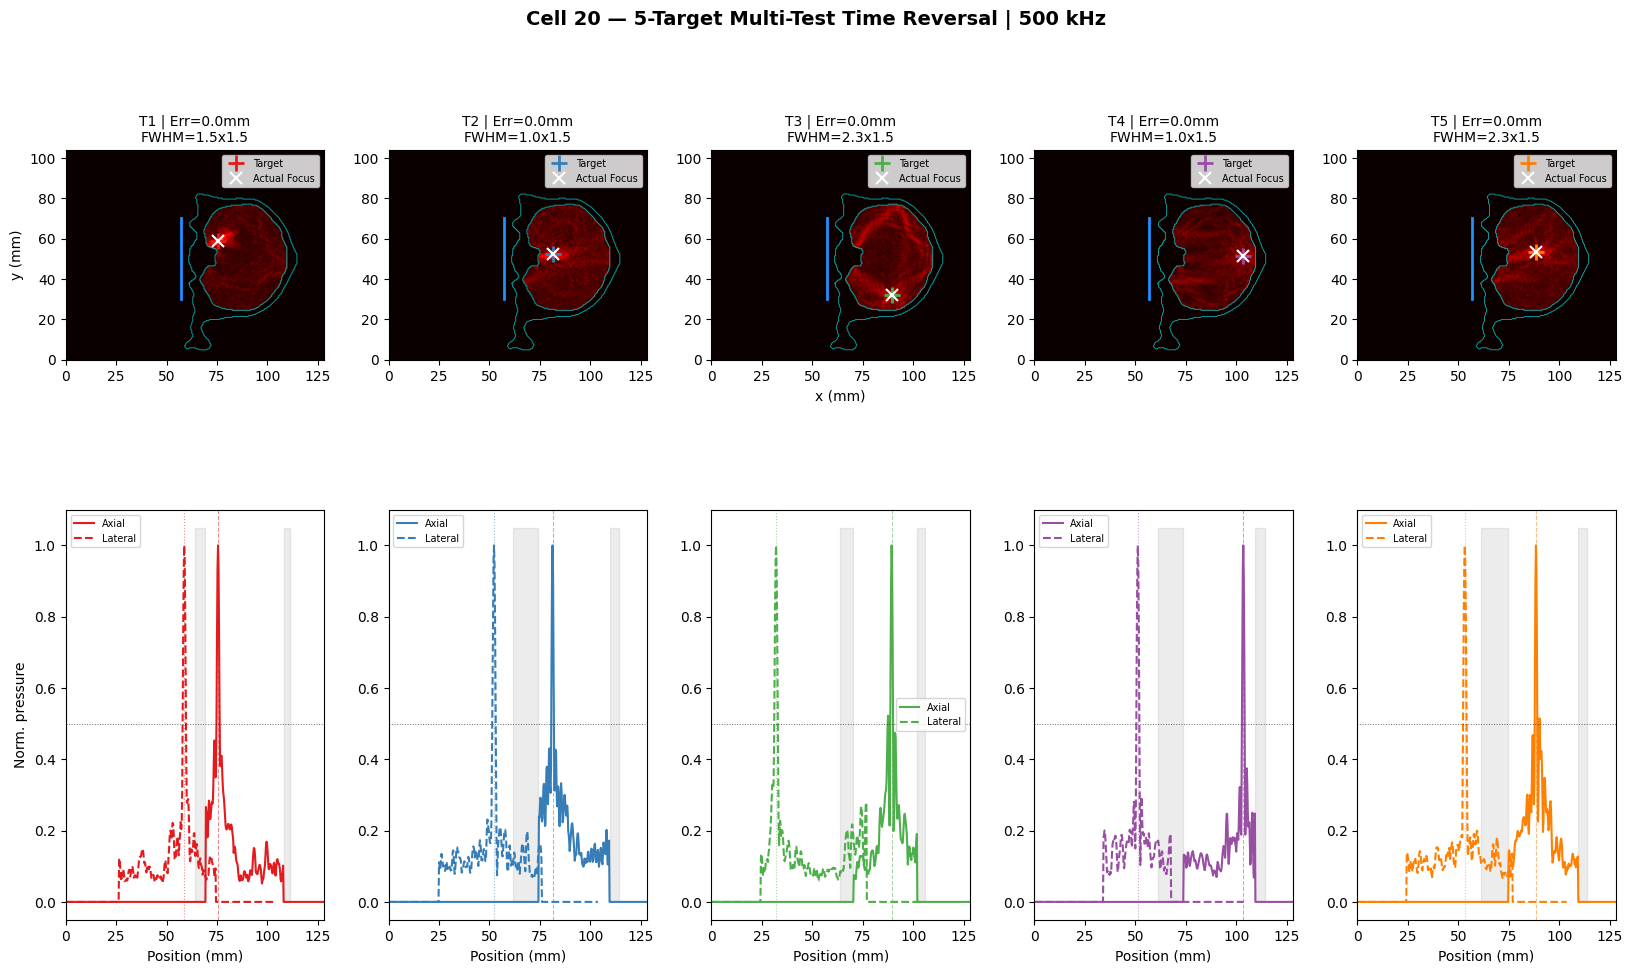


=== FINAL TEST SUMMARY ===
  T   Err(mm)    Ax(mm)   Lat(mm)   Peak(kPa)
  1       0.0       1.5       1.5         5.4
  2       0.0       1.0       1.5         4.1
  3       0.0       2.3       1.5         4.7
  4       0.0       1.0       1.5         6.5
  5       0.0       2.3       1.5         4.1


In [50]:
# =============================================================================
# CELL 20: MULTI-TARGET TIME REVERSAL SUITE (High Fidelity)
# Runs 5 targets, saves a high-res GIF for each, outputs summary figure.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Ellipse
import cupy
import gc
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

# ── 1. Select 5 Random Targets Inside the Brain ───────────────────────────────
np.random.seed(42)  # For reproducibility
valid_x, valid_y = np.where(brain_mask)

# Pick 5 random locations, ensuring they are somewhat deep in the brain
# (using a simple heuristic: must be at least 10 pixels away from the skull)
from scipy.ndimage import binary_erosion
deep_brain = binary_erosion(brain_mask, iterations=10)
valid_x, valid_y = np.where(deep_brain)

choices = np.random.choice(len(valid_x), 5, replace=False)
targets = [{'x_px': valid_x[i], 'y_px': valid_y[i]} for i in choices]

# ── 2. Setup Transducer & Animation Grid ──────────────────────────────────────
x_pts, y_pts = np.where(bone_mask)
tx_x = max(5, np.min(x_pts) - int(2e-3 / dx))  # 2mm standoff
aperture_px = int(40e-3 / dx)
tx_y_start = cy - aperture_px // 2
tx_y_end   = cy + aperture_px // 2

emask = np.zeros((Nx, Ny))
emask[tx_x, tx_y_start:tx_y_end] = 1

# Higher Fidelity Animation: Stride 4 instead of 8
STRIDE = 4
anim_mask = np.zeros((Nx, Ny))
anim_mask[::STRIDE, ::STRIDE] = 1
anim_Nx, anim_Ny = len(np.arange(0, Nx, STRIDE)), len(np.arange(0, Ny, STRIDE))
anim_dt = max(1, kgrid.Nt // 100)
t_frame_us = np.arange(0, kgrid.Nt, anim_dt) * kgrid.dt * 1e6

# ── 3. Helper Functions ───────────────────────────────────────────────────────
def fwhm_mm(profile, dx_m):
    half_max = np.max(profile) / 2.0
    if half_max == 0: return 0.0
    above = np.where(profile >= half_max)[0]
    return (above[-1] - above[0]) * dx_m * 1e3 if len(above) > 1 else 0.0

def save_tr_gif(fwd_frames, bwd_frames, tgt, label, filename):
    n_pause = 10
    pause = np.repeat(fwd_frames[:, :, -1:], n_pause, axis=2)
    all_f = np.concatenate([fwd_frames, pause, bwd_frames], axis=2)
    n_fwd_end = fwd_frames.shape[2] + n_pause

    # Skip initial explosion frames for dynamic range
    vmax_frames = all_f[:, :, 5:] if all_f.shape[2] > 5 else all_f
    vmax = np.percentile(np.abs(vmax_frames), 99.5)
    if vmax == 0: vmax = 1.0

    extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
    fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
    
    # bicubic interpolation added for higher visual fidelity
    im = ax.imshow(all_f[:, :, 0].T, origin='lower', extent=extent, cmap='RdBu_r', 
                   vmin=-vmax, vmax=vmax, interpolation='bicubic')
    
    ax.contour(bone_mask.T, levels=[0.5], extent=extent, colors='black', linewidths=0.8, alpha=0.5)
    ax.plot(tgt['x_px']*dx*1e3, tgt['y_px']*dx*1e3, 'g+', ms=12, mew=2)
    ax.plot([tx_x*dx*1e3, tx_x*dx*1e3], [tx_y_start*dx*1e3, tx_y_end*dx*1e3], 'dodgerblue', lw=3, solid_capstyle='butt')
    
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    title_obj = ax.set_title(f'{label} — FORWARD (0.0 us)')

    def update(fi):
        im.set_data(all_f[:, :, fi].T)
        if fi < fwd_frames.shape[2]:
            title_obj.set_text(f'{label} — Target Emitting  t={t_frame_us[fi]:.1f} us')
        elif fi < n_fwd_end:
            title_obj.set_text(f'{label} — PAUSE')
        else:
            title_obj.set_text(f'{label} — TR Focusing  t={t_frame_us[fi-n_fwd_end]:.1f} us')
        return [im, title_obj]

    anim = FuncAnimation(fig, update, frames=all_f.shape[2], interval=40, blit=True)
    anim.save(filename, writer=PillowWriter(fps=25), dpi=120)
    plt.close(fig)
    print(f"    -> Saved {filename}")

# ── 4. Main Simulation Loop ───────────────────────────────────────────────────
results = []
burst = tone_burst(1/kgrid.dt, freq, 5).flatten() * 1e5

for i, tgt in enumerate(targets):
    label = f"T{i+1}"
    print(f"\n=== Running Target {i+1}/5: ({tgt['x_px']*dx*1e3:.1f}, {tgt['y_px']*dx*1e3:.1f}) mm ===")
    
    # --- FORWARD PASS ---
    src_f = kSource(); src_f.p_mask = np.zeros((Nx, Ny))
    src_f.p_mask[tgt['x_px'], tgt['y_px']] = 1; src_f.p = burst
    
    # Record at transducer
    sen_f = kSensor(); sen_f.mask = emask.copy(); sen_f.record = ['p']
    # Record animation frames
    sen_fa = kSensor(); sen_fa.mask = anim_mask.copy(); sen_fa.record = ['p']
    
    cupy.get_default_memory_pool().free_all_blocks(); gc.collect()
    fwd_data = kspaceFirstOrder(kgrid, medium, src_f, sen_f, device='gpu', dtype='float32')
    p_recorded = fwd_data['p']
    
    cupy.get_default_memory_pool().free_all_blocks(); gc.collect()
    fwd_anim = kspaceFirstOrder(kgrid, medium, src_f, sen_fa, device='gpu', dtype='float32', quiet=True)
    fwd_frames = fwd_anim['p'][:, ::anim_dt].reshape(anim_Nx, anim_Ny, len(t_frame_us))
    
    # --- BACKWARD PASS ---
    src_b = kSource(); src_b.p_mask = emask.copy()
    src_b.p = p_recorded[:, ::-1]  # Time Reversal
    
    sen_b = kSensor(); sen_b.mask = brain_mask.astype(float); sen_b.record = ['p_max']
    sen_ba = kSensor(); sen_ba.mask = anim_mask.copy(); sen_ba.record = ['p']
    
    cupy.get_default_memory_pool().free_all_blocks(); gc.collect()
    bwd_data = kspaceFirstOrder(kgrid, medium, src_b, sen_b, device='gpu', dtype='float32')
    
    p_max_sparse = bwd_data['p_max']
    if np.isnan(p_max_sparse).any(): p_max_sparse = np.nan_to_num(p_max_sparse)
    
    p_max = np.zeros((Nx, Ny))
    p_max[brain_mask] = p_max_sparse
    
    cupy.get_default_memory_pool().free_all_blocks(); gc.collect()
    bwd_anim = kspaceFirstOrder(kgrid, medium, src_b, sen_ba, device='gpu', dtype='float32', quiet=True)
    bwd_frames = bwd_anim['p'][:, ::anim_dt].reshape(anim_Nx, anim_Ny, len(t_frame_us))

    # --- ANALYSIS ---
    p_br = p_max.copy()
    p_br[~brain_mask] = 0
    pk_x, pk_y = np.unravel_index(np.argmax(p_br), (Nx, Ny))
    
    tgt_x_mm, tgt_y_mm = tgt['x_px'] * dx * 1e3, tgt['y_px'] * dx * 1e3
    pk_x_mm, pk_y_mm   = pk_x * dx * 1e3, pk_y * dx * 1e3
    
    err_mm = np.sqrt((pk_x_mm - tgt_x_mm)**2 + (pk_y_mm - tgt_y_mm)**2)
    fw_ax  = fwhm_mm(p_br[:, pk_y], dx)
    fw_lat = fwhm_mm(p_br[pk_x, :], dx)
    peak_p = np.max(p_br)
    
    print(f"    Error: {err_mm:.2f} mm | FWHM: {fw_ax:.1f}x{fw_lat:.1f} mm | Peak: {peak_p/1e3:.1f} kPa")
    
    results.append({
        'p_br': p_br, 'tgt_x_mm': tgt_x_mm, 'tgt_y_mm': tgt_y_mm,
        'pk_x_mm': pk_x_mm, 'pk_y_mm': pk_y_mm, 'err_mm': err_mm,
        'fw_ax': fw_ax, 'fw_lat': fw_lat, 'peak_p': peak_p,
        'prof_ax': p_br[:, pk_y], 'prof_lat': p_br[pk_x, :], 'pk_x': pk_x, 'pk_y': pk_y
    })
    
    # Save GIF
    save_tr_gif(fwd_frames, bwd_frames, tgt, label, f'20_T{i+1}_focus.gif')

# ── 5. Massive Summary Figure ─────────────────────────────────────────────────
print("\nGenerating final summary plot...")
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig = plt.figure(figsize=(20, 10))
gs_top = fig.add_gridspec(1, 5, top=0.93, bottom=0.54, wspace=0.25)
gs_bot = fig.add_gridspec(1, 5, top=0.48, bottom=0.07, wspace=0.25)

for i, res in enumerate(results):
    col = colors[i]
    
    # Focus Map (Top Row)
    ax_top = fig.add_subplot(gs_top[0, i])
    im = ax_top.imshow(res['p_br'].T, origin='lower', extent=extent, cmap='hot', interpolation='bicubic')
    ax_top.contour(bone_mask.T, levels=[0.5], extent=extent, colors='cyan', linewidths=0.7, alpha=0.6)
    
    ax_top.plot(res['tgt_x_mm'], res['tgt_y_mm'], '+', color=col, ms=12, mew=2, label='Target')
    ax_top.plot(res['pk_x_mm'], res['pk_y_mm'], 'wx', ms=8, mew=1.5, label='Actual Focus')
    
    ell = Ellipse((res['pk_x_mm'], res['pk_y_mm']), width=res['fw_ax'], height=res['fw_lat'],
                  edgecolor='lime', facecolor='none', lw=1.2, linestyle='--')
    ax_top.add_patch(ell)
    
    ax_top.plot([tx_x*dx*1e3, tx_x*dx*1e3], [tx_y_start*dx*1e3, tx_y_end*dx*1e3], color='dodgerblue', lw=2)
    
    ax_top.set_xlabel('x (mm)' if i == 2 else '')
    ax_top.set_ylabel('y (mm)' if i == 0 else '')
    ax_top.set_title(f"T{i+1} | Err={res['err_mm']:.1f}mm\nFWHM={res['fw_ax']:.1f}x{res['fw_lat']:.1f}", fontsize=10)
    ax_top.legend(fontsize=7, loc='upper right')

    # Focal Profiles (Bottom Row)
    ax_bot = fig.add_subplot(gs_bot[0, i])
    x_ax = np.arange(Nx) * dx * 1e3
    y_ax = np.arange(Ny) * dx * 1e3

    norm_ax  = res['prof_ax'] / (res['peak_p'] + 1e-12)
    norm_lat = res['prof_lat'] / (res['peak_p'] + 1e-12)

    ax_bot.plot(x_ax, norm_ax,  color=col, lw=1.5, label=f'Axial')
    ax_bot.plot(y_ax, norm_lat, color=col, lw=1.5, linestyle='--', label=f'Lateral')
    
    ax_bot.axhline(0.5, color='k', lw=0.7, ls=':', alpha=0.6)
    ax_bot.axvline(x=res['pk_x_mm'], color=col, lw=0.8, ls='--', alpha=0.5)
    ax_bot.axvline(x=res['pk_y_mm'], color=col, lw=0.8, ls=':',  alpha=0.5)
    
    skull_1d = bone_mask[:, res['pk_y']]
    ax_bot.fill_between(x_ax, 0, 1.05, where=skull_1d, color='gray', alpha=0.15)
    
    ax_bot.set_xlim(0, Nx*dx*1e3)
    ax_bot.set_ylim(-0.05, 1.1)
    ax_bot.set_xlabel('Position (mm)')
    ax_bot.set_ylabel('Norm. pressure' if i == 0 else '')
    ax_bot.legend(fontsize=7)

plt.suptitle('Cell 20 — 5-Target Multi-Test Time Reversal | 500 kHz', fontsize=14, fontweight='bold', y=0.98)
plt.savefig('20_multitarget_summary.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Final Console Output ──────────────────────────────────────────────────────
print("\n=== FINAL TEST SUMMARY ===")
print(f"{'T':>3}  {'Err(mm)':>8}  {'Ax(mm)':>8}  {'Lat(mm)':>8}  {'Peak(kPa)':>10}")
for i, res in enumerate(results):
    print(f"  {i+1:1d}  {res['err_mm']:8.1f}  {res['fw_ax']:8.1f}  {res['fw_lat']:8.1f}  {res['peak_p']/1e3:10.1f}")

# Passive Modeling

### 21_passive_gel_lens

Grid: 512x416  dx=0.250 mm  brain centre=(352,201)
Aperture: 128 px = 32 mm  half_ap = 64 px = 16.0 mm

   Ang    Skull    Focal       R   LensT     Gap   nTx
   0.0     5.00     38.0    18.3    9.25   11.25   128
  45.0     2.75     37.8    18.2    9.50   11.50   128
  90.0     2.50     39.2    18.9    8.75   10.75   128
 135.0     7.00     42.0    20.2    7.75    9.75   128
 180.0    13.00     38.5    18.6    9.00   11.00   128
 270.0     3.00     39.2    18.9    8.75   10.75   128
 315.0     3.25     37.0    17.8    9.75   11.75   128

Chosen: 90.0 deg  skull=2.5 mm  F=39.2 mm  gap=10.8 mm
Lens pixels: 3131  max thickness: 8.75 mm  bone overlap: none
Transducer elements active: 128
Running passive-lens simulation...


k-Wave: 100%|██████████| 6817/6817 [00:07<00:00, 969.01step/s] 


Done -- global max: 321.8 kPa

=== PASSIVE LENS FOCUS REPORT ===
Target  : (88.0, 50.2) mm  [brain centre]
Focus   : (88.8, 60.5) mm
Error   : 10.28 mm
Peak P  : 153.2 kPa


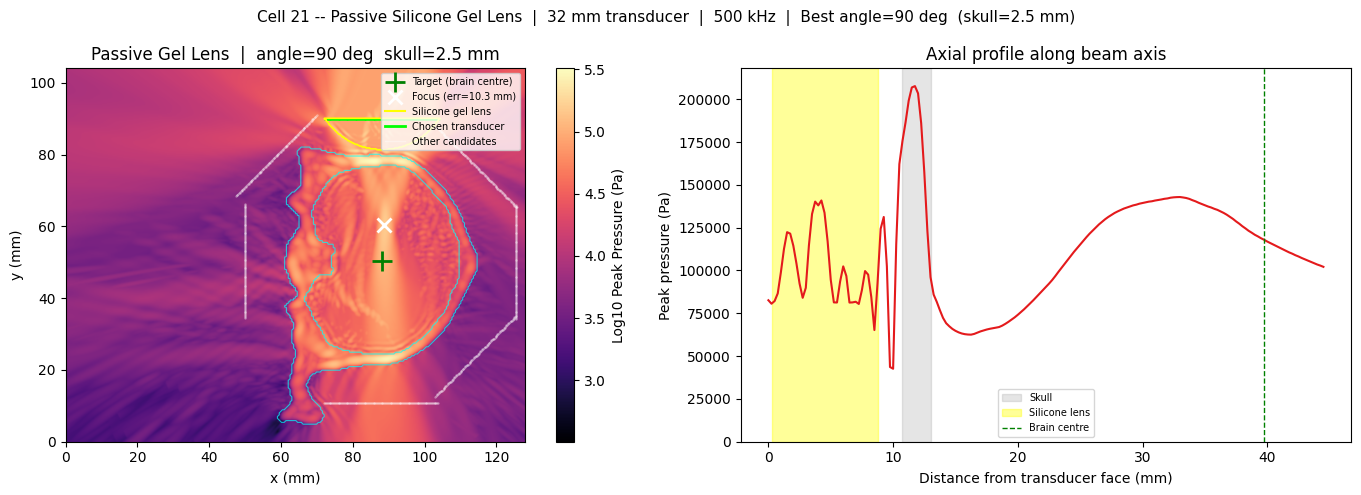

In [2]:
# =============================================================================
# CELL 21: PASSIVE SILICONE GEL LENS - AUTO-POSITIONED
# =============================================================================
# Scans N_ANGLES positions around the brain centre to find valid transducer
# placements. For each angle the coupling gap is auto-sized so the plano-convex
# silicone gel lens fits entirely outside the skull with no bone overlap.
# Selects the position with the thinnest skull path and runs one simulation.
# Target: brain centre. Requires bone_mask_2d.npy, c_map_full.npy, rho_map_full.npy.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom, binary_fill_holes, center_of_mass
from pathlib import Path
import cupy, gc

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder import kspaceFirstOrder
from kwave.utils.signals import tone_burst

# ── USER PARAMETERS ──────────────────────────────────────────────────────────
APERTURE_MM  = 32.0    # transducer width (mm)
FREQ         = 500e3   # Hz
N_ANGLES     = 8       # candidate positions to scan around the skull
STANDOFF_MM  = 2.0     # minimum water gap between the back of the lens and skull (mm)

C_GEL   = 1000.0       # silicone gel sound speed (m/s) -- slower than tissue
RHO_GEL = 1100.0       # silicone gel density (kg/m3)
C_WATER = 1482.0       # coupling/background medium speed (m/s)

# ── 1. Load & upsample CT maps (same as Cell 18) ─────────────────────────────
data_dir = Path(r'C:\Users\bengi\Documents\Pesaran Lab')

c_map_raw     = np.load(data_dir / 'c_map_full.npy').astype(np.float32).T
rho_map_raw   = np.load(data_dir / 'rho_map_full.npy').astype(np.float32).T
bone_mask_raw = np.load(data_dir / 'bone_mask_2d.npy').astype(bool).T

SCALE = 2
dx    = 0.5e-3 / SCALE   # 0.25 mm per pixel

c_map     = zoom(c_map_raw,                   SCALE, order=1)
rho_map   = zoom(rho_map_raw,                 SCALE, order=1)
bone_mask = zoom(bone_mask_raw.astype(float), SCALE, order=1) > 0.5
head_mask  = binary_fill_holes(bone_mask)
brain_mask = head_mask & ~bone_mask

c_map[c_map < 1000]    = C_WATER
rho_map[rho_map < 100] = 1000.0

Nx, Ny  = c_map.shape
cx, cy  = [int(v) for v in center_of_mass(brain_mask)]
ap_px   = int(APERTURE_MM * 1e-3 / dx)
half_ap = ap_px // 2
so_px   = max(1, int(STANDOFF_MM * 1e-3 / dx))

print(f'Grid: {Nx}x{Ny}  dx={dx*1e3:.3f} mm  brain centre=({cx},{cy})')
print(f'Aperture: {ap_px} px = {APERTURE_MM:.0f} mm  half_ap = {half_ap} px = {half_ap*dx*1e3:.1f} mm')

# ── 2. Scan angles to find all valid transducer placements ───────────────────
# bx,by = outward direction (brain-centre -> outside skull)
# Lens is placed between transducer face and skull; it grows INWARD (-bx,-by).
# Thin-lens formula (slower gel in water):  R = F * (c_water/c_gel - 1)
# Gap is iterated until the lens fits fully outside bone.

def scan_angle(ang_deg):
    ang    = np.radians(ang_deg)
    bx     = np.cos(ang)
    by     = np.sin(ang)
    perp_x = -np.sin(ang)
    perp_y =  np.cos(ang)

    # Walk outward from brain centre to last pixel inside head_mask
    outer_r = None
    for r in range(1, max(Nx, Ny)):
        xi = int(round(cx + r * bx))
        yi = int(round(cy + r * by))
        if not (0 <= xi < Nx and 0 <= yi < Ny):
            break
        if not head_mask[xi, yi]:
            outer_r = r - 1
            break
    if outer_r is None or outer_r < 10:
        return None

    # Skull thickness along this ray
    skull_px = 0
    for r in range(outer_r + 1):
        xi = int(round(cx + r * bx))
        yi = int(round(cy + r * by))
        if 0 <= xi < Nx and 0 <= yi < Ny and bone_mask[xi, yi]:
            skull_px += 1

    # Iteratively solve for a self-consistent gap
    # Constraint: gap >= lens_max_thickness + standoff
    gap_px = so_px
    R_px   = 0.0
    t_max  = 0
    for _ in range(25):
        F_m   = (outer_r + gap_px) * dx
        R_m   = F_m * (C_WATER / C_GEL - 1.0)
        R_px  = R_m / dx
        if R_px <= half_ap:        # focal distance too short for this aperture
            gap_px += 4
            continue
        t_max  = int(R_px - np.sqrt(max(0.0, R_px**2 - half_ap**2)))
        needed = t_max + so_px
        if abs(needed - gap_px) <= 2:
            gap_px = needed
            break
        gap_px = needed
    if R_px <= half_ap:
        return None

    # Transducer face centre
    face_cx = cx + (outer_r + gap_px) * bx
    face_cy = cy + (outer_r + gap_px) * by

    # Collect transducer pixels (must be outside head)
    tx_pixels = []
    for u in range(-half_ap, half_ap):
        xi = int(round(face_cx + u * perp_x))
        yi = int(round(face_cy + u * perp_y))
        if 0 <= xi < Nx and 0 <= yi < Ny and not head_mask[xi, yi]:
            tx_pixels.append((xi, yi))
    if len(tx_pixels) < int(ap_px * 0.8):
        return None

    return dict(
        ang_deg=ang_deg, ang=ang, bx=bx, by=by, perp_x=perp_x, perp_y=perp_y,
        outer_r=outer_r, skull_px=skull_px,
        F_m=F_m, R_m=R_m, R_px=R_px, t_max=t_max, gap_px=gap_px,
        face_cx=face_cx, face_cy=face_cy, tx_pixels=tx_pixels,
    )

configs = [c for c in (scan_angle(a) for a in np.linspace(0, 360, N_ANGLES, endpoint=False)) if c]

# Print table
print(f"\n{'Ang':>6}  {'Skull':>7}  {'Focal':>7}  {'R':>6}  {'LensT':>6}  {'Gap':>6}  {'nTx':>4}")
for c in configs:
    print(f"{c['ang_deg']:6.1f}  {c['skull_px']*dx*1e3:7.2f}  "
          f"{c['F_m']*1e3:7.1f}  {c['R_m']*1e3:6.1f}  "
          f"{c['t_max']*dx*1e3:6.2f}  {c['gap_px']*dx*1e3:6.2f}  "
          f"{len(c['tx_pixels']):4d}")

if not configs:
    raise RuntimeError('No valid positions found. Try reducing APERTURE_MM or STANDOFF_MM.')

# ── 3. Choose best: minimum skull thickness ───────────────────────────────────
best = min(configs, key=lambda c: c['skull_px'])
print(f"\nChosen: {best['ang_deg']:.1f} deg  skull={best['skull_px']*dx*1e3:.1f} mm  "
      f"F={best['F_m']*1e3:.1f} mm  gap={best['gap_px']*dx*1e3:.1f} mm")

# ── 4. Build lens mask ────────────────────────────────────────────────────────
bx, by   = best['bx'], best['by']
perp_x   = best['perp_x']
perp_y   = best['perp_y']
R_px     = best['R_px']
face_cx  = best['face_cx']
face_cy  = best['face_cy']

lens_mask = np.zeros((Nx, Ny), dtype=bool)
for u in range(-half_ap, half_ap + 1):
    inner = R_px**2 - u**2
    if inner < 0:
        continue
    t_px = max(int(np.sqrt(inner) - np.sqrt(max(0.0, R_px**2 - half_ap**2))), 1)
    base_x = face_cx + u * perp_x
    base_y = face_cy + u * perp_y
    for t in range(1, t_px + 1):
        xi = int(round(base_x - t * bx))   # grow INWARD (toward brain)
        yi = int(round(base_y - t * by))
        if 0 <= xi < Nx and 0 <= yi < Ny:
            lens_mask[xi, yi] = True

overlap = np.any(lens_mask & bone_mask)
print(f'Lens pixels: {lens_mask.sum()}  '
      f'max thickness: {best["t_max"]*dx*1e3:.2f} mm  '
      f'bone overlap: {"YES -- WARNING" if overlap else "none"}')

# ── 5. Build medium with lens ─────────────────────────────────────────────────
c_sim   = c_map.copy()
rho_sim = rho_map.copy()
c_sim[lens_mask]   = C_GEL
rho_sim[lens_mask] = RHO_GEL
medium = kWaveMedium(sound_speed=c_sim, density=rho_sim)

# ── 6. kWave grid & time ──────────────────────────────────────────────────────
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c_sim, cfl=0.3)

# ── 7. Source: synchronous burst on all elements (passive = no delays) ────────
burst  = tone_burst(1/kgrid.dt, FREQ, 5).flatten()
p_mask = np.zeros((Nx, Ny))
for xi, yi in best['tx_pixels']:
    p_mask[xi, yi] = 1

n_src         = int(np.sum(p_mask))
source         = kSource()
source.p_mask  = p_mask
source.p       = np.tile(burst * 1e5, (n_src, 1))  # identical signal to every element
print(f'Transducer elements active: {n_src}')

# ── 8. Sensor ─────────────────────────────────────────────────────────────────
sensor        = kSensor()
sensor.mask   = np.ones((Nx, Ny))
sensor.record = ['p_max']

# ── 9. Run ────────────────────────────────────────────────────────────────────
cupy.get_default_memory_pool().free_all_blocks(); gc.collect()
print('Running passive-lens simulation...')
data  = kspaceFirstOrder(kgrid, medium, source, sensor, device='gpu', dtype='float32')
p_max = data['p_max'].reshape(Nx, Ny)
if np.isnan(p_max).any():
    p_max = np.nan_to_num(p_max)
print(f'Done -- global max: {np.nanmax(p_max)/1e3:.1f} kPa')

# ── 10. Analysis ──────────────────────────────────────────────────────────────
p_br = p_max.copy()
p_br[~brain_mask] = 0
pk_x, pk_y = np.unravel_index(np.argmax(p_br), (Nx, Ny))

tgt_mm = (cx * dx * 1e3, cy * dx * 1e3)
pk_mm  = (pk_x * dx * 1e3, pk_y * dx * 1e3)
err_mm = np.sqrt((pk_mm[0]-tgt_mm[0])**2 + (pk_mm[1]-tgt_mm[1])**2)

print(f'\n=== PASSIVE LENS FOCUS REPORT ===')
print(f'Target  : ({tgt_mm[0]:.1f}, {tgt_mm[1]:.1f}) mm  [brain centre]')
print(f'Focus   : ({pk_mm[0]:.1f}, {pk_mm[1]:.1f}) mm')
print(f'Error   : {err_mm:.2f} mm')
print(f'Peak P  : {np.nanmax(p_br)/1e3:.1f} kPa')

# ── 11. Plot ──────────────────────────────────────────────────────────────────
extent = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log-pressure field with anatomy and all candidates
ax = axes[0]
p_log = np.log10(p_max + 1e-12)
vmax  = float(np.nanmax(p_log)); vmin = vmax - 3.0
im = ax.imshow(p_log.T, origin='lower', extent=extent, cmap='magma',
               interpolation='bicubic', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='Log10 Peak Pressure (Pa)')
ax.contour(bone_mask.T, levels=[0.5], extent=extent,
           colors='cyan', linewidths=0.8, alpha=0.7)
ax.contour(lens_mask.T, levels=[0.5], extent=extent,
           colors='yellow', linewidths=1.2)
for cfg in configs:
    txp   = np.array(cfg['tx_pixels'])
    color = 'lime'  if cfg is best else 'white'
    alpha = 1.0     if cfg is best else 0.35
    ax.scatter(txp[:, 0]*dx*1e3, txp[:, 1]*dx*1e3,
               c=color, s=3, alpha=alpha, linewidths=0)
ax.plot(tgt_mm[0], tgt_mm[1], 'g+', ms=14, mew=2, label='Target (brain centre)')
ax.plot(pk_mm[0],  pk_mm[1],  'wx', ms=10, mew=2, label=f'Focus (err={err_mm:.1f} mm)')
ax.plot([], [], color='yellow', lw=1.5, label='Silicone gel lens')
ax.plot([], [], color='lime',   lw=2,   label='Chosen transducer')
ax.plot([], [], color='white',  lw=1, alpha=0.4, label='Other candidates')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title(f'Passive Gel Lens  |  angle={best["ang_deg"]:.0f} deg  skull={best["skull_px"]*dx*1e3:.1f} mm')
ax.legend(fontsize=7, loc='upper right')

# Right: pressure profile along the beam axis (transducer face -> brain centre)
ax = axes[1]
beam_pixels = []
for t in range(int(best['gap_px'] + best['outer_r']) + 20):
    xi = int(round(face_cx - t * bx))
    yi = int(round(face_cy - t * by))
    if 0 <= xi < Nx and 0 <= yi < Ny:
        beam_pixels.append((xi, yi))
    else:
        break

axial    = np.array([p_max[xi, yi]    for xi, yi in beam_pixels])
skull_1d = np.array([bone_mask[xi, yi] for xi, yi in beam_pixels])
lens_1d  = np.array([lens_mask[xi, yi] for xi, yi in beam_pixels])
pos_mm   = np.arange(len(beam_pixels)) * dx * 1e3
brain_ctr_dist_mm = (best['gap_px'] + best['outer_r']) * dx * 1e3

y_top = float(np.nanmax(axial)) * 1.05 if len(axial) > 0 and np.nanmax(axial) > 0 else 1.0
ax.plot(pos_mm, axial, '#e41a1c', lw=1.5)
ax.fill_between(pos_mm, 0, y_top, where=skull_1d, color='gray',   alpha=0.2, label='Skull')
ax.fill_between(pos_mm, 0, y_top, where=lens_1d,  color='yellow', alpha=0.4, label='Silicone lens')
ax.axvline(x=brain_ctr_dist_mm, color='green', lw=1.0, ls='--', label='Brain centre')
ax.set_ylim(0, y_top)
ax.set_xlabel('Distance from transducer face (mm)')
ax.set_ylabel('Peak pressure (Pa)')
ax.set_title('Axial profile along beam axis')
ax.legend(fontsize=7)

plt.suptitle(
    f'Cell 21 -- Passive Silicone Gel Lens  |  {APERTURE_MM:.0f} mm transducer  |  '
    f'{FREQ/1e3:.0f} kHz  |  Best angle={best["ang_deg"]:.0f} deg  '
    f'(skull={best["skull_px"]*dx*1e3:.1f} mm)',
    fontsize=11)
plt.tight_layout()
plt.savefig('21_passive_lens.png', dpi=150)
plt.show()


### 22_gel_lens_optimisation_jwave

Loading CT data...
  Grid:          256 x 208,  dx = 0.50 mm
  Brain centre:  (175, 100)
  Aperture:      32 mm (chord),  ROC = 30 mm,  F# = 0.94
  Half-angle:    32.2 deg
  Bowl depth:    5.0 mm  (10 px)
  Standoff:      8.0 mm

--------------------------------------------------------------
Stage 0 -- Born series from target (shared)...
  [adjoint from target]  |p(tgt)| = 7.121e-01  (0.7s)
  |E_adj0|_max = 7.1212e-01

--------------------------------------------------------------
Scanning 8 candidate positions (0-360 deg)...
      0 deg: valid -- skull=5.0mm  tip=(245,100)  arc=65px
     45 deg: valid -- skull=3.0mm  tip=(224,149)  arc=65px
     90 deg: valid -- skull=2.5mm  tip=(175,175)  arc=65px
    135 deg: valid -- skull=7.0mm  tip=(119,156)  arc=65px
    180 deg: valid -- skull=13.0mm  tip=(105,100)  arc=65px
    225 deg: valid -- skull=9.0mm  tip=(115,40)  arc=65px
    270 deg: valid -- skull=3.0mm  tip=(175,26)  arc=65px
    315 deg: valid -- skull=3.5mm  tip=(223,52)  arc=65p

C:\Users\bengi\AppData\Local\Temp\ipykernel_35760\4238502121.py:445: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


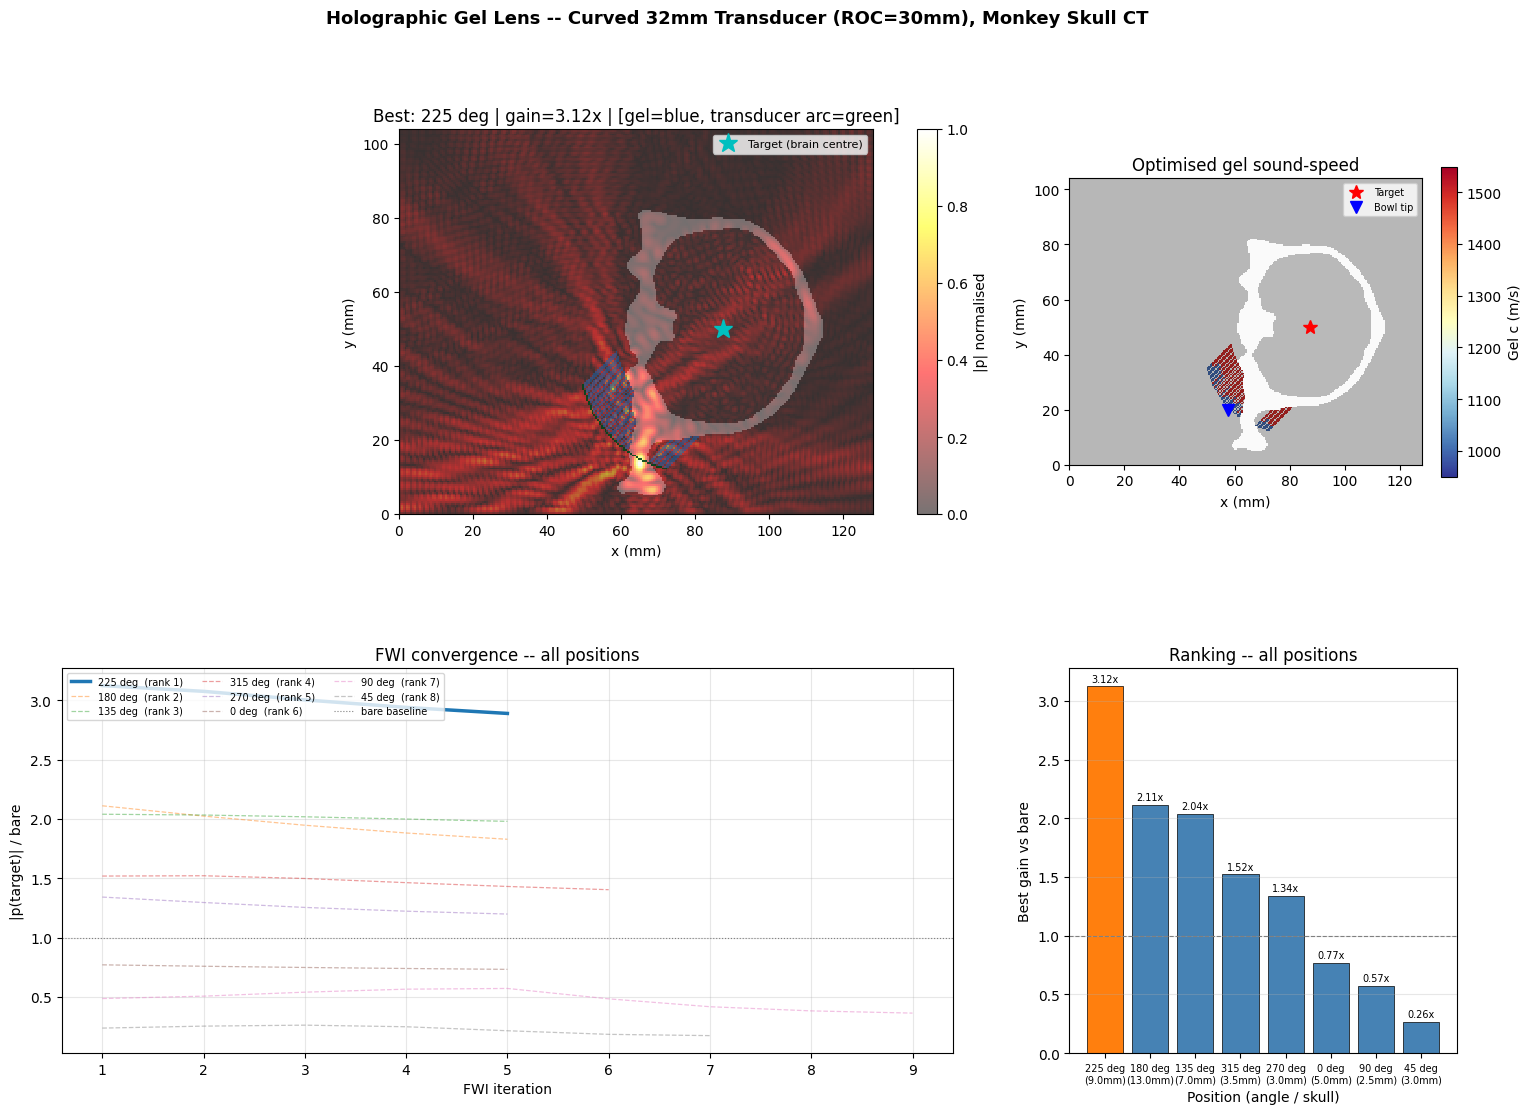


--------------------------------------------------------------
RESULT VERIFICATION (best position):
  Target position:    (175, 100)  = (87.5, 50.0) mm
  Actual peak:        (129, 27)  = (64.5, 13.5) mm
  Miss distance:      43.14 mm
  FWHM axial:         74.50 mm
  FWHM lateral:       99.00 mm
  Gain at target:     3.12x (FWI vs bare)
  Holographic gain:   2.89x (holo vs bare)
--------------------------------------------------------------


C:\Users\bengi\AppData\Local\Temp\ipykernel_35760\4238502121.py:607: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


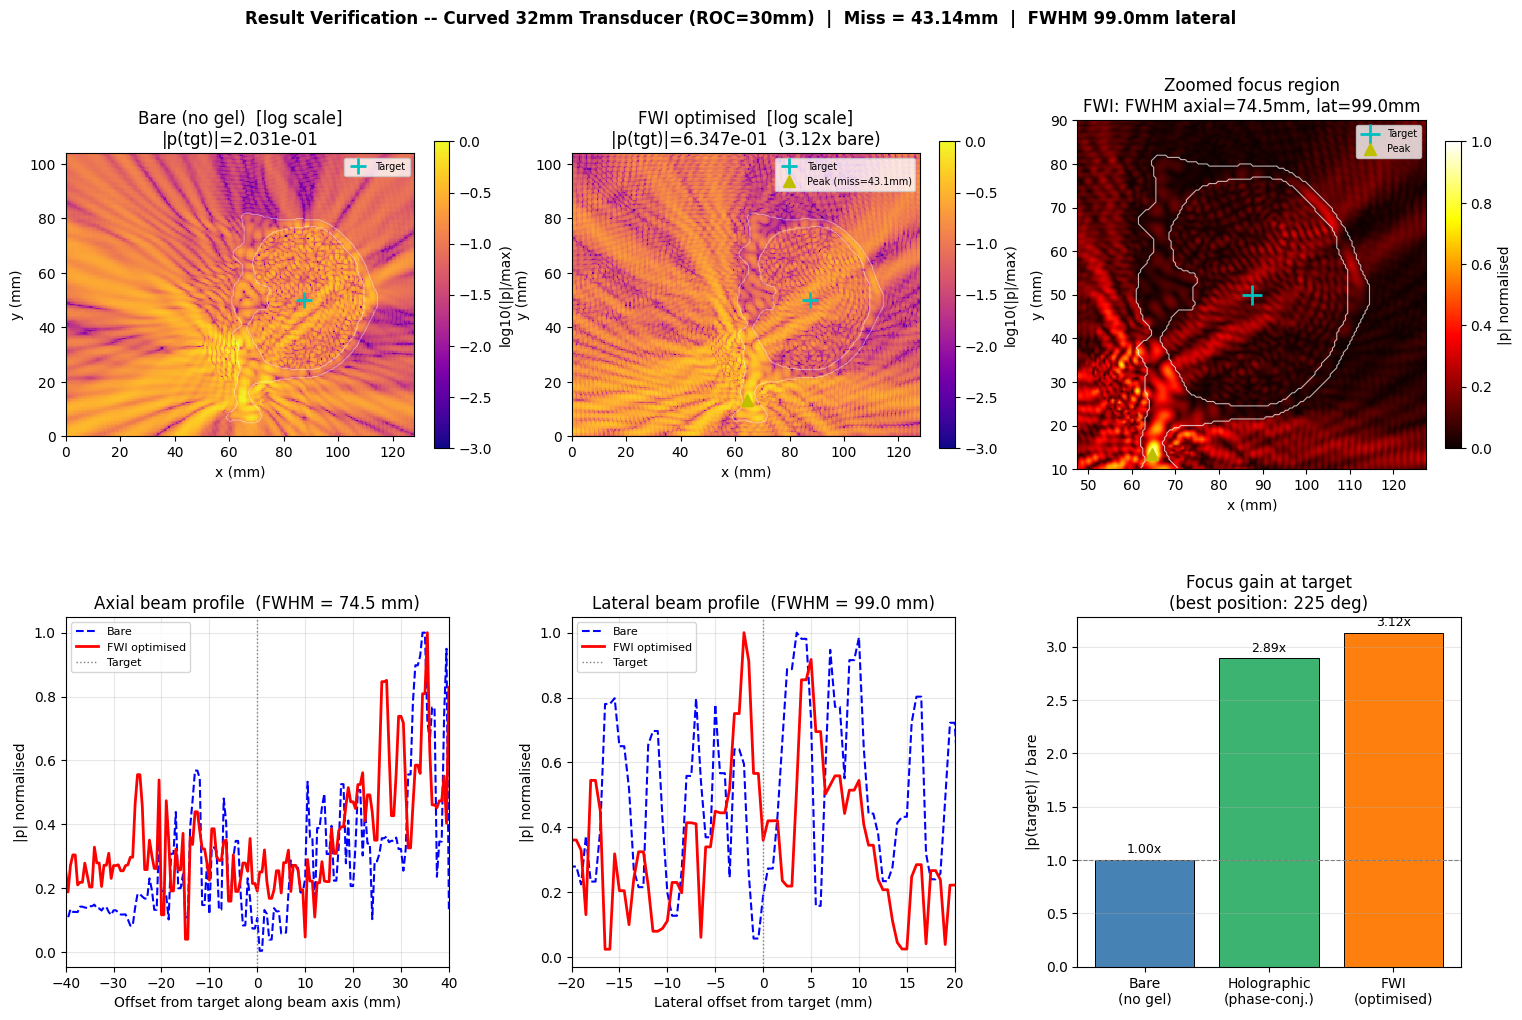


Figures saved:
  C:\Users\bengi\Documents\Pesaran Lab\holographic_gel_overview.png
  C:\Users\bengi\Documents\Pesaran Lab\holographic_gel_verification.png


In [9]:
# =============================================================================
# CELL 22 — Multi-Position Curved Holographic Gel Lens + FWI Optimisation
#
# Transducer: passive 32mm aperture, concave bowl.
# Radius of curvature (ROC) = 30 mm  ->  F# = ROC/AP = 30/32 = 0.94
# (Typical for TUS at 500 kHz; e.g. NeuroFUS CTX-500 family runs F# ~0.98.
#  Adjust ROC_MM if you have the exact datasheet value.)
#
# Workflow:
#   Stage 0 (shared): born_series from brain target -> adjoint field E_adj0
#   For each of N_ANGLES candidate positions around the skull:
#     Stage 1: Sample E_adj0 at arc aperture -> holographic gel via phase conj.
#     Stage 2: FWI (forward + adjoint, 2 born_series/iter)
#              Early-stop once gain plateaus (patience criterion)
#   Final: rank all positions, plot best result + full result verification figure
# =============================================================================
import pathlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import binary_fill_holes, center_of_mass

warnings.filterwarnings('ignore', message='A JAX array is being set as static')

import jax.numpy as jnp
from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import born_series

# ---- Parameters --------------------------------------------------------------
FREQ           = 500_000.0
OMEGA          = 2 * np.pi * FREQ
C_WATER        = 1500.0
C_GEL          = 1000.0      # slow silicone gel (lower c -> phase advance)
RHO_GEL        = 1100.0
AP_MM          = 32.0        # physical aperture chord length (mm)
ROC_MM         = 30.0        # radius of curvature (mm); F# = ROC/AP = 30/32 = 0.94
                             # CTX-500 family uses F#~0.98 -> ROC~31mm; adjust here
STANDOFF_MM    = 8.0         # water/gel gap from skull outer surface to bowl tip (mm)

N_ANGLES       = 8           # candidate positions scanned around skull
N_FWI_MAX      = 15          # max FWI iterations per position
PATIENCE       = 4           # early-stop: iters without fractional improvement
IMPROVE_THRESH = 5e-4
FWI_STEP_INIT  = 0.06
N_BORN         = 300

data_dir = pathlib.Path(r'C:\Users\bengi\Documents\Pesaran Lab')

# ---- Load CT -----------------------------------------------------------------
print('=' * 62)
print('Loading CT data...')
c_map   = np.load(data_dir / 'c_map_full.npy').astype(np.float32).T
rho_map = np.load(data_dir / 'rho_map_full.npy').astype(np.float32).T
bone    = np.load(data_dir / 'bone_mask_2d.npy').astype(bool).T
head    = binary_fill_holes(bone)
brain   = head & ~bone

c_map[c_map < 1000]    = C_WATER
rho_map[rho_map < 100] = 1000.0

dx      = 0.5e-3
Nx, Ny  = c_map.shape
cx, cy  = [int(v) for v in center_of_mass(brain)]
half_ap = int(round(AP_MM * 1e-3 / (2 * dx)))
so_px   = max(1, int(round(STANDOFF_MM * 1e-3 / dx)))
ROC_px  = ROC_MM * 1e-3 / dx
half_ap_m  = half_ap * dx
half_angle = np.arcsin(min(half_ap_m / (ROC_MM * 1e-3), 0.98))  # half-subtended angle
bowl_depth_px = int(np.ceil(ROC_px * (1.0 - np.cos(half_angle))))  # axial depth of bowl

print(f'  Grid:          {Nx} x {Ny},  dx = {dx*1e3:.2f} mm')
print(f'  Brain centre:  ({cx}, {cy})')
print(f'  Aperture:      {AP_MM:.0f} mm (chord),  ROC = {ROC_MM:.0f} mm,  '
      f'F# = {ROC_MM/AP_MM:.2f}')
print(f'  Half-angle:    {np.degrees(half_angle):.1f} deg')
print(f'  Bowl depth:    {bowl_depth_px*dx*1e3:.1f} mm  ({bowl_depth_px} px)')
print(f'  Standoff:      {so_px*dx*1e3:.1f} mm')

# ---- jwave helpers -----------------------------------------------------------
domain = Domain((Nx, Ny), (dx, dx))

def make_medium(c_arr, rho_arr):
    return Medium(
        domain      = domain,
        sound_speed = FourierSeries(jnp.array(c_arr[..., None],   dtype=jnp.float32), domain),
        density     = FourierSeries(jnp.array(rho_arr[..., None], dtype=jnp.float32), domain),
        pml_size    = 15,
    )

def run_born(medium, src_np_2d, label=None):
    """Born-series solve. Returns complex (Nx, Ny) numpy pressure field."""
    src_fs = FourierSeries(jnp.array(src_np_2d[..., None], dtype=complex), domain)
    t0 = time.time()
    p  = born_series(medium, src_fs, omega=OMEGA, max_iter=N_BORN, tol=1e-5)
    pnp = np.array(p.on_grid[..., 0])
    if label:
        print(f'  [{label}]  |p(tgt)| = {np.abs(pnp[cx, cy]):.3e}  ({time.time()-t0:.1f}s)')
    return pnp

def medium_from_rho(rg, gel_rgn):
    c_c = np.where(gel_rgn > 0,
                   1.0 / (rg / C_GEL + (1.0 - rg) / C_WATER), c_map).astype(np.float32)
    r_c = np.where(gel_rgn > 0,
                   rg * RHO_GEL + (1.0 - rg) * rho_map, rho_map).astype(np.float32)
    return make_medium(c_c, r_c)

medium_bare = make_medium(c_map, rho_map)

# ---- Geometry helper ---------------------------------------------------------
def get_position(ang_deg):
    """
    Walk outward from brain centre at ang_deg. Place a curved (concave) 32mm
    transducer just outside the skull. Return geometry dict, or None if invalid.

    The bowl tip (deepest element, on-axis) is placed at standoff distance from
    the skull outer surface. Arc elements are distributed along the curved surface.
    """
    ang = np.radians(ang_deg)
    bx_ = np.cos(ang);  by_ = np.sin(ang)   # outward direction (brain -> outside)
    px_ = -np.sin(ang); py_ = np.cos(ang)   # perpendicular (along aperture)

    inner_r = outer_r = None
    for r in range(5, max(Nx, Ny)):
        xi = int(round(cx + r * bx_))
        yi = int(round(cy + r * by_))
        if not (0 <= xi < Nx and 0 <= yi < Ny):
            break
        if bone[xi, yi] and inner_r is None:
            inner_r = r
        if inner_r is not None and not bone[xi, yi]:
            outer_r = r
            break

    if outer_r is None or inner_r is None or (outer_r - inner_r) < 2:
        return None

    skull_px = outer_r - inner_r

    # Bowl tip = deepest point of concave surface, placed so_px past skull outer
    tip_cx = int(round(cx + (outer_r + so_px) * bx_))
    tip_cy = int(round(cy + (outer_r + so_px) * by_))

    # Natural focal point of the bowl (in free space) is ROC_px inward from tip
    nat_focal_x = tip_cx - ROC_px * bx_
    nat_focal_y = tip_cy - ROC_px * by_

    # Arc element positions: distributed evenly by angle along the bowl
    n_elements = 2 * half_ap + 1
    alphas = np.linspace(-half_angle, half_angle, n_elements)
    tx_px  = []
    for alpha in alphas:
        # Each element lies on the arc at angle alpha from the bowl axis
        xi = int(round(nat_focal_x + ROC_px * (np.sin(alpha) * px_ + np.cos(alpha) * bx_)))
        yi = int(round(nat_focal_y + ROC_px * (np.sin(alpha) * py_ + np.cos(alpha) * by_)))
        if 0 <= xi < Nx and 0 <= yi < Ny:
            tx_px.append((xi, yi))

    if len(tx_px) < 8:
        return None

    # Check all arc elements and the gel region fit inside grid
    margin = 4
    for xi, yi in tx_px:
        if not (margin <= xi < Nx - margin and margin <= yi < Ny - margin):
            return None

    return dict(
        ang_deg=ang_deg, bx=bx_, by=by_, px=px_, py=py_,
        outer_r=outer_r, skull_px=skull_px,
        tip_cx=tip_cx, tip_cy=tip_cy,
        nat_focal_x=nat_focal_x, nat_focal_y=nat_focal_y,
        tx_pixels=tx_px,
    )

# ---- Stage 0: Shared adjoint from brain target (one run for all positions) ---
print()
print('-' * 62)
print('Stage 0 -- Born series from target (shared)...')
src_tgt         = np.zeros((Nx, Ny), dtype=complex)
src_tgt[cx, cy] = 1.0 + 0j
E_adj0 = run_born(medium_bare, src_tgt, label='adjoint from target')
print(f'  |E_adj0|_max = {np.abs(E_adj0).max():.4e}')

# ---- Find valid candidate positions ------------------------------------------
print()
print('-' * 62)
print(f'Scanning {N_ANGLES} candidate positions (0-360 deg)...')
positions = []
for ang in np.linspace(0, 360, N_ANGLES, endpoint=False):
    p = get_position(ang)
    if p is None:
        print(f'  {ang:5.0f} deg: INVALID')
    else:
        print(f'  {ang:5.0f} deg: valid -- skull={p["skull_px"]*dx*1e3:.1f}mm  '
              f'tip=({p["tip_cx"]},{p["tip_cy"]})  arc={len(p["tx_pixels"])}px')
        positions.append(p)

print(f'\n  {len(positions)} valid positions.')
if not positions:
    raise RuntimeError('No valid positions -- try reducing STANDOFF_MM or AP_MM.')

# ---- Per-position holographic gel design + FWI -------------------------------
print()
print('=' * 62)
print(f'FWI for {len(positions)} positions  (N_FWI_MAX={N_FWI_MAX}, patience={PATIENCE})')
print('=' * 62)

results = []

for i_pos, pos in enumerate(positions):
    ang = pos['ang_deg']
    bx_ = pos['bx'];  by_ = pos['by']
    print()
    print('-' * 62)
    print(f'Position {i_pos+1}/{len(positions)}:  {ang:.0f} deg  '
          f'skull={pos["skull_px"]*dx*1e3:.1f}mm  {len(pos["tx_pixels"])} arc elements')

    # -- Holographic gel design ------------------------------------------------
    k_gel   = OMEGA / C_GEL
    k_water = OMEGA / C_WATER

    E_at_tx = np.array([E_adj0[xi, yi] for xi, yi in pos['tx_pixels']])
    if np.abs(E_at_tx).max() < 1e-12:
        print('  Adjoint field too weak at aperture -- skipping')
        continue

    phi_tx    = np.angle(E_at_tx)
    phi_req   = phi_tx.max() - phi_tx       # >= 0 at all elements
    t_holo_m  = phi_req / (k_gel - k_water)
    t_holo_px = np.clip(np.round(t_holo_m / dx).astype(int), 0, so_px - 1)

    # Gel region: walk inward from each arc element toward skull.
    # NEVER enters bone -- gel must not penetrate the skull.
    gel_region = np.zeros((Nx, Ny), dtype=np.float32)
    rho_gel    = np.zeros((Nx, Ny), dtype=np.float64)
    for ui, (xf, yf) in enumerate(pos['tx_pixels']):
        for t in range(1, so_px + bowl_depth_px + 1):
            xi = int(round(xf - t * bx_))
            yi = int(round(yf - t * by_))
            if 0 <= xi < Nx and 0 <= yi < Ny and not bone[xi, yi]:
                gel_region[xi, yi] = 1.0
                if t <= t_holo_px[ui]:
                    rho_gel[xi, yi] = 1.0
            elif 0 <= xi < Nx and 0 <= yi < Ny and bone[xi, yi]:
                break   # hit skull -- stop this ray

    print(f'  Holographic gel:  '
          f'max_thick={t_holo_px.max()*dx*1e3:.1f}mm  '
          f'phase_spread={np.degrees(phi_req.max()):.0f} deg  '
          f'gel_voxels={int(gel_region.sum())}')

    # Curved transducer source: uniform (flat-phase) drive on the arc.
    # The bowl geometry itself provides the natural geometric focusing.
    src_flat = np.zeros((Nx, Ny), dtype=complex)
    for xi, yi in pos['tx_pixels']:
        src_flat[xi, yi] = 1.0 + 0j

    E_bare = run_born(medium_bare, src_flat)
    p_bare = float(np.abs(E_bare[cx, cy]))
    print(f'  Bare baseline:    |p(target)| = {p_bare:.4e}')

    # -- FWI -------------------------------------------------------------------
    print(f'\n  FWI (max={N_FWI_MAX} iters, patience={PATIENCE}):')
    gains_hist = []
    best_gain  = -np.inf
    best_rho   = rho_gel.copy()
    no_improve = 0
    step       = FWI_STEP_INIT

    for it in range(N_FWI_MAX):
        med   = medium_from_rho(rho_gel, gel_region)
        t0    = time.time()
        E_fwd = run_born(med, src_flat)
        p_tgt = E_fwd[cx, cy]
        gain  = float(np.abs(p_tgt)) / max(p_bare, 1e-30)
        gains_hist.append(gain)
        elapsed = time.time() - t0

        flag = ''
        if gain > best_gain * (1.0 + IMPROVE_THRESH):
            best_gain  = gain
            best_rho   = rho_gel.copy()
            no_improve = 0
            step       = min(step * 1.15, FWI_STEP_INIT * 4)
            flag       = '  <- NEW BEST'
        else:
            no_improve += 1
            step       = max(step * 0.75, FWI_STEP_INIT * 0.1)

        print(f'    iter {it+1:2d}/{N_FWI_MAX}  '
              f'gain={gain:6.3f}x  |p|={np.abs(p_tgt):.3e}  '
              f'step={step:.3f}  no_improv={no_improve}/{PATIENCE}'
              f'{flag}  ({elapsed:.1f}s)')

        if no_improve >= PATIENCE:
            print(f'  --> Early stop at iter {it+1}')
            break

        src_adj         = np.zeros((Nx, Ny), dtype=complex)
        src_adj[cx, cy] = np.exp(-1j * np.angle(p_tgt))
        E_adj = run_born(med, src_adj)

        grad  = np.real(E_fwd * E_adj) * gel_region
        g_max = np.abs(grad).max()
        if g_max > 0:
            rho_gel = np.clip(rho_gel + step * grad / g_max, 0.0, 1.0)

    # Final evaluation with best rho_gel
    E_final    = run_born(medium_from_rho(best_rho, gel_region), src_flat)
    p_final    = float(np.abs(E_final[cx, cy]))
    gain_final = p_final / max(p_bare, 1e-30)
    c_opt      = np.where(gel_region > 0,
                          1.0 / (best_rho / C_GEL + (1.0 - best_rho) / C_WATER),
                          c_map).astype(np.float32)

    # Also compute holographic-only field for comparison
    E_holo_check = run_born(
        medium_from_rho(np.where(gel_region > 0, rho_gel, 0.0), gel_region), src_flat)

    print(f'\n  Position {i_pos+1} DONE:  '
          f'bare={p_bare:.3e}  holo={np.abs(E_holo_check[cx,cy]):.3e}  '
          f'FWI={p_final:.3e}  gain={gain_final:.2f}x  iters={len(gains_hist)}')

    results.append(dict(
        pos=pos, p_bare=p_bare, p_final=p_final,
        gain_final=gain_final, gains_hist=gains_hist,
        best_rho=best_rho, c_opt=c_opt,
        E_final=E_final, E_bare=E_bare,
        p_holo=float(np.abs(E_holo_check[cx, cy])),
        gel_region=gel_region,
    ))

# ---- Final Summary -----------------------------------------------------------
if not results:
    print('\nNo valid results were produced.')
else:
    print()
    print('=' * 62)
    print('FINAL RESULTS -- All positions ranked by focus gain')
    print('=' * 62)
    results.sort(key=lambda r: r['gain_final'], reverse=True)

    print(f'\n  {"Rank":>4}  {"Angle":>7}  {"Skull":>6}  '
          f'{"bare |p|":>12}  {"holo |p|":>12}  {"FWI |p|":>12}  {"Gain":>8}  {"Iters":>6}')
    print('  ' + '-' * 72)
    for rank, r in enumerate(results):
        p_ = r['pos']
        print(f'  {rank+1:>4}   {p_["ang_deg"]:6.0f} deg  '
              f'{p_["skull_px"]*dx*1e3:5.1f}mm  '
              f'{r["p_bare"]:>12.3e}  '
              f'{r["p_holo"]:>12.3e}  '
              f'{r["p_final"]:>12.3e}  '
              f'{r["gain_final"]:>7.2f}x  '
              f'{len(r["gains_hist"]):>6}')

    best = results[0]
    bp   = best['pos']
    print()
    print('=' * 62)
    print(f'BEST TRANSDUCER:  {bp["ang_deg"]:.0f} deg')
    print(f'  Skull thickness :    {bp["skull_px"]*dx*1e3:.1f} mm')
    print(f'  Natural focal dist:  {ROC_MM:.0f} mm (in free space)')
    print(f'  Bare |p(target)|:    {best["p_bare"]:.4e}')
    print(f'  Holographic |p|:     {best["p_holo"]:.4e}  '
          f'({best["p_holo"]/max(best["p_bare"],1e-30):.2f}x bare)')
    print(f'  FWI-optimised |p|:   {best["p_final"]:.4e}  '
          f'({best["gain_final"]:.2f}x bare)')
    print(f'  FWI iters run:       {len(best["gains_hist"])}')
    print('=' * 62)

    # =========================================================================
    # Figure 1: Overview — all positions compared
    # =========================================================================
    ext = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
    kw  = dict(origin='lower', aspect='equal', extent=ext, interpolation='nearest')

    fig1 = plt.figure(figsize=(18, 12))
    gs1  = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.40, wspace=0.30)

    # A: pressure field overlay (best position)
    ax_a = fig1.add_subplot(gs1[0, :2])
    ax_a.imshow(c_map.T, cmap='gray', vmin=1400, vmax=3200, alpha=0.60, **kw)
    p_abs  = np.abs(best['E_final'])
    p_norm = p_abs / (p_abs.max() + 1e-30)
    im_p   = ax_a.imshow(p_norm.T, cmap='hot', alpha=0.55, vmin=0, vmax=1, **kw)
    ax_a.imshow(np.where(best['gel_region'] > 0, 0.8, np.nan).T,
                cmap='Blues', alpha=0.55, vmin=0, vmax=1, **kw)
    tx_vis = np.zeros((Nx, Ny))
    for xi, yi in bp['tx_pixels']:
        tx_vis[xi, yi] = 1.0
    ax_a.imshow(np.where(tx_vis > 0, 1.0, np.nan).T,
                cmap='Greens', alpha=0.9, vmin=0, vmax=1, **kw)
    ax_a.plot(cx*dx*1e3, cy*dx*1e3, 'c*', ms=14, mew=1,
              label='Target (brain centre)', zorder=7)
    plt.colorbar(im_p, ax=ax_a, label='|p| normalised', fraction=0.04)
    ax_a.set(xlabel='x (mm)', ylabel='y (mm)',
             title=f'Best: {bp["ang_deg"]:.0f} deg | gain={best["gain_final"]:.2f}x | '
                   f'[gel=blue, transducer arc=green]')
    ax_a.legend(fontsize=8, loc='upper right')

    # B: gel sound-speed map
    ax_b = fig1.add_subplot(gs1[0, 2])
    im_c = ax_b.imshow(np.where(best['gel_region'] > 0, best['c_opt'], np.nan).T,
                       cmap='RdYlBu_r', vmin=C_GEL-50, vmax=C_WATER+50, **kw)
    ax_b.imshow(c_map.T, cmap='gray', vmin=1400, vmax=3200, alpha=0.30, **kw)
    ax_b.plot(cx*dx*1e3, cy*dx*1e3, 'r*', ms=10, label='Target')
    ax_b.plot(bp['tip_cx']*dx*1e3, bp['tip_cy']*dx*1e3, 'bv', ms=8, label='Bowl tip')
    plt.colorbar(im_c, ax=ax_b, label='Gel c (m/s)', fraction=0.04)
    ax_b.set(xlabel='x (mm)', ylabel='y (mm)', title='Optimised gel sound-speed')
    ax_b.legend(fontsize=7)

    # C: convergence curves
    ax_c = fig1.add_subplot(gs1[1, :2])
    for rank, r in enumerate(results):
        p_ = r['pos']
        lbl = f'{p_["ang_deg"]:.0f} deg  (rank {rank+1})'
        ax_c.plot(range(1, len(r['gains_hist'])+1), r['gains_hist'],
                  label=lbl,
                  linewidth=2.5 if r is best else 0.9,
                  alpha=1.0 if r is best else 0.45,
                  linestyle='-' if r is best else '--')
    ax_c.axhline(1.0, color='gray', ls=':', lw=0.8, label='bare baseline')
    ax_c.set(xlabel='FWI iteration', ylabel='|p(target)| / bare',
             title='FWI convergence -- all positions')
    ax_c.legend(fontsize=7, ncol=3, loc='upper left')
    ax_c.grid(True, alpha=0.3)

    # D: gain bar chart
    ax_d = fig1.add_subplot(gs1[1, 2])
    lbls  = [f'{r["pos"]["ang_deg"]:.0f} deg\n({r["pos"]["skull_px"]*dx*1e3:.1f}mm)'
             for r in results]
    bars  = ax_d.bar(lbls, [r['gain_final'] for r in results],
                     color=['tab:orange' if r is best else 'steelblue' for r in results],
                     edgecolor='k', linewidth=0.5)
    ax_d.bar_label(bars, fmt='%.2fx', fontsize=7, padding=2)
    ax_d.axhline(1.0, color='gray', ls='--', lw=0.8)
    ax_d.set(xlabel='Position (angle / skull)', ylabel='Best gain vs bare',
             title='Ranking -- all positions')
    ax_d.tick_params(axis='x', labelsize=7)
    ax_d.grid(True, alpha=0.3, axis='y')

    fig1.suptitle(f'Holographic Gel Lens -- Curved 32mm Transducer (ROC={ROC_MM:.0f}mm), '
                  f'Monkey Skull CT', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(data_dir / 'holographic_gel_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # Figure 2: Result verification -- did it actually work?
    # =========================================================================
    # Compute bare and holographic fields for best position (for comparison)
    E_bare_best = best['E_bare']
    p_abs_bare  = np.abs(E_bare_best)
    p_abs_fwi   = np.abs(best['E_final'])

    # Find actual peak of optimised field
    peak_idx   = np.unravel_index(np.argmax(p_abs_fwi), p_abs_fwi.shape)
    peak_x_mm  = peak_idx[0] * dx * 1e3
    peak_y_mm  = peak_idx[1] * dx * 1e3
    tgt_x_mm   = cx * dx * 1e3
    tgt_y_mm   = cy * dx * 1e3
    miss_mm    = np.sqrt((peak_idx[0]-cx)**2 + (peak_idx[1]-cy)**2) * dx * 1e3

    # Axis through the target: along beam (bx_, by_) and perpendicular (px_, py_)
    # Sample 1D profiles through the target for FWHM measurement
    def sample_along(field_abs, start_x, start_y, dir_x, dir_y, n_pts=200):
        """Sample abs(field) along a line through (start_x, start_y)."""
        offsets = np.arange(-n_pts//2, n_pts//2)
        vals = []
        for s in offsets:
            xi = int(round(start_x + s * dir_x))
            yi = int(round(start_y + s * dir_y))
            if 0 <= xi < Nx and 0 <= yi < Ny:
                vals.append((s * dx * 1e3, field_abs[xi, yi]))
            else:
                vals.append((s * dx * 1e3, 0.0))
        return np.array(vals)

    bx_ = bp['bx'];  by_ = bp['by']
    px_ = bp['px'];  py_ = bp['py']

    axial_fwi  = sample_along(p_abs_fwi,  cx, cy, bx_, by_)
    axial_bare = sample_along(p_abs_bare, cx, cy, bx_, by_)
    lat_fwi    = sample_along(p_abs_fwi,  cx, cy, px_, py_)
    lat_bare   = sample_along(p_abs_bare, cx, cy, px_, py_)

    def fwhm_mm(profile_vals, profile_offsets):
        half_max = profile_vals.max() / 2.0
        above = np.where(profile_vals >= half_max)[0]
        if len(above) < 2:
            return 0.0
        return abs(profile_offsets[above[-1]] - profile_offsets[above[0]])

    fwhm_axial = fwhm_mm(axial_fwi[:, 1], axial_fwi[:, 0])
    fwhm_lat   = fwhm_mm(lat_fwi[:, 1],   lat_fwi[:, 0])

    print()
    print('-' * 62)
    print('RESULT VERIFICATION (best position):')
    print(f'  Target position:    ({cx}, {cy})  = ({tgt_x_mm:.1f}, {tgt_y_mm:.1f}) mm')
    print(f'  Actual peak:        ({peak_idx[0]}, {peak_idx[1]})  '
          f'= ({peak_x_mm:.1f}, {peak_y_mm:.1f}) mm')
    print(f'  Miss distance:      {miss_mm:.2f} mm')
    print(f'  FWHM axial:         {fwhm_axial:.2f} mm')
    print(f'  FWHM lateral:       {fwhm_lat:.2f} mm')
    print(f'  Gain at target:     {best["gain_final"]:.2f}x (FWI vs bare)')
    print(f'  Holographic gain:   {best["p_holo"]/max(best["p_bare"],1e-30):.2f}x (holo vs bare)')
    print('-' * 62)

    # -- Zoom window around target
    zoom_r = int(round(40e-3 / dx))   # 40mm radius around target
    zx0, zx1 = max(0, cx-zoom_r), min(Nx, cx+zoom_r)
    zy0, zy1 = max(0, cy-zoom_r), min(Ny, cy+zoom_r)
    ext_z = [(zx0)*dx*1e3, (zx1)*dx*1e3, (zy0)*dx*1e3, (zy1)*dx*1e3]
    kwz   = dict(origin='lower', aspect='equal', extent=ext_z, interpolation='bilinear')

    fig2 = plt.figure(figsize=(18, 11))
    gs2  = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.42, wspace=0.32)

    # A: full pressure field (log scale), bare
    ax2_a = fig2.add_subplot(gs2[0, 0])
    log_bare = np.log10(p_abs_bare / (p_abs_bare.max() + 1e-30) + 1e-3)
    im_bare  = ax2_a.imshow(log_bare.T, cmap='plasma', vmin=-3, vmax=0, **kw)
    ax2_a.contour(bone.T, levels=[0.5], extent=ext, origin='lower',
                  colors='white', linewidths=0.6, alpha=0.5)
    ax2_a.plot(tgt_x_mm, tgt_y_mm, 'c+', ms=12, mew=2, label='Target')
    plt.colorbar(im_bare, ax=ax2_a, label='log10(|p|/max)', fraction=0.04)
    ax2_a.set(xlabel='x (mm)', ylabel='y (mm)',
              title=f'Bare (no gel)  [log scale]\n|p(tgt)|={best["p_bare"]:.3e}')
    ax2_a.legend(fontsize=7)

    # B: full pressure field (log), FWI optimised
    ax2_b = fig2.add_subplot(gs2[0, 1])
    log_fwi = np.log10(p_abs_fwi / (p_abs_fwi.max() + 1e-30) + 1e-3)
    im_fwi  = ax2_b.imshow(log_fwi.T, cmap='plasma', vmin=-3, vmax=0, **kw)
    ax2_b.contour(bone.T, levels=[0.5], extent=ext, origin='lower',
                  colors='white', linewidths=0.6, alpha=0.5)
    ax2_b.plot(tgt_x_mm, tgt_y_mm, 'c+', ms=12, mew=2, label='Target')
    ax2_b.plot(peak_x_mm, peak_y_mm, 'y^', ms=8, mew=1, label=f'Peak (miss={miss_mm:.1f}mm)')
    plt.colorbar(im_fwi, ax=ax2_b, label='log10(|p|/max)', fraction=0.04)
    ax2_b.set(xlabel='x (mm)', ylabel='y (mm)',
              title=f'FWI optimised  [log scale]\n'
                    f'|p(tgt)|={best["p_final"]:.3e}  ({best["gain_final"]:.2f}x bare)')
    ax2_b.legend(fontsize=7)

    # C: zoomed-in view around target (linear scale, FWI)
    ax2_c = fig2.add_subplot(gs2[0, 2])
    p_zoom = p_abs_fwi[zx0:zx1, zy0:zy1]
    im_zm  = ax2_c.imshow((p_zoom / (p_zoom.max() + 1e-30)).T,
                           cmap='hot', vmin=0, vmax=1, **kwz)
    ax2_c.contour(bone[zx0:zx1, zy0:zy1].T, levels=[0.5], extent=ext_z,
                  origin='lower', colors='white', linewidths=0.8, alpha=0.7)
    ax2_c.plot(tgt_x_mm, tgt_y_mm, 'c+', ms=14, mew=2, label='Target')
    ax2_c.plot(peak_x_mm, peak_y_mm, 'y^', ms=8, label='Peak')
    plt.colorbar(im_zm, ax=ax2_c, label='|p| normalised', fraction=0.04)
    ax2_c.set(xlabel='x (mm)', ylabel='y (mm)',
              title=f'Zoomed focus region\nFWI: FWHM axial={fwhm_axial:.1f}mm, '
                    f'lat={fwhm_lat:.1f}mm')
    ax2_c.legend(fontsize=7)

    # D: axial beam profile (along beam axis through target)
    ax2_d = fig2.add_subplot(gs2[1, 0])
    ax2_d.plot(axial_bare[:, 0], axial_bare[:, 1] / (axial_bare[:, 1].max()+1e-30),
               'b--', lw=1.5, label='Bare')
    ax2_d.plot(axial_fwi[:, 0],  axial_fwi[:, 1]  / (axial_fwi[:, 1].max()+1e-30),
               'r-',  lw=2.0, label='FWI optimised')
    ax2_d.axvline(0, color='gray', ls=':', lw=1.0, label='Target')
    ax2_d.set(xlabel='Offset from target along beam axis (mm)',
              ylabel='|p| normalised', xlim=(-40, 40),
              title=f'Axial beam profile  (FWHM = {fwhm_axial:.1f} mm)')
    ax2_d.legend(fontsize=8)
    ax2_d.grid(True, alpha=0.3)

    # E: lateral beam profile (perpendicular to beam axis through target)
    ax2_e = fig2.add_subplot(gs2[1, 1])
    ax2_e.plot(lat_bare[:, 0], lat_bare[:, 1] / (lat_bare[:, 1].max()+1e-30),
               'b--', lw=1.5, label='Bare')
    ax2_e.plot(lat_fwi[:, 0],  lat_fwi[:, 1]  / (lat_fwi[:, 1].max()+1e-30),
               'r-',  lw=2.0, label='FWI optimised')
    ax2_e.axvline(0, color='gray', ls=':', lw=1.0, label='Target')
    ax2_e.set(xlabel='Lateral offset from target (mm)',
              ylabel='|p| normalised', xlim=(-20, 20),
              title=f'Lateral beam profile  (FWHM = {fwhm_lat:.1f} mm)')
    ax2_e.legend(fontsize=8)
    ax2_e.grid(True, alpha=0.3)

    # F: gain comparison bar (bare vs holo vs FWI)
    ax2_f = fig2.add_subplot(gs2[1, 2])
    labels_cmp = ['Bare\n(no gel)', 'Holographic\n(phase-conj.)', 'FWI\n(optimised)']
    vals_cmp   = [1.0,
                  best['p_holo'] / max(best['p_bare'], 1e-30),
                  best['gain_final']]
    cols_cmp   = ['steelblue', 'mediumseagreen', 'tab:orange']
    bars_cmp   = ax2_f.bar(labels_cmp, vals_cmp, color=cols_cmp,
                            edgecolor='k', linewidth=0.7)
    ax2_f.bar_label(bars_cmp, fmt='%.2fx', fontsize=9, padding=3)
    ax2_f.axhline(1.0, color='gray', ls='--', lw=0.8)
    ax2_f.set(ylabel='|p(target)| / bare',
              title=f'Focus gain at target\n(best position: {bp["ang_deg"]:.0f} deg)')
    ax2_f.grid(True, alpha=0.3, axis='y')

    fig2.suptitle(
        f'Result Verification -- Curved 32mm Transducer (ROC={ROC_MM:.0f}mm)  |  '
        f'Miss = {miss_mm:.2f}mm  |  FWHM {fwhm_lat:.1f}mm lateral',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(data_dir / 'holographic_gel_verification.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nFigures saved:')
    print(f'  {data_dir / "holographic_gel_overview.png"}')
    print(f'  {data_dir / "holographic_gel_verification.png"}')


### 23_natural_focus_and_gel_steering

Loading CT data...
  Brain centre: (175, 100)  |  ROC=30.0mm  F#=0.94
  Grid: 7 angles × 8 standoffs = 56 combos
  Angles sweep: 0° ± 60°
  Standoffs: [2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0] mm


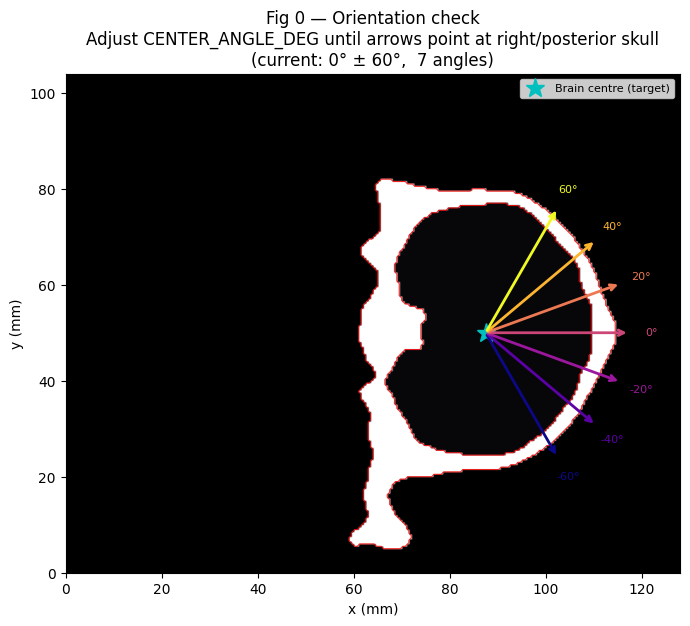

Fig 0 saved.  Adjust CENTER_ANGLE_DEG if arrows do not point at correct side.

Computing shared adjoint from brain target (used for holographic gel design)...
  [adjoint]  |p(tgt)|=7.121e-01  (0.5s)
  Done. Reusing for all 56 combos.

Starting grid scan (7 angles × 8 standoffs)
  idx    angle   standoff   miss_bare     holo      FWI   miss_fwi    time
  --------------------------------------------------------------------
    1   -60.0°      2.0mm        3.4mm    1.24x    1.24x       3.9mm      5s
    2   -40.0°      2.0mm       20.4mm    1.45x    1.45x       1.6mm      5s
    3   -20.0°      2.0mm        9.9mm    1.16x    1.16x      23.3mm      5s
    4     0.0°      2.0mm       22.2mm    0.97x    0.97x      22.2mm      5s
    5    20.0°      2.0mm       23.8mm    1.42x    1.42x       9.2mm     12s
    6    40.0°      2.0mm        0.5mm    1.20x    1.20x       5.7mm      6s
    7    60.0°      2.0mm        4.0mm    1.27x    1.27x       1.0mm      6s
    8   -60.0°      4.0mm        3.2

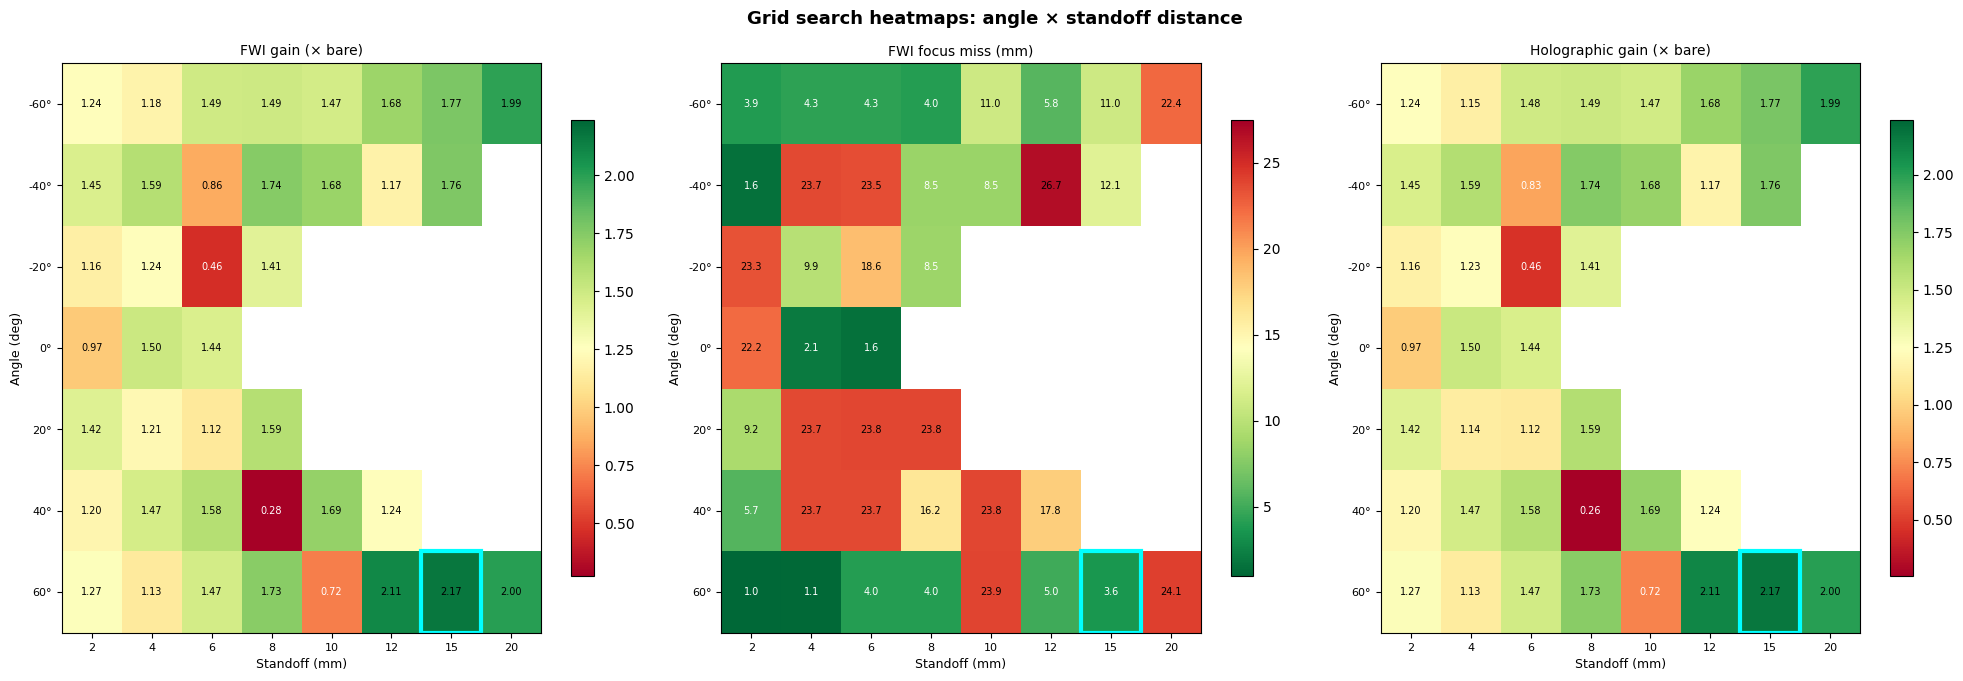

Fig 1 saved.

BEST:  angle=60.0°  standoff=15.0mm  skull=3.0mm
  FWI gain=2.17x  miss_bare=11.9mm  miss_FWI=3.6mm


C:\Users\bengi\AppData\Local\Temp\ipykernel_35760\1663781393.py:538: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


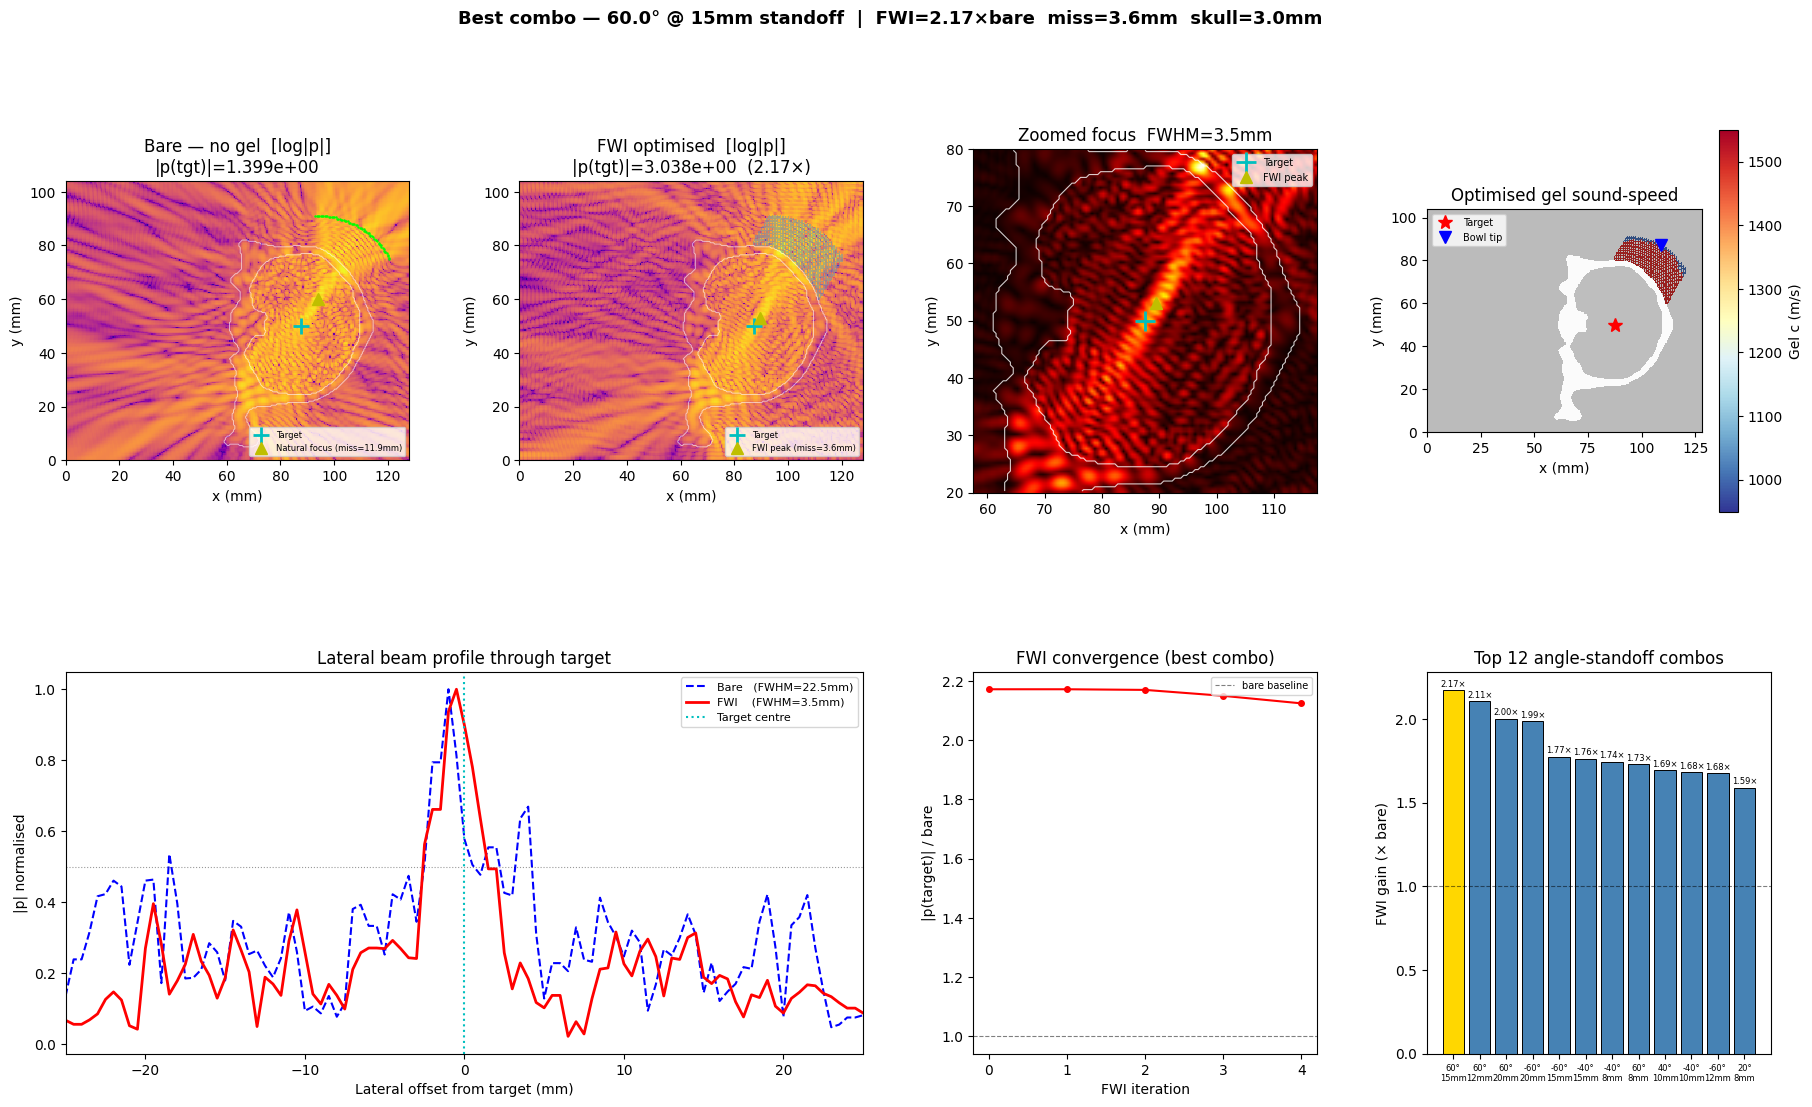


BEST COMBO:  angle=60.0°  standoff=15.0mm  skull=3.0mm
  Bare |p(tgt)|:    1.3987e+00
  Holo |p(tgt)|:    3.0375e+00  (2.17×)
  FWI  |p(tgt)|:    3.0375e+00  (2.17×)
  Natural focus miss:  11.93 mm
  FWI focus miss:      3.61 mm
  FWHM lateral bare:   22.50 mm
  FWHM lateral FWI:    3.50 mm
  Total scan time:     4.7 min


In [12]:
# =============================================================================
# CELL 23 — Grid Search: Angle × Standoff Distance
#
# Scans a 2-D grid of (approach angle, standoff distance) positions.
# For every valid combo:
#   1. Run bare curved-transducer simulation → natural focus location
#   2. Design holographic gel via phase conjugation
#   3. Run FWI gel optimisation
# Reports a gain / focus-miss heatmap and detailed figures for the winner.
#
# Key parameters:
#   CENTER_ANGLE_DEG  — check Fig 0 first; rotate until arrows hit the
#                       right / posterior skull. Try 0, 90, 180, 270.
#   STANDOFF_MM_LIST  — distances from outer skull surface to bowl tip (mm)
# =============================================================================
import pathlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import binary_fill_holes, center_of_mass

warnings.filterwarnings('ignore', message='A JAX array is being set as static')

import jax.numpy as jnp
from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import born_series

# ── Parameters (adjust these) ─────────────────────────────────────────────────
CENTER_ANGLE_DEG = 0.0       # approach direction; verify with Fig 0
HALF_SWEEP_DEG   = 60.0      # ± half-width of arc
N_SCAN           = 7         # number of angles within the sweep

STANDOFF_MM_LIST = [2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0]  # mm from skull outer surface

FREQ            = 500_000.0
OMEGA           = 2 * np.pi * FREQ
C_WATER         = 1500.0
C_GEL           = 1000.0
RHO_GEL         = 1100.0
AP_MM           = 32.0
ROC_MM          = 30.0
N_FWI_MAX       = 15
PATIENCE        = 4
IMPROVE_THRESH  = 5e-4
FWI_STEP_INIT   = 0.06
N_BORN          = 300

data_dir = pathlib.Path(r'C:\Users\bengi\Documents\Pesaran Lab')

# ── Load CT ───────────────────────────────────────────────────────────────────
print('=' * 72)
print('Loading CT data...')
c_map   = np.load(data_dir / 'c_map_full.npy').astype(np.float32).T
rho_map = np.load(data_dir / 'rho_map_full.npy').astype(np.float32).T
bone    = np.load(data_dir / 'bone_mask_2d.npy').astype(bool).T
head    = binary_fill_holes(bone)
brain   = head & ~bone

c_map[c_map < 1000]    = C_WATER
rho_map[rho_map < 100] = 1000.0

dx     = 0.5e-3
Nx, Ny = c_map.shape
cx, cy = [int(v) for v in center_of_mass(brain)]

half_ap       = int(round(AP_MM * 1e-3 / (2 * dx)))
ROC_px        = ROC_MM * 1e-3 / dx
half_ap_m     = half_ap * dx
half_angle    = np.arcsin(min(half_ap_m / (ROC_MM * 1e-3), 0.98))
bowl_depth_px = int(np.ceil(ROC_px * (1.0 - np.cos(half_angle))))

n_combos = N_SCAN * len(STANDOFF_MM_LIST)
print(f'  Brain centre: ({cx}, {cy})  |  ROC={ROC_MM}mm  F#={ROC_MM/AP_MM:.2f}')
print(f'  Grid: {N_SCAN} angles × {len(STANDOFF_MM_LIST)} standoffs = {n_combos} combos')
print(f'  Angles sweep: {CENTER_ANGLE_DEG:.0f}° ± {HALF_SWEEP_DEG:.0f}°')
print(f'  Standoffs: {STANDOFF_MM_LIST} mm')

domain = Domain((Nx, Ny), (dx, dx))
ext    = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
kw     = dict(origin='lower', aspect='equal', extent=ext, interpolation='nearest')

def make_medium(c_arr, rho_arr):
    return Medium(
        domain      = domain,
        sound_speed = FourierSeries(jnp.array(c_arr[..., None],   dtype=jnp.float32), domain),
        density     = FourierSeries(jnp.array(rho_arr[..., None], dtype=jnp.float32), domain),
        pml_size    = 15,
    )

def run_born(medium, src_np_2d, label=None):
    src_fs = FourierSeries(jnp.array(src_np_2d[..., None], dtype=complex), domain)
    t0 = time.time()
    p  = born_series(medium, src_fs, omega=OMEGA, max_iter=N_BORN, tol=1e-5)
    pnp = np.array(p.on_grid[..., 0])
    if label:
        print(f'  [{label}]  |p(tgt)|={np.abs(pnp[cx,cy]):.3e}  ({time.time()-t0:.1f}s)')
    return pnp

def medium_from_rho(rg, gel_rgn):
    c_c = np.where(gel_rgn > 0,
                   1.0 / (rg / C_GEL + (1.0 - rg) / C_WATER), c_map).astype(np.float32)
    r_c = np.where(gel_rgn > 0,
                   rg * RHO_GEL + (1.0 - rg) * rho_map, rho_map).astype(np.float32)
    return make_medium(c_c, r_c)

medium_bare = make_medium(c_map, rho_map)

# ── Geometry helper (standoff-aware) ──────────────────────────────────────────
def get_position(ang_deg, so_px):
    ang = np.radians(ang_deg)
    bx_ = np.cos(ang);  by_ = np.sin(ang)
    px_ = -np.sin(ang); py_ = np.cos(ang)

    inner_r = outer_r = None
    for r in range(5, max(Nx, Ny)):
        xi = int(round(cx + r * bx_))
        yi = int(round(cy + r * by_))
        if not (0 <= xi < Nx and 0 <= yi < Ny):
            break
        if bone[xi, yi] and inner_r is None:
            inner_r = r
        if inner_r is not None and not bone[xi, yi]:
            outer_r = r
            break

    if outer_r is None or inner_r is None or (outer_r - inner_r) < 2:
        return None

    tip_cx = int(round(cx + (outer_r + so_px) * bx_))
    tip_cy = int(round(cy + (outer_r + so_px) * by_))
    if not (bowl_depth_px + 4 <= tip_cx < Nx - bowl_depth_px - 4 and
            bowl_depth_px + 4 <= tip_cy < Ny - bowl_depth_px - 4):
        return None

    nat_fx = tip_cx - ROC_px * bx_
    nat_fy = tip_cy - ROC_px * by_

    alphas = np.linspace(-half_angle, half_angle, 2 * half_ap + 1)
    tx_px  = []
    for alpha in alphas:
        xi = int(round(nat_fx + ROC_px * (np.sin(alpha) * px_ + np.cos(alpha) * bx_)))
        yi = int(round(nat_fy + ROC_px * (np.sin(alpha) * py_ + np.cos(alpha) * by_)))
        if 0 <= xi < Nx and 0 <= yi < Ny:
            tx_px.append((xi, yi))

    if len(tx_px) < 8:
        return None
    for xi, yi in tx_px:
        if not (4 <= xi < Nx - 4 and 4 <= yi < Ny - 4):
            return None

    return dict(ang_deg=ang_deg, so_mm=so_px * dx * 1e3,
                bx=bx_, by=by_, px=px_, py=py_,
                outer_r=outer_r, skull_mm=(outer_r - inner_r) * dx * 1e3,
                tip_cx=tip_cx, tip_cy=tip_cy,
                nat_fx=nat_fx, nat_fy=nat_fy, tx_pixels=tx_px)

def find_natural_focus(E_field, exclude_mask):
    search = head & ~bone & ~exclude_mask
    inside = np.abs(E_field) * search
    return np.unravel_index(np.argmax(inside), inside.shape)

# ── Figure 0: Orientation check ───────────────────────────────────────────────
scan_angles_deg = np.linspace(CENTER_ANGLE_DEG - HALF_SWEEP_DEG,
                               CENTER_ANGLE_DEG + HALF_SWEEP_DEG, N_SCAN)
fig0, ax0 = plt.subplots(figsize=(7, 7))
ax0.imshow(c_map.T, cmap='bone', origin='lower', aspect='equal', extent=ext)
ax0.contour(bone.T, levels=[0.5], extent=ext, origin='lower',
            colors='red', linewidths=0.8, alpha=0.8)
ax0.plot(cx*dx*1e3, cy*dx*1e3, 'c*', ms=14, label='Brain centre (target)')
arrow_r = 30
for i, ang in enumerate(scan_angles_deg):
    col = plt.cm.plasma(i / max(N_SCAN - 1, 1))
    ax0.annotate('', xy=(cx*dx*1e3 + arrow_r*np.cos(np.radians(ang)),
                          cy*dx*1e3 + arrow_r*np.sin(np.radians(ang))),
                 xytext=(cx*dx*1e3, cy*dx*1e3),
                 arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax0.text(cx*dx*1e3 + arrow_r*1.15*np.cos(np.radians(ang)),
             cy*dx*1e3 + arrow_r*1.15*np.sin(np.radians(ang)),
             f'{ang:.0f}°', fontsize=8, color=col, ha='center', va='center')
ax0.set(xlabel='x (mm)', ylabel='y (mm)',
        title=f'Fig 0 — Orientation check\n'
              f'Adjust CENTER_ANGLE_DEG until arrows point at right/posterior skull\n'
              f'(current: {CENTER_ANGLE_DEG:.0f}° ± {HALF_SWEEP_DEG:.0f}°,  {N_SCAN} angles)')
ax0.legend(fontsize=8)
plt.tight_layout()
plt.savefig(data_dir / 'orientation_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fig 0 saved.  Adjust CENTER_ANGLE_DEG if arrows do not point at correct side.')

# ── Shared adjoint from target (computed once, reused for all holo designs) ───
print()
print('=' * 72)
print('Computing shared adjoint from brain target (used for holographic gel design)...')
src_tgt         = np.zeros((Nx, Ny), dtype=complex)
src_tgt[cx, cy] = 1.0 + 0j
E_adj0 = run_born(medium_bare, src_tgt, label='adjoint')
print(f'  Done. Reusing for all {n_combos} combos.')

# ── Grid scan: angle × standoff ───────────────────────────────────────────────
print()
print('=' * 72)
print(f'Starting grid scan ({N_SCAN} angles × {len(STANDOFF_MM_LIST)} standoffs)')
print(f'{"idx":>5}  {"angle":>7}  {"standoff":>9}  {"miss_bare":>10}  '
      f'{"holo":>7}  {"FWI":>7}  {"miss_fwi":>9}  {"time":>6}')
print('  ' + '-' * 68)

all_results = []
n_done = 0
t_grid_start = time.time()

for so_mm in STANDOFF_MM_LIST:
    so_px = max(1, int(round(so_mm * 1e-3 / dx)))
    for ang in scan_angles_deg:
        n_done += 1
        pos = get_position(ang, so_px)
        if pos is None:
            print(f'{n_done:5d}  {ang:6.1f}°  {so_mm:7.1f}mm  — INVALID (geometry out of bounds)')
            continue

        src_flat = np.zeros((Nx, Ny), dtype=complex)
        for xi, yi in pos['tx_pixels']:
            src_flat[xi, yi] = 1.0 + 0j

        t0 = time.time()

        # ── 1. Bare simulation + natural focus ──────────────────────────────
        E_bare     = run_born(medium_bare, src_flat)
        p_bare_tgt = float(np.abs(E_bare[cx, cy]))
        tx_excl    = np.zeros((Nx, Ny), dtype=bool)
        for xi, yi in pos['tx_pixels']:
            tx_excl[xi, yi] = True
        nf_ix, nf_iy = find_natural_focus(E_bare, tx_excl)
        miss_bare    = np.hypot(nf_ix - cx, nf_iy - cy) * dx * 1e3

        # ── 2. Holographic gel design ────────────────────────────────────────
        k_gel   = OMEGA / C_GEL;  k_water = OMEGA / C_WATER
        E_at_tx = np.array([E_adj0[xi, yi] for xi, yi in pos['tx_pixels']])
        phi_tx  = np.angle(E_at_tx)
        phi_req = phi_tx.max() - phi_tx
        t_holo_px = np.clip(
            np.round(phi_req / ((k_gel - k_water) * dx)).astype(int), 0, so_px - 1)

        gel_region = np.zeros((Nx, Ny), dtype=np.float32)
        rho_gel    = np.zeros((Nx, Ny), dtype=np.float64)
        bx_ = pos['bx'];  by_ = pos['by']
        for ui, (xf, yf) in enumerate(pos['tx_pixels']):
            for t in range(1, so_px + bowl_depth_px + 1):
                xi = int(round(xf - t * bx_))
                yi = int(round(yf - t * by_))
                if not (0 <= xi < Nx and 0 <= yi < Ny):
                    break
                if bone[xi, yi]:
                    break
                gel_region[xi, yi] = 1.0
                if t <= t_holo_px[ui]:
                    rho_gel[xi, yi] = 1.0

        E_holo     = run_born(medium_from_rho(rho_gel, gel_region), src_flat)
        p_holo_tgt = float(np.abs(E_holo[cx, cy]))
        gain_holo  = p_holo_tgt / max(p_bare_tgt, 1e-30)

        # ── 3. FWI optimisation ──────────────────────────────────────────────
        best_gain = gain_holo
        best_rho  = rho_gel.copy()
        no_improv = 0
        step      = FWI_STEP_INIT
        gains_fwi = [gain_holo]

        for it in range(N_FWI_MAX):
            med   = medium_from_rho(rho_gel, gel_region)
            E_fwd = run_born(med, src_flat)
            p_tgt = E_fwd[cx, cy]
            gain  = float(np.abs(p_tgt)) / max(p_bare_tgt, 1e-30)
            gains_fwi.append(gain)

            if gain > best_gain * (1.0 + IMPROVE_THRESH):
                best_gain = gain;  best_rho = rho_gel.copy()
                no_improv = 0;     step = min(step * 1.15, FWI_STEP_INIT * 4)
            else:
                no_improv += 1;    step = max(step * 0.75, FWI_STEP_INIT * 0.1)

            if no_improv >= PATIENCE:
                break

            src_adj         = np.zeros((Nx, Ny), dtype=complex)
            src_adj[cx, cy] = np.exp(-1j * np.angle(p_tgt))
            E_adj_it        = run_born(med, src_adj)
            grad  = np.real(E_fwd * E_adj_it) * gel_region
            g_max = np.abs(grad).max()
            if g_max > 0:
                rho_gel = np.clip(rho_gel + step * grad / g_max, 0.0, 1.0)

        # Final forward pass with best rho
        E_fwi     = run_born(medium_from_rho(best_rho, gel_region), src_flat)
        p_fwi_tgt = float(np.abs(E_fwi[cx, cy]))
        gain_fwi  = p_fwi_tgt / max(p_bare_tgt, 1e-30)

        inside   = np.abs(E_fwi) * brain.astype(float)
        fwi_peak = np.unravel_index(np.argmax(inside), inside.shape)
        miss_fwi = np.hypot(fwi_peak[0] - cx, fwi_peak[1] - cy) * dx * 1e3

        elapsed = time.time() - t0
        print(f'{n_done:5d}  {ang:6.1f}°  {so_mm:7.1f}mm  '
              f'{miss_bare:9.1f}mm  {gain_holo:6.2f}x  {gain_fwi:6.2f}x  '
              f'{miss_fwi:8.1f}mm  {elapsed:5.0f}s')

        all_results.append(dict(
            ang_deg=ang, so_mm=so_mm, pos=pos,
            src_flat=src_flat,
            E_bare=E_bare, nf_ix=nf_ix, nf_iy=nf_iy, miss_bare=miss_bare,
            p_bare_tgt=p_bare_tgt,
            p_holo_tgt=p_holo_tgt, gain_holo=gain_holo,
            E_fwi=E_fwi, fwi_peak=fwi_peak, miss_fwi=miss_fwi,
            gain_fwi=gain_fwi, best_rho=best_rho, gel_region=gel_region,
            gains_fwi=gains_fwi,
        ))

if not all_results:
    raise RuntimeError('No valid positions found. Adjust CENTER_ANGLE_DEG.')

t_total = time.time() - t_grid_start
print(f'\nGrid scan complete: {len(all_results)} valid combos in {t_total/60:.1f} min')

# ── Summary table ─────────────────────────────────────────────────────────────
sorted_results = sorted(all_results, key=lambda r: -r['gain_fwi'])
print()
print('=' * 72)
print('GRID SCAN RESULTS (sorted by FWI gain):')
print(f'  {"rank":>4}  {"angle":>8}  {"standoff":>9}  {"skull":>6}  '
      f'{"miss_bare":>10}  {"miss_FWI":>9}  {"holo":>8}  {"FWI gain":>9}')
print('  ' + '-' * 70)
for rank, r in enumerate(sorted_results):
    flag = '  *** BEST' if rank == 0 else ''
    print(f'  {rank+1:4d}  {r["ang_deg"]:7.1f}°  {r["so_mm"]:7.1f}mm  '
          f'{r["pos"]["skull_mm"]:5.1f}mm  '
          f'{r["miss_bare"]:9.1f}mm  {r["miss_fwi"]:8.1f}mm  '
          f'{r["gain_holo"]:7.2f}x  {r["gain_fwi"]:8.2f}x{flag}')

# ── Figure 1: 2-D heatmaps (angle × standoff) ─────────────────────────────────
angles_used    = sorted(set(r['ang_deg'] for r in all_results))
standoffs_used = sorted(set(r['so_mm']  for r in all_results))
na = len(angles_used);  ns = len(standoffs_used)
a_idx = {a: i for i, a in enumerate(angles_used)}
s_idx = {s: j for j, s in enumerate(standoffs_used)}

gain_mat = np.full((na, ns), np.nan)
miss_mat = np.full((na, ns), np.nan)
holo_mat = np.full((na, ns), np.nan)
for r in all_results:
    i = a_idx[r['ang_deg']];  j = s_idx[r['so_mm']]
    gain_mat[i, j] = r['gain_fwi']
    miss_mat[i, j] = r['miss_fwi']
    holo_mat[i, j] = r['gain_holo']

fig1, axes1 = plt.subplots(1, 3, figsize=(20, max(4, na * 0.7 + 2)))
fig1.suptitle('Grid search heatmaps: angle × standoff distance',
              fontsize=13, fontweight='bold')

best_r = sorted_results[0]
bi = a_idx[best_r['ang_deg']];  bj = s_idx[best_r['so_mm']]

for ax, mat, title, cmap, rev in [
    (axes1[0], gain_mat, 'FWI gain (× bare)',         'RdYlGn',   False),
    (axes1[1], miss_mat, 'FWI focus miss (mm)',        'RdYlGn',   True),
    (axes1[2], holo_mat, 'Holographic gain (× bare)',  'RdYlGn',   False),
]:
    vmin, vmax = np.nanmin(mat), np.nanmax(mat)
    im = ax.imshow(mat, cmap=cmap + ('_r' if rev else ''),
                   aspect='auto', vmin=vmin*0.97, vmax=vmax*1.03)
    ax.set_xticks(range(ns))
    ax.set_xticklabels([f'{s:.0f}' for s in standoffs_used], fontsize=8)
    ax.set_yticks(range(na))
    ax.set_yticklabels([f'{a:.0f}°' for a in angles_used], fontsize=8)
    ax.set_xlabel('Standoff (mm)', fontsize=9)
    ax.set_ylabel('Angle (deg)',   fontsize=9)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(na):
        for j in range(ns):
            if not np.isnan(mat[i, j]):
                fmt = '.1f' if title.endswith('mm)') else '.2f'
                ax.text(j, i, f'{mat[i,j]:{fmt}}',
                        ha='center', va='center', fontsize=7,
                        color='white' if abs(mat[i,j]-vmin) < 0.3*(vmax-vmin) else 'black')
    ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1,
                                fill=False, edgecolor='cyan', lw=3))

plt.tight_layout()
plt.savefig(data_dir / 'grid_search_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 1 saved.')

# ── Figure 2: Detailed comparison for the best combo ──────────────────────────
best       = sorted_results[0]
pos        = best['pos']
ang        = best['ang_deg']
E_bare     = best['E_bare']
E_fwi      = best['E_fwi']
p_bare_tgt = best['p_bare_tgt']
p_fwi_tgt  = float(np.abs(E_fwi[cx, cy]))
gel_region = best['gel_region']
best_rho   = best['best_rho']
fwi_peak   = best['fwi_peak']
miss_fwi   = best['miss_fwi']
c_opt      = np.where(gel_region > 0,
                      1.0 / (best_rho / C_GEL + (1.0 - best_rho) / C_WATER),
                      c_map).astype(np.float32)

print()
print('=' * 72)
print(f'BEST:  angle={ang:.1f}°  standoff={best["so_mm"]:.1f}mm  '
      f'skull={best["pos"]["skull_mm"]:.1f}mm')
print(f'  FWI gain={best["gain_fwi"]:.2f}x  miss_bare={best["miss_bare"]:.1f}mm  '
      f'miss_FWI={miss_fwi:.1f}mm')
print('=' * 72)

def log_norm(p_abs):
    return np.log10(p_abs / (p_abs.max() + 1e-30) + 1e-3)

def fwhm_mm_1d(vals, offsets_mm):
    half_max = vals.max() / 2.0
    above    = np.where(vals >= half_max)[0]
    return abs(offsets_mm[above[-1]] - offsets_mm[above[0]]) if len(above) > 1 else 0.0

def lateral_profile(p_abs, ix, iy, px_, py_, n_pts=120):
    ofs  = np.arange(-n_pts // 2, n_pts // 2)
    vals = []
    for s in ofs:
        xi = int(round(ix + s * px_));  yi = int(round(iy + s * py_))
        vals.append(p_abs[xi, yi] if 0 <= xi < Nx and 0 <= yi < Ny else 0.0)
    return np.array(vals), ofs * dx * 1e3

lat_bare_v, lat_ofs = lateral_profile(np.abs(E_bare), cx, cy, pos['px'], pos['py'])
lat_fwi_v,  _       = lateral_profile(np.abs(E_fwi),  cx, cy, pos['px'], pos['py'])
fwhm_bare = fwhm_mm_1d(lat_bare_v, lat_ofs)
fwhm_fwi  = fwhm_mm_1d(lat_fwi_v,  lat_ofs)

fig2 = plt.figure(figsize=(22, 12))
gs2  = gridspec.GridSpec(2, 4, figure=fig2, hspace=0.42, wspace=0.32)
fig2.suptitle(f'Best combo — {ang:.1f}° @ {best["so_mm"]:.0f}mm standoff  |  '
              f'FWI={best["gain_fwi"]:.2f}×bare  miss={miss_fwi:.1f}mm  '
              f'skull={best["pos"]["skull_mm"]:.1f}mm',
              fontsize=13, fontweight='bold')

# A: Bare field
ax_a = fig2.add_subplot(gs2[0, 0])
ax_a.imshow(log_norm(np.abs(E_bare)).T, cmap='plasma', vmin=-3, vmax=0, **kw)
ax_a.contour(bone.T, levels=[0.5], extent=ext, origin='lower',
             colors='white', linewidths=0.7, alpha=0.6)
ax_a.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=12, mew=2, label='Target')
ax_a.plot(best['nf_ix']*dx*1e3, best['nf_iy']*dx*1e3, 'y^', ms=9,
          label=f'Natural focus (miss={best["miss_bare"]:.1f}mm)')
for xi, yi in pos['tx_pixels']:
    ax_a.plot(xi*dx*1e3, yi*dx*1e3, '.', color='lime', ms=1.5)
ax_a.set(xlabel='x (mm)', ylabel='y (mm)',
         title=f'Bare — no gel  [log|p|]\n|p(tgt)|={p_bare_tgt:.3e}')
ax_a.legend(fontsize=6, loc='lower right')

# B: FWI field
ax_b = fig2.add_subplot(gs2[0, 1])
ax_b.imshow(log_norm(np.abs(E_fwi)).T, cmap='plasma', vmin=-3, vmax=0, **kw)
ax_b.contour(bone.T, levels=[0.5], extent=ext, origin='lower',
             colors='white', linewidths=0.7, alpha=0.6)
ax_b.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=12, mew=2, label='Target')
ax_b.plot(fwi_peak[0]*dx*1e3, fwi_peak[1]*dx*1e3, 'y^', ms=9,
          label=f'FWI peak (miss={miss_fwi:.1f}mm)')
ax_b.imshow(np.where(gel_region > 0, 0.6, np.nan).T,
            cmap='Blues', alpha=0.45, vmin=0, vmax=1, **kw)
ax_b.set(xlabel='x (mm)', ylabel='y (mm)',
         title=f'FWI optimised  [log|p|]\n|p(tgt)|={p_fwi_tgt:.3e}  ({best["gain_fwi"]:.2f}×)')
ax_b.legend(fontsize=6, loc='lower right')

# C: Zoomed FWI around target
zoom_r = int(round(30e-3 / dx))
zx0, zx1 = max(0, cx - zoom_r), min(Nx, cx + zoom_r)
zy0, zy1 = max(0, cy - zoom_r), min(Ny, cy + zoom_r)
ext_z = [zx0*dx*1e3, zx1*dx*1e3, zy0*dx*1e3, zy1*dx*1e3]
kwz   = dict(origin='lower', aspect='equal', extent=ext_z, interpolation='bilinear')
p_zoom = np.abs(E_fwi[zx0:zx1, zy0:zy1])
ax_c = fig2.add_subplot(gs2[0, 2])
ax_c.imshow((p_zoom / (p_zoom.max() + 1e-30)).T, cmap='hot', vmin=0, vmax=1, **kwz)
ax_c.contour(bone[zx0:zx1, zy0:zy1].T, levels=[0.5], extent=ext_z, origin='lower',
             colors='white', linewidths=0.8, alpha=0.8)
ax_c.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=14, mew=2, label='Target')
ax_c.plot(fwi_peak[0]*dx*1e3, fwi_peak[1]*dx*1e3, 'y^', ms=8, label='FWI peak')
ax_c.set(xlabel='x (mm)', ylabel='y (mm)',
         title=f'Zoomed focus  FWHM={fwhm_fwi:.1f}mm')
ax_c.legend(fontsize=7)

# D: Gel sound-speed map
ax_d = fig2.add_subplot(gs2[0, 3])
im_c = ax_d.imshow(np.where(gel_region > 0, c_opt, np.nan).T,
                   cmap='RdYlBu_r', vmin=C_GEL - 50, vmax=C_WATER + 50, **kw)
ax_d.imshow(c_map.T, cmap='gray', vmin=1400, vmax=3200, alpha=0.28, **kw)
ax_d.plot(cx*dx*1e3, cy*dx*1e3, 'r*', ms=10, label='Target')
ax_d.plot(pos['tip_cx']*dx*1e3, pos['tip_cy']*dx*1e3, 'bv', ms=8, label='Bowl tip')
plt.colorbar(im_c, ax=ax_d, label='Gel c (m/s)')
ax_d.set(xlabel='x (mm)', ylabel='y (mm)', title='Optimised gel sound-speed')
ax_d.legend(fontsize=7)

# E: Lateral profiles
ax_e = fig2.add_subplot(gs2[1, 0:2])
norm_b = lat_bare_v / (lat_bare_v.max() + 1e-30)
norm_f = lat_fwi_v  / (lat_fwi_v.max()  + 1e-30)
ax_e.plot(lat_ofs, norm_b, 'b--', lw=1.5, label=f'Bare   (FWHM={fwhm_bare:.1f}mm)')
ax_e.plot(lat_ofs, norm_f, 'r-',  lw=2.0, label=f'FWI    (FWHM={fwhm_fwi:.1f}mm)')
ax_e.axvline(0, color='c', ls=':', lw=1.5, label='Target centre')
ax_e.axhline(0.5, color='k', ls=':', lw=0.8, alpha=0.4)
ax_e.set(xlabel='Lateral offset from target (mm)', ylabel='|p| normalised',
         title='Lateral beam profile through target')
ax_e.legend(fontsize=8);  ax_e.set_xlim(-25, 25)

# F: FWI convergence for best combo
ax_f = fig2.add_subplot(gs2[1, 2])
ax_f.plot(best['gains_fwi'], 'r-o', ms=4, lw=1.5)
ax_f.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5, label='bare baseline')
ax_f.set(xlabel='FWI iteration', ylabel='|p(target)| / bare',
         title='FWI convergence (best combo)')
ax_f.legend(fontsize=7)

# G: Top-N gain bar chart
n_show = min(12, len(sorted_results))
top_n  = sorted_results[:n_show]
xlabels = [f'{r["ang_deg"]:.0f}°\n{r["so_mm"]:.0f}mm' for r in top_n]
yvals   = [r['gain_fwi'] for r in top_n]
colors  = ['gold' if i == 0 else 'steelblue' for i in range(n_show)]
ax_g = fig2.add_subplot(gs2[1, 3])
ax_g.bar(range(n_show), yvals, color=colors, edgecolor='k', linewidth=0.7)
ax_g.set_xticks(range(n_show))
ax_g.set_xticklabels(xlabels, fontsize=6)
ax_g.set(ylabel='FWI gain (× bare)', title=f'Top {n_show} angle-standoff combos')
ax_g.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
for i, v in enumerate(yvals):
    ax_g.text(i, v + 0.01, f'{v:.2f}×', ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.savefig(data_dir / 'best_result_detail.png', dpi=130, bbox_inches='tight')
plt.show()

print()
print('=' * 72)
print(f'BEST COMBO:  angle={ang:.1f}°  standoff={best["so_mm"]:.1f}mm  '
      f'skull={best["pos"]["skull_mm"]:.1f}mm')
print(f'  Bare |p(tgt)|:    {p_bare_tgt:.4e}')
print(f'  Holo |p(tgt)|:    {best["p_holo_tgt"]:.4e}  ({best["gain_holo"]:.2f}×)')
print(f'  FWI  |p(tgt)|:    {p_fwi_tgt:.4e}  ({best["gain_fwi"]:.2f}×)')
print(f'  Natural focus miss:  {best["miss_bare"]:.2f} mm')
print(f'  FWI focus miss:      {miss_fwi:.2f} mm')
print(f'  FWHM lateral bare:   {fwhm_bare:.2f} mm')
print(f'  FWHM lateral FWI:    {fwhm_fwi:.2f} mm')
print(f'  Total scan time:     {t_total/60:.1f} min')
print('=' * 72)


### 24_focus_steering_gel_optimisation
Gaussian-weighted focus objective + distributed adjoint source.
Optimises gel geometry to minimise focal-point miss distance from target.
Requires cell 23 to run first.

CELL 24 v3: focus-steering gel optimisation
  Positions from cell 23: 40  (running: all)
  Sigma schedule (mm): ['8.0', '4.5', '2.5']
  Iters per phase:    [30, 30, 30]  (total=90)
  Adam lr=0.05   patience=10 (final phase, miss tol=0.3mm)
  Objective: Gaussian-weighted field energy J=Σ G(x)|E(x)|²
  Adjoint:   distributed G(x)·conj(E_fwd(x))  — rich gradient in gel


Positions:   0%|          | 0/40 [00:00<?, ?pos/s]


── [1/40]  60.0°  @  15.0mm  (cell-23: gain=2.172×, miss_bare=11.9mm) ──
  [1/4] Gel domain ...
        4559 voxels  (1139.8 mm²)
  [2/4] Holographic init ...
        gain=2.172×   miss=3.61mm
  [3/4] Multi-scale Adam FWI  (σ: 8.0→2.5mm, 90 iters total) ...


    FWI:   0%|          | 0/90 [00:00<?, ?it/s]

        σ=8.0mm  iter   1/90  miss=3.61mm  gain=2.172×  stall=1  (1.0s)
        → early stop at iter 10  (best miss=3.61mm)
        σ=4.5mm  iter  11/90  miss=5.32mm  gain=0.917×  stall=1  (1.0s)
        → early stop at iter 20  (best miss=3.61mm)
        σ=2.5mm  iter  21/90  miss=24.52mm  gain=0.514×  stall=1  (1.0s)
        → early stop at iter 30  (best miss=3.61mm)
  [4/4] Evaluating + binarising ...
        continuous:  miss=3.61mm  gain=2.172×
        binary:      miss=3.61mm  gain=2.172×

── [2/40]  60.0°  @  12.0mm  (cell-23: gain=2.106×, miss_bare=3.6mm) ──
  [1/4] Gel domain ...
        3877 voxels  (969.2 mm²)
  [2/4] Holographic init ...
        gain=2.106×   miss=5.00mm
  [3/4] Multi-scale Adam FWI  (σ: 8.0→2.5mm, 90 iters total) ...


...

        σ=8.0mm  iter   1/90  miss=23.85mm  gain=0.724×  stall=1  (0.8s)
        σ=8.0mm  iter  11/90  miss=22.19mm  gain=0.444×  stall=7  (0.8s)
        → early stop at iter 14  (best miss=15.44mm)
        σ=4.5mm  iter  21/90  miss=23.71mm  gain=0.262×  stall=7  (0.9s)
        → early stop at iter 24  (best miss=15.44mm)
        σ=2.5mm  iter  31/90  miss=13.58mm  gain=0.210×  stall=1  (0.9s)
        σ=2.5mm  iter  41/90  miss=22.19mm  gain=0.164×  stall=8  (0.8s)
        → early stop at iter 43  (best miss=9.49mm)
  [4/4] Evaluating + binarising ...
        continuous:  miss=9.49mm  gain=0.068×
        binary:      miss=6.02mm  gain=0.117×

── [39/40]  -20.0°  @  6.0mm  (cell-23: gain=0.463×, miss_bare=20.4mm) ──
  [1/4] Gel domain ...
        2295 voxels  (573.8 mm²)
  [2/4] Holographic init ...
        gain=0.463×   miss=18.60mm
  [3/4] Multi-scale Adam FWI  (σ: 8.0→2.5mm, 90 iters total) ...


    FWI:   0%|          | 0/90 [00:00<?, ?it/s]

        σ=8.0mm  iter   1/90  miss=18.60mm  gain=0.463×  stall=1  (0.9s)
        → early stop at iter 10  (best miss=18.60mm)
        σ=4.5mm  iter  11/90  miss=21.78mm  gain=0.266×  stall=1  (0.8s)
        σ=4.5mm  iter  21/90  miss=20.11mm  gain=0.111×  stall=9  (0.8s)
        → early stop at iter 22  (best miss=15.12mm)
        σ=2.5mm  iter  31/90  miss=14.58mm  gain=0.427×  stall=4  (0.9s)
        → early stop at iter 37  (best miss=8.90mm)
  [4/4] Evaluating + binarising ...
        continuous:  miss=8.90mm  gain=0.339×
        binary:      miss=20.40mm  gain=0.408×

── [40/40]  40.0°  @  8.0mm  (cell-23: gain=0.281×, miss_bare=9.0mm) ──
  [1/4] Gel domain ...
        2779 voxels  (694.8 mm²)
  [2/4] Holographic init ...
        gain=0.264×   miss=16.22mm
  [3/4] Multi-scale Adam FWI  (σ: 8.0→2.5mm, 90 iters total) ...


    FWI:   0%|          | 0/90 [00:00<?, ?it/s]

        σ=8.0mm  iter   1/90  miss=16.22mm  gain=0.264×  stall=1  (0.8s)
        → early stop at iter 10  (best miss=16.22mm)
        σ=4.5mm  iter  11/90  miss=20.35mm  gain=0.359×  stall=1  (0.8s)
        → early stop at iter 20  (best miss=16.22mm)
        σ=2.5mm  iter  21/90  miss=16.53mm  gain=0.024×  stall=1  (0.8s)
        σ=2.5mm  iter  31/90  miss=18.03mm  gain=0.193×  stall=8  (0.8s)
        → early stop at iter 33  (best miss=13.24mm)
  [4/4] Evaluating + binarising ...
        continuous:  miss=13.24mm  gain=0.115×
        binary:      miss=23.75mm  gain=0.593×

All done: 40 positions in 85.1 min (128s/pos)

RESULTS (sorted by binary-gel miss distance ↑, gain in brackets):
  rank    angle      so   miss_bare   miss_holo   miss_bin   gain_bin     axial      lat
  ------------------------------------------------------------------------------
     1   -60.0°    4.0mm       3.16mm       5.83mm      0.50mm     0.878×    -0.43mm   +0.25mm  *** BEST
     2    60.0°    2.0mm      

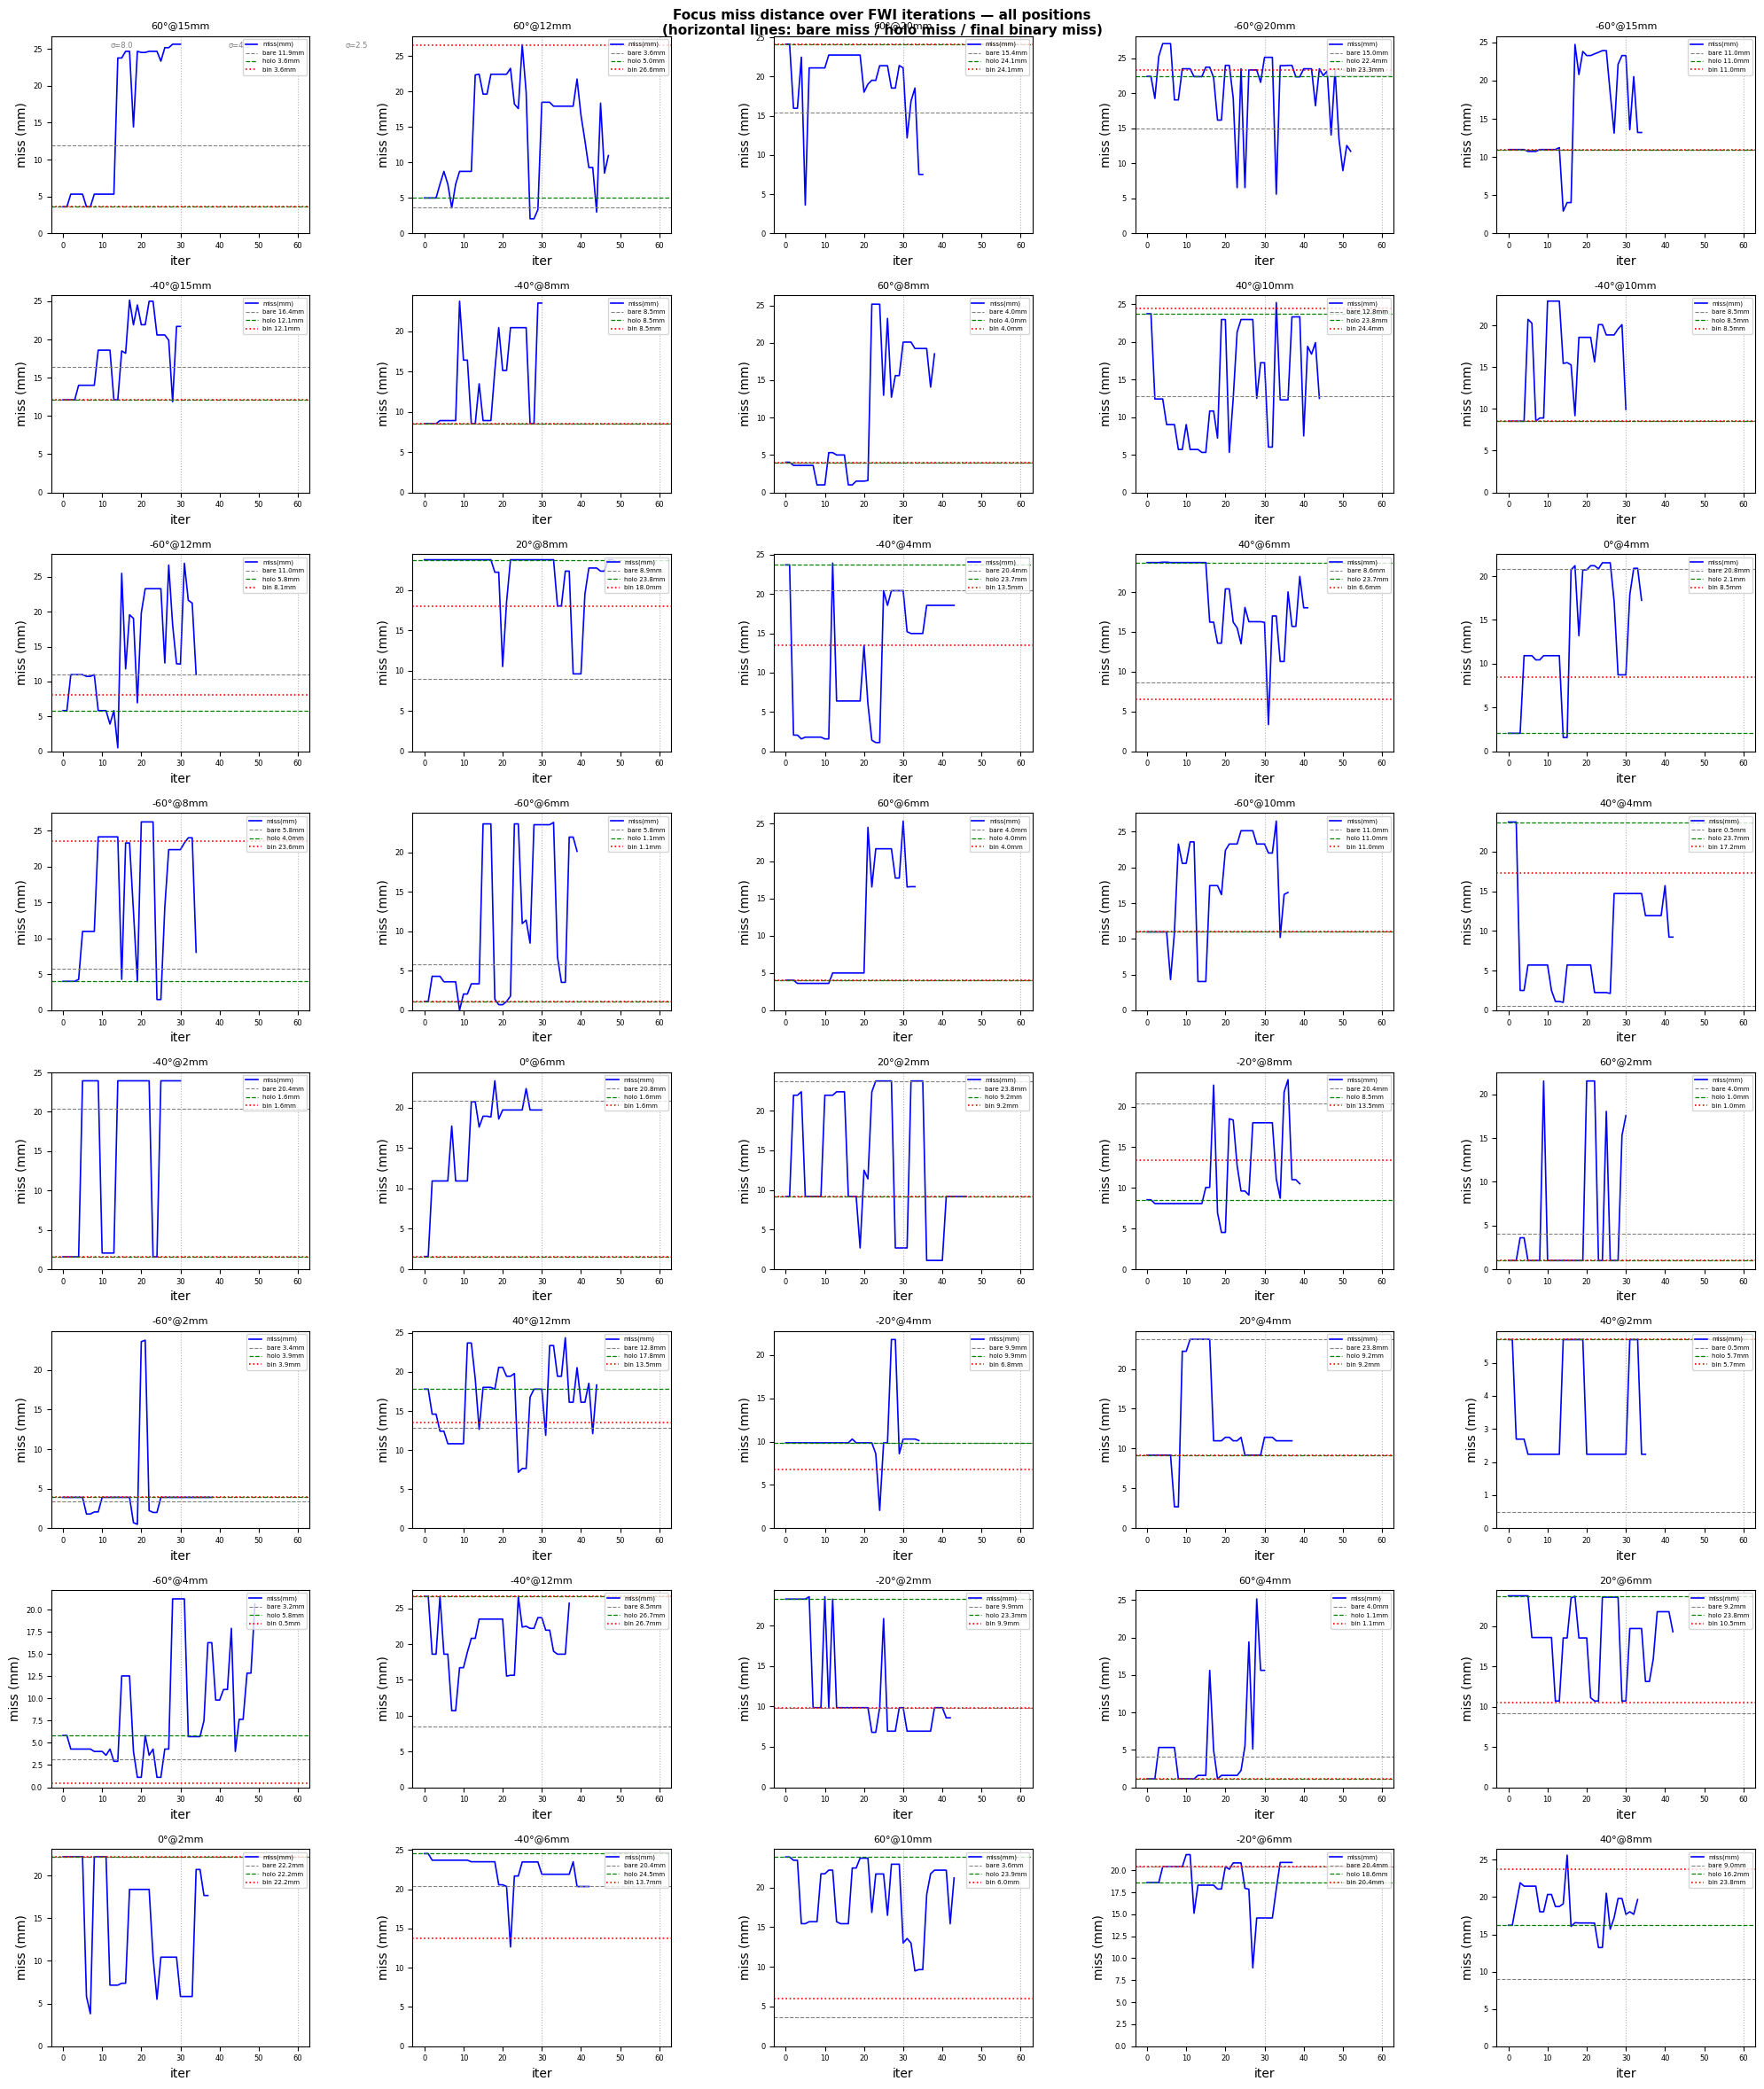

Fig 1 saved.


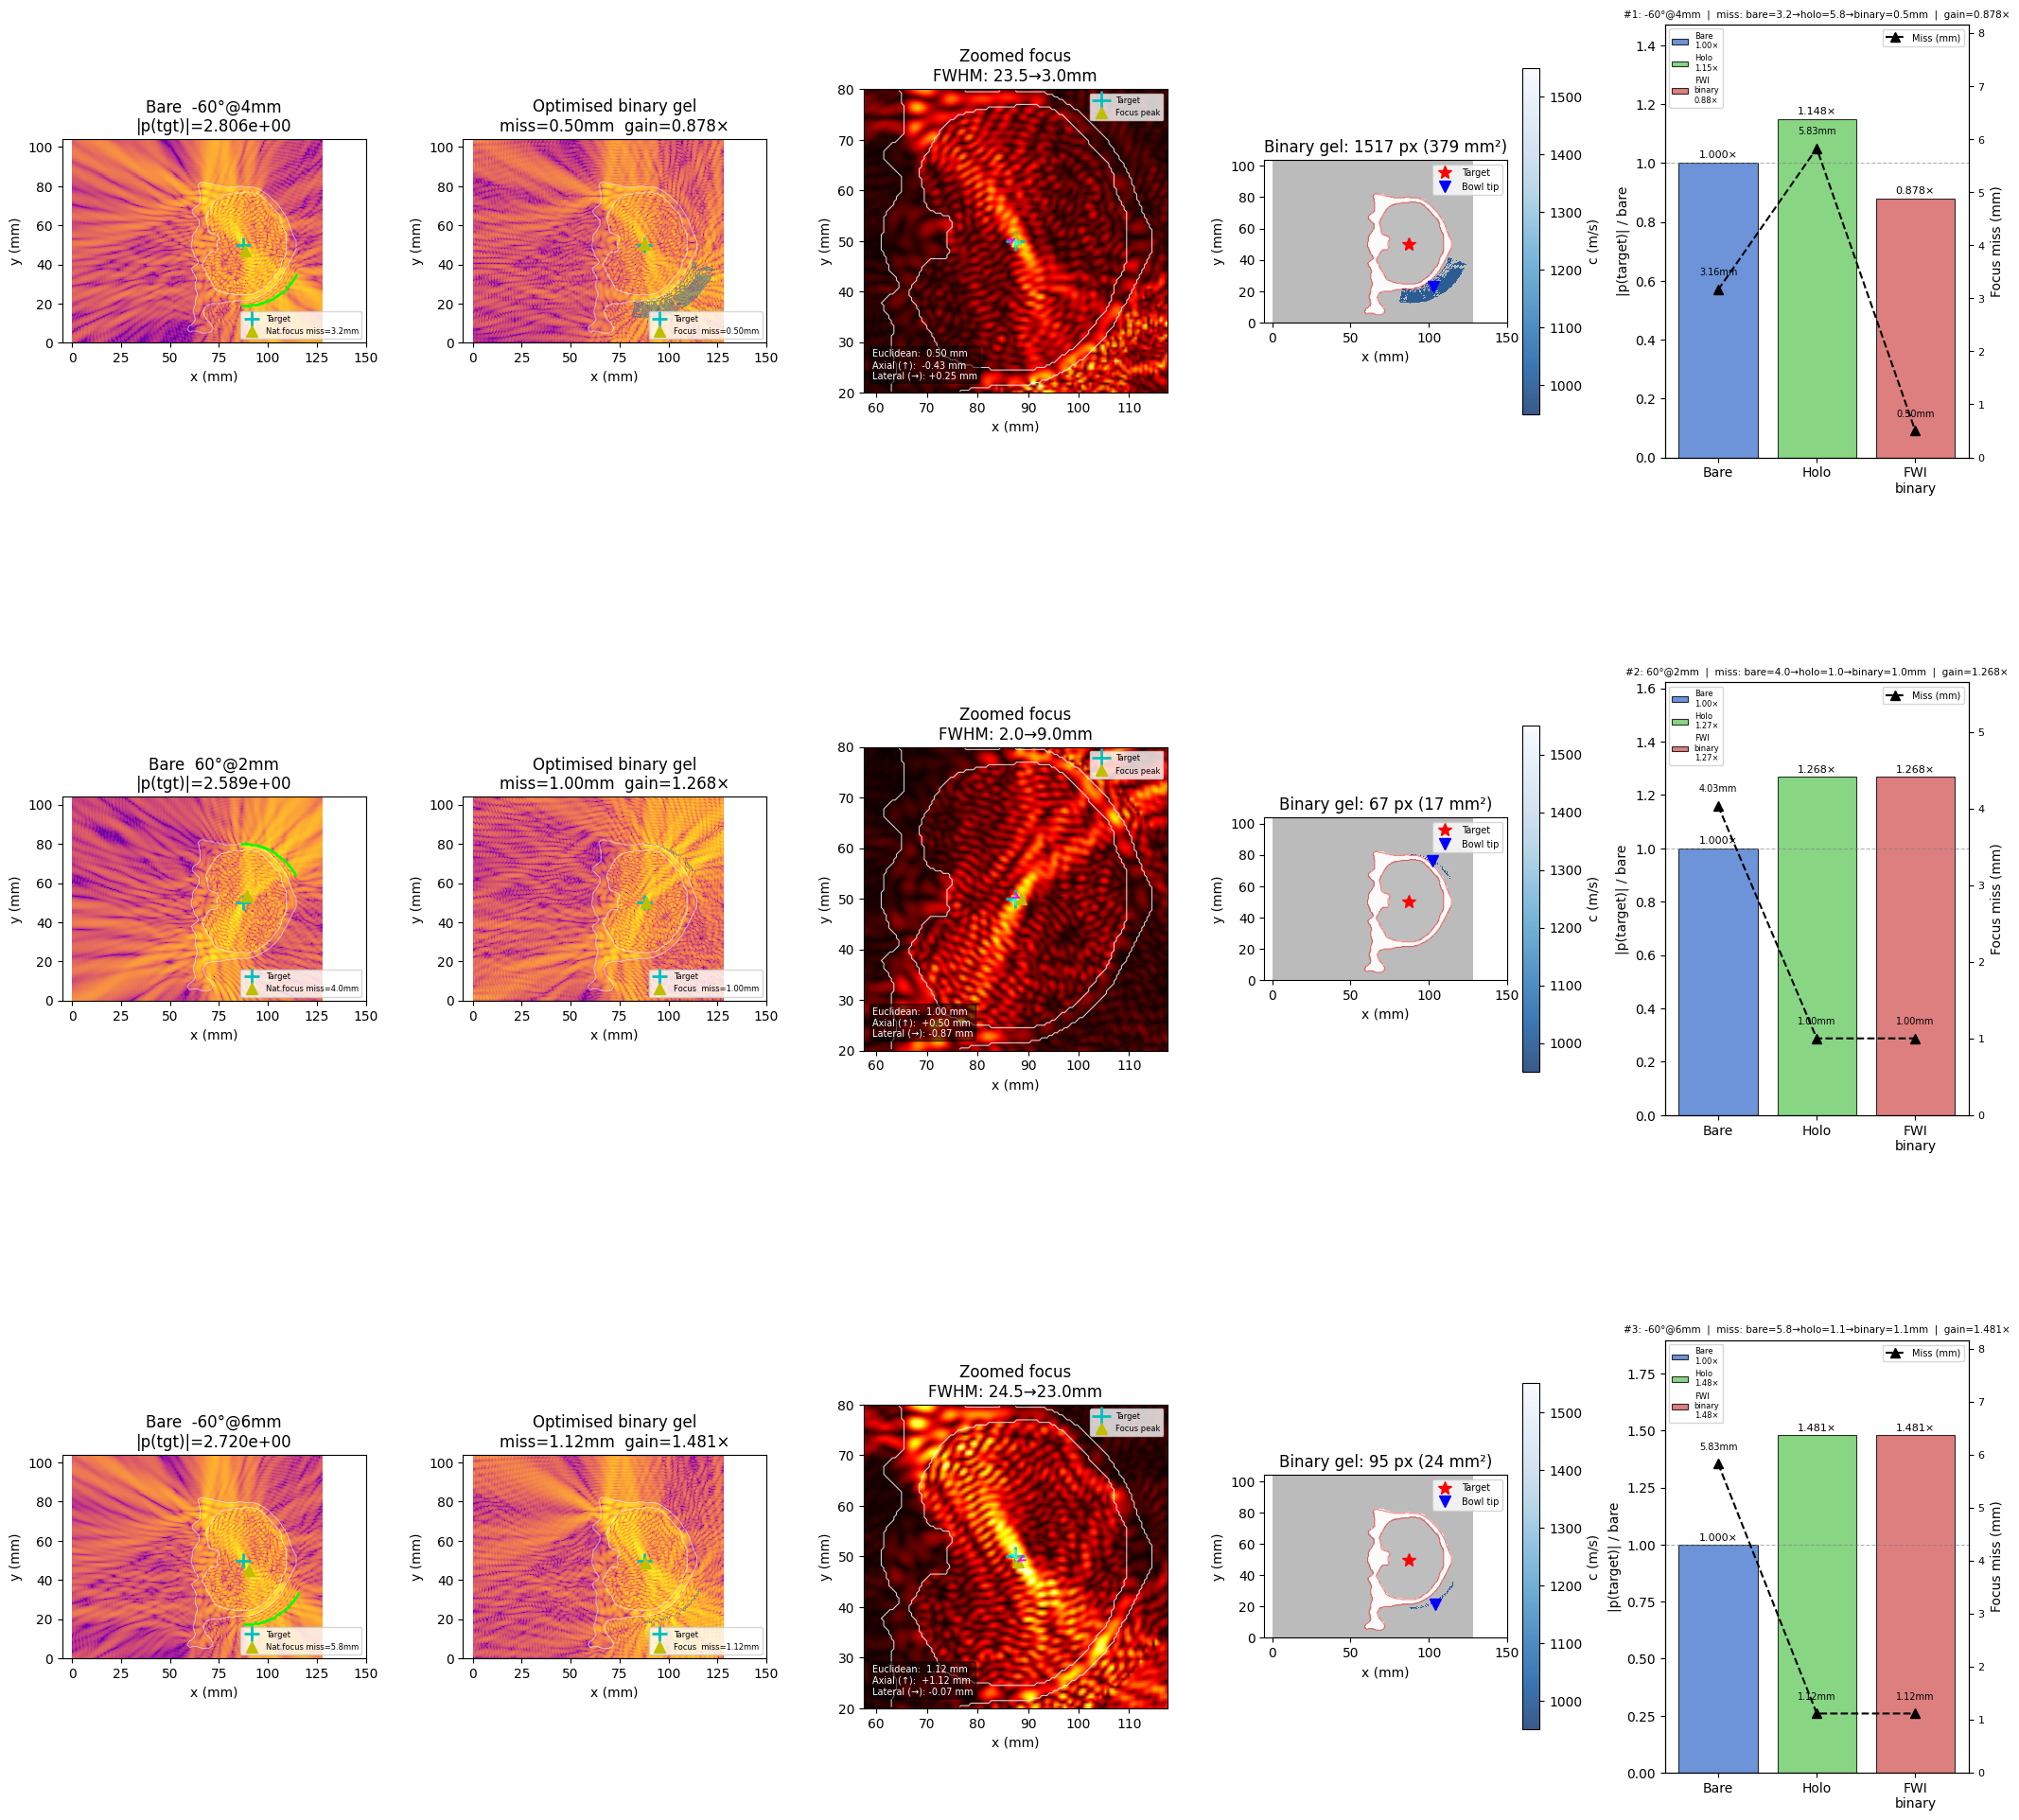

Fig 2 saved.


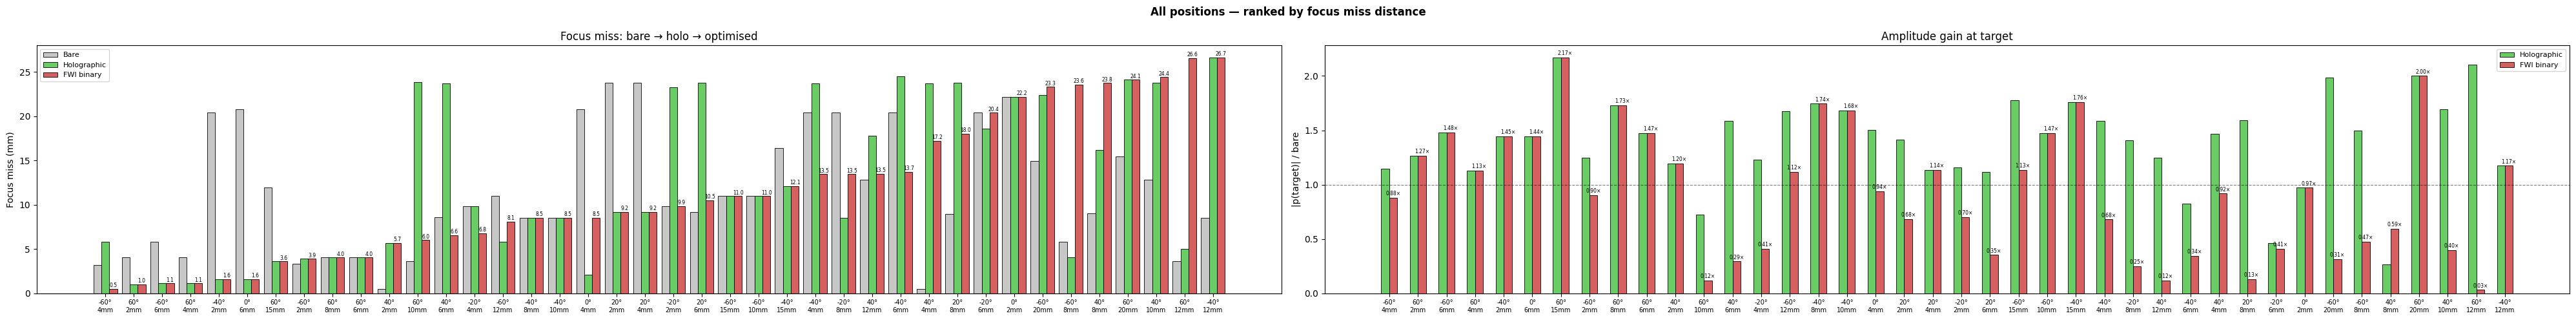

Fig 3 saved.

BEST — lowest focus miss distance:
  Position:     -60.0°  standoff=4.0mm
  Miss:  bare=3.16mm → holo=5.83mm → binary=0.50mm
  Axial:  -0.43mm   Lateral: +0.25mm
  Gain:  holo=1.148×   FWI-bin=0.878×
  Gel:   1517 px  (379 mm²)
  Time:  85.1 min total  (128s/position)


In [18]:
# =============================================================================
# CELL 24 v3 — Focus-Steering Gel Optimization (All Transducer Positions)
#
# Requires: sorted_results + shared variables from cell 23.
#
# OBJECTIVE REDESIGN (vs. cell 23 and earlier cell 24):
#
#   Previous:  maximize |E(target)|
#     Problem: focus can stay 4 mm away while amplitude at target stays high.
#              Adjoint source = point at target → field near-zero in gel region
#              (outside skull) → gradient ≈ 0 in gel → 1-2 steps then stalls.
#
#   New:       maximize J = Σ_x G(x)|E(x)|²
#              G(x) = exp(-|x-target|²/(2σ²)),  σ shrinks over phases
#     Why:     - Forces energy to concentrate near target, not just pass through
#              - Adjoint source = G(x)·conj(E_fwd(x))  (distributed)
#              - E_adj has large amplitude in gel region (where E_fwd is large)
#                → rich gradient throughout gel → optimizer can actually move focus
#     Metric:  actual focal-point miss distance (argmax of |E|² in brain),
#              tracked per iteration and used for early stopping and ranking
#
#   Sigma schedule (multi-scale):
#              Phase 1 (coarse): σ = SIGMA_START_MM  → pulls focus toward target
#              Phase 2          : σ = geometric mid
#              Phase 3 (fine)   : σ = SIGMA_END_MM   → tight positioning
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings
warnings.filterwarnings('ignore', message='A JAX array is being set as static')

import jax.numpy as jnp
from jwave import FourierSeries
from jwave.acoustics.time_harmonic import born_series

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    def _tqdm(x, **kw): return x

# ── Prerequisite check ────────────────────────────────────────────────────────
if 'sorted_results' not in dir() or len(sorted_results) == 0:
    raise RuntimeError(
        'Run cell 23 first to populate sorted_results and shared variables '
        '(domain, dx, Nx, Ny, cx, cy, C_GEL, C_WATER, RHO_GEL, OMEGA, '
        'half_angle, bowl_depth_px, bone, brain, head, medium_bare, '
        'run_born, make_medium, medium_from_rho, data_dir).')

# ── Parameters ────────────────────────────────────────────────────────────────
TOP_N           = None   # None = all; e.g. 15 to limit
N_ITER          = 90     # total Adam iterations per position (split across phases)
SIGMA_START_MM  = 8.0    # Gaussian σ in phase 1 (coarse focus pull, mm)
SIGMA_END_MM    = 2.5    # Gaussian σ in final phase (tight positioning, mm)
N_PHASES        = 3      # number of sigma steps
PATIENCE        = 10     # early stop (miss distance, final phase only)
MISS_TOL_MM     = 0.3    # counts as improvement if miss reduces by this much
LR              = 0.05   # Adam learning rate for rho_gel ∈ [0, 1]
BETA1, BETA2    = 0.9, 0.999
EPS_ADAM        = 1e-8
CONE_MULT       = 1.25   # expand gel cone by this factor beyond transducer half-angle
PLOT_MARGIN_MM  = 22.0   # extra right-margin on overview plots (mm)

# Pre-compute sigma for each phase (geometric spacing)
phase_sigmas = np.geomspace(SIGMA_START_MM, SIGMA_END_MM, N_PHASES)
iters_per_phase = [N_ITER // N_PHASES] * N_PHASES
iters_per_phase[-1] += N_ITER - sum(iters_per_phase)  # give remainder to last phase

print('=' * 72)
print(f'CELL 24 v3: focus-steering gel optimisation')
print(f'  Positions from cell 23: {len(sorted_results)}  '
      f'(running: {"all" if TOP_N is None else TOP_N})')
print(f'  Sigma schedule (mm): {[f"{s:.1f}" for s in phase_sigmas]}')
print(f'  Iters per phase:    {iters_per_phase}  (total={N_ITER})')
print(f'  Adam lr={LR}   patience={PATIENCE} (final phase, miss tol={MISS_TOL_MM}mm)')
print(f'  Objective: Gaussian-weighted field energy J=Σ G(x)|E(x)|²')
print(f'  Adjoint:   distributed G(x)·conj(E_fwd(x))  — rich gradient in gel')
print('=' * 72)

# ── Pre-compute spatial helpers ───────────────────────────────────────────────
_xi_g, _yi_g = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing='ij')
_dist_sq = (_xi_g - cx) ** 2 + (_yi_g - cy) ** 2    # squared pixel distance from target

def gauss_weight(sigma_mm):
    sigma_px = sigma_mm * 1e-3 / dx
    return np.exp(-0.5 * _dist_sq / sigma_px ** 2).astype(np.float32)

# ── Gel domain: full bowl-shaped water gap ─────────────────────────────────────
def gel_domain(pos):
    bx_ = pos['bx'];  by_ = pos['by']
    vec_x = (_xi_g - cx).astype(float)
    vec_y = (_yi_g - cy).astype(float)
    dist  = np.hypot(vec_x, vec_y)
    cos_ax = (vec_x * bx_ + vec_y * by_) / (dist + 1e-10)
    in_cone = cos_ax > np.cos(half_angle * CONE_MULT)
    outer_r   = pos['outer_r']
    so_px_loc = max(1, int(round(pos['so_mm'] * 1e-3 / dx)))
    in_range  = (dist >= float(outer_r) - 1.5) & \
                (dist <= float(outer_r + so_px_loc + bowl_depth_px + 4))
    return (in_range & in_cone & ~head).astype(np.float32)

# ── Holographic initialisation ────────────────────────────────────────────────
def holo_init(pos, gel_rgn, E_adj0_field):
    bx_ = pos['bx'];  by_ = pos['by']
    so_px_loc = max(1, int(round(pos['so_mm'] * 1e-3 / dx)))
    k_gel   = OMEGA / C_GEL;  k_water = OMEGA / C_WATER
    E_at_tx = np.array([E_adj0_field[xi, yi] for xi, yi in pos['tx_pixels']])
    phi_req = np.angle(E_at_tx)
    phi_req = phi_req.max() - phi_req
    t_holo_px = np.clip(
        np.round(phi_req / ((k_gel - k_water) * dx)).astype(int), 0, so_px_loc - 1)
    rho = np.zeros((Nx, Ny), dtype=np.float64)
    for ui, (xf, yf) in enumerate(pos['tx_pixels']):
        for t in range(1, so_px_loc + bowl_depth_px + 1):
            xi = int(round(xf - t * bx_));  yi = int(round(yf - t * by_))
            if not (0 <= xi < Nx and 0 <= yi < Ny): break
            if bone[xi, yi]: break
            if t <= t_holo_px[ui]:
                rho[xi, yi] = 1.0
    return rho * gel_rgn

# ── Miss distance helpers ─────────────────────────────────────────────────────
def find_focus(E_field):
    """Return (ix, iy) of |E|² peak inside brain region."""
    inside = np.abs(E_field) ** 2 * brain.astype(float)
    return np.unravel_index(np.argmax(inside), inside.shape)

def miss_decompose(peak_ix, peak_iy, pos):
    """Euclidean, axial (along beam), lateral (perpendicular) miss in mm."""
    ex = (peak_ix - cx) * dx * 1e3
    ey = (peak_iy - cy) * dx * 1e3
    euc  = np.hypot(ex, ey)
    axl  = ex * pos['bx'] + ey * pos['by']
    lat  = ex * pos['px'] + ey * pos['py']
    return euc, axl, lat

# ── Shared adjoint for holographic design ────────────────────────────────────
if 'E_adj0' not in dir():
    print('Computing shared point-adjoint from target (for holo init)...')
    src_tgt = np.zeros((Nx, Ny), dtype=complex)
    src_tgt[cx, cy] = 1.0 + 0j
    E_adj0 = run_born(medium_bare, src_tgt, label='adjoint')
    print()

# ── Main optimisation loop ─────────────────────────────────────────────────────
positions_to_run = sorted_results[:TOP_N] if TOP_N else sorted_results
n_pos = len(positions_to_run)
opt_results = []
t_wall0 = time.time()

outer_bar = _tqdm(enumerate(positions_to_run), total=n_pos,
                  desc='Positions', unit='pos')

for idx, r23 in outer_bar:
    pos        = r23['pos']
    src_flat   = r23['src_flat']
    p_bare_tgt = r23['p_bare_tgt']
    ang        = r23['ang_deg']
    so_mm      = r23['so_mm']

    outer_bar.set_postfix_str(f'{ang:.0f}°@{so_mm:.0f}mm')
    print(f'\n── [{idx+1}/{n_pos}]  {ang:.1f}°  @  {so_mm:.1f}mm  '
          f'(cell-23: gain={r23["gain_fwi"]:.3f}×, '
          f'miss_bare={r23.get("miss_bare",float("nan")):.1f}mm) ──')

    # ── Step 1: Gel domain ──────────────────────────────────────────────────
    print('  [1/4] Gel domain ...')
    gel_rgn = gel_domain(pos)
    n_vox   = int(gel_rgn.sum())
    print(f'        {n_vox} voxels  ({n_vox*(dx*1e3)**2:.1f} mm²)')

    # ── Step 2: Holographic initialisation ─────────────────────────────────
    print('  [2/4] Holographic init ...')
    rho_gel   = holo_init(pos, gel_rgn, E_adj0)
    E_holo    = run_born(medium_from_rho(rho_gel, gel_rgn), src_flat)
    gain_holo = float(np.abs(E_holo[cx, cy])) / max(p_bare_tgt, 1e-30)
    pk_holo   = find_focus(E_holo)
    miss_holo,_,_ = miss_decompose(pk_holo[0], pk_holo[1], pos)
    print(f'        gain={gain_holo:.3f}×   miss={miss_holo:.2f}mm')

    # ── Step 3: Gaussian-adjoint FWI (multi-scale σ) ───────────────────────
    print(f'  [3/4] Multi-scale Adam FWI  '
          f'(σ: {SIGMA_START_MM:.1f}→{SIGMA_END_MM:.1f}mm, '
          f'{N_ITER} iters total) ...')

    m_a = np.zeros_like(rho_gel)
    v_a = np.zeros_like(rho_gel)
    best_miss   = miss_holo
    best_rho    = rho_gel.copy()
    hist_miss   = [miss_holo]
    hist_gain   = [gain_holo]
    hist_J      = []
    global_it   = 0
    no_improv   = 0

    all_iters_bar = _tqdm(total=N_ITER, desc='    FWI', unit='it',
                          leave=False, dynamic_ncols=True)

    for phase_idx, (sigma_mm, n_phase) in enumerate(zip(phase_sigmas, iters_per_phase)):
        G = gauss_weight(sigma_mm)           # Gaussian weight for this phase
        is_last_phase = (phase_idx == N_PHASES - 1)

        # Reset Adam momentum at the start of each phase so optimizer
        # can re-explore with the new, tighter objective
        m_a[:] = 0.0;  v_a[:] = 0.0
        no_improv = 0     # reset stall counter for this phase
        phase_it = 0

        for _ in range(n_phase):
            global_it  += 1
            phase_it   += 1

            med   = medium_from_rho(rho_gel, gel_rgn)
            t0    = time.time()
            E_fwd = run_born(med, src_flat)

            # Gaussian-weighted objective J = Σ G(x)|E(x)|²
            J_val = float(np.sum(G * np.abs(E_fwd) ** 2))
            hist_J.append(J_val)

            # Amplitude gain and miss distance (for tracking, not optimisation)
            gain_it = float(np.abs(E_fwd[cx, cy])) / max(p_bare_tgt, 1e-30)
            pk_it   = find_focus(E_fwd)
            miss_it,_,_ = miss_decompose(pk_it[0], pk_it[1], pos)
            hist_miss.append(miss_it)
            hist_gain.append(gain_it)

            # Update best based on miss distance (primary metric)
            if miss_it < best_miss - MISS_TOL_MM:
                best_miss = miss_it;  best_rho = rho_gel.copy()
                no_improv = 0;        marker = ' ✓'
            else:
                no_improv += 1;       marker = ''

            all_iters_bar.update(1)
            all_iters_bar.set_postfix(
                phase=f'{phase_idx+1}/{N_PHASES}',
                sigma=f'{sigma_mm:.1f}mm',
                miss=f'{miss_it:.2f}mm',
                best=f'{best_miss:.2f}mm',
                stall=f'{no_improv}')

            if global_it % 10 == 1:
                print(f'        σ={sigma_mm:.1f}mm  '
                      f'iter {global_it:3d}/{N_ITER}  '
                      f'miss={miss_it:.2f}mm  gain={gain_it:.3f}×  '
                      f'stall={no_improv}  ({time.time()-t0:.1f}s){marker}')

            # Early stop applies in every phase (stall counter resets at each phase start)
            if no_improv >= PATIENCE:
                print(f'        → early stop at iter {global_it}  '
                      f'(best miss={best_miss:.2f}mm)')
                break

            # ── Distributed adjoint source: G(x)·conj(E_fwd(x)) ──────────
            # This gives non-zero gradient throughout gel region,
            # unlike a point source which has near-zero adjoint field in gel.
            src_adj = (G * np.conj(E_fwd)).astype(complex)
            E_adj   = run_born(med, src_adj)

            # Correct gradient: Re[conj(E_adj) × E_fwd]  (fixed from cell 23)
            grad = np.real(np.conj(E_adj) * E_fwd) * gel_rgn

            # Adam update
            m_a   = BETA1 * m_a + (1 - BETA1) * grad
            v_a   = BETA2 * v_a + (1 - BETA2) * grad ** 2
            m_hat = m_a / (1 - BETA1 ** global_it)
            v_hat = v_a / (1 - BETA2 ** global_it)
            rho_gel = np.clip(
                rho_gel + LR * m_hat / (np.sqrt(v_hat) + EPS_ADAM), 0.0, 1.0)

    all_iters_bar.close()

    # ── Step 4: Evaluate and binarise ───────────────────────────────────────
    print('  [4/4] Evaluating + binarising ...')
    E_cont    = run_born(medium_from_rho(best_rho,                  gel_rgn), src_flat)
    rho_bin   = (best_rho > 0.5).astype(np.float64)
    E_bin     = run_born(medium_from_rho(rho_bin,                   gel_rgn), src_flat)

    gain_cont  = float(np.abs(E_cont[cx, cy])) / max(p_bare_tgt, 1e-30)
    gain_bin   = float(np.abs(E_bin[cx, cy]))  / max(p_bare_tgt, 1e-30)
    pk_cont    = find_focus(E_cont);  pk_bin = find_focus(E_bin)
    euc_c,ax_c,la_c = miss_decompose(pk_cont[0], pk_cont[1], pos)
    euc_b,ax_b,la_b = miss_decompose(pk_bin[0],  pk_bin[1],  pos)

    print(f'        continuous:  miss={euc_c:.2f}mm  gain={gain_cont:.3f}×')
    print(f'        binary:      miss={euc_b:.2f}mm  gain={gain_bin:.3f}×')

    opt_results.append(dict(
        ang_deg=ang, so_mm=so_mm, pos=pos,
        src_flat=src_flat, p_bare_tgt=p_bare_tgt,
        gain_holo=gain_holo, miss_holo=miss_holo,
        E_cont=E_cont, gain_cont=gain_cont, miss_cont=euc_c,
        ax_cont=ax_c, lat_cont=la_c,
        E_bin=E_bin,   gain_bin=gain_bin,  miss_bin=euc_b,
        ax_bin=ax_b, lat_bin=la_b,
        peak_bin=pk_bin,
        best_rho=best_rho, rho_bin=rho_bin, gel_rgn=gel_rgn,
        hist_miss=hist_miss, hist_gain=hist_gain,
        E_bare=r23.get('E_bare'),
        nf_ix=r23.get('nf_ix'), nf_iy=r23.get('nf_iy'),
        miss_bare=r23.get('miss_bare', float('nan')),
    ))

outer_bar.close()
t_total = time.time() - t_wall0
print(f'\nAll done: {len(opt_results)} positions in {t_total/60:.1f} min '
      f'({t_total/max(len(opt_results),1):.0f}s/pos)')

# ── Summary table ─────────────────────────────────────────────────────────────
opt_sorted = sorted(opt_results, key=lambda r: r['miss_bin'])   # sort by miss ↑
print()
print('=' * 80)
print('RESULTS (sorted by binary-gel miss distance ↑, gain in brackets):')
print(f'  {"rank":>4}  {"angle":>7}  {"so":>6}  '
      f'{"miss_bare":>10}  {"miss_holo":>10}  {"miss_bin":>9}  '
      f'{"gain_bin":>9}  {"axial":>8}  {"lat":>7}')
print('  ' + '-' * 78)
for rank, r in enumerate(opt_sorted):
    marker = '  *** BEST' if rank == 0 else ''
    print(f'  {rank+1:4d}  {r["ang_deg"]:6.1f}°  {r["so_mm"]:5.1f}mm  '
          f'{r["miss_bare"]:9.2f}mm  {r["miss_holo"]:9.2f}mm  '
          f'{r["miss_bin"]:8.2f}mm  {r["gain_bin"]:8.3f}×  '
          f'{r["ax_bin"]:+7.2f}mm  {r["lat_bin"]:+6.2f}mm{marker}')

# ── Figure 1: Miss distance convergence for all positions ────────────────────
n_cols = min(5, n_pos)
n_rows = (n_pos + n_cols - 1) // n_cols
fig1, axes1 = plt.subplots(n_rows, n_cols,
                            figsize=(4*n_cols, 3*n_rows), squeeze=False)
fig1.suptitle('Focus miss distance over FWI iterations — all positions\n'
              '(horizontal lines: bare miss / holo miss / final binary miss)',
              fontsize=11, fontweight='bold')
# Mark phase boundaries
phase_boundaries = [sum(iters_per_phase[:k]) for k in range(1, N_PHASES)]

for i, r in enumerate(opt_results):
    ax = axes1[i // n_cols][i % n_cols]
    ax.plot(r['hist_miss'], 'b-', lw=1.2, label='miss(mm)')
    # Sigma phase boundaries
    for pb in phase_boundaries:
        ax.axvline(pb, color='gray', ls=':', lw=0.8, alpha=0.6)
    # Reference lines
    ax.axhline(r['miss_bare'], color='gray', ls='--', lw=0.8,
               label=f'bare {r["miss_bare"]:.1f}mm')
    ax.axhline(r['miss_holo'], color='g',    ls='--', lw=0.9,
               label=f'holo {r["miss_holo"]:.1f}mm')
    ax.axhline(r['miss_bin'],  color='r',    ls=':',  lw=1.2,
               label=f'bin {r["miss_bin"]:.1f}mm')
    ax.set_title(f'{r["ang_deg"]:.0f}°@{r["so_mm"]:.0f}mm', fontsize=8)
    ax.legend(fontsize=5, loc='upper right')
    ax.set(xlabel='iter', ylabel='miss (mm)')
    ax.tick_params(labelsize=6)
    ax.set_ylim(bottom=0)

for i in range(n_pos, n_rows * n_cols):
    axes1[i // n_cols][i % n_cols].set_visible(False)

# Add sigma labels at top of first subplot
if opt_results:
    ax0 = axes1[0][0]
    prev = 0
    for k, (sigma_mm, n_ph) in enumerate(zip(phase_sigmas, iters_per_phase)):
        mid = prev + n_ph / 2
        ax0.text(mid, ax0.get_ylim()[1] * 0.97,
                 f'σ={sigma_mm:.1f}',
                 ha='center', va='top', fontsize=6, color='gray')
        prev += n_ph

plt.tight_layout()
plt.savefig(data_dir / 'opt_convergence_miss.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fig 1 saved.')

# ── Figure 2: Top-3 detail panels ─────────────────────────────────────────────
N_TOP    = min(3, len(opt_sorted))
fig2     = plt.figure(figsize=(26, 8 * N_TOP))
outer_gs = gridspec.GridSpec(N_TOP, 1, figure=fig2, hspace=0.52)

ext_base = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
x_right  = Nx*dx*1e3 + PLOT_MARGIN_MM
kw0 = dict(origin='lower', aspect='equal', extent=ext_base, interpolation='nearest')

def log_norm(p):
    return np.log10(np.abs(p) / (np.abs(p).max() + 1e-30) + 1e-3)

def lat_profile(p_abs, ix, iy, px_, py_, n=120):
    ofs = np.arange(-n//2, n//2)
    vs  = [p_abs[int(round(ix+s*px_)), int(round(iy+s*py_))]
           if 0 <= int(round(ix+s*px_)) < Nx and 0 <= int(round(iy+s*py_)) < Ny else 0.0
           for s in ofs]
    return np.array(vs), ofs * dx * 1e3

def fwhm_mm(v, ofs):
    hm = v.max() / 2.0
    ab = np.where(v >= hm)[0]
    return abs(ofs[ab[-1]] - ofs[ab[0]]) if len(ab) > 1 else 0.0

def set_margin(ax):
    ax.set_xlim(ext_base[0] - 5, x_right)
    ax.set_ylim(ext_base[2], ext_base[3])

for row, r in enumerate(opt_sorted[:N_TOP]):
    gs_row = gridspec.GridSpecFromSubplotSpec(
        1, 5, subplot_spec=outer_gs[row], wspace=0.32)
    pos  = r['pos']

    _e   = r.get('E_bare')
    E_bare = _e if _e is not None else np.zeros((Nx, Ny), dtype=complex)
    E_bin  = r['E_bin']
    rho_bin = r['rho_bin']
    gel_rgn = r['gel_rgn']
    pk     = r['peak_bin']
    euc    = r['miss_bin'];  axl = r['ax_bin'];  lat = r['lat_bin']

    row_title = (f'#{row+1}: {r["ang_deg"]:.0f}°@{r["so_mm"]:.0f}mm  |  '
                 f'miss: bare={r["miss_bare"]:.1f}→holo={r["miss_holo"]:.1f}'
                 f'→binary={euc:.1f}mm  |  gain={r["gain_bin"]:.3f}×')

    # A: Bare field
    ax_a = fig2.add_subplot(gs_row[0])
    ax_a.imshow(log_norm(E_bare).T, cmap='plasma', vmin=-3, vmax=0, **kw0)
    ax_a.contour(bone.T, levels=[0.5], extent=ext_base, origin='lower',
                 colors='white', linewidths=0.7, alpha=0.6)
    ax_a.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=12, mew=2, label='Target')
    nf_ix = r.get('nf_ix');  nf_iy = r.get('nf_iy')
    if nf_ix is not None:
        ax_a.plot(nf_ix*dx*1e3, nf_iy*dx*1e3, 'y^', ms=8,
                  label=f'Nat.focus miss={r["miss_bare"]:.1f}mm')
    for xi, yi in pos['tx_pixels']:
        ax_a.plot(xi*dx*1e3, yi*dx*1e3, '.', color='lime', ms=1.5)
    ax_a.legend(fontsize=6, loc='lower right')
    set_margin(ax_a)
    ax_a.set(xlabel='x (mm)', ylabel='y (mm)',
             title=f'Bare  {r["ang_deg"]:.0f}°@{r["so_mm"]:.0f}mm\n'
                   f'|p(tgt)|={r["p_bare_tgt"]:.3e}')

    # B: Optimised binary gel field
    ax_b = fig2.add_subplot(gs_row[1])
    ax_b.imshow(log_norm(E_bin).T, cmap='plasma', vmin=-3, vmax=0, **kw0)
    ax_b.contour(bone.T, levels=[0.5], extent=ext_base, origin='lower',
                 colors='white', linewidths=0.7, alpha=0.6)
    ax_b.plot(cx*dx*1e3, cy*dx*1e3, 'c+', ms=12, mew=2, label='Target')
    ax_b.plot(pk[0]*dx*1e3, pk[1]*dx*1e3, 'y^', ms=8,
              label=f'Focus  miss={euc:.2f}mm')
    ax_b.imshow(np.where((gel_rgn * rho_bin) > 0.5, 0.8, np.nan).T,
                cmap='Blues', alpha=0.45, vmin=0, vmax=1, **kw0)
    ax_b.legend(fontsize=6, loc='lower right')
    set_margin(ax_b)
    ax_b.set(xlabel='x (mm)', ylabel='y (mm)',
             title=f'Optimised binary gel\n'
                   f'miss={euc:.2f}mm  gain={r["gain_bin"]:.3f}×')

    # C: Zoomed focus with miss decomposition arrows
    zr  = int(round(30e-3 / dx))
    zx0 = max(0, cx-zr);  zx1 = min(Nx, cx+zr)
    zy0 = max(0, cy-zr);  zy1 = min(Ny, cy+zr)
    ez  = [zx0*dx*1e3, zx1*dx*1e3, zy0*dx*1e3, zy1*dx*1e3]
    kwz = dict(origin='lower', aspect='equal', extent=ez, interpolation='bilinear')
    pz  = np.abs(E_bin[zx0:zx1, zy0:zy1])
    ax_c = fig2.add_subplot(gs_row[2])
    ax_c.imshow((pz/(pz.max()+1e-30)).T, cmap='hot', vmin=0, vmax=1, **kwz)
    ax_c.contour(bone[zx0:zx1,zy0:zy1].T, levels=[0.5], extent=ez,
                 origin='lower', colors='white', linewidths=0.8, alpha=0.8)

    tx_mm = cx*dx*1e3;  ty_mm = cy*dx*1e3
    px_mm = pk[0]*dx*1e3;  py_mm = pk[1]*dx*1e3
    ax_c.plot(tx_mm, ty_mm, 'c+', ms=14, mew=2, label='Target')
    ax_c.plot(px_mm, py_mm, 'y^', ms=9,  label='Focus peak')
    # Total miss vector
    ax_c.annotate('', xy=(px_mm, py_mm), xytext=(tx_mm, ty_mm),
                  arrowprops=dict(arrowstyle='->', color='yellow', lw=1.8, ls='--'))
    # Axial component
    ax_mm = tx_mm + axl * pos['bx'];  ay_mm = ty_mm + axl * pos['by']
    ax_c.annotate('', xy=(ax_mm, ay_mm), xytext=(tx_mm, ty_mm),
                  arrowprops=dict(arrowstyle='->', color='cyan', lw=1.4))
    # Lateral component
    ax_c.annotate('', xy=(px_mm, py_mm), xytext=(ax_mm, ay_mm),
                  arrowprops=dict(arrowstyle='->', color='magenta', lw=1.4))
    ax_c.legend(fontsize=6, loc='upper right')
    ax_c.text(0.03, 0.04,
              f'Euclidean:  {euc:.2f} mm\n'
              f'Axial (↑):  {axl:+.2f} mm\n'
              f'Lateral (→): {lat:+.2f} mm',
              transform=ax_c.transAxes, fontsize=7, color='white',
              verticalalignment='bottom',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.55))

    lv_b, lo = lat_profile(np.abs(E_bare), cx, cy, pos['px'], pos['py'])
    lv_f, _  = lat_profile(np.abs(E_bin),  cx, cy, pos['px'], pos['py'])
    fw_b = fwhm_mm(lv_b, lo);  fw_f = fwhm_mm(lv_f, lo)
    ax_c.set(xlabel='x (mm)', ylabel='y (mm)',
             title=f'Zoomed focus\nFWHM: {fw_b:.1f}→{fw_f:.1f}mm')

    # D: Gel geometry
    gel_vis = np.where((gel_rgn * rho_bin) > 0.5, C_GEL, np.nan).astype(np.float32)
    ax_d = fig2.add_subplot(gs_row[3])
    ax_d.imshow(c_map.T, cmap='gray', vmin=1400, vmax=3200, alpha=0.28, **kw0)
    im_g = ax_d.imshow(gel_vis.T, cmap='Blues_r', alpha=0.8,
                       vmin=C_GEL-50, vmax=C_WATER+50, **kw0)
    ax_d.contour(bone.T, levels=[0.5], extent=ext_base, origin='lower',
                 colors='red', linewidths=0.8, alpha=0.5)
    ax_d.plot(cx*dx*1e3, cy*dx*1e3, 'r*', ms=10, label='Target')
    ax_d.plot(pos['tip_cx']*dx*1e3, pos['tip_cy']*dx*1e3, 'bv', ms=9, label='Bowl tip')
    plt.colorbar(im_g, ax=ax_d, label='c (m/s)', shrink=0.8)
    set_margin(ax_d)
    gel_px = int((gel_rgn * rho_bin).sum())
    ax_d.legend(fontsize=7)
    ax_d.set(xlabel='x (mm)', ylabel='y (mm)',
             title=f'Binary gel: {gel_px} px ({gel_px*(dx*1e3)**2:.0f} mm²)')

    # E: 4-bar gain + miss comparison
    ax_e = fig2.add_subplot(gs_row[4])
    lbls = ['Bare', 'Holo', 'FWI\nbinary']
    gvs  = [1.0,       r['gain_holo'], r['gain_bin']]
    mvs  = [r['miss_bare'], r['miss_holo'], euc]
    cols = ['#4878d0', '#6acc65', '#d65f5f']

    ax_e2 = ax_e.twinx()
    bars = ax_e.bar(lbls, gvs, color=cols, edgecolor='k', lw=0.8, alpha=0.8)
    ax_e2.plot(lbls, mvs, 'k^--', ms=7, lw=1.5, label='Miss (mm)', zorder=5)
    ax_e2.set_ylabel('Focus miss (mm)', color='k')
    ax_e2.tick_params(labelsize=8)

    for bar, v in zip(bars, gvs):
        ax_e.text(bar.get_x()+bar.get_width()/2, v+0.01,
                  f'{v:.3f}×', ha='center', va='bottom', fontsize=8)
    for xi_b, mv in enumerate(mvs):
        ax_e2.text(xi_b, mv + max(mvs)*0.04, f'{mv:.2f}mm',
                   ha='center', va='bottom', fontsize=7, color='k')

    ax_e.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax_e.set_ylabel('|p(target)| / bare')
    ax_e.set_title(row_title, fontsize=7.5)
    ax_e.set_ylim(0, max(gvs) * 1.28)
    ax_e2.set_ylim(0, max(mvs) * 1.4)
    ax_e.legend(handles=[bars[i] for i in range(len(lbls))],
                labels=[f'{l}\n{v:.2f}×' for l, v in zip(lbls, gvs)],
                fontsize=6, loc='upper left')
    ax_e2.legend(fontsize=7, loc='upper right')

plt.savefig(data_dir / 'top3_focus_steered.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 2 saved.')

# ── Figure 3: All-position ranking by miss distance ───────────────────────────
n_all   = len(opt_sorted)
fig3, (ax_m, ax_g) = plt.subplots(1, 2, figsize=(max(14, n_all), 5))
fig3.suptitle('All positions — ranked by focus miss distance',
              fontsize=12, fontweight='bold')

xlabels = [f'{r["ang_deg"]:.0f}°\n{r["so_mm"]:.0f}mm' for r in opt_sorted]
x = np.arange(n_all);  w = 0.28

# Miss distance panel
miss_bare_v = [r['miss_bare'] for r in opt_sorted]
miss_holo_v = [r['miss_holo'] for r in opt_sorted]
miss_bin_v  = [r['miss_bin']  for r in opt_sorted]

ax_m.bar(x - w, miss_bare_v, w, color='#c7c7c7', edgecolor='k', lw=0.6, label='Bare')
ax_m.bar(x,     miss_holo_v, w, color='#6acc65', edgecolor='k', lw=0.6, label='Holographic')
ax_m.bar(x + w, miss_bin_v,  w, color='#d65f5f', edgecolor='k', lw=0.6, label='FWI binary')
ax_m.set_xticks(x);  ax_m.set_xticklabels(xlabels, fontsize=7)
ax_m.set(ylabel='Focus miss (mm)', title='Focus miss: bare → holo → optimised')
ax_m.axhline(0, color='k', lw=0.8)
ax_m.legend(fontsize=8)
for i, v in enumerate(miss_bin_v):
    ax_m.text(i+w, v+0.05, f'{v:.1f}', ha='center', va='bottom', fontsize=5.5)

# Gain panel
gain_holo_v = [r['gain_holo'] for r in opt_sorted]
gain_bin_v  = [r['gain_bin']  for r in opt_sorted]
ax_g.bar(x - w/2, gain_holo_v, w, color='#6acc65', edgecolor='k', lw=0.6, label='Holographic')
ax_g.bar(x + w/2, gain_bin_v,  w, color='#d65f5f', edgecolor='k', lw=0.6, label='FWI binary')
ax_g.set_xticks(x);  ax_g.set_xticklabels(xlabels, fontsize=7)
ax_g.set(ylabel='|p(target)| / bare', title='Amplitude gain at target')
ax_g.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
ax_g.legend(fontsize=8)
for i, v in enumerate(gain_bin_v):
    ax_g.text(i+w/2, v+0.01, f'{v:.2f}×', ha='center', va='bottom', fontsize=5.5)

plt.tight_layout()
plt.savefig(data_dir / 'all_positions_miss_rank.png', dpi=130, bbox_inches='tight')
plt.show()
print('Fig 3 saved.')

# ── Final summary ──────────────────────────────────────────────────────────────
best = opt_sorted[0]
print()
print('=' * 72)
print('BEST — lowest focus miss distance:')
print(f'  Position:     {best["ang_deg"]:.1f}°  standoff={best["so_mm"]:.1f}mm')
print(f'  Miss:  bare={best["miss_bare"]:.2f}mm → holo={best["miss_holo"]:.2f}mm '
      f'→ binary={best["miss_bin"]:.2f}mm')
print(f'  Axial:  {best["ax_bin"]:+.2f}mm   Lateral: {best["lat_bin"]:+.2f}mm')
print(f'  Gain:  holo={best["gain_holo"]:.3f}×   FWI-bin={best["gain_bin"]:.3f}×')
print(f'  Gel:   {int((best["gel_rgn"]*best["rho_bin"]).sum())} px  '
      f'({int((best["gel_rgn"]*best["rho_bin"]).sum())*(dx*1e3)**2:.0f} mm²)')
print(f'  Time:  {t_total/60:.1f} min total  '
      f'({t_total/max(len(opt_results),1):.0f}s/position)')
print('=' * 72)


### 25_best_gel_analysis
Full stats, gel geometry, pressure profiles, and design export for the top result from cell 24.

In [ ]:
# =============================================================================
# CELL 25 — Best Gel: Full Analysis, Geometry Export & Manufacturing Stats
#
# Requires: opt_sorted + shared variables from cells 23 and 24.
# Produces:
#   Fig A : sound-speed map + gel overlay + thickness-profile-along-arc
#   Fig B : axial & lateral pressure profiles (bare vs binary gel)
#   Exports: best_gel_binary.npy, best_gel_rho.npy,
#            best_gel_thickness_profile.npy
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label as ndi_label

best = opt_sorted[0]
pos  = best["pos"]

_e      = best.get("E_bare")
E_bare  = _e if _e is not None else np.zeros((Nx, Ny), dtype=complex)
E_bin   = best["E_bin"]
rho_bin = best["rho_bin"]
gel_rgn = best["gel_rgn"]
pk      = best["peak_bin"]
euc     = best["miss_bin"]
axl     = best["ax_bin"]
lat_    = best["lat_bin"]

gel_mask = (gel_rgn * rho_bin) > 0.5   # boolean binary gel

bx_ = pos["bx"];  by_ = pos["by"]
px_ = pos["px"];  py_ = pos["py"]

# ── helpers ───────────────────────────────────────────────────────────────────
def log_norm(p):
    return np.log10(np.abs(p) / (np.abs(p).max() + 1e-30) + 1e-3)

def fwhm_along(p_abs, start_ix, start_iy, ux, uy, n=200):
    ofs  = np.arange(-n//2, n//2)
    xs   = np.round(start_ix + ofs * ux).astype(int)
    ys   = np.round(start_iy + ofs * uy).astype(int)
    ok   = (xs >= 0) & (xs < Nx) & (ys >= 0) & (ys < Ny)
    vals = np.zeros(len(ofs))
    vals[ok] = p_abs[xs[ok], ys[ok]]
    hm   = vals.max() / 2.0
    ab   = np.where(vals >= hm)[0]
    fw   = abs(ofs[ab[-1]] - ofs[ab[0]]) * dx * 1e3 if len(ab) > 1 else 0.0
    return fw, vals, ofs * dx * 1e3

def set_margin(ax):
    ax.set_xlim(-5, Nx*dx*1e3 + PLOT_MARGIN_MM)
    ax.set_ylim(0, Ny*dx*1e3)

ext_base = [0, Nx*dx*1e3, 0, Ny*dx*1e3]
kw0 = dict(origin="lower", aspect="equal", extent=ext_base, interpolation="nearest")

pabs_bare = np.abs(E_bare)
pabs_bin  = np.abs(E_bin)

# profiles: bare through target, gel through actual peak
fw_ax_bare,  pax_bare,  ofs_ax  = fwhm_along(pabs_bare, cx,    cy,    bx_, by_)
fw_ax_bin,   pax_bin,   _       = fwhm_along(pabs_bin,  pk[0], pk[1], bx_, by_)
fw_lat_bare, plat_bare, ofs_lat = fwhm_along(pabs_bare, cx,    cy,    px_, py_)
fw_lat_bin,  plat_bin,  _       = fwhm_along(pabs_bin,  pk[0], pk[1], px_, py_)

# intensity gain at target
p_bare_tgt   = pabs_bare[cx, cy]
p_bin_tgt    = pabs_bin[cx, cy]
int_gain_bin = (p_bin_tgt / (p_bare_tgt + 1e-30)) ** 2

# peak-sidelobe ratio (brain region, excluding 3 mm around focus)
_xi_g2, _yi_g2 = np.meshgrid(np.arange(Nx), np.arange(Ny), indexing="ij")
dist_from_pk   = np.hypot(_xi_g2 - pk[0], _yi_g2 - pk[1])
brain_no_focus = head & (dist_from_pk > int(round(3e-3 / dx)))
pslr    = pabs_bin[brain_no_focus].max() / (pabs_bin[pk[0], pk[1]] + 1e-30)
pslr_db = 20 * np.log10(pslr + 1e-30)

# gel stats
gel_px  = int(gel_mask.sum())
gel_mm2 = gel_px * (dx * 1e3) ** 2
_, n_comp = ndi_label(gel_mask)

# gel thickness along arc (walk radially from each element toward brain center)
tx_pixels_arr  = np.array(pos["tx_pixels"])
cx_f, cy_f     = float(cx), float(cy)
arc_angles_deg = np.array([
    np.degrees(np.arctan2(float(yi) - pos["tip_cy"], float(xi) - pos["tip_cx"]))
    for xi, yi in tx_pixels_arr
])
gel_thick_mm = np.zeros(len(tx_pixels_arr))
for k, (xi, yi) in enumerate(tx_pixels_arr):
    dx_v = xi - cx_f;  dy_v = yi - cy_f
    dist_ = np.hypot(dx_v, dy_v)
    if dist_ < 1e-6:
        continue
    ux_ = dx_v / dist_;  uy_ = dy_v / dist_
    t_vals = np.arange(0, int(dist_) + 2)
    rxs = np.round(xi - t_vals * ux_).astype(int)
    rys = np.round(yi - t_vals * uy_).astype(int)
    ok_ = (rxs >= 0) & (rxs < Nx) & (rys >= 0) & (rys < Ny)
    in_gel = np.zeros(len(t_vals), bool)
    in_gel[ok_] = gel_mask[rxs[ok_], rys[ok_]]
    gel_thick_mm[k] = in_gel.sum() * dx * 1e3

thick_nz   = gel_thick_mm[gel_thick_mm > 0]
mean_thick = gel_thick_mm.mean()
max_thick  = gel_thick_mm.max()
min_thick  = thick_nz.min() if len(thick_nz) else 0.0

# ── 1. STATS TABLE ────────────────────────────────────────────────────────────
print()
print("=" * 72)
print(f"BEST POSITION: {best['ang_deg']:.1f}deg  standoff={best['so_mm']:.1f}mm")
print("=" * 72)
print()
print("  -- Focus accuracy --------------------------------------------------")
print(f"  Miss (euclidean):   bare={best['miss_bare']:.2f}mm  ->  binary gel={euc:.2f}mm")
print(f"  Miss (axial):       {axl:+.2f}mm  (+ = away from skull)")
print(f"  Miss (lateral):     {lat_:+.2f}mm")
print()
print("  -- Amplitude / Intensity -------------------------------------------")
print(f"  Amplitude gain:     holo={best['gain_holo']:.3f}x   FWI-binary={best['gain_bin']:.3f}x")
print(f"  Intensity gain:     {int_gain_bin:.3f}x  ({10*np.log10(int_gain_bin+1e-30):.1f} dB)")
print(f"  Peak sidelobe:      {pslr:.4f}  ({pslr_db:.1f} dBc)")
print()
print("  -- Focus sharpness (FWHM) ------------------------------------------")
print(f"  Axial FWHM:   bare={fw_ax_bare:.2f}mm   gel={fw_ax_bin:.2f}mm")
print(f"  Lateral FWHM: bare={fw_lat_bare:.2f}mm   gel={fw_lat_bin:.2f}mm")
print()
print("  -- Gel geometry ----------------------------------------------------")
print(f"  Gel area:       {gel_px} px  ({gel_mm2:.1f} mm^2)")
print(f"  Connected comps: {n_comp}")
print(f"  Arc thickness:  min={min_thick:.2f}mm  mean={mean_thick:.2f}mm  max={max_thick:.2f}mm")
print()

# ── 2. FIGURE A: Gel geometry (3 panels) ─────────────────────────────────────
sort_idx = np.argsort(arc_angles_deg)
ang_s    = arc_angles_deg[sort_idx]
thk_s    = gel_thick_mm[sort_idx]

fig_a, axes_a = plt.subplots(1, 3, figsize=(22, 8))
fig_a.suptitle(
    f"Best gel geometry  {best['ang_deg']:.1f}deg @ {best['so_mm']:.1f}mm standoff\n"
    f"Miss: bare={best['miss_bare']:.2f}mm -> binary={euc:.2f}mm  |  "
    f"Gain={best['gain_bin']:.3f}x  |  Area={gel_mm2:.0f} mm^2",
    fontsize=12, fontweight="bold")

# A1: sound-speed map + gel overlay
ax_a1 = axes_a[0]
im_c = ax_a1.imshow(c_map.T, cmap="gray", vmin=1400, vmax=3200, **kw0)
plt.colorbar(im_c, ax=ax_a1, label="c (m/s)", shrink=0.8)
gel_vis = np.where(gel_mask, float(C_GEL), np.nan).astype(np.float32)
ax_a1.imshow(gel_vis.T, cmap="Blues_r", alpha=0.85,
             vmin=C_GEL-50, vmax=C_WATER+50, **kw0)
ax_a1.contour(bone.T, levels=[0.5], extent=ext_base, origin="lower",
              colors="red", linewidths=1.0, alpha=0.7)
ax_a1.plot(cx*dx*1e3, cy*dx*1e3, "r*", ms=14, label="Target", zorder=5)
ax_a1.plot(pos["tip_cx"]*dx*1e3, pos["tip_cy"]*dx*1e3, "bv", ms=10, label="Bowl tip")
for xi, yi in pos["tx_pixels"]:
    ax_a1.plot(xi*dx*1e3, yi*dx*1e3, ".", color="lime", ms=1.5)
ax_a1.legend(fontsize=8, loc="lower right")
set_margin(ax_a1)
ax_a1.set(xlabel="x (mm)", ylabel="y (mm)",
          title="Sound-speed map + binary gel (blue)")

# A2: pressure field + gel contour
ax_a2 = axes_a[1]
im_p = ax_a2.imshow(log_norm(E_bin).T, cmap="plasma", vmin=-3, vmax=0, **kw0)
plt.colorbar(im_p, ax=ax_a2, label="log10(|p|/pmax)", shrink=0.8)
ax_a2.contour(bone.T, levels=[0.5], extent=ext_base, origin="lower",
              colors="white", linewidths=0.8, alpha=0.6)
ax_a2.contour(gel_mask.T.astype(float), levels=[0.5], extent=ext_base,
              origin="lower", colors="cyan", linewidths=1.5, alpha=0.9)
ax_a2.plot(cx*dx*1e3, cy*dx*1e3, "c+", ms=14, mew=2.5, label="Target")
ax_a2.plot(pk[0]*dx*1e3, pk[1]*dx*1e3, "y^", ms=10,
           label=f"Focus peak (miss={euc:.2f}mm)")
ax_a2.legend(fontsize=8, loc="lower right")
set_margin(ax_a2)
ax_a2.set(xlabel="x (mm)", ylabel="y (mm)",
          title="Pressure field + gel outline (cyan)")

# A3: gel thickness profile along arc
ax_a3 = axes_a[2]
ax_a3.fill_between(ang_s, thk_s, alpha=0.45, color="steelblue")
ax_a3.plot(ang_s, thk_s, "b-", lw=1.5, label="Gel thickness")
ax_a3.axhline(mean_thick, color="orange", ls="--", lw=1.2,
              label=f"Mean={mean_thick:.2f}mm")
ax_a3.set(xlabel="Arc angle (deg)", ylabel="Gel thickness (mm)",
          title="Gel thickness along transducer arc")
ax_a3.legend(fontsize=9)
ax_a3.set_ylim(bottom=0)
ax_a3.grid(True, alpha=0.3)
if len(thick_nz):
    i_max = np.argmax(thk_s)
    nz_idx = np.where(thk_s > 0)[0]
    if len(nz_idx):
        i_min = nz_idx[np.argmin(thk_s[nz_idx])]
        ax_a3.annotate(f"{thk_s[i_min]:.2f}mm min",
                       xy=(ang_s[i_min], thk_s[i_min]),
                       xytext=(ang_s[i_min]+8, thk_s[i_min]+0.4),
                       fontsize=7, arrowprops=dict(arrowstyle="->", lw=0.8))
    ax_a3.annotate(f"{thk_s[i_max]:.2f}mm max",
                   xy=(ang_s[i_max], thk_s[i_max]),
                   xytext=(ang_s[i_max]+8, thk_s[i_max]+0.4),
                   fontsize=7, arrowprops=dict(arrowstyle="->", lw=0.8))

plt.tight_layout()
plt.savefig(data_dir / "best_gel_geometry.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig A saved: best_gel_geometry.png")

# ── 3. FIGURE B: Axial & lateral pressure profiles ───────────────────────────
fig_b, axes_b = plt.subplots(1, 2, figsize=(14, 5))
fig_b.suptitle(
    f"Pressure profiles  {best['ang_deg']:.1f}deg @ {best['so_mm']:.1f}mm  "
    "(bare: through target  |  gel: through focus peak)",
    fontsize=12, fontweight="bold")

for ax_b, ofs, v_bare, v_bin, fw_b, fw_f, lbl in [
    (axes_b[0], ofs_ax,  pax_bare, pax_bin,  fw_ax_bare,  fw_ax_bin,  "Axial (along beam)"),
    (axes_b[1], ofs_lat, plat_bare, plat_bin, fw_lat_bare, fw_lat_bin, "Lateral (perp beam)"),
]:
    ax_b.plot(ofs, v_bare / (v_bare.max() + 1e-30), "b-", lw=1.5,
              label=f"Bare  FWHM={fw_b:.2f}mm")
    ax_b.plot(ofs, v_bin  / (v_bin.max()  + 1e-30), "r-", lw=1.5,
              label=f"Binary gel  FWHM={fw_f:.2f}mm")
    ax_b.axvline(0, color="gray", ls="--", lw=0.8, alpha=0.6, label="Reference point")
    ax_b.axhline(0.5, color="k", ls=":", lw=0.8, alpha=0.4, label="-6 dB")
    ax_b.set(xlabel="Offset from reference (mm)", ylabel="Normalised |p|",
             title=f"{lbl}\nFWHM: bare={fw_b:.2f}mm  ->  gel={fw_f:.2f}mm")
    ax_b.legend(fontsize=9)
    ax_b.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / "best_pressure_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig B saved: best_pressure_profiles.png")

# ── 4. EXPORT GEL DESIGN ─────────────────────────────────────────────────────
np.save(data_dir / "best_gel_binary.npy",
        gel_mask.astype(np.uint8))
np.save(data_dir / "best_gel_rho.npy",
        (gel_rgn * rho_bin).astype(np.float32))
np.save(data_dir / "best_gel_thickness_profile.npy",
        np.column_stack([arc_angles_deg, gel_thick_mm]))

print()
print("Exported:")
print(f"  best_gel_binary.npy            -- binary mask        shape={gel_mask.shape}")
print(f"  best_gel_rho.npy               -- continuous rho     shape={gel_rgn.shape}")
print(f"  best_gel_thickness_profile.npy -- (arc_deg, thick_mm)  {len(arc_angles_deg)} elements")
print()
print("=" * 72)
print("FINAL SUMMARY")
print(f"  Position:       {best['ang_deg']:.1f}deg  standoff={best['so_mm']:.1f}mm")
print(f"  Miss:           bare={best['miss_bare']:.2f}mm  ->  gel={euc:.2f}mm")
print(f"  Decomposed:     axial={axl:+.2f}mm  lateral={lat_:+.2f}mm")
print(f"  Amplitude gain: {best['gain_bin']:.3f}x")
print(f"  Intensity gain: {int_gain_bin:.3f}x  ({10*np.log10(int_gain_bin+1e-30):.1f} dB)")
print(f"  Axial FWHM:     bare={fw_ax_bare:.2f}mm  ->  gel={fw_ax_bin:.2f}mm")
print(f"  Lateral FWHM:   bare={fw_lat_bare:.2f}mm  ->  gel={fw_lat_bin:.2f}mm")
print(f"  PSLR:           {pslr_db:.1f} dBc")
print(f"  Gel area:       {gel_mm2:.0f} mm^2  ({n_comp} connected region)")
print(f"  Arc thickness:  min={min_thick:.2f}mm  mean={mean_thick:.2f}mm  max={max_thick:.2f}mm")
print("=" * 72)
